# Towards Reliable Intrusion Detection under Distribution Shift: A Non-Parametric Local Attribution Separation Gate


This notebook implements one frozen explanation-guided policy across six evaluation pillars:

1. **Held-out-host distribution shift**
2. **Later seen-host temporal shift**
3. **Later held-out-host combined shift**
4. **Leave-one-attack-family-out (LOAFO) simulated zero-day evaluation**
5. **Constrained black-box feature-space adversarial evasion**
6. **Five-seed robustness**

### Final deployment architecture

**Train-only preprocessing → calibrated LightGBM inference → confidence screen → selective SHAP similarity verification → ALLOW / BLOCK / ESCALATE**

### Development-data separation

The Validation pool is divided into four mutually exclusive functions:

- **EarlyStopping** — boosting-iteration selection only.
- **Calibration** — one-vs-rest isotonic probability calibration only.
- **SimilaritySelection** — signature diagnostics and similarity-method selection only.
- **PolicyOptimization** — routing and selective-attribution threshold optimization only.

Host-Test, Time-Test, Hard-Test, LOAFO evaluation rows, and adversarial evaluation rows are excluded from all primary model, calibration, similarity, and routing-policy selection.



In [ ]:
# BLOCK 1: CLEAN-RUN INITIALIZATION
import gc
import sys

print("=" * 115)
print("[Initialization] Preparing a clean runtime state.")
print("=" * 115)

pipeline_variables = [
    "df_raw", "df_clean", "df_drift_pool",
    "train_df", "validation_df", "host_test_df", "time_test_df", "hard_test_df",
    "development_pool_df", "earlystop_dev_df", "calibration_dev_df",
    "similarity_dev_df", "policy_dev_df",
    "X_train", "y_train", "X_early", "y_early", "X_calib", "y_calib",
    "PRIMARY_PREPROCESSOR", "lgb_model", "calibrators",
    "train_signatures", "train_variances",
    "FINAL_TAU_P", "FINAL_TAU_S", "FINAL_BENIGN_PROB_TAU",
    "FINAL_BENIGN_SIM_TAU", "FINAL_HIGH_CONF_BENIGN_PROB_TAU",
    "FINAL_HIGH_CONF_BENIGN_SIM_FLOOR",
    "SELECTIVE_BENIGN_DIRECT_PROB_TAU", "SELECTIVE_BENIGN_DIRECT_MARGIN_TAU",
    "SELECTIVE_ATTACK_DIRECT_PROB_TAU", "SELECTIVE_ATTACK_DIRECT_MARGIN_TAU",
    "comprehensive_metrics_log", "multi_seed_results_df",
]

purged_count = 0
for var in pipeline_variables:
    if var in globals():
        del globals()[var]
        purged_count += 1

comprehensive_metrics_log = []
gc.collect()

print(f"[Initialization] Cleared {purged_count} prior pipeline variables.")
print("[Initialization] Legacy partition_caches/best_seen_ratio state is not used.")
print("=" * 115)
sys.stdout.flush()


[Initialization] Preparing a clean runtime state.
[Initialization] Cleared 0 prior pipeline variables.
[Initialization] Legacy partition_caches/best_seen_ratio state is not used.


In [ ]:
# BLOCK 1B: ENVIRONMENT, DEPENDENCIES, AND GLOBAL CONFIGURATION
from google.colab import drive
drive.mount("/content/drive")

!pip install shap lightgbm scikit-learn psutil pandas numpy scipy lime --quiet

import os
import re
import gc
import time
import json
import glob
import psutil
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    brier_score_loss,
    roc_auc_score,
    silhouette_score,
)
from sklearn.calibration import IsotonicRegression
from sklearn.model_selection import train_test_split

import lightgbm as lgb
import shap
from lime.lime_tabular import LimeTabularExplainer

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

CONFIG = {
    "base_path": "/content/drive/MyDrive",
    "bccc_dir": "/content/drive/MyDrive/BCCC-CIC-IDS-2017",
    "results_dir": "/content/drive/MyDrive/IDS_XAI_Project_main5/",
    "keep_benign_files": {"friday_benign.csv", "thursday_benign.csv"},
    "min_class_count": 30,
    "rare_classes_expected": {"Heartbleed", "Web_SQL_Injection"},

    "development_split_seed": 42,
    "multi_seed_values": [42, 123, 456, 789, 2026],
    "final_reporting_seed": 42,

    "attribution_batch_size": 8192,
    "prediction_batch_size": 65536,
    "signature_sample_sizes": [20, 40, 80, 100, 150, 160],
    "signature_stability_seeds": [42, 123, 456, 789, 2026],
    "signature_stability_threshold": 0.99,
    "multimodal_max_rows_per_class": 320,
    "multimodal_silhouette_flag": 0.35,
    "lime_diagnostic_rows": 120,

    "loafo_families": [
        "Port_Scan",
        "DoS_GoldenEye",
        "DoS_Slowhttptest",
        "FTP-Patator",
    ],

    "adversarial_epsilons": [0.00, 0.01, 0.025, 0.05, 0.10],
    "adversarial_random_candidates": 4,
    "adversarial_eval_max_rows": 20000,

    "policy_selection_priority": "containment_first",
    "anmr_safety_floor": 0.9999,
    "fbr_safety_ceiling": 0.005,
}

os.makedirs(CONFIG["results_dir"], exist_ok=True)
print("[Initialization] Dependencies and configuration loaded.")


Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
[Initialization] Dependencies and configuration loaded.


In [ ]:
# BLOCK 2: GLOBAL LABEL SCHEMA, THREE-TIER ROUTING POLICY,
#          AND LOW-LATENCY EXPLANATION HELPERS

import numpy as np
import shap


# =============================================================================
# 1. GLOBAL AND CANONICAL LABEL SCHEMAS
# =============================================================================

GLOBAL_CLASS_INDEX = {
    "Benign": 0,
    "Botnet_ARES": 1,
    "DDoS_LOIT": 2,
    "DoS_GoldenEye": 3,
    "DoS_Hulk": 4,
    "DoS_Slowhttptest": 5,
    "DoS_Slowloris": 6,
    "FTP-Patator": 7,
    "Port_Scan": 8,
    "SSH-Patator": 9,
    "Web_Brute_Force": 10,
    "Web_XSS": 11,
}
REVERSE_CLASS_INDEX = {index: name for name, index in GLOBAL_CLASS_INDEX.items()}

CANONICAL_LABEL_MAP = {
    "BENIGN": "Benign", "Benign": "Benign", "benign": "Benign",
    "Bot": "Botnet_ARES", "Botnet_ARES": "Botnet_ARES", "BotnetARES": "Botnet_ARES",
    "DDoS": "DDoS_LOIT", "DDOS": "DDoS_LOIT", "DDoS_LOIT": "DDoS_LOIT",
    "DoS_Hulk": "DoS_Hulk", "Hulk": "DoS_Hulk",
    "DoS_attacks_Hulk": "DoS_Hulk", "DoS attacks-Hulk": "DoS_Hulk",
    "DoS_GoldenEye": "DoS_GoldenEye", "DoS_Golden_Eye": "DoS_GoldenEye",
    "DoS attacks-GoldenEye": "DoS_GoldenEye", "DoS_attacks_GoldenEye": "DoS_GoldenEye",
    "DoS_slowloris": "DoS_Slowloris", "DoS_Slowloris": "DoS_Slowloris",
    "DoS attacks-Slowloris": "DoS_Slowloris", "DoS_attacks_Slowloris": "DoS_Slowloris",
    "DoS_Slowhttptest": "DoS_Slowhttptest", "DoS_slowhttptest": "DoS_Slowhttptest",
    "DoS attacks-SlowHTTPTest": "DoS_Slowhttptest",
    "DoS_attacks_SlowHTTPTest": "DoS_Slowhttptest",
    "FTP_Patator": "FTP-Patator", "FTP-Patator": "FTP-Patator",
    "FTPPatator": "FTP-Patator", "FTP-BruteForce": "FTP-Patator",
    "FTP_BruteForce": "FTP-Patator",
    "SSH_Patator": "SSH-Patator", "SSH-Patator": "SSH-Patator",
    "SSHPatator": "SSH-Patator", "SSH-Bruteforce": "SSH-Patator",
    "SSH_Bruteforce": "SSH-Patator",
    "PortScan": "Port_Scan", "Port_Scan": "Port_Scan", "Portscan": "Port_Scan",
    "Web_Attack_Brute_Force": "Web_Brute_Force",
    "Web_Attack__Brute_Force": "Web_Brute_Force",
    "Web_Brute_Force": "Web_Brute_Force",
    "Brute Force -Web": "Web_Brute_Force", "Brute_Force_Web": "Web_Brute_Force",
    "Web_Attack_XSS": "Web_XSS", "Web_Attack__XSS": "Web_XSS",
    "Web_XSS": "Web_XSS", "Brute Force -XSS": "Web_XSS",
    "Brute_Force_XSS": "Web_XSS",
    # The existing experimental taxonomy merges SQL injection into Web_XSS.
    "Web_Attack_Sql_Injection": "Web_XSS",
    "Web_Attack__Sql_Injection": "Web_XSS",
    "Web_SQL_Injection": "Web_XSS", "SQL Injection": "Web_XSS",
    "SQL_Injection": "Web_XSS",
}


# =============================================================================
# 2. PRIMARY 12-CLASS TRAINING SPACE
# =============================================================================

# The primary experiment uses the complete 12-class taxonomy from the start.
# No attack family is quarantined from the primary train/development/test splits.
# Zero-day evaluation is performed separately and exclusively through the
# five-family LOAFO experiments in Reviewer Block R6.
ACTIVE_CLASS_NAMES = list(GLOBAL_CLASS_INDEX.keys())
ACTIVE_CLASS_INDEX = dict(GLOBAL_CLASS_INDEX)
ACTIVE_REVERSE_CLASS_INDEX = dict(REVERSE_CLASS_INDEX)
CLASS_COUNT = len(ACTIVE_CLASS_NAMES)
BENIGN_IDX = ACTIVE_CLASS_INDEX["Benign"]

# Compatibility sentinel used only by generic metric code to identify labels
# outside a model's output space. It is not a primary zero-day class.
ZERO_DAY_ENCODED_LABEL = -1


def encode_active_labels(label_series, zero_day_value=None):
    """Encode the complete primary 12-class label space into 0..CLASS_COUNT-1."""
    mapped = label_series.map(ACTIVE_CLASS_INDEX)
    if mapped.isna().any():
        unknown = sorted(label_series[mapped.isna()].astype(str).unique().tolist())
        if zero_day_value is not None:
            mapped = mapped.fillna(zero_day_value)
        else:
            raise ValueError(f"Unrecognized labels in primary 12-class space: {unknown}")
    return mapped.astype(np.int32).to_numpy()


def resolve_active_class_name(index_value):
    """Resolve an index in the complete primary 12-class label space."""
    try:
        index_value = int(index_value)
    except (TypeError, ValueError):
        return f"Unknown_Class_{index_value}"
    return ACTIVE_REVERSE_CLASS_INDEX.get(index_value, f"Unknown_Class_{index_value}")


# Validation-selected values are assigned in Block 10.
BENIGN_PROB_TAU = None
BENIGN_SIM_TAU = None


def _resolve_threshold(explicit_value, global_name, fallback_value):
    if explicit_value is not None:
        return float(explicit_value)
    global_value = globals().get(global_name)
    return float(fallback_value if global_value is None else global_value)


# =============================================================================
# 3. FINAL THREE-TIER POLICY
# =============================================================================

def route_policy_batch(
    pred_names,
    attack_confidence,
    similarities,
    tau_p,
    tau_s,
    benign_prob_tau=None,
    benign_sim_tau=None,
    override_prob_tau=None,
    override_sim_floor=None,
):
    """Apply the frozen three-tier routing policy without access to ground truth."""

    pred_names = np.asarray(pred_names, dtype=object)
    attack_confidence = np.asarray(attack_confidence, dtype=float)
    similarities = np.asarray(similarities, dtype=float)

    n_samples = len(pred_names)
    if not (len(attack_confidence) == len(similarities) == n_samples):
        raise ValueError("All routing arrays must have equal length.")
    if not np.all(np.isfinite(attack_confidence)):
        raise ValueError("attack_confidence contains non-finite values.")
    if not np.all(np.isfinite(similarities)):
        raise ValueError("similarities contains non-finite values.")

    tau_p = float(tau_p)
    tau_s = float(tau_s)
    tau_b = _resolve_threshold(benign_prob_tau, "FINAL_BENIGN_PROB_TAU", tau_p)
    tau_bs = _resolve_threshold(benign_sim_tau, "FINAL_BENIGN_SIM_TAU", tau_s)
    tau_override_prob = _resolve_threshold(
        override_prob_tau, "FINAL_HIGH_CONF_BENIGN_PROB_TAU", 0.9995
    )
    tau_override_sim = _resolve_threshold(
        override_sim_floor, "FINAL_HIGH_CONF_BENIGN_SIM_FLOOR", 0.02
    )

    effective_benign_similarity = max(tau_s, tau_bs)
    malicious_similarity_threshold = 0.5 * tau_s

    predicted_benign = pred_names == "Benign"
    benign_probability = 1.0 - attack_confidence

    ordinary_benign_allow = (
        predicted_benign
        & (benign_probability >= tau_b)
        & (similarities >= effective_benign_similarity)
    )
    high_confidence_benign_override = (
        predicted_benign
        & (benign_probability >= tau_override_prob)
        & (similarities >= tau_override_sim)
    )

    tier_1_allow = ordinary_benign_allow | high_confidence_benign_override
    tier_2_block = (
        (~predicted_benign)
        & (attack_confidence >= tau_p)
        & (similarities >= malicious_similarity_threshold)
    )
    tier_3_escalate = ~(tier_1_allow | tier_2_block)

    actions = np.full(n_samples, "ESCALATE", dtype=object)
    tiers = np.full(n_samples, "Tier 3", dtype=object)
    actions[tier_1_allow] = "ALLOW"
    tiers[tier_1_allow] = "Tier 1"
    actions[tier_2_block] = "BLOCK"
    tiers[tier_2_block] = "Tier 2"

    return {
        "actions": actions,
        "tiers": tiers,
        "tier_1_allow": tier_1_allow,
        "tier_2_block": tier_2_block,
        "tier_3_escalate": tier_3_escalate,
        "human_escalated": tier_3_escalate,
        "ordinary_benign_allow": ordinary_benign_allow,
        "high_confidence_benign_override": high_confidence_benign_override,
        "benign_probability": benign_probability,
        "effective_benign_similarity_threshold": effective_benign_similarity,
        "malicious_similarity_threshold": malicious_similarity_threshold,
        "override_probability_threshold": tau_override_prob,
        "override_similarity_floor": tau_override_sim,
    }


def shared_policy_route(
    pred_name,
    true_name,
    attack_confidence,
    similarity,
    tau_p,
    tau_s,
    benign_prob_tau=None,
    benign_sim_tau=None,
):
    """Single-flow diagnostic wrapper; ground truth is used only after routing."""
    routed = route_policy_batch(
        np.asarray([pred_name], dtype=object),
        np.asarray([attack_confidence], dtype=float),
        np.asarray([similarity], dtype=float),
        tau_p,
        tau_s,
        benign_prob_tau,
        benign_sim_tau,
    )

    action = routed["actions"][0]
    true_benign = str(true_name) == "Benign"

    return {
        "action": action,
        "tier": routed["tiers"][0],
        "missed_attack": bool((not true_benign) and action == "ALLOW"),
        "false_block": bool(true_benign and action == "BLOCK"),
        "false_alarm": bool(true_benign and action == "ESCALATE"),
        "escalated": bool(action == "ESCALATE"),
        "benign_probability": float(routed["benign_probability"][0]),
    }


# =============================================================================
# 4. LOW-LATENCY ATTRIBUTION AND SIGNATURE SIMILARITY
# =============================================================================

def fast_predicted_class_attributions(
    model,
    X_matrix,
    predicted_indices,
    batch_size=8192,
):
    """Extract predicted-class LightGBM contributions in vectorized batches."""
    X_matrix = np.asarray(X_matrix, dtype=np.float32)
    predicted_indices = np.asarray(predicted_indices, dtype=np.int32)

    if X_matrix.ndim != 2 or predicted_indices.ndim != 1:
        raise ValueError("X_matrix must be 2-D and predicted_indices must be 1-D.")
    if len(X_matrix) != len(predicted_indices):
        raise ValueError("X_matrix and predicted_indices must align.")
    if np.any((predicted_indices < 0) | (predicted_indices >= CLASS_COUNT)):
        raise ValueError("predicted_indices contains an out-of-range class index.")

    n_rows, n_features = X_matrix.shape
    output = np.zeros((n_rows, n_features), dtype=np.float32)
    batch_size = max(1, int(batch_size))

    for start in range(0, n_rows, batch_size):
        end = min(start + batch_size, n_rows)
        X_batch = X_matrix[start:end]
        p_batch = predicted_indices[start:end]

        try:
            contrib = np.asarray(
                model.predict(X_batch, pred_contrib=True)
            )
            if (
                contrib.ndim == 2
                and contrib.shape[1] == CLASS_COUNT * (n_features + 1)
            ):
                contrib = contrib.reshape(
                    len(X_batch), CLASS_COUNT, n_features + 1
                )
                batch_output = contrib[
                    np.arange(len(X_batch)), p_batch, :-1
                ]
            elif contrib.ndim == 3 and contrib.shape[1] == CLASS_COUNT:
                batch_output = contrib[
                    np.arange(len(X_batch)), p_batch, :-1
                ]
            elif contrib.ndim == 3 and contrib.shape[2] == CLASS_COUNT:
                batch_output = contrib[
                    np.arange(len(X_batch)), :-1, p_batch
                ]
            else:
                raise ValueError(
                    f"Unexpected native contribution shape: {contrib.shape}"
                )
        except Exception as native_error:
            try:
                raw = shap.TreeExplainer(model).shap_values(X_batch)
                if isinstance(raw, list):
                    batch_output = np.vstack(
                        [raw[p_batch[row]][row] for row in range(len(X_batch))]
                    )
                else:
                    raw = np.asarray(raw)
                    if raw.ndim == 3 and raw.shape[1] == n_features:
                        batch_output = raw[
                            np.arange(len(X_batch)), :, p_batch
                        ]
                    elif raw.ndim == 3 and raw.shape[2] == n_features:
                        batch_output = raw[
                            np.arange(len(X_batch)), p_batch, :
                        ]
                    elif raw.shape == (len(X_batch), n_features):
                        batch_output = raw
                    else:
                        raise ValueError(
                            f"Unexpected SHAP fallback shape: {raw.shape}"
                        )
            except Exception as shap_error:
                raise RuntimeError(
                    "Native LightGBM contributions and SHAP fallback both failed."
                ) from shap_error

        output[start:end] = np.asarray(batch_output, dtype=np.float32)

    return output


def compute_predicted_signature_similarity(
    model,
    reference_signatures,
    X_matrix,
    predicted_indices,
    predicted_names,
    batch_size=8192,
):
    """Compute cosine similarity to each flow's predicted-class signature."""
    X_matrix = np.asarray(X_matrix, dtype=np.float32)
    predicted_indices = np.asarray(predicted_indices, dtype=np.int32)
    predicted_names = np.asarray(predicted_names, dtype=object)

    if not (
        len(X_matrix) == len(predicted_indices) == len(predicted_names)
    ):
        raise ValueError("Attribution inputs must contain the same number of rows.")

    attributions = fast_predicted_class_attributions(
        model, X_matrix, predicted_indices, batch_size=batch_size
    )
    norms = np.linalg.norm(attributions, axis=1, keepdims=True)
    normalized = np.divide(
        attributions,
        norms,
        out=np.zeros_like(attributions, dtype=np.float32),
        where=norms > 1e-12,
    )

    similarities = np.zeros(len(X_matrix), dtype=np.float32)
    for class_name in np.unique(predicted_names):
        mask = predicted_names == class_name
        signature = reference_signatures.get(class_name)
        if signature is None:
            continue
        signature = np.asarray(signature, dtype=np.float32)
        if signature.shape != (X_matrix.shape[1],):
            raise ValueError(
                f"Signature for {class_name} has shape {signature.shape}; "
                f"expected {(X_matrix.shape[1],)}."
            )
        signature_norm = np.linalg.norm(signature)
        if signature_norm > 1e-12:
            similarities[mask] = normalized[mask] @ (
                signature / signature_norm
            )

    return similarities, normalized


print(
    f"[Primary Label Space] num_class={CLASS_COUNT}; "
    f"all classes active={ACTIVE_CLASS_NAMES}"
)
print(
    "[Initialization] Three-tier routing and batched attribution helpers locked."
)


[Primary Label Space] num_class=12; all classes active=['Benign', 'Botnet_ARES', 'DDoS_LOIT', 'DoS_GoldenEye', 'DoS_Hulk', 'DoS_Slowhttptest', 'DoS_Slowloris', 'FTP-Patator', 'Port_Scan', 'SSH-Patator', 'Web_Brute_Force', 'Web_XSS']
[Initialization] Three-tier routing and batched attribution helpers locked.


In [ ]:
# ======================================================================================
# BLOCK 3 — FULL BCCC-CIC-IDS2017 INGESTION
# Reproduce the original 1,149,685-flow analytical dataset
# while preserving the original 14-class label space before rare-class cleaning
# ======================================================================================

import os
import glob
import re
import pandas as pd
import numpy as np

print("=" * 115)
print("[Block 3] Loading FULL BCCC-CIC-IDS2017 analytical dataset")
print("=" * 115)


# ======================================================================================
# COLUMN NORMALIZATION
# ======================================================================================

def clean_colname(c):
    c = str(c).strip().replace("\ufeff", "")
    c = re.sub(r"[^0-9a-zA-Z]+", "_", c)
    c = re.sub(r"_+", "_", c).strip("_").lower()
    return c


def normalize_columns(df):
    df = df.copy()
    df.columns = [clean_colname(c) for c in df.columns]
    return df


# ======================================================================================
# LABEL TEXT NORMALIZATION
# ======================================================================================

def standardize_label_text(x):
    if pd.isna(x):
        return ""

    s = (
        str(x)
        .strip()
        .replace("–", "-")
        .replace("—", "-")
        .replace(" ", "_")
        .replace("-", "_")
    )

    s = re.sub(r"_+", "_", s)

    return s


# ======================================================================================
# RAW BCCC LABEL MAP
#
# IMPORTANT:
# This map intentionally preserves Heartbleed and Web_SQL_Injection as independent
# classes. They will be removed later by the minimum-class-count rule.
# ======================================================================================

RAW_BCCC_LABEL_MAP = {

    # ------------------------------------------------------------------
    # BENIGN
    # ------------------------------------------------------------------
    "BENIGN": "Benign",
    "Benign": "Benign",
    "benign": "Benign",

    # ------------------------------------------------------------------
    # BOTNET
    # ------------------------------------------------------------------
    "Bot": "Botnet_ARES",
    "Botnet_ARES": "Botnet_ARES",
    "BotnetARES": "Botnet_ARES",

    # ------------------------------------------------------------------
    # DDOS
    # ------------------------------------------------------------------
    "DDoS": "DDoS_LOIT",
    "DDOS": "DDoS_LOIT",
    "DDoS_LOIT": "DDoS_LOIT",

    # ------------------------------------------------------------------
    # DOS HULK
    # ------------------------------------------------------------------
    "DoS Hulk": "DoS_Hulk",
    "DoS_Hulk": "DoS_Hulk",
    "Hulk": "DoS_Hulk",
    "DoS_attacks_Hulk": "DoS_Hulk",
    "DoS attacks-Hulk": "DoS_Hulk",

    # ------------------------------------------------------------------
    # DOS GOLDENEYE
    # ------------------------------------------------------------------
    "DoS GoldenEye": "DoS_GoldenEye",
    "DoS_GoldenEye": "DoS_GoldenEye",
    "DoS_Golden_Eye": "DoS_GoldenEye",
    "DoS_attacks_GoldenEye": "DoS_GoldenEye",
    "DoS attacks-GoldenEye": "DoS_GoldenEye",

    # ------------------------------------------------------------------
    # DOS SLOWHTTPTEST
    # ------------------------------------------------------------------
    "DoS Slowhttptest": "DoS_Slowhttptest",
    "DoS_Slowhttptest": "DoS_Slowhttptest",
    "DoS_slowhttptest": "DoS_Slowhttptest",
    "DoS_attacks_SlowHTTPTest": "DoS_Slowhttptest",
    "DoS attacks-SlowHTTPTest": "DoS_Slowhttptest",

    # ------------------------------------------------------------------
    # DOS SLOWLORIS
    # ------------------------------------------------------------------
    "DoS slowloris": "DoS_Slowloris",
    "DoS_Slowloris": "DoS_Slowloris",
    "DoS_slowloris": "DoS_Slowloris",
    "DoS_attacks_Slowloris": "DoS_Slowloris",
    "DoS attacks-Slowloris": "DoS_Slowloris",

    # ------------------------------------------------------------------
    # FTP PATATOR
    # ------------------------------------------------------------------
    "FTP-Patator": "FTP-Patator",
    "FTP_Patator": "FTP-Patator",
    "FTPPatator": "FTP-Patator",
    "FTP-BruteForce": "FTP-Patator",
    "FTP_BruteForce": "FTP-Patator",

    # ------------------------------------------------------------------
    # SSH PATATOR
    # ------------------------------------------------------------------
    "SSH-Patator": "SSH-Patator",
    "SSH_Patator": "SSH-Patator",
    "SSHPatator": "SSH-Patator",
    "SSH-Bruteforce": "SSH-Patator",
    "SSH_Bruteforce": "SSH-Patator",

    # ------------------------------------------------------------------
    # PORT SCAN
    # ------------------------------------------------------------------
    "PortScan": "Port_Scan",
    "Portscan": "Port_Scan",
    "Port_Scan": "Port_Scan",

    # ------------------------------------------------------------------
    # WEB BRUTE FORCE
    # ------------------------------------------------------------------
    "Web Attack - Brute Force": "Web_Brute_Force",
    "Web_Attack_Brute_Force": "Web_Brute_Force",
    "Web_Attack__Brute_Force": "Web_Brute_Force",
    "Web_Brute_Force": "Web_Brute_Force",
    "Brute Force -Web": "Web_Brute_Force",
    "Brute_Force_Web": "Web_Brute_Force",

    # ------------------------------------------------------------------
    # WEB XSS
    # ------------------------------------------------------------------
    "Web Attack - XSS": "Web_XSS",
    "Web_Attack_XSS": "Web_XSS",
    "Web_Attack__XSS": "Web_XSS",
    "Web_XSS": "Web_XSS",
    "Brute Force -XSS": "Web_XSS",
    "Brute_Force_XSS": "Web_XSS",

    # ------------------------------------------------------------------
    # WEB SQL INJECTION
    # IMPORTANT: preserve separately at this stage
    # ------------------------------------------------------------------
    "Web Attack - Sql Injection": "Web_SQL_Injection",
    "Web_Attack_Sql_Injection": "Web_SQL_Injection",
    "Web_Attack__Sql_Injection": "Web_SQL_Injection",
    "Web_SQL_Injection": "Web_SQL_Injection",
    "SQL Injection": "Web_SQL_Injection",
    "SQL_Injection": "Web_SQL_Injection",

    # ------------------------------------------------------------------
    # HEARTBLEED
    # IMPORTANT: preserve separately at this stage
    # ------------------------------------------------------------------
    "Heartbleed": "Heartbleed",
    "HeartBleed": "Heartbleed",
    "HEARTBLEED": "Heartbleed",
}


# ======================================================================================
# RAW LABEL NORMALIZER
# ======================================================================================

def normalize_raw_bccc_labels(df, file_name):

    df = df.copy()

    label_candidates = [
        "label",
        "class",
        "attack",
        "attack_cat",
        "category"
    ]

    label_col = next(
        (c for c in label_candidates if c in df.columns),
        None
    )

    if label_col is None:
        raise ValueError(
            f"No label column found in {file_name}. "
            f"Available columns include: {list(df.columns[:20])}"
        )

    if label_col != "label":
        df = df.rename(columns={label_col: "label"})

    df["label"] = df["label"].astype(str).str.strip()

    def map_label(x):

        # Exact mapping first
        if x in RAW_BCCC_LABEL_MAP:
            return RAW_BCCC_LABEL_MAP[x]

        # Standardized-form mapping second
        standardized = standardize_label_text(x)

        if standardized in RAW_BCCC_LABEL_MAP:
            return RAW_BCCC_LABEL_MAP[standardized]

        # Keep unknown labels visible rather than silently converting to Benign
        return x

    df["label"] = df["label"].map(map_label)

    return df


# ======================================================================================
# FULL DATASET LOADER
# ======================================================================================

def load_bccc_full_workspace():

    print(
        f"[Ingestion] Searching recursively inside: "
        f"{CONFIG['bccc_dir']}"
    )

    csv_files = sorted(
        glob.glob(
            os.path.join(
                CONFIG["bccc_dir"],
                "**",
                "*.csv"
            ),
            recursive=True
        )
    )

    if len(csv_files) == 0:
        raise FileNotFoundError(
            f"No CSV files found under {CONFIG['bccc_dir']}"
        )

    print(f"[Ingestion] CSV files discovered: {len(csv_files)}")

    # ------------------------------------------------------------------
    # ORIGINAL ANALYTICAL DESIGN
    #
    # Keep only Friday and Thursday benign-only captures.
    # Monday, Tuesday and Wednesday benign-only files are excluded.
    # ------------------------------------------------------------------

    keep_benign_files = {
        "friday_benign.csv",
        "thursday_benign.csv"
    }

    parts = []
    retained_records = []
    skipped_records = []

    for file_path in csv_files:

        file_name = os.path.basename(file_path)
        file_name_lower = file_name.lower()

        # --------------------------------------------------------------
        # Skip benign-only files that were not part of the original
        # analytical dataset
        # --------------------------------------------------------------

        if (
            "benign" in file_name_lower
            and file_name_lower not in keep_benign_files
        ):

            skipped_records.append(file_name)

            print(
                f"Skipping benign-only file: "
                f"{file_name}"
            )

            continue

        print(f"\nLoading: {file_name}")

        try:

            # ----------------------------------------------------------
            # FULL FILE
            # No nrows limit
            # ----------------------------------------------------------

            df = pd.read_csv(
                file_path,
                low_memory=False
            )

            raw_rows = len(df)

            # ----------------------------------------------------------
            # Normalize column names
            # ----------------------------------------------------------

            df = normalize_columns(df)

            # ----------------------------------------------------------
            # Preserve the original 14-class BCCC taxonomy
            # ----------------------------------------------------------

            df = normalize_raw_bccc_labels(
                df,
                file_name=file_name
            )

            # ----------------------------------------------------------
            # Preserve scenario identity for splitting/auditing only
            # ----------------------------------------------------------

            df["source_file"] = file_name

            parts.append(df)

            retained_records.append({
                "File": file_name,
                "Rows": raw_rows
            })

            print(
                f"  Rows loaded: "
                f"{raw_rows:,}"
            )

        except Exception as exc:

            print(
                f"ERROR loading {file_name}: "
                f"{type(exc).__name__}: {exc}"
            )

            raise


    # ==================================================================================
    # MERGE ALL RETAINED SCENARIOS
    # ==================================================================================

    master_df = pd.concat(
        parts,
        ignore_index=True,
        sort=False
    )

    file_count_df = pd.DataFrame(
        retained_records
    )


    # ==================================================================================
    # DISPLAY FILE-LEVEL AUDIT
    # ==================================================================================

    print("\n" + "=" * 115)
    print("FILES RETAINED")
    print("=" * 115)

    print(
        file_count_df
        .sort_values("File")
        .to_string(index=False)
    )

    print("\nFiles skipped:")

    for file_name in skipped_records:
        print(f"  {file_name}")

    print(
        "\nTotal retained files:",
        len(file_count_df)
    )

    print(
        "Total raw rows      :",
        f"{len(master_df):,}"
    )

    print(
        "Total columns       :",
        master_df.shape[1]
    )


    # ==================================================================================
    # MODEL FEATURE CANDIDATES
    #
    # Metadata columns remain inside master_df for splitting and auditing,
    # but they are not model predictors.
    # ==================================================================================

    metadata_columns = {
        "label",
        "src_ip",
        "dst_ip",
        "timestamp",
        "source_file",
        "date",
        "hostid"
    }

    features = [
        col
        for col in master_df.columns
        if col.lower() not in metadata_columns
    ]

    return (
        master_df,
        features,
        file_count_df
    )


# ======================================================================================
# EXECUTE FULL INGESTION
# ======================================================================================

df_raw, original_features, raw_file_count_df = (
    load_bccc_full_workspace()
)


# ======================================================================================
# INGESTION SUMMARY
# ======================================================================================

print("\n" + "=" * 115)
print("FULL INGESTION SUMMARY")
print("=" * 115)

print(
    "Raw dataset shape :",
    df_raw.shape
)

print(
    "Candidate features:",
    len(original_features)
)

print(
    "Raw label count   :",
    df_raw["label"].nunique()
)


print("\nClass populations:")

raw_label_counts = (
    df_raw["label"]
    .value_counts()
)

print(
    raw_label_counts.to_string()
)


# ======================================================================================
# STRICT REPRODUCTION CHECKS
# ======================================================================================

assert len(raw_file_count_df) == 15, (
    f"Expected 15 retained files, "
    f"got {len(raw_file_count_df)}"
)

assert len(df_raw) == 1_149_685, (
    f"Expected 1,149,685 raw rows, "
    f"got {len(df_raw):,}"
)

assert df_raw["label"].nunique() == 14, (
    f"Expected 14 raw classes before rare-class cleaning, "
    f"got {df_raw['label'].nunique()}"
)

assert "Heartbleed" in set(df_raw["label"]), (
    "Heartbleed is missing from the raw label space."
)

assert "Web_SQL_Injection" in set(df_raw["label"]), (
    "Web_SQL_Injection is missing from the raw label space."
)

assert int(
    raw_label_counts.get(
        "Heartbleed",
        0
    )
) == 12, (
    "Expected 12 Heartbleed rows."
)

assert int(
    raw_label_counts.get(
        "Web_SQL_Injection",
        0
    )
) == 24, (
    "Expected 24 Web_SQL_Injection rows."
)

assert int(
    raw_label_counts.get(
        "Web_XSS",
        0
    )
) == 1_358, (
    "Expected 1,358 Web_XSS rows before rare-class cleaning."
)


print("\n" + "=" * 115)
print("BLOCK 3 VALIDATION")
print("=" * 115)

print("PASS: Original 15-file analytical dataset reproduced.")
print("PASS: Exact raw row count = 1,149,685.")
print("PASS: Original 14-class label space preserved.")
print("PASS: Heartbleed retained separately with 12 rows.")
print("PASS: Web_SQL_Injection retained separately with 24 rows.")
print("PASS: Web_XSS retained separately with 1,358 rows.")
print("PASS: No per-file row truncation applied.")
print("PASS: Monday/Tuesday/Wednesday benign-only files excluded.")
print("PASS: source_file retained for scenario-based temporal splitting.")
print("PASS: host/timestamp metadata remain available for later partitioning.")

[Block 3] Loading FULL BCCC-CIC-IDS2017 analytical dataset
[Ingestion] Searching recursively inside: /content/drive/MyDrive/BCCC-CIC-IDS-2017
[Ingestion] CSV files discovered: 18

Loading: botnet_ares.csv
  Rows loaded: 5,508

Loading: ddos_loit.csv
  Rows loaded: 95,733

Loading: dos_golden_eye.csv
  Rows loaded: 8,364

Loading: dos_hulk.csv
  Rows loaded: 349,240

Loading: dos_slowhttptest.csv
  Rows loaded: 6,860

Loading: dos_slowloris.csv
  Rows loaded: 5,177

Loading: friday_benign.csv
  Rows loaded: 364,102

Loading: ftp_patator.csv
  Rows loaded: 9,531

Loading: heartbleed.csv
  Rows loaded: 12
Skipping benign-only file: monday_benign.csv

Loading: portscan.csv
  Rows loaded: 161,323

Loading: ssh_patator-new.csv
  Rows loaded: 5,949

Loading: thursday_benign.csv
  Rows loaded: 133,770
Skipping benign-only file: tuesday_benign.csv

Loading: web_brute_force.csv
  Rows loaded: 2,734

Loading: web_sql_injection.csv
  Rows loaded: 24

Loading: web_xss.csv
  Rows loaded: 1,358
Skipp

In [ ]:
# ======================================================================================
# BLOCK 4 — METADATA CLEANING, DUPLICATE REMOVAL, AND 12-CLASS ANALYTICAL POOL
# No train-dependent preprocessing is performed here.
# ======================================================================================

import pandas as pd
import numpy as np

print("=" * 115)
print("[Block 4] Metadata cleaning and 12-class analytical pool construction")
print("=" * 115)


# ======================================================================================
# START FROM RAW 14-CLASS DATASET
# ======================================================================================

df_stage4 = df_raw.copy().reset_index(drop=True)

print(f"Initial rows   : {len(df_stage4):,}")
print(f"Initial columns: {df_stage4.shape[1]}")
print(f"Initial labels : {df_stage4['label'].nunique()}")


# ======================================================================================
# 1. REQUIRED METADATA CHECK
# ======================================================================================

required_metadata = [
    "label",
    "src_ip",
    "timestamp",
    "source_file"
]

missing_required = [
    c for c in required_metadata
    if c not in df_stage4.columns
]

if missing_required:
    raise ValueError(
        f"Required metadata columns missing: {missing_required}"
    )

print("\nPASS: Required metadata columns are available.")


# ======================================================================================
# 2. TIMESTAMP PARSING
# ======================================================================================

print("\n[Stage 4.1] Parsing timestamps...")

df_stage4["timestamp"] = pd.to_datetime(
    df_stage4["timestamp"],
    errors="coerce"
)

invalid_timestamp_rows = int(
    df_stage4["timestamp"].isna().sum()
)

print(
    "Rows with invalid/missing timestamp:",
    f"{invalid_timestamp_rows:,}"
)


# ======================================================================================
# 3. HOST METADATA
#
# Full source IP is used as the host identifier.
# Do NOT use the final octet.
# ======================================================================================

print("\n[Stage 4.2] Constructing host metadata...")

df_stage4["src_ip"] = (
    df_stage4["src_ip"]
    .astype("string")
    .str.strip()
)

invalid_host_mask = (
    df_stage4["src_ip"].isna()
    | (df_stage4["src_ip"] == "")
    | (df_stage4["src_ip"].str.lower() == "nan")
)

invalid_host_rows = int(
    invalid_host_mask.sum()
)

print(
    "Rows with invalid/missing source host:",
    f"{invalid_host_rows:,}"
)

df_stage4["HostID"] = df_stage4["src_ip"]

# Date retained for descriptive auditing only
df_stage4["Date"] = df_stage4["timestamp"].dt.date


# ======================================================================================
# 4. REMOVE ROWS WITH MISSING CRITICAL METADATA
# ======================================================================================

print("\n[Stage 4.3] Removing rows with missing critical metadata...")

before_metadata_filter = len(df_stage4)

critical_valid_mask = (
    df_stage4["label"].notna()
    & df_stage4["timestamp"].notna()
    & (~invalid_host_mask)
)

df_stage4 = (
    df_stage4.loc[critical_valid_mask]
    .copy()
    .reset_index(drop=True)
)

metadata_removed = (
    before_metadata_filter
    - len(df_stage4)
)

print(
    "Rows removed for critical metadata:",
    f"{metadata_removed:,}"
)


# ======================================================================================
# 5. DUPLICATE REMOVAL
#
# Duplicate detection is performed before splitting because duplicate rows represent
# repeated observations rather than a fitted transformation.
#
# IMPORTANT:
# source_file is excluded from the duplicate fingerprint so the same physical flow
# duplicated across files is still detectable.
# ======================================================================================

print("\n[Stage 4.4] Removing exact duplicate records...")

duplicate_exclude = {
    "source_file",
    "Date",
    "HostID"
}

duplicate_subset = [
    c for c in df_stage4.columns
    if c not in duplicate_exclude
]

duplicate_mask = df_stage4.duplicated(
    subset=duplicate_subset,
    keep="first"
)

duplicate_rows = int(
    duplicate_mask.sum()
)

df_stage4 = (
    df_stage4.loc[~duplicate_mask]
    .copy()
    .reset_index(drop=True)
)

print(
    "Exact duplicate rows removed:",
    f"{duplicate_rows:,}"
)


# ======================================================================================
# 6. REPORT PRE-CLASS-CLEANING DATASET
# ======================================================================================

print("\n" + "=" * 115)
print("POST-METADATA / POST-DUPLICATE SUMMARY")
print("=" * 115)

print(
    "Rows        :",
    f"{len(df_stage4):,}"
)

print(
    "Columns     :",
    df_stage4.shape[1]
)

print(
    "Unique dates:",
    df_stage4["Date"].nunique()
)

print(
    "Unique hosts:",
    df_stage4["HostID"].nunique()
)

print(
    "Unique labels:",
    df_stage4["label"].nunique()
)

print("\nClass populations:")
print(
    df_stage4["label"]
    .value_counts()
    .to_string()
)


# ======================================================================================
# 7. REMOVE CLASSES BELOW MINIMUM SUPPORT
# ======================================================================================

print("\n" + "=" * 115)
print("[Stage 4.5] Applying minimum class count")
print("=" * 115)

MIN_CLASS_COUNT = 30

class_counts_before = (
    df_stage4["label"]
    .value_counts()
)

rare_classes = (
    class_counts_before[
        class_counts_before < MIN_CLASS_COUNT
    ]
    .index
    .tolist()
)

print(
    "Minimum class count:",
    MIN_CLASS_COUNT
)

print(
    "Classes below threshold:",
    rare_classes
)

if set(rare_classes) != {
    "Heartbleed",
    "Web_SQL_Injection"
}:
    print(
        "\nWARNING: Rare-class set differs from the expected manuscript set."
    )

df_stage4 = (
    df_stage4.loc[
        ~df_stage4["label"].isin(rare_classes)
    ]
    .copy()
    .reset_index(drop=True)
)


# ======================================================================================
# 8. DEFINE 12-CLASS PRIMARY ANALYTICAL POOL
# ======================================================================================

df_clean = df_stage4.copy().reset_index(drop=True)
df_drift_pool = df_clean.copy().reset_index(drop=True)


# ======================================================================================
# 9. DEFINE MODEL FEATURE CANDIDATES
#
# No values are imputed here.
# These are candidate behavioral predictors only.
# ======================================================================================

leakage_metadata_columns = {
    "label",
    "src_ip",
    "dst_ip",
    "timestamp",
    "Date",
    "HostID",
    "source_file",
    "flow_id",
    "src_port",
    "dst_port"
}

expected_features = [
    c for c in original_features
    if (
        c in df_drift_pool.columns
        and c not in leakage_metadata_columns
    )
]


# ======================================================================================
# 10. MASTER ROW IDENTIFIER FOR EXCLUSIVITY AUDITS
# ======================================================================================

df_drift_pool["_MASTER_ROW_ID"] = np.arange(
    len(df_drift_pool),
    dtype=np.int64
)

df_clean = df_drift_pool.copy()


# ======================================================================================
# FINAL BLOCK 4 VALIDATION
# ======================================================================================

print("\n" + "=" * 115)
print("BLOCK 4 FINAL ANALYTICAL POOL")
print("=" * 115)

print(
    "Final rows       :",
    f"{len(df_drift_pool):,}"
)

print(
    "Final class count:",
    df_drift_pool["label"].nunique()
)

print(
    "Unique hosts     :",
    df_drift_pool["HostID"].nunique()
)

print(
    "Unique dates     :",
    df_drift_pool["Date"].nunique()
)

print(
    "Model features   :",
    len(expected_features)
)

print("\nFinal class populations:")
print(
    df_drift_pool["label"]
    .value_counts()
    .to_string()
)


# ======================================================================================
# STRICT TAXONOMY CHECKS
# ======================================================================================

assert df_drift_pool["label"].nunique() == 12, (
    f"Expected 12 retained classes, got "
    f"{df_drift_pool['label'].nunique()}"
)

assert "Heartbleed" not in set(
    df_drift_pool["label"]
)

assert "Web_SQL_Injection" not in set(
    df_drift_pool["label"]
)

assert df_drift_pool["_MASTER_ROW_ID"].is_unique

print("\nPASS: 12-class analytical pool constructed.")
print("PASS: Heartbleed removed by minimum-support rule.")
print("PASS: Web_SQL_Injection removed by minimum-support rule.")
print("PASS: Full src_ip retained as HostID.")
print("PASS: Timestamp retained for temporal partitioning.")
print("PASS: source_file retained for scenario-based partitioning.")
print("PASS: No median imputation or model-dependent preprocessing performed.")
print("PASS: Master row identifiers are unique.")

[Block 4] Metadata cleaning and 12-class analytical pool construction
Initial rows   : 1,149,685
Initial columns: 123
Initial labels : 14

PASS: Required metadata columns are available.

[Stage 4.1] Parsing timestamps...
Rows with invalid/missing timestamp: 0

[Stage 4.2] Constructing host metadata...
Rows with invalid/missing source host: 0

[Stage 4.3] Removing rows with missing critical metadata...
Rows removed for critical metadata: 0

[Stage 4.4] Removing exact duplicate records...
Exact duplicate rows removed: 1,960

POST-METADATA / POST-DUPLICATE SUMMARY
Rows        : 1,147,725
Columns     : 125
Unique dates: 4
Unique hosts: 6095
Unique labels: 14

Class populations:
label
Benign               497758
DoS_Hulk             347394
Port_Scan            161323
DDoS_LOIT             95733
FTP-Patator            9531
DoS_GoldenEye          8364
DoS_Slowhttptest       6860
SSH-Patator            5949
Botnet_ARES            5508
DoS_Slowloris          5177
Web_Brute_Force        2734
Web

In [ ]:
# ======================================================================================
# BLOCK 5 — ROW-AWARE GLOBAL HOST-EXCLUSIVE + TEMPORAL PARTITIONING
#
# DESIGN
# ------
# 1. Every full source IP receives ONE global status:
#       SEEN or UNSEEN
#
# 2. Global host assignment is optimized subject to:
#       - approximately 60% seen / 40% unseen hosts globally
#       - every scenario with >=2 hosts has at least:
#             1 seen host
#             1 unseen host
#       - scenario-level host proportions stay near 60/40
#       - for ATTACK scenarios, higher-volume attack hosts are preferentially
#         retained as SEEN so the classifier has adequate training support
#
# 3. Seen-host traffic:
#       earliest 60% -> Train
#       next 20%     -> Validation
#       latest 20%   -> Time-Test
#
# 4. Unseen-host traffic:
#       earlier 50%  -> Host-Test
#       later 50%    -> Hard-Test
#
# 5. Temporal splitting is performed WITHIN each (scenario, HostID) sequence.
#
# IMPORTANT
# ---------
# No classifier accuracy, Macro-F1, ANMR, FBR, SHAP, calibration result,
# routing result, or test-set performance is used to construct this split.
# ======================================================================================

import numpy as np
import pandas as pd

from scipy.optimize import milp
from scipy.optimize import Bounds
from scipy.optimize import LinearConstraint
from scipy.sparse import lil_matrix


# ======================================================================================
# CONFIGURATION
# ======================================================================================

SEEN_HOST_RATIO = 0.60
UNSEEN_HOST_RATIO = 0.40

SEEN_TRAIN_FRACTION = 0.60
SEEN_VALIDATION_FRACTION = 0.20
SEEN_TIME_FRACTION = 0.20

UNSEEN_HOST_TEST_FRACTION = 0.50
UNSEEN_HARD_TEST_FRACTION = 0.50

# Large penalty keeps scenario host-count targets dominant.
SCENARIO_DEVIATION_PENALTY = 1000.0

# Secondary objective:
# avoid assigning high-volume ATTACK hosts to unseen.
ATTACK_ROW_PRIORITY_WEIGHT = 10.0


print("=" * 125)
print("BLOCK 5 — ROW-AWARE GLOBAL HOST-EXCLUSIVE + TEMPORAL PARTITIONING")
print("=" * 125)

print(f"Input rows      : {len(df_drift_pool):,}")
print(f"Input classes   : {df_drift_pool['label'].nunique()}")
print(f"Input hosts     : {df_drift_pool['HostID'].nunique()}")
print(f"Input scenarios : {df_drift_pool['source_file'].nunique()}")
print("Host identity   : full src_ip")
print("Global host mix : 60% seen / 40% unseen")
print("Seen traffic    : 60% Train / 20% Validation / 20% Time-Test")
print("Unseen traffic  : 50% Host-Test / 50% Hard-Test")
print("Optimization    : host-count constrained + attack-row aware")


# ======================================================================================
# 1. INPUT VALIDATION
# ======================================================================================

required_columns = {
    "label",
    "timestamp",
    "HostID",
    "source_file",
    "_MASTER_ROW_ID"
}

missing_columns = (
    required_columns
    - set(df_drift_pool.columns)
)

if missing_columns:
    raise ValueError(
        f"Missing required columns: {sorted(missing_columns)}"
    )

if df_drift_pool["_MASTER_ROW_ID"].duplicated().any():
    raise ValueError(
        "_MASTER_ROW_ID must be globally unique."
    )

if df_drift_pool["HostID"].isna().any():
    raise ValueError(
        "Missing HostID values detected."
    )

if df_drift_pool["timestamp"].isna().any():
    raise ValueError(
        "Missing timestamp values detected."
    )


working_df = (
    df_drift_pool
    .copy()
    .reset_index(drop=True)
)

working_df["HostID"] = (
    working_df["HostID"]
    .astype(str)
)

working_df["source_file"] = (
    working_df["source_file"]
    .astype(str)
)


# ======================================================================================
# 2. BUILD GLOBAL HOST / SCENARIO STRUCTURE
# ======================================================================================

print("\n" + "=" * 125)
print("[Stage 5.1] Building host-scenario structure")
print("=" * 125)


all_hosts = sorted(
    working_df["HostID"].unique()
)

scenarios = sorted(
    working_df["source_file"].unique()
)


N_HOSTS = len(all_hosts)
N_SCENARIOS = len(scenarios)


host_to_index = {
    host: idx
    for idx, host in enumerate(all_hosts)
}

scenario_to_index = {
    scenario: idx
    for idx, scenario in enumerate(scenarios)
}


scenario_hosts = {}

scenario_labels = {}

scenario_rows = {}


for scenario in scenarios:

    scenario_df = working_df[
        working_df["source_file"] == scenario
    ]

    hosts = sorted(
        scenario_df["HostID"].unique()
    )

    labels = sorted(
        scenario_df["label"].unique()
    )

    if len(labels) != 1:
        raise ValueError(
            f"Scenario {scenario} contains multiple labels: {labels}"
        )

    scenario_hosts[scenario] = hosts
    scenario_labels[scenario] = labels[0]
    scenario_rows[scenario] = len(scenario_df)


print(
    f"Global unique hosts : {N_HOSTS:,}"
)

print(
    f"Scenario count      : {N_SCENARIOS}"
)


scenario_structure_records = []


for scenario in scenarios:

    n_hosts = len(
        scenario_hosts[scenario]
    )

    if n_hosts >= 2:

        target_unseen = int(
            round(
                UNSEEN_HOST_RATIO
                * n_hosts
            )
        )

        target_unseen = max(
            1,
            min(
                target_unseen,
                n_hosts - 1
            )
        )

    else:

        target_unseen = 0


    scenario_structure_records.append({
        "scenario": scenario,
        "label": scenario_labels[scenario],
        "rows": scenario_rows[scenario],
        "hosts": n_hosts,
        "target_unseen_hosts": target_unseen
    })


scenario_structure_df = pd.DataFrame(
    scenario_structure_records
)


print("\nScenario structure:")

print(
    scenario_structure_df
    .to_string(index=False)
)


# ======================================================================================
# 3. COMPUTE ROW-AWARE ATTACK HOST PENALTIES
#
# x_h = 1 means host h is UNSEEN.
#
# Therefore, assigning a high-volume ATTACK host unseen should incur a larger cost.
#
# To prevent DoS_Hulk from numerically dominating smaller attack families,
# each host contribution is normalized WITHIN its own scenario:
#
#       host_attack_weight =
#           rows_for_host_in_scenario / total_rows_in_scenario
#
# Each attack scenario therefore contributes total weight ~= 1.0.
# ======================================================================================

print("\n" + "=" * 125)
print("[Stage 5.2] Computing attack-row-aware host priorities")
print("=" * 125)


host_attack_priority = {
    host: 0.0
    for host in all_hosts
}


attack_host_volume_records = []


for scenario in scenarios:

    label_name = scenario_labels[scenario]

    # Benign scenarios do not contribute attack-retention penalties.
    if label_name == "Benign":
        continue


    scenario_df = working_df[
        working_df["source_file"] == scenario
    ]

    total_rows = len(
        scenario_df
    )


    host_counts = (
        scenario_df
        .groupby("HostID")
        .size()
        .sort_values(
            ascending=False
        )
    )


    for host, row_count in host_counts.items():

        normalized_share = (
            row_count
            / total_rows
        )

        host_attack_priority[host] += (
            normalized_share
        )


        attack_host_volume_records.append({
            "scenario": scenario,
            "label": label_name,
            "HostID": host,
            "rows": int(row_count),
            "scenario_rows": int(total_rows),
            "row_share": float(normalized_share)
        })


attack_host_volume_df = pd.DataFrame(
    attack_host_volume_records
)


print("\nAttack host concentration:")

print(
    attack_host_volume_df
    .sort_values(
        [
            "scenario",
            "rows"
        ],
        ascending=[
            True,
            False
        ]
    )
    .to_string(
        index=False
    )
)


# ======================================================================================
# 4. MILP VARIABLE STRUCTURE
#
# Variables:
#
#   x_h:
#       binary host assignment
#
#       0 = seen
#       1 = unseen
#
#   for each scenario:
#       deviation_plus
#       deviation_minus
#
# Scenario deviation variables allow the optimizer to resolve cross-scenario
# host conflicts while strongly preferring the requested host ratios.
# ======================================================================================

print("\n" + "=" * 125)
print("[Stage 5.3] Solving row-aware global host assignment")
print("=" * 125)


N_DEVIATION_VARIABLES = (
    2 * N_SCENARIOS
)

N_VARIABLES = (
    N_HOSTS
    + N_DEVIATION_VARIABLES
)


objective = np.zeros(
    N_VARIABLES,
    dtype=float
)


# ======================================================================================
# 4A. HOST OBJECTIVE
#
# Assigning a large attack host unseen costs more.
# ======================================================================================

for host, h_idx in host_to_index.items():

    objective[h_idx] = (
        ATTACK_ROW_PRIORITY_WEIGHT
        * host_attack_priority[host]
    )

    # Deterministic tiny tie-breaker.
    objective[h_idx] += (
        1e-9
        * (
            h_idx + 1
        )
        / N_HOSTS
    )


# ======================================================================================
# 4B. SCENARIO DEVIATION OBJECTIVE
# ======================================================================================

for s_idx in range(
    N_SCENARIOS
):

    plus_idx = (
        N_HOSTS
        + 2 * s_idx
    )

    minus_idx = (
        N_HOSTS
        + 2 * s_idx
        + 1
    )

    objective[plus_idx] = (
        SCENARIO_DEVIATION_PENALTY
    )

    objective[minus_idx] = (
        SCENARIO_DEVIATION_PENALTY
    )


# ======================================================================================
# 5. SCENARIO HOST-COUNT TARGET CONSTRAINTS
#
# sum(x_h in scenario)
#      - deviation_plus
#      + deviation_minus
#      =
# target_unseen_hosts
# ======================================================================================

A_target = lil_matrix(
    (
        N_SCENARIOS,
        N_VARIABLES
    ),
    dtype=float
)

target_values = np.zeros(
    N_SCENARIOS,
    dtype=float
)


for scenario, s_idx in scenario_to_index.items():

    hosts = scenario_hosts[scenario]

    n_hosts = len(hosts)


    if n_hosts >= 2:

        target_unseen = int(
            round(
                UNSEEN_HOST_RATIO
                * n_hosts
            )
        )

        target_unseen = max(
            1,
            min(
                target_unseen,
                n_hosts - 1
            )
        )

    else:

        target_unseen = 0


    for host in hosts:

        A_target[
            s_idx,
            host_to_index[host]
        ] = 1.0


    plus_idx = (
        N_HOSTS
        + 2 * s_idx
    )

    minus_idx = (
        N_HOSTS
        + 2 * s_idx
        + 1
    )


    A_target[
        s_idx,
        plus_idx
    ] = -1.0

    A_target[
        s_idx,
        minus_idx
    ] = 1.0


    target_values[s_idx] = (
        target_unseen
    )


target_constraint = LinearConstraint(
    A_target.tocsr(),
    lb=target_values,
    ub=target_values
)


# ======================================================================================
# 6. HARD SCENARIO COVERAGE CONSTRAINT
#
# For every scenario containing >=2 hosts:
#
#       at least 1 unseen
#       at least 1 seen
#
# i.e.
#
#       1 <= unseen_hosts <= total_hosts - 1
# ======================================================================================

coverage_scenarios = [
    scenario
    for scenario in scenarios
    if len(
        scenario_hosts[scenario]
    ) >= 2
]


A_coverage = lil_matrix(
    (
        len(coverage_scenarios),
        N_VARIABLES
    ),
    dtype=float
)

coverage_lower = np.zeros(
    len(coverage_scenarios),
    dtype=float
)

coverage_upper = np.zeros(
    len(coverage_scenarios),
    dtype=float
)


for row_idx, scenario in enumerate(
    coverage_scenarios
):

    hosts = scenario_hosts[scenario]

    for host in hosts:

        A_coverage[
            row_idx,
            host_to_index[host]
        ] = 1.0


    coverage_lower[row_idx] = 1.0

    coverage_upper[row_idx] = (
        len(hosts) - 1
    )


coverage_constraint = LinearConstraint(
    A_coverage.tocsr(),
    lb=coverage_lower,
    ub=coverage_upper
)


# ======================================================================================
# 7. EXACT GLOBAL 40% UNSEEN HOST COUNT
# ======================================================================================

global_unseen_target = int(
    round(
        UNSEEN_HOST_RATIO
        * N_HOSTS
    )
)


A_global = lil_matrix(
    (
        1,
        N_VARIABLES
    ),
    dtype=float
)

A_global[
    0,
    :N_HOSTS
] = 1.0


global_constraint = LinearConstraint(
    A_global.tocsr(),
    lb=np.array(
        [global_unseen_target],
        dtype=float
    ),
    ub=np.array(
        [global_unseen_target],
        dtype=float
    )
)


# ======================================================================================
# 8. VARIABLE BOUNDS
# ======================================================================================

lower_bounds = np.zeros(
    N_VARIABLES,
    dtype=float
)

upper_bounds = np.full(
    N_VARIABLES,
    np.inf,
    dtype=float
)


# Host assignments are binary.
upper_bounds[
    :N_HOSTS
] = 1.0


bounds = Bounds(
    lower_bounds,
    upper_bounds
)


integrality = np.zeros(
    N_VARIABLES,
    dtype=int
)

integrality[
    :N_HOSTS
] = 1


# ======================================================================================
# 9. SOLVE MILP
# ======================================================================================

optimization_result = milp(
    c=objective,
    integrality=integrality,
    bounds=bounds,
    constraints=[
        target_constraint,
        coverage_constraint,
        global_constraint
    ],
    options={
        "disp": False
    }
)


if not optimization_result.success:

    raise RuntimeError(
        "Row-aware global host assignment failed.\n"
        f"Solver message: {optimization_result.message}"
    )


host_solution = (
    optimization_result.x[
        :N_HOSTS
    ]
    >= 0.5
)


unseen_hosts = {
    all_hosts[i]
    for i in range(N_HOSTS)
    if host_solution[i]
}


seen_hosts = (
    set(all_hosts)
    - unseen_hosts
)


assert seen_hosts.isdisjoint(
    unseen_hosts
)

assert len(
    seen_hosts | unseen_hosts
) == N_HOSTS


print(
    f"Global seen hosts   : {len(seen_hosts):,}"
)

print(
    f"Global unseen hosts : {len(unseen_hosts):,}"
)

print(
    f"Seen percentage     : "
    f"{len(seen_hosts) / N_HOSTS:.2%}"
)

print(
    f"Unseen percentage   : "
    f"{len(unseen_hosts) / N_HOSTS:.2%}"
)


# ======================================================================================
# 10. SCENARIO HOST + ROW RETENTION AUDIT
# ======================================================================================

print("\n" + "=" * 125)
print("[Stage 5.4] Scenario host and row-retention audit")
print("=" * 125)


scenario_assignment_records = []


for scenario in scenarios:

    scenario_df = working_df[
        working_df["source_file"] == scenario
    ]

    scenario_host_set = set(
        scenario_df["HostID"].unique()
    )


    seen_scenario_hosts = (
        scenario_host_set
        & seen_hosts
    )

    unseen_scenario_hosts = (
        scenario_host_set
        & unseen_hosts
    )


    seen_rows = int(
        scenario_df[
            scenario_df["HostID"].isin(
                seen_scenario_hosts
            )
        ].shape[0]
    )

    unseen_rows = int(
        scenario_df[
            scenario_df["HostID"].isin(
                unseen_scenario_hosts
            )
        ].shape[0]
    )


    scenario_assignment_records.append({
        "scenario": scenario,
        "label": scenario_labels[scenario],
        "total_rows": len(scenario_df),
        "total_hosts": len(scenario_host_set),
        "seen_hosts": len(seen_scenario_hosts),
        "unseen_hosts": len(unseen_scenario_hosts),
        "seen_host_ratio": (
            len(seen_scenario_hosts)
            / len(scenario_host_set)
        ),
        "seen_rows": seen_rows,
        "unseen_rows": unseen_rows,
        "seen_row_ratio": (
            seen_rows
            / len(scenario_df)
        )
    })


scenario_assignment_df = pd.DataFrame(
    scenario_assignment_records
)


print(
    scenario_assignment_df
    .to_string(index=False)
)


# ======================================================================================
# 11. TEMPORAL SPLIT HELPERS
# ======================================================================================

def split_seen_host_rows(host_df):

    host_df = (
        host_df
        .sort_values(
            [
                "timestamp",
                "_MASTER_ROW_ID"
            ],
            kind="mergesort"
        )
        .reset_index(drop=True)
    )

    n = len(host_df)


    if n == 0:

        empty = host_df.copy()

        return (
            empty,
            empty.copy(),
            empty.copy()
        )


    if n == 1:

        return (
            host_df.copy(),
            host_df.iloc[0:0].copy(),
            host_df.iloc[0:0].copy()
        )


    if n == 2:

        return (
            host_df.iloc[:1].copy(),
            host_df.iloc[0:0].copy(),
            host_df.iloc[1:].copy()
        )


    n_train = int(
        np.floor(
            SEEN_TRAIN_FRACTION
            * n
        )
    )

    n_validation = int(
        np.floor(
            SEEN_VALIDATION_FRACTION
            * n
        )
    )


    n_train = max(
        1,
        n_train
    )


    if (
        n_train
        + n_validation
        >= n
    ):

        n_validation = max(
            0,
            n - n_train - 1
        )


    train_part = (
        host_df.iloc[
            :n_train
        ]
        .copy()
    )


    validation_part = (
        host_df.iloc[
            n_train:
            n_train + n_validation
        ]
        .copy()
    )


    time_part = (
        host_df.iloc[
            n_train + n_validation:
        ]
        .copy()
    )


    return (
        train_part,
        validation_part,
        time_part
    )


def split_unseen_host_rows(host_df):

    host_df = (
        host_df
        .sort_values(
            [
                "timestamp",
                "_MASTER_ROW_ID"
            ],
            kind="mergesort"
        )
        .reset_index(drop=True)
    )

    n = len(host_df)


    if n == 0:

        empty = host_df.copy()

        return (
            empty,
            empty.copy()
        )


    if n == 1:

        return (
            host_df.copy(),
            host_df.iloc[0:0].copy()
        )


    cut = int(
        np.floor(
            UNSEEN_HOST_TEST_FRACTION
            * n
        )
    )


    cut = max(
        1,
        min(
            cut,
            n - 1
        )
    )


    host_part = (
        host_df.iloc[
            :cut
        ]
        .copy()
    )


    hard_part = (
        host_df.iloc[
            cut:
        ]
        .copy()
    )


    return (
        host_part,
        hard_part
    )


# ======================================================================================
# 12. PER-(SCENARIO, HOST) TEMPORAL PARTITIONING
# ======================================================================================

print("\n" + "=" * 125)
print("[Stage 5.5] Performing within-host chronological splitting")
print("=" * 125)


train_parts = []
validation_parts = []
host_test_parts = []
time_test_parts = []
hard_test_parts = []


for (
    scenario,
    host
), host_df in working_df.groupby(
    [
        "source_file",
        "HostID"
    ],
    sort=True
):


    if host in seen_hosts:

        (
            tr,
            va,
            ti
        ) = split_seen_host_rows(
            host_df
        )

        train_parts.append(tr)
        validation_parts.append(va)
        time_test_parts.append(ti)


    elif host in unseen_hosts:

        (
            ho,
            ha
        ) = split_unseen_host_rows(
            host_df
        )

        host_test_parts.append(ho)
        hard_test_parts.append(ha)


    else:

        raise RuntimeError(
            f"Host has no global status: {host}"
        )


# ======================================================================================
# 13. CONCATENATE FINAL PARTITIONS
# ======================================================================================

def safe_concat(
    parts,
    template
):

    if len(parts) == 0:

        return (
            template
            .iloc[0:0]
            .copy()
            .reset_index(drop=True)
        )


    return (
        pd.concat(
            parts,
            ignore_index=True
        )
        .reset_index(drop=True)
    )


train_df = safe_concat(
    train_parts,
    working_df
)

validation_df = safe_concat(
    validation_parts,
    working_df
)

host_test_df = safe_concat(
    host_test_parts,
    working_df
)

time_test_df = safe_concat(
    time_test_parts,
    working_df
)

hard_test_df = safe_concat(
    hard_test_parts,
    working_df
)


# ======================================================================================
# 14. FINAL PARTITION SUMMARY
# ======================================================================================

def partition_summary(
    name,
    df
):

    return {
        "Partition": name,
        "Rows": len(df),
        "Hosts": df["HostID"].nunique(),
        "Labels": df["label"].nunique(),
        "Attack_Labels": df.loc[
            df["label"] != "Benign",
            "label"
        ].nunique()
    }


partition_summary_df = pd.DataFrame([
    partition_summary(
        "Train",
        train_df
    ),
    partition_summary(
        "Validation",
        validation_df
    ),
    partition_summary(
        "Host-Test",
        host_test_df
    ),
    partition_summary(
        "Time-Test",
        time_test_df
    ),
    partition_summary(
        "Hard-Test",
        hard_test_df
    )
])


print("\n" + "=" * 125)
print("FINAL PARTITION SUMMARY")
print("=" * 125)

print(
    partition_summary_df
    .to_string(index=False)
)


# ======================================================================================
# 15. ROW EXCLUSIVITY + COMPLETENESS
# ======================================================================================

print("\n" + "=" * 125)
print("[Stage 5.6] Row exclusivity and completeness audit")
print("=" * 125)


partitions = {
    "Train": train_df,
    "Validation": validation_df,
    "Host-Test": host_test_df,
    "Time-Test": time_test_df,
    "Hard-Test": hard_test_df
}


partition_names = list(
    partitions.keys()
)


for i in range(
    len(partition_names)
):

    for j in range(
        i + 1,
        len(partition_names)
    ):

        name_a = partition_names[i]
        name_b = partition_names[j]


        ids_a = set(
            partitions[name_a][
                "_MASTER_ROW_ID"
            ].tolist()
        )


        ids_b = set(
            partitions[name_b][
                "_MASTER_ROW_ID"
            ].tolist()
        )


        overlap = (
            ids_a
            & ids_b
        )


        print(
            f"{name_a:12s} vs "
            f"{name_b:12s}: "
            f"{len(overlap):,}"
        )


        assert len(
            overlap
        ) == 0


assigned_ids = set()


for part in partitions.values():

    assigned_ids.update(
        part[
            "_MASTER_ROW_ID"
        ].tolist()
    )


master_ids = set(
    working_df[
        "_MASTER_ROW_ID"
    ].tolist()
)


print(
    "\nMissing master rows:",
    len(
        master_ids
        - assigned_ids
    )
)

print(
    "Extra assigned rows:",
    len(
        assigned_ids
        - master_ids
    )
)


assert assigned_ids == master_ids


print(
    "PASS: Every master row is assigned exactly once."
)


# ======================================================================================
# 16. STRICT GLOBAL HOST EXCLUSIVITY
# ======================================================================================

print("\n" + "=" * 125)
print("[Stage 5.7] STRICT GLOBAL HOST-EXCLUSIVITY AUDIT")
print("=" * 125)


train_host_set = set(
    train_df["HostID"].unique()
)

validation_host_set = set(
    validation_df["HostID"].unique()
)

host_test_host_set = set(
    host_test_df["HostID"].unique()
)

time_test_host_set = set(
    time_test_df["HostID"].unique()
)

hard_test_host_set = set(
    hard_test_df["HostID"].unique()
)


seen_eval_hosts = (
    train_host_set
    | validation_host_set
    | time_test_host_set
)


unseen_eval_hosts = (
    host_test_host_set
    | hard_test_host_set
)


global_overlap = (
    seen_eval_hosts
    & unseen_eval_hosts
)


print(
    "Train ∩ Host-Test:",
    len(
        train_host_set
        & host_test_host_set
    )
)

print(
    "Train ∩ Hard-Test:",
    len(
        train_host_set
        & hard_test_host_set
    )
)

print(
    "Validation ∩ Host-Test:",
    len(
        validation_host_set
        & host_test_host_set
    )
)

print(
    "Validation ∩ Hard-Test:",
    len(
        validation_host_set
        & hard_test_host_set
    )
)

print(
    "Time-Test ∩ Host-Test:",
    len(
        time_test_host_set
        & host_test_host_set
    )
)

print(
    "Time-Test ∩ Hard-Test:",
    len(
        time_test_host_set
        & hard_test_host_set
    )
)

print(
    "\nGLOBAL SEEN ∩ UNSEEN:",
    len(
        global_overlap
    )
)


assert len(
    global_overlap
) == 0


print(
    "PASS: Global full-IP host exclusivity is exact."
)


# ======================================================================================
# 17. TIME-TEST HOST SEMANTICS
# ======================================================================================

print("\n" + "=" * 125)
print("[Stage 5.8] Time-Test host semantics")
print("=" * 125)


time_not_in_train = (
    time_test_host_set
    - train_host_set
)


print(
    "Time-Test hosts absent from Train:",
    len(
        time_not_in_train
    )
)


assert len(
    time_not_in_train
) == 0


print(
    "PASS: Every Time-Test host appears in Train."
)


# ======================================================================================
# 18. PER-HOST TEMPORAL ORDER
# ======================================================================================

print("\n" + "=" * 125)
print("[Stage 5.9] Per-host temporal-order audit")
print("=" * 125)


seen_temporal_violations = 0
unseen_temporal_violations = 0


for (
    scenario,
    host
), _ in working_df[
    working_df["HostID"].isin(
        seen_hosts
    )
].groupby(
    [
        "source_file",
        "HostID"
    ]
):


    tr = train_df[
        (train_df["source_file"] == scenario)
        &
        (train_df["HostID"] == host)
    ]


    va = validation_df[
        (validation_df["source_file"] == scenario)
        &
        (validation_df["HostID"] == host)
    ]


    ti = time_test_df[
        (time_test_df["source_file"] == scenario)
        &
        (time_test_df["HostID"] == host)
    ]


    if len(tr) and len(va):

        if (
            tr["timestamp"].max()
            >
            va["timestamp"].min()
        ):

            seen_temporal_violations += 1


    if len(va) and len(ti):

        if (
            va["timestamp"].max()
            >
            ti["timestamp"].min()
        ):

            seen_temporal_violations += 1


    if len(tr) and len(ti):

        if (
            tr["timestamp"].max()
            >
            ti["timestamp"].min()
        ):

            seen_temporal_violations += 1


for (
    scenario,
    host
), _ in working_df[
    working_df["HostID"].isin(
        unseen_hosts
    )
].groupby(
    [
        "source_file",
        "HostID"
    ]
):


    ho = host_test_df[
        (host_test_df["source_file"] == scenario)
        &
        (host_test_df["HostID"] == host)
    ]


    ha = hard_test_df[
        (hard_test_df["source_file"] == scenario)
        &
        (hard_test_df["HostID"] == host)
    ]


    if len(ho) and len(ha):

        if (
            ho["timestamp"].max()
            >
            ha["timestamp"].min()
        ):

            unseen_temporal_violations += 1


print(
    "Seen-host temporal violations  :",
    seen_temporal_violations
)

print(
    "Unseen-host temporal violations:",
    unseen_temporal_violations
)


assert (
    seen_temporal_violations
    == 0
)

assert (
    unseen_temporal_violations
    == 0
)


print(
    "PASS: Per-host chronological ordering is exact."
)


# ======================================================================================
# 19. CLASS COVERAGE
# ======================================================================================

print("\n" + "=" * 125)
print("[Stage 5.10] Class coverage")
print("=" * 125)


for name, part in partitions.items():

    print(
        f"\n{name}"
    )

    print(
        part["label"]
        .value_counts()
        .to_string()
    )


# ======================================================================================
# 20. PER-CLASS ROW AND HOST SUPPORT
# ======================================================================================

print("\n" + "=" * 125)
print("[Stage 5.11] Per-class row and host support")
print("=" * 125)


all_labels = sorted(
    working_df["label"]
    .unique()
)


support_records = []


for partition_name, part in partitions.items():

    for label_name in all_labels:

        subset = part[
            part["label"] == label_name
        ]

        support_records.append({
            "Partition": partition_name,
            "Label": label_name,
            "Rows": len(subset),
            "Hosts": subset["HostID"].nunique()
        })


class_support_df = pd.DataFrame(
    support_records
)


print(
    class_support_df
    .to_string(index=False)
)


# ======================================================================================
# 21. CLASS COVERAGE VALIDATION
# ======================================================================================

print("\n" + "=" * 125)
print("[Stage 5.12] Class coverage validation")
print("=" * 125)


expected_labels = set(
    working_df["label"]
    .unique()
)


for name, part in partitions.items():

    observed_labels = set(
        part["label"]
        .unique()
    )

    missing_labels = sorted(
        expected_labels
        - observed_labels
    )

    print(
        f"{name:12s} missing labels: "
        f"{missing_labels}"
    )


# ======================================================================================
# 22. FINAL STATUS
# ======================================================================================

print("\n" + "=" * 125)
print("BLOCK 5 COMPLETE")
print("=" * 125)

print("PASS: Every full source IP has one globally consistent host status.")
print("PASS: Global host ratio is fixed independently of model performance.")
print("PASS: Every multi-host scenario retains seen and unseen hosts.")
print("PASS: Higher-volume attack hosts are preferentially retained in the seen domain.")
print("PASS: Host-Test and Hard-Test are globally host-exclusive.")
print("PASS: Time-Test contains only hosts represented in Train.")
print("PASS: Temporal splitting is performed within each host sequence.")
print("PASS: Every master row is assigned exactly once.")
print("PASS: No classifier, SHAP, calibration, routing, or test metric influenced the split.")
print("PASS: No preprocessing statistics or medians have been fitted.")

BLOCK 5 — ROW-AWARE GLOBAL HOST-EXCLUSIVE + TEMPORAL PARTITIONING
Input rows      : 1,147,689
Input classes   : 12
Input hosts     : 6095
Input scenarios : 13
Host identity   : full src_ip
Global host mix : 60% seen / 40% unseen
Seen traffic    : 60% Train / 20% Validation / 20% Time-Test
Unseen traffic  : 50% Host-Test / 50% Hard-Test
Optimization    : host-count constrained + attack-row aware

[Stage 5.1] Building host-scenario structure
Global unique hosts : 6,095
Scenario count      : 13

Scenario structure:
            scenario            label   rows  hosts  target_unseen_hosts
     botnet_ares.csv      Botnet_ARES   5508      5                    2
       ddos_loit.csv        DDoS_LOIT  95733      2                    1
  dos_golden_eye.csv    DoS_GoldenEye   8364      3                    1
        dos_hulk.csv         DoS_Hulk 347394      3                    1
dos_slowhttptest.csv DoS_Slowhttptest   6860      3                    1
   dos_slowloris.csv    DoS_Slowloris   5177


## Experimental order
1. **Data preparation and leakage control** — retain the submitted preprocessing, rare-class handling, memorization/topology leakage removal, zero-day quarantine, and Host/Time/Hard partition construction.
2. **Development-only model design** — divide the former validation pool into mutually exclusive early-stopping, calibration, similarity-selection, and policy-optimization subsets.
3. **Attribution-signature design** — select a stable SHAP signature sample size, test random-seed stability, and audit multimodality.
4. **Similarity and routing-policy selection** — select the similarity metric on development data only; optimize the safety-first routing grid on development data only; then freeze all thresholds.
5. **Final test evaluation** — apply the frozen policy unchanged to Host-Test, Time-Test, Hard-Test, five leave-one-attack-family-out zero-day experiments, and constrained adversarial perturbations.
6. **Reviewer diagnostics and ablations** — isolate the value of confidence-guided selective SHAP, compare full versus selective attribution, audit adversarial validity, SHAP–LIME agreement, and stochastic multi-seed behavior.

### Safety principle
The development policy is **containment-first**: configurations that allow malicious flows are penalized before analyst workload is minimized. Uncertain flows are therefore preferentially escalated rather than allowed. This objective is fixed during development; adversarial and final-test results never tune the policy.

All final Host-Test, Time-Test, Hard-Test, zero-day, adversarial, and multi-seed evaluations remain test-only.


# Stage 1 — Revision Configuration and Reproducibility Controls


In [ ]:
# BLOCK R0:

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr

REVISION_DIR = os.path.join(
    CONFIG["results_dir"],
    "reviewer_strict_revision_1_7",
)
REV_TABLE_DIR = os.path.join(REVISION_DIR, "tables")
REV_FIG_DIR = os.path.join(REVISION_DIR, "figures")

os.makedirs(REV_TABLE_DIR, exist_ok=True)
os.makedirs(REV_FIG_DIR, exist_ok=True)

CONFIG.update({
    "development_split_seeds": [42, 123, 456],
    "signature_sample_sizes": [20, 40, 50, 80, 100, 150, 160, 200, 250, 300],
    "signature_stability_seeds": [42, 123, 456, 789, 2026],
    "signature_stability_mean_floor": 0.99,
    "signature_stability_p05_floor": 0.99,
    "multimodal_max_rows_per_class": 320,
    "multimodal_silhouette_flag": 0.35,
    "lime_diagnostic_rows": 120,
})

print("=" * 115)
print("REVIEWER-STRICT REVISION PIPELINE INITIALIZED")
print("=" * 115)
print("Final test environments are excluded from similarity and policy selection.")


REVIEWER-STRICT REVISION PIPELINE INITIALIZED
Final test environments are excluded from similarity and policy selection.


# Stage 2 — Disjoint Development Partitions


REVIEWER R1/R2: DISJOINT DEVELOPMENT PARTITIONING
Development pool rows: 188,735

[Reviewer R2] Disjoint development manifest
           Function  Rows  Fraction_of_Development_Pool  Classes  Unique_Row_IDs
      EarlyStopping 47183                      0.249996       12           47183
        Calibration 47184                      0.250001       12           47184
SimilaritySelection 47184                      0.250001       12           47184
 PolicyOptimization 47184                      0.250001       12           47184

[Full-row duplicate-content diagnostic]
        Partition_A         Partition_B  Identical_Full_Row_Hashes  Shared_Row_IDs
      EarlyStopping         Calibration                          0               0
      EarlyStopping SimilaritySelection                          0               0
      EarlyStopping  PolicyOptimization                          0               0
        Calibration SimilaritySelection                          0               0
        Calib

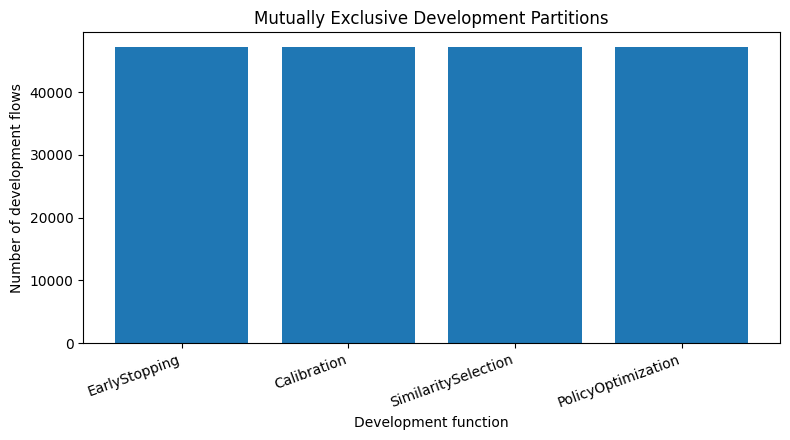

In [ ]:
# BLOCK R1/R2: FOUR DISJOINT DEVELOPMENT FUNCTIONS


from itertools import combinations

print("=" * 115)
print("REVIEWER R1/R2: DISJOINT DEVELOPMENT PARTITIONING")
print("=" * 115)

development_pool_df = validation_df.copy().reset_index(drop=True)
print(f"Development pool rows: {len(development_pool_df):,}")

assert len(development_pool_df) == 188735, (
    "Unexpected development pool size. "
    f"Expected 188,735 rows from locked Block 5, found {len(development_pool_df):,}."
)
assert development_pool_df["label"].nunique() == 12, (
    "Development pool does not contain all 12 classes."
)

development_pool_df["_DEV_ROW_ID"] = np.arange(
    len(development_pool_df), dtype=np.int64
)
original_dev_size = len(development_pool_df)
original_dev_classes = set(development_pool_df["label"].unique())


def split_development_pool(dev_df, seed=42):
    """Return four stratified, mutually exclusive 25% development functions."""
    dev_df = dev_df.copy()

    early_df, remaining_75 = train_test_split(
        dev_df,
        test_size=0.75,
        random_state=seed,
        stratify=dev_df["label"],
    )
    calib_df, remaining_50 = train_test_split(
        remaining_75,
        test_size=2 / 3,
        random_state=seed + 1,
        stratify=remaining_75["label"],
    )
    sim_df, policy_df = train_test_split(
        remaining_50,
        test_size=0.50,
        random_state=seed + 2,
        stratify=remaining_50["label"],
    )

    return tuple(
        frame.reset_index(drop=True)
        for frame in (early_df, calib_df, sim_df, policy_df)
    )


(
    earlystop_dev_df,
    calibration_dev_df,
    similarity_dev_df,
    policy_dev_df,
) = split_development_pool(
    development_pool_df,
    CONFIG["development_split_seed"],
)

parts = {
    "EarlyStopping": earlystop_dev_df,
    "Calibration": calibration_dev_df,
    "SimilaritySelection": similarity_dev_df,
    "PolicyOptimization": policy_dev_df,
}

for name, frame in parts.items():
    assert len(frame) > 0, f"{name} split is empty."
    assert set(frame["label"].unique()) == original_dev_classes, (
        f"{name} lost one or more classes."
    )

id_sets = {
    name: set(frame["_DEV_ROW_ID"].astype(int))
    for name, frame in parts.items()
}

for a, b in combinations(id_sets, 2):
    overlap = id_sets[a] & id_sets[b]
    assert not overlap, (
        f"Development leakage detected between {a} and {b}: "
        f"{len(overlap)} shared original rows."
    )

all_partition_ids = set().union(*id_sets.values())
assert len(all_partition_ids) == original_dev_size
assert sum(len(frame) for frame in parts.values()) == original_dev_size

excluded_hash_columns = {"_DEV_ROW_ID", "_MASTER_ROW_ID"}
diagnostic_cols = [
    c for c in development_pool_df.columns
    if c not in excluded_hash_columns
]

content_hashes = {}
for name, frame in parts.items():
    hashes = pd.util.hash_pandas_object(
        frame[diagnostic_cols],
        index=False,
    ).astype("uint64")
    content_hashes[name] = set(hashes)

duplicate_content_records = []
for a, b in combinations(content_hashes, 2):
    duplicate_content_records.append({
        "Partition_A": a,
        "Partition_B": b,
        "Identical_Full_Row_Hashes": len(content_hashes[a] & content_hashes[b]),
        "Shared_Row_IDs": len(id_sets[a] & id_sets[b]),
    })

duplicate_content_df = pd.DataFrame(duplicate_content_records)

development_manifest_df = pd.DataFrame([
    {
        "Function": name,
        "Rows": len(frame),
        "Fraction_of_Development_Pool": len(frame) / original_dev_size,
        "Classes": frame["label"].nunique(),
        "Unique_Row_IDs": frame["_DEV_ROW_ID"].nunique(),
    }
    for name, frame in parts.items()
])

print("\n[Reviewer R2] Disjoint development manifest")
print(development_manifest_df.to_string(index=False))
print("\n[Full-row duplicate-content diagnostic]")
print(duplicate_content_df.to_string(index=False))

print("\nPASS: all four development subsets contain mutually exclusive original row IDs.")
print("PASS: all development rows are accounted for exactly once.")

full_content_overlap = int(
    duplicate_content_df["Identical_Full_Row_Hashes"].sum()
)
if full_content_overlap == 0:
    print("PASS: no identical full-row content was found across development functions.")
else:
    print(
        "WARNING: identical full-row content exists across development functions; "
        "investigate before final reporting."
    )

development_manifest_df.to_csv(
    os.path.join(REV_TABLE_DIR, "R2_development_partition_manifest.csv"),
    index=False,
)
duplicate_content_df.to_csv(
    os.path.join(REV_TABLE_DIR, "R2_duplicate_content_diagnostic.csv"),
    index=False,
)

plt.figure(figsize=(8, 4.5))
plt.bar(development_manifest_df["Function"], development_manifest_df["Rows"])
plt.ylabel("Number of development flows")
plt.xlabel("Development function")
plt.title("Mutually Exclusive Development Partitions")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(
    os.path.join(REV_FIG_DIR, "R2_development_partition_sizes.png"),
    dpi=220,
    bbox_inches="tight",
)
plt.show()

print("=" * 115)


# Stage 3 — Model Training and Probability Calibration


In [ ]:
# BLOCK R2A: TRAIN-ONLY PREPROCESSING, MODEL DEVELOPMENT, AND CALIBRATION
# EarlyStopping and Calibration are strictly separate development functions.

import lightgbm as lgb
from sklearn.calibration import IsotonicRegression


def fit_feature_preprocessor(frame, feature_names):
    """
    Fit all conversion/imputation rules on the supplied training frame only.
    Numeric columns learn a training median.
    Non-numeric columns learn a deterministic training-only category mapping.
    """
    prep = {
        "feature_names": list(feature_names),
        "numeric_features": [],
        "categorical_features": [],
        "medians": {},
        "category_maps": {},
    }

    for feature in feature_names:
        s = frame[feature]
        numeric = pd.to_numeric(s, errors="coerce")

        nonmissing_original = int(s.notna().sum())
        nonmissing_numeric = int(numeric.notna().sum())
        is_numeric = (
            nonmissing_original == 0
            or nonmissing_numeric == nonmissing_original
        )

        if is_numeric:
            values = numeric.replace([np.inf, -np.inf], np.nan)
            median = float(values.median()) if values.notna().any() else 0.0
            prep["numeric_features"].append(feature)
            prep["medians"][feature] = median
        else:
            values = s.astype("string").fillna("<MISSING>")
            categories = sorted(values.unique().tolist())
            prep["categorical_features"].append(feature)
            prep["category_maps"][feature] = {
                category: idx
                for idx, category in enumerate(categories)
            }

    return prep


def transform_features(frame, preprocessor=None):
    """Apply an already fitted preprocessor without learning from `frame`."""
    if preprocessor is None:
        preprocessor = PRIMARY_PREPROCESSOR

    feature_names = preprocessor["feature_names"]
    out = np.empty((len(frame), len(feature_names)), dtype=np.float32)

    for j, feature in enumerate(feature_names):
        if feature in preprocessor["medians"]:
            values = pd.to_numeric(frame[feature], errors="coerce")
            values = values.replace([np.inf, -np.inf], np.nan)
            values = values.fillna(preprocessor["medians"][feature])
            out[:, j] = values.to_numpy(dtype=np.float32)
        else:
            mapping = preprocessor["category_maps"][feature]
            values = frame[feature].astype("string").fillna("<MISSING>")
            out[:, j] = (
                values.map(mapping)
                .fillna(-1)
                .to_numpy(dtype=np.float32)
            )

    if not np.isfinite(out).all():
        raise ValueError("Non-finite values remain after preprocessing.")

    return out


PRIMARY_PREPROCESSOR = fit_feature_preprocessor(
    train_df,
    expected_features,
)

print("[Preprocessing] Numeric features:", len(PRIMARY_PREPROCESSOR["numeric_features"]))
print("[Preprocessing] Categorical features:", len(PRIMARY_PREPROCESSOR["categorical_features"]))
if PRIMARY_PREPROCESSOR["categorical_features"]:
    print(
        "[Preprocessing] Categorical feature names:",
        PRIMARY_PREPROCESSOR["categorical_features"],
    )

X_train = transform_features(train_df)
y_train = encode_active_labels(train_df["label"], zero_day_value=None)

X_early = transform_features(earlystop_dev_df)
y_early = encode_active_labels(
    earlystop_dev_df["label"],
    zero_day_value=None,
)

X_calib = transform_features(calibration_dev_df)
y_calib = encode_active_labels(
    calibration_dev_df["label"],
    zero_day_value=None,
)

train_data = lgb.Dataset(X_train, label=y_train)
early_data = lgb.Dataset(
    X_early,
    label=y_early,
    reference=train_data,
)

MAIN_PARAMS = {
    "objective": "multiclass",
    "num_class": CLASS_COUNT,
    "metric": "multi_logloss",
    "learning_rate": 0.05,
    "num_leaves": 32,
    "feature_fraction": 0.90,
    "bagging_fraction": 0.90,
    "bagging_freq": 1,
    "seed": RANDOM_STATE,
    "bagging_seed": RANDOM_STATE,
    "feature_fraction_seed": RANDOM_STATE,
    "data_random_seed": RANDOM_STATE,
    "num_threads": max(1, (os.cpu_count() or 2) - 1),
    "verbose": -1,
}

lgb_model = lgb.train(
    MAIN_PARAMS,
    train_data,
    num_boost_round=200,
    valid_sets=[early_data],
    valid_names=["EarlyStopping"],
    callbacks=[lgb.early_stopping(15, verbose=False)],
)

raw_calib = np.asarray(lgb_model.predict(X_calib), dtype=float)

calibrators = {}
for class_idx in range(CLASS_COUNT):
    target = (y_calib == class_idx).astype(int)

    if len(np.unique(target)) < 2:
        raise ValueError(
            f"Calibration subset lacks both binary outcomes for class index {class_idx}."
        )

    iso = IsotonicRegression(out_of_bounds="clip")
    iso.fit(raw_calib[:, class_idx], target)
    calibrators[class_idx] = iso


def get_calibrated_probabilities(model, idx_calibrators, X_matrix):
    """
    Apply class-wise one-vs-rest isotonic calibration, then renormalize
    to a multiclass probability simplex.
    """
    X_matrix = np.asarray(X_matrix, dtype=np.float32)
    raw = np.asarray(model.predict(X_matrix), dtype=float)

    calibrated = np.zeros_like(raw, dtype=float)
    for cls_idx in range(raw.shape[1]):
        calibrated[:, cls_idx] = idx_calibrators[cls_idx].transform(
            raw[:, cls_idx]
        )

    row_sum = calibrated.sum(axis=1, keepdims=True)
    zero_rows = row_sum[:, 0] <= 1e-12

    if np.any(zero_rows):
        calibrated[zero_rows] = raw[zero_rows]
        row_sum = calibrated.sum(axis=1, keepdims=True)

    row_sum[row_sum <= 1e-12] = 1.0
    return calibrated / row_sum


print("[Reviewer R2] Preprocessing fitted on Train only.")
print("[Reviewer R2] Early stopping uses EarlyStopping only.")
print("[Reviewer R2] Isotonic calibration uses Calibration only.")
print("Best boosting iteration:", lgb_model.best_iteration)


[Preprocessing] Numeric features: 114
[Preprocessing] Categorical features: 1
[Preprocessing] Categorical feature names: ['protocol']
[Reviewer R2] Preprocessing fitted on Train only.
[Reviewer R2] Early stopping uses EarlyStopping only.
[Reviewer R2] Isotonic calibration uses Calibration only.
Best boosting iteration: 50


### Test-set firewall

No Host-Test, Time-Test, or Hard-Test performance is inspected here. All primary similarity and routing-policy choices are completed and frozen before final test evaluation.


# Stage 4 — Attribution Signature Construction and Stability



[Reviewer 3] Signature stability summary
 Sample_Size  Mean_Stability  Std_Stability  P05_Stability  Worst_Class_Stability
          20        0.959695       0.046781       0.885160               0.646799
          40        0.973472       0.025040       0.929875               0.786449
          50        0.981460       0.019326       0.945909               0.871347
          80        0.988660       0.011715       0.969023               0.939642
         100        0.990745       0.010035       0.974073               0.926266
         150        0.993410       0.006816       0.981476               0.953110
         160        0.994464       0.008741       0.981457               0.891968
         200        0.994789       0.005734       0.983981               0.961979
         250        0.995770       0.005287       0.986074               0.961435
         300        0.997653       0.002681       0.993300               0.983952
Selected signature sample size: 300
Selection rule: smal

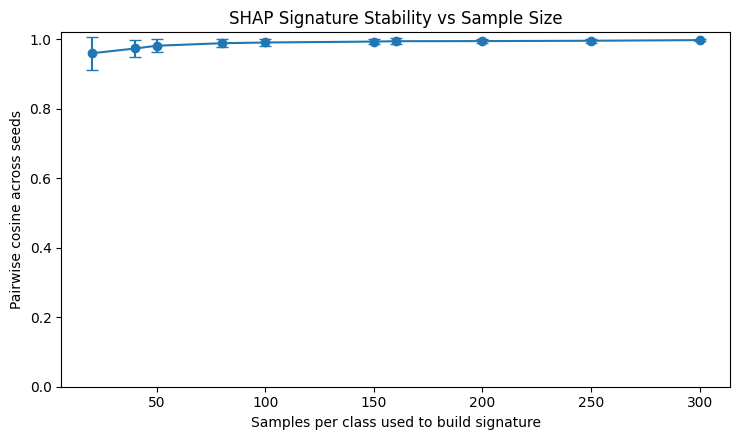

In [ ]:
# BLOCK R3A: SHAP SIGNATURE STABILITY — SAMPLE SIZE × RANDOM SEED


def _row_l2_normalize(A):
    A = np.asarray(A, dtype=np.float32)
    norms = np.linalg.norm(A, axis=1, keepdims=True)
    return np.divide(A, norms, out=np.zeros_like(A), where=norms > 1e-12)


def build_signature_bank(model, train_frame, sample_size, seed):
    X_ref = transform_features(train_frame)
    y_ref = encode_active_labels(train_frame['label'], zero_day_value=None)
    bank = {}
    variances = {}
    for cls_idx in range(CLASS_COUNT):
        rows = np.where(y_ref == cls_idx)[0]
        rng = np.random.default_rng(seed + 1009 * cls_idx)
        take = rng.choice(rows, size=min(len(rows), int(sample_size)), replace=False)
        requested = np.full(len(take), cls_idx, dtype=int)
        attrs = fast_predicted_class_attributions(model, X_ref[take], requested,
                                                   batch_size=CONFIG.get('attribution_batch_size',8192))
        norm = _row_l2_normalize(attrs)
        mean_vec = np.mean(norm, axis=0)
        mean_vec = mean_vec / (np.linalg.norm(mean_vec) + 1e-12)
        name = resolve_active_class_name(cls_idx)
        bank[name] = mean_vec.astype(np.float32)
        variances[name] = np.var(norm, axis=0, ddof=0).astype(np.float32)  # true variance
    return bank, variances


def cosine_vec(a,b):
    a=np.asarray(a,float); b=np.asarray(b,float)
    return float(np.dot(a,b)/((np.linalg.norm(a)*np.linalg.norm(b))+1e-12))

signature_banks = {}
stability_records = []
for n in CONFIG['signature_sample_sizes']:
    signature_banks[n] = {}
    for seed in CONFIG['signature_stability_seeds']:
        bank, varbank = build_signature_bank(lgb_model, train_df, n, seed)
        signature_banks[n][seed] = bank
    for cls_name in ACTIVE_CLASS_NAMES:
        vals=[]
        for s1,s2 in combinations(CONFIG['signature_stability_seeds'],2):
            vals.append(cosine_vec(signature_banks[n][s1][cls_name], signature_banks[n][s2][cls_name]))
        stability_records.append({
            'Sample_Size': n,
            'Class': cls_name,
            'Mean_Pairwise_Cosine': float(np.mean(vals)),
            'Std_Pairwise_Cosine': float(np.std(vals)),
            'Min_Pairwise_Cosine': float(np.min(vals)),
        })

signature_stability_class_df = pd.DataFrame(stability_records)
signature_stability_summary_df = signature_stability_class_df.groupby('Sample_Size').agg(
    Mean_Stability=('Mean_Pairwise_Cosine','mean'),
    Std_Stability=('Mean_Pairwise_Cosine','std'),
    P05_Stability=('Mean_Pairwise_Cosine', lambda x: float(np.quantile(x,0.05))),
    Worst_Class_Stability=('Min_Pairwise_Cosine','min'),
).reset_index()

eligible = signature_stability_summary_df[
    (signature_stability_summary_df['Mean_Stability'] >= CONFIG['signature_stability_mean_floor']) &
    (signature_stability_summary_df['P05_Stability'] >= CONFIG['signature_stability_p05_floor'])
]
SELECTED_SIGNATURE_SAMPLE_SIZE = int(
    eligible['Sample_Size'].min() if len(eligible) else signature_stability_summary_df['Sample_Size'].max()
)
PRIMARY_SIGNATURE_SEED = int(CONFIG['signature_stability_seeds'][0])
train_signatures = signature_banks[SELECTED_SIGNATURE_SAMPLE_SIZE][PRIMARY_SIGNATURE_SEED]

print('\n[Reviewer 3] Signature stability summary')
print(signature_stability_summary_df.to_string(index=False))
print('Selected signature sample size:', SELECTED_SIGNATURE_SAMPLE_SIZE)
print('Selection rule: smallest candidate with Mean Stability >= 0.99 and P05 Stability >= 0.99')
signature_stability_class_df.to_csv(os.path.join(REV_TABLE_DIR,'R3_signature_stability_by_class.csv'),index=False)
signature_stability_summary_df.to_csv(os.path.join(REV_TABLE_DIR,'R3_signature_stability_summary.csv'),index=False)

plt.figure(figsize=(7.5,4.5))
plt.errorbar(signature_stability_summary_df['Sample_Size'],
             signature_stability_summary_df['Mean_Stability'],
             yerr=signature_stability_summary_df['Std_Stability'], marker='o', capsize=4)
plt.xlabel('Samples per class used to build signature')
plt.ylabel('Pairwise cosine across seeds')
plt.title('SHAP Signature Stability vs Sample Size')
plt.ylim(0,1.02)
plt.tight_layout()
plt.savefig(os.path.join(REV_FIG_DIR,'R3_signature_stability_vs_sample_size.png'),dpi=220)
plt.show()



[Reviewer 3] Single-signature multimodality diagnostic
           Class  Best_K  Best_Silhouette  Mean_Nearest_Centroid_Gain  Potentially_Multimodal
          Benign       3         0.535940                    0.172799                    True
     Botnet_ARES       3         0.734396                    0.186422                    True
       DDoS_LOIT       2         0.938987                    0.021743                    True
   DoS_GoldenEye       3         0.707324                    0.116389                    True
        DoS_Hulk       2         0.977973                    0.289339                    True
DoS_Slowhttptest       3         0.630383                    0.378150                    True
   DoS_Slowloris       3         0.611392                    0.342119                    True
     FTP-Patator       3         0.951149                    0.281396                    True
       Port_Scan       2         0.952090                    0.000007                   False
    

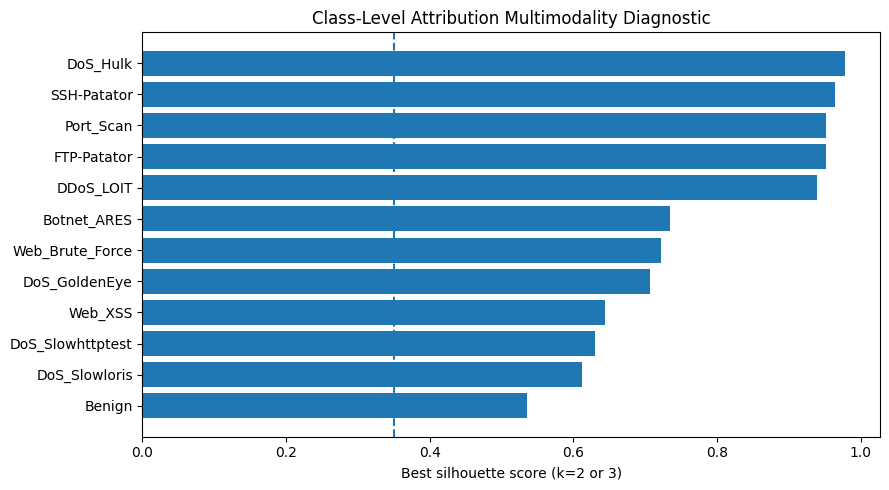

In [ ]:
# BLOCK R3B: MULTIMODALITY DIAGNOSTIC — DOES ONE MEAN SIGNATURE REPRESENT EACH CLASS?
# This does not automatically change the final architecture. It reports whether multiple centroids
# materially improve held-out within-training attribution representation.

multimodal_records=[]
X_train_np = transform_features(train_df)
y_train_np = encode_active_labels(train_df['label'], zero_day_value=None)

for cls_idx in range(CLASS_COUNT):
    rows=np.where(y_train_np==cls_idx)[0]
    rng=np.random.default_rng(7000+cls_idx)
    take=rng.choice(rows,size=min(len(rows),CONFIG['multimodal_max_rows_per_class']),replace=False)
    attrs=fast_predicted_class_attributions(lgb_model,X_train_np[take],np.full(len(take),cls_idx,dtype=int),
                                             batch_size=CONFIG.get('attribution_batch_size',8192))
    Z=_row_l2_normalize(attrs)
    if len(Z)<30:
        continue
    fit_idx, eval_idx = train_test_split(np.arange(len(Z)), test_size=0.30, random_state=42)
    Zfit,Zeval=Z[fit_idx],Z[eval_idx]
    single=np.mean(Zfit,axis=0); single/=np.linalg.norm(single)+1e-12
    single_sim=Zeval@single
    best_k=1; best_sil=np.nan; best_gain=0.0
    for k in [2,3]:
        if len(Zfit)<=k: continue
        km=KMeans(n_clusters=k,random_state=42,n_init=10).fit(Zfit)
        sil=float(silhouette_score(Zfit,km.labels_)) if len(np.unique(km.labels_))>1 else np.nan
        cent=_row_l2_normalize(km.cluster_centers_)
        multi_sim=np.max(Zeval@cent.T,axis=1)
        gain=float(np.mean(multi_sim-single_sim))
        if np.isnan(best_sil) or sil>best_sil:
            best_k=k; best_sil=sil; best_gain=gain
    multimodal_records.append({
        'Class':resolve_active_class_name(cls_idx),
        'Best_K':best_k,
        'Best_Silhouette':best_sil,
        'Mean_Nearest_Centroid_Gain':best_gain,
        'Potentially_Multimodal':bool((best_sil if np.isfinite(best_sil) else -1)>=CONFIG['multimodal_silhouette_flag'] and best_gain>0.01),
    })

signature_multimodality_df=pd.DataFrame(multimodal_records)
print('\n[Reviewer 3] Single-signature multimodality diagnostic')
print(signature_multimodality_df.to_string(index=False))
signature_multimodality_df.to_csv(os.path.join(REV_TABLE_DIR,'R3_signature_multimodality_diagnostic.csv'),index=False)

plt.figure(figsize=(9,5))
plot_df=signature_multimodality_df.sort_values('Best_Silhouette')
plt.barh(plot_df['Class'],plot_df['Best_Silhouette'])
plt.axvline(CONFIG['multimodal_silhouette_flag'],linestyle='--')
plt.xlabel('Best silhouette score (k=2 or 3)')
plt.title('Class-Level Attribution Multimodality Diagnostic')
plt.tight_layout()
plt.savefig(os.path.join(REV_FIG_DIR,'R3_signature_multimodality.png'),dpi=220)
plt.show()


# Stage 5 — Development-Only Similarity Selection



[Reviewer 1] DEVELOPMENT-ONLY similarity metric selection
   Metric  Correct_Mean  Incorrect_Mean  Separation_Gap  Separation_AUC  Development_Rows  Incorrect_Rows
   Cosine      0.736371        0.240019        0.496351        0.845593             47184             231
Euclidean      0.677963        0.478127        0.199836        0.845593             47184             231
  Pearson      0.734717        0.234371        0.500347        0.843759             47184             231
 Spearman      0.478388        0.173330        0.305058        0.772557             47184             231
SELECTED_SIMILARITY_METRIC = Euclidean


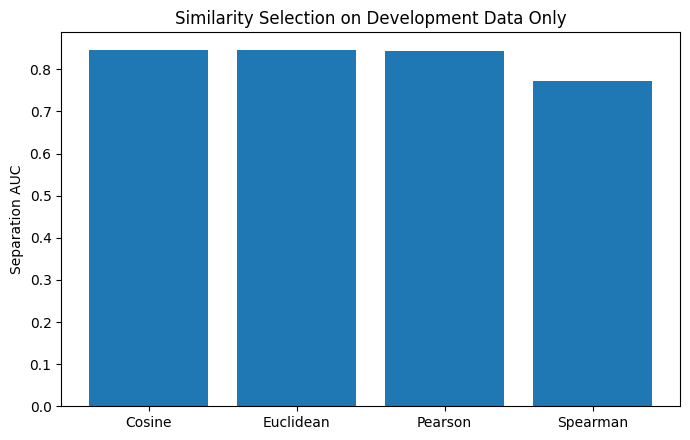

In [ ]:
# BLOCK R1: SIMILARITY METRIC SELECTION ON DEVELOPMENT DATA ONLY
# Host-Test, Time-Test, Hard-Test, and adversarial data are not touched here.


def _similarity_scores_from_normalized(Z, ref, metric):
    Z=np.asarray(Z,float); ref=np.asarray(ref,float)
    ref=ref/(np.linalg.norm(ref)+1e-12)
    metric=metric.lower()
    if metric=='cosine':
        return Z@ref
    if metric=='euclidean':
        return 1.0/(1.0+np.linalg.norm(Z-ref[None,:],axis=1))
    out=np.zeros(len(Z),dtype=float)
    for i,row in enumerate(Z):
        if metric=='pearson':
            v=pearsonr(row,ref).statistic
        elif metric=='spearman':
            v=spearmanr(row,ref).correlation
        else:
            raise ValueError(metric)
        out[i]=0.0 if not np.isfinite(v) else float(v)
    return out


def compute_similarity_metric(model, reference_signatures, X_matrix, pred_idx, pred_names, metric):
    X=np.asarray(X_matrix,dtype=np.float32); pred_idx=np.asarray(pred_idx,int); pred_names=np.asarray(pred_names,object)
    attrs=fast_predicted_class_attributions(model,X,pred_idx,batch_size=CONFIG.get('attribution_batch_size',8192))
    Z=_row_l2_normalize(attrs)
    sims=np.zeros(len(X),dtype=float)
    for name in np.unique(pred_names):
        m=pred_names==name
        ref=reference_signatures.get(name)
        if ref is None: continue
        sims[m]=_similarity_scores_from_normalized(Z[m],ref,metric)
    return sims,Z

X_sim=transform_features(similarity_dev_df)
y_sim=encode_active_labels(similarity_dev_df['label'],zero_day_value=None)
prob_sim=get_calibrated_probabilities(lgb_model,calibrators,X_sim)
pred_sim=np.argmax(prob_sim,axis=1)
pred_names_sim=np.asarray([resolve_active_class_name(i) for i in pred_sim],dtype=object)
correct=(pred_sim==y_sim).astype(int)

metric_records=[]
for metric in ['Cosine','Euclidean','Pearson','Spearman']:
    sims,_=compute_similarity_metric(lgb_model,train_signatures,X_sim,pred_sim,pred_names_sim,metric)
    c=sims[correct==1]; w=sims[correct==0]
    gap=float(np.mean(c)-np.mean(w)) if len(c) and len(w) else np.nan
    auc=float(roc_auc_score(correct,sims)) if len(np.unique(correct))==2 else np.nan
    metric_records.append({'Metric':metric,'Correct_Mean':np.mean(c) if len(c) else np.nan,
                           'Incorrect_Mean':np.mean(w) if len(w) else np.nan,
                           'Separation_Gap':gap,'Separation_AUC':auc,
                           'Development_Rows':len(X_sim),'Incorrect_Rows':int(np.sum(correct==0))})

similarity_selection_df=pd.DataFrame(metric_records)
ranked=similarity_selection_df.sort_values(['Separation_AUC','Separation_Gap'],ascending=[False,False],na_position='last')
SELECTED_SIMILARITY_METRIC=str(ranked.iloc[0]['Metric'])
print('\n[Reviewer 1] DEVELOPMENT-ONLY similarity metric selection')
print(similarity_selection_df.to_string(index=False))
print('SELECTED_SIMILARITY_METRIC =',SELECTED_SIMILARITY_METRIC)
similarity_selection_df.to_csv(os.path.join(REV_TABLE_DIR,'R1_similarity_selection_development_only.csv'),index=False)

plt.figure(figsize=(7,4.5))
plt.bar(similarity_selection_df['Metric'],similarity_selection_df['Separation_AUC'])
plt.ylabel('Separation AUC')
plt.title('Similarity Selection on Development Data Only')
plt.tight_layout()
plt.savefig(os.path.join(REV_FIG_DIR,'R1_similarity_selection_auc.png'),dpi=220)
plt.show()


# Stage 6 — Containment-First Policy Optimization and Policy Freeze


In [ ]:
# =============================================================================
# BLOCK R2B: ESCALATION-AWARE REVIEWER-2 DEVELOPMENT POLICY OPTIMIZATION
# DROP-IN VERSION WITH EXPLICIT UPSTREAM DEPENDENCY AUDIT
#
# IMPORTANT:
#   This is the COMPLETE R2B block.
#   It is designed to be pasted into the existing notebook after the earlier
#   setup / ingestion / preprocessing / development-split / signature-selection
#   stages have been executed.
#
#   It does NOT recreate upstream experimental objects. Instead, it verifies
#   them explicitly before any R2B computation begins. If something is missing,
#   execution stops immediately with a precise list rather than failing later
#   with a NameError.
# =============================================================================

# =============================================================================
# 0. PRE-RUN DEPENDENCY AUDIT
# =============================================================================

_R2B_REQUIRED_GLOBALS = [
    # Core experiment configuration / data
    "CONFIG",
    "train_df",
    "development_pool_df",
    "PRIMARY_PREPROCESSOR",
    "MAIN_PARAMS",

    # Frozen development-side selections established earlier
    "SELECTED_SIGNATURE_SAMPLE_SIZE",
    "SELECTED_SIMILARITY_METRIC",

    # Label / class definitions
    "BENIGN_IDX",
    "CLASS_COUNT",

    # Output location
    "REV_TABLE_DIR",

    # Core helper functions established earlier in the notebook
    "split_development_pool",
    "transform_features",
    "encode_active_labels",
    "get_calibrated_probabilities",
    "compute_similarity_metric",
    "route_policy_batch",
    "build_signature_bank",
    "resolve_active_class_name",

    # Imported libraries / classes used directly in R2B
    "np",
    "pd",
    "os",
    "gc",
    "lgb",
    "IsotonicRegression",
]

_R2B_MISSING_GLOBALS = [
    name
    for name in _R2B_REQUIRED_GLOBALS
    if name not in globals()
]

if _R2B_MISSING_GLOBALS:
    raise RuntimeError(
        "R2B cannot start because required upstream notebook objects are "
        "missing from the current runtime:\n  - "
        + "\n  - ".join(_R2B_MISSING_GLOBALS)
        + "\n\nRun the earlier notebook setup/configuration/data/preprocessing/"
          "development-split cells first, then rerun this complete R2B block."
    )

# Basic structural checks on the most important objects.
if len(train_df) == 0:
    raise RuntimeError("R2B dependency audit failed: train_df is empty.")

if len(development_pool_df) == 0:
    raise RuntimeError(
        "R2B dependency audit failed: development_pool_df is empty."
    )

if "label" not in train_df.columns:
    raise RuntimeError(
        "R2B dependency audit failed: train_df has no 'label' column."
    )

if "label" not in development_pool_df.columns:
    raise RuntimeError(
        "R2B dependency audit failed: development_pool_df has no 'label' column."
    )

if int(SELECTED_SIGNATURE_SAMPLE_SIZE) <= 0:
    raise RuntimeError(
        "R2B dependency audit failed: SELECTED_SIGNATURE_SAMPLE_SIZE "
        "must be positive."
    )

if not isinstance(SELECTED_SIMILARITY_METRIC, str):
    raise RuntimeError(
        "R2B dependency audit failed: SELECTED_SIMILARITY_METRIC "
        "must be a string."
    )

if int(CLASS_COUNT) < 2:
    raise RuntimeError(
        "R2B dependency audit failed: CLASS_COUNT must be at least 2."
    )

if not (0 <= int(BENIGN_IDX) < int(CLASS_COUNT)):
    raise RuntimeError(
        "R2B dependency audit failed: BENIGN_IDX is outside the active "
        "class index range."
    )

print("\n" + "=" * 110)
print("[Reviewer R2] PRE-RUN DEPENDENCY AUDIT")
print("=" * 110)
print("PASS: All required upstream objects are present.")
print(f"Train rows                          : {len(train_df):,}")
print(f"Development-pool rows               : {len(development_pool_df):,}")
print(f"Active class count                  : {int(CLASS_COUNT)}")
print(f"Benign class index                  : {int(BENIGN_IDX)}")
print(f"Selected signature sample size      : {int(SELECTED_SIGNATURE_SAMPLE_SIZE)}")
print(f"Selected similarity metric          : {SELECTED_SIMILARITY_METRIC}")
print(f"Canonical development split seed    : {CONFIG.get('development_split_seed', 42)}")
print(f"ANMR safety floor                   : {CONFIG.get('anmr_safety_floor', 0.9999)}")
print(f"FBR safety ceiling                  : {CONFIG.get('fbr_safety_ceiling', 0.005)}")
print("=" * 110)


print("\n" + "=" * 110)
print("Escalation-aware repeated development-policy optimization and threshold stability")
print("=" * 110)


# =============================================================================
# 1. REVIEWER-2 CONFIGURATION
# =============================================================================

ANMR_SAFETY_FLOOR = float(
    CONFIG.get(
        "anmr_safety_floor",
        0.9999
    )
)

FBR_SAFETY_CEILING = float(
    CONFIG.get(
        "fbr_safety_ceiling",
        0.005
    )
)

# Five independent repeated development partitions.
R2_SPLIT_SEEDS = [
    42,
    123,
    456,
    789,
    2026
]


# =============================================================================
# 2. BASIC POLICY ARRAYS
# =============================================================================

def policy_arrays(
    model,
    calibs,
    signatures,
    frame,
    metric
):

    X = transform_features(frame)

    y = encode_active_labels(
        frame["label"],
        zero_day_value=None
    )

    probs = get_calibrated_probabilities(
        model,
        calibs,
        X
    )

    pred = np.argmax(
        probs,
        axis=1
    )

    pred_names = np.asarray(
        [
            resolve_active_class_name(i)
            for i in pred
        ],
        dtype=object
    )

    true_names = np.asarray(
        [
            resolve_active_class_name(i)
            for i in y
        ],
        dtype=object
    )

    sims, _ = compute_similarity_metric(
        model,
        signatures,
        X,
        pred,
        pred_names,
        metric
    )

    return (
        X,
        y,
        probs,
        pred,
        pred_names,
        true_names,
        sims
    )


# =============================================================================
# 3. ROUTING POLICY OPTIMIZATION
# =============================================================================

def tune_routing_policy(
    model,
    calibs,
    signatures,
    frame,
    metric
):
    """
    Escalation-aware development-only routing optimization.

    Safety remains hard:
      ANMR >= ANMR_SAFETY_FLOOR
      FBR  <= FBR_SAFETY_CEILING

    Among safety-feasible candidates, the operational objective is:
      1) minimize ATTACK escalation rate,
      2) maximize automatic ATTACK block rate,
      3) maximize ANMR,
      4) minimize FBR,
      5) minimize overall escalation.

    This prevents a policy from receiving preference merely because it preserves
    ANMR by escalating almost every malicious flow.
    """

    (
        X,
        y,
        probs,
        pred,
        pred_names,
        true_names,
        sims
    ) = policy_arrays(
        model,
        calibs,
        signatures,
        frame,
        metric
    )

    benign_prob = probs[:, BENIGN_IDX]
    attack_conf = 1.0 - benign_prob
    pred_benign = (pred_names == "Benign")
    true_benign = (true_names == "Benign")
    true_malicious = (~true_benign)

    attack_n = max(int(np.sum(true_malicious)), 1)
    benign_n = max(int(np.sum(true_benign)), 1)

    # -------------------------------------------------------------------------
    # Development-only threshold grids.
    #
    # The ranges are intentionally retained from the previous reviewer-strict
    # pipeline so that the methodological change is the SELECTION OBJECTIVE,
    # not a post-hoc expansion based on final LOAFO outcomes.
    # -------------------------------------------------------------------------
    grids = {
        "tau_p": np.linspace(0.60, 0.98, 8),
        "tau_s": np.linspace(0.01, 0.40, 8),
        "benign_prob": np.linspace(0.90, 0.99, 6),
        "benign_sim": np.linspace(0.05, 0.40, 6),
        "high_conf_benign_prob": np.array([0.995, 0.9975, 0.999, 0.9995]),
        "high_conf_benign_sim": np.array([0.00, 0.01, 0.02, 0.03, 0.04]),
    }

    best_fallback = None
    feasible = []

    for tau_p in grids["tau_p"]:
        for tau_s in grids["tau_s"]:

            block_base = (
                (~pred_benign)
                & (attack_conf >= tau_p)
                & (sims >= 0.5 * tau_s)
            )

            for benign_prob_tau in grids["benign_prob"]:
                for benign_sim_tau in grids["benign_sim"]:

                    ordinary_allow = (
                        pred_benign
                        & (benign_prob >= benign_prob_tau)
                        & (sims >= max(tau_s, benign_sim_tau))
                    )

                    for high_conf_benign_prob_tau in grids["high_conf_benign_prob"]:
                        for high_conf_benign_sim_floor in grids["high_conf_benign_sim"]:

                            high_conf_benign_allow = (
                                pred_benign
                                & (benign_prob >= high_conf_benign_prob_tau)
                                & (sims >= high_conf_benign_sim_floor)
                            )

                            allow = ordinary_allow | high_conf_benign_allow
                            block = block_base & (~allow)
                            escalate = ~(allow | block)

                            attack_allow_count = int(np.sum(true_malicious & allow))
                            attack_block_count = int(np.sum(true_malicious & block))
                            attack_escalate_count = int(np.sum(true_malicious & escalate))
                            false_blocks = int(np.sum(true_benign & block))

                            attack_allow_rate = float(attack_allow_count / attack_n)
                            attack_block_rate = float(attack_block_count / attack_n)
                            attack_escalation_rate = float(attack_escalate_count / attack_n)

                            anmr = float(1.0 - attack_allow_rate)
                            fbr = float(false_blocks / benign_n)
                            escalation = float(np.mean(escalate))

                            # Numerical audit: malicious actions must partition.
                            if not np.isclose(
                                attack_allow_rate
                                + attack_block_rate
                                + attack_escalation_rate,
                                1.0,
                                atol=1e-10,
                            ):
                                raise RuntimeError(
                                    "Attack ALLOW/BLOCK/ESCALATE rates do not sum to 1."
                                )

                            row = (
                                float(tau_p),
                                float(tau_s),
                                float(benign_prob_tau),
                                float(benign_sim_tau),
                                float(high_conf_benign_prob_tau),
                                float(high_conf_benign_sim_floor),
                                float(anmr),
                                float(fbr),
                                float(escalation),
                                float(attack_block_rate),
                                float(attack_escalation_rate),
                                float(attack_allow_rate),
                            )

                            violation = (
                                max(0.0, ANMR_SAFETY_FLOOR - anmr)
                                + max(0.0, fbr - FBR_SAFETY_CEILING)
                            )

                            # Fallback is used only if no safety-feasible policy
                            # exists. Safety violation is therefore first.
                            fallback_key = (
                                violation,
                                attack_escalation_rate,
                                -attack_block_rate,
                                -anmr,
                                fbr,
                                escalation,
                                -high_conf_benign_prob_tau,
                                -high_conf_benign_sim_floor,
                            )

                            if (
                                best_fallback is None
                                or fallback_key < best_fallback[0]
                            ):
                                best_fallback = (fallback_key, row)

                            if violation <= 1e-12:
                                feasible.append(row)

    if feasible:
        # IMPORTANT:
        # ANMR and FBR are HARD constraints here, not optimization rewards.
        # Once safety is satisfied, analyst burden and automatic containment
        # determine the policy.
        chosen = min(
            feasible,
            key=lambda r: (
                r[10],      # attack escalation rate: MINIMIZE
                -r[9],      # automatic attack block rate: MAXIMIZE
                -r[6],      # ANMR: MAXIMIZE
                r[7],       # FBR: MINIMIZE
                r[8],       # overall escalation: MINIMIZE
                -r[4],
                -r[5],
            ),
        )
        status = "SAFETY-FEASIBLE ESCALATION-AWARE ROUTING POLICY"
    else:
        if best_fallback is None:
            raise RuntimeError("Routing-policy optimization evaluated no candidates.")
        chosen = best_fallback[1]
        status = "FALLBACK: NO ROUTING CANDIDATE SATISFIED ANMR/FBR SAFETY"

    print("\n[Reviewer R2] Escalation-aware routing-policy selection")
    print("Selection status       :", status)
    print("ANMR                   :", chosen[6])
    print("FBR                    :", chosen[7])
    print("Overall escalation     :", chosen[8])
    print("Attack BLOCK rate      :", chosen[9])
    print("Attack ESCALATION rate :", chosen[10])
    print("Attack ALLOW rate      :", chosen[11])

    return chosen


# =============================================================================
# 4. SELECTIVE-ATTRIBUTION OPTIMIZATION
# =============================================================================

def tune_selective_policy(
    model,
    calibs,
    signatures,
    frame,
    metric,
    routing_values
):
    """
    Escalation-aware selective-attribution optimization.

    The full SHAP routing policy is already frozen within this development
    repetition. Direct-routing gates are selected only on PolicyOptimization.

    Hard constraints:
      ANMR >= ANMR_SAFETY_FLOOR
      FBR  <= FBR_SAFETY_CEILING
      both direct ALLOW and direct BLOCK must be active
      attribution fraction < 1

    Feasible candidates are ranked by:
      1) minimum ATTACK escalation,
      2) maximum automatic ATTACK block,
      3) maximum ANMR,
      4) minimum attribution workload,
      5) minimum FBR.

    This makes workload reduction secondary to the operational goal of resolving
    malicious flows automatically rather than sending them to analysts.
    """

    (
        tau_p,
        tau_s,
        benign_prob_tau,
        benign_sim_tau,
        high_conf_benign_prob_tau,
        high_conf_benign_sim_floor,
        *_
    ) = routing_values

    (
        X,
        y,
        probs,
        pred,
        pred_names,
        true_names,
        sims
    ) = policy_arrays(
        model,
        calibs,
        signatures,
        frame,
        metric
    )

    benign_prob = probs[:, BENIGN_IDX]
    attack_conf = 1.0 - benign_prob

    sorted_probs = np.sort(probs, axis=1)
    max_prob = sorted_probs[:, -1]
    margin = sorted_probs[:, -1] - sorted_probs[:, -2]

    pred_benign = (pred_names == "Benign")
    pred_attack = (~pred_benign)
    true_benign = (true_names == "Benign")
    true_malicious = (~true_benign)

    attack_n = max(int(np.sum(true_malicious)), 1)
    benign_n = max(int(np.sum(true_benign)), 1)

    full_route = route_policy_batch(
        pred_names,
        attack_conf,
        sims,
        tau_p,
        tau_s,
        benign_prob_tau,
        benign_sim_tau,
        high_conf_benign_prob_tau,
        high_conf_benign_sim_floor,
    )

    full_actions = np.asarray(full_route["actions"], dtype=object)

    # -------------------------------------------------------------------------
    # Development-only empirical quantile grids.
    #
    # Benign direct ALLOW remains conservative (upper-tail quantiles).
    # Attack direct BLOCK is deliberately given a broader development-derived
    # grid because the old 90-99%-only attack grid could force many correctly
    # attack-predicted flows into SHAP/ESCALATE even when FBR headroom existed.
    # No test/LOAFO result is used to choose these quantiles.
    # -------------------------------------------------------------------------
    BENIGN_DIRECT_QUANTILES = np.array([0.90, 0.95, 0.975, 0.99], dtype=float)
    ATTACK_DIRECT_QUANTILES = np.array(
        [0.50, 0.70, 0.80, 0.90, 0.95, 0.975, 0.99],
        dtype=float,
    )

    if not np.any(pred_benign):
        raise RuntimeError(
            "Selective-policy optimization has no predicted-Benign rows "
            "in the PolicyOptimization subset."
        )

    if not np.any(pred_attack):
        raise RuntimeError(
            "Selective-policy optimization has no predicted-Attack rows "
            "in the PolicyOptimization subset."
        )

    def _unique_empirical_quantiles(values, quantile_levels):
        values = np.asarray(values, dtype=float)
        values = values[np.isfinite(values)]

        if len(values) == 0:
            raise RuntimeError(
                "Cannot derive selective thresholds from an empty/non-finite "
                "development distribution."
            )

        candidates = np.quantile(values, quantile_levels)
        candidates = np.unique(np.asarray(candidates, dtype=float))
        return np.clip(candidates, 0.0, 1.0)

    benign_prob_grid = _unique_empirical_quantiles(
        benign_prob[pred_benign],
        BENIGN_DIRECT_QUANTILES,
    )

    benign_margin_grid = _unique_empirical_quantiles(
        margin[pred_benign],
        BENIGN_DIRECT_QUANTILES,
    )

    attack_prob_grid = _unique_empirical_quantiles(
        max_prob[pred_attack],
        ATTACK_DIRECT_QUANTILES,
    )

    attack_margin_grid = _unique_empirical_quantiles(
        margin[pred_attack],
        ATTACK_DIRECT_QUANTILES,
    )

    print(
        "\n[Reviewer R2] Escalation-aware development-derived selective grids"
    )
    print("Benign direct quantiles:", BENIGN_DIRECT_QUANTILES.tolist())
    print("Attack direct quantiles:", ATTACK_DIRECT_QUANTILES.tolist())
    print("Benign direct prob     :", benign_prob_grid.tolist())
    print("Benign direct margin   :", benign_margin_grid.tolist())
    print("Attack direct prob     :", attack_prob_grid.tolist())
    print("Attack direct margin   :", attack_margin_grid.tolist())

    best_fallback = None
    feasible_candidates = []

    for benign_direct_prob in benign_prob_grid:
        for benign_direct_margin in benign_margin_grid:

            direct_allow = (
                pred_benign
                & (benign_prob >= benign_direct_prob)
                & (margin >= benign_direct_margin)
            )

            for attack_direct_prob in attack_prob_grid:
                for attack_direct_margin in attack_margin_grid:

                    direct_block = (
                        pred_attack
                        & (attack_conf >= tau_p)
                        & (max_prob >= attack_direct_prob)
                        & (margin >= attack_direct_margin)
                    )

                    unresolved = ~(direct_allow | direct_block)

                    actions = full_actions.copy()
                    actions[direct_allow] = "ALLOW"
                    actions[direct_block] = "BLOCK"

                    attack_allow_count = int(
                        np.sum(true_malicious & (actions == "ALLOW"))
                    )
                    attack_block_count = int(
                        np.sum(true_malicious & (actions == "BLOCK"))
                    )
                    attack_escalate_count = int(
                        np.sum(true_malicious & (actions == "ESCALATE"))
                    )
                    false_blocks = int(
                        np.sum(true_benign & (actions == "BLOCK"))
                    )

                    attack_allow_rate = float(attack_allow_count / attack_n)
                    attack_block_rate = float(attack_block_count / attack_n)
                    attack_escalation_rate = float(attack_escalate_count / attack_n)

                    anmr = float(1.0 - attack_allow_rate)
                    fbr = float(false_blocks / benign_n)
                    escalation = float(np.mean(actions == "ESCALATE"))
                    attribution_fraction = float(np.mean(unresolved))

                    if not np.isclose(
                        attack_allow_rate
                        + attack_block_rate
                        + attack_escalation_rate,
                        1.0,
                        atol=1e-10,
                    ):
                        raise RuntimeError(
                            "Selective attack ALLOW/BLOCK/ESCALATE rates do not sum to 1."
                        )

                    direct_allow_count = int(np.sum(direct_allow))
                    direct_block_count = int(np.sum(direct_block))

                    nondegenerate_selective = (
                        direct_allow_count > 0
                        and direct_block_count > 0
                        and attribution_fraction < 1.0
                    )

                    safety_violation = (
                        max(0.0, ANMR_SAFETY_FLOOR - anmr)
                        + max(0.0, fbr - FBR_SAFETY_CEILING)
                    )

                    row = (
                        float(benign_direct_prob),
                        float(benign_direct_margin),
                        float(attack_direct_prob),
                        float(attack_direct_margin),
                        float(anmr),
                        float(fbr),
                        float(escalation),
                        float(attribution_fraction),
                        float(attack_block_rate),
                        float(attack_escalation_rate),
                        float(attack_allow_rate),
                    )

                    fallback_key = (
                        0 if nondegenerate_selective else 1,
                        safety_violation,
                        attack_escalation_rate,
                        -attack_block_rate,
                        -anmr,
                        attribution_fraction,
                        fbr,
                    )

                    if (
                        best_fallback is None
                        or fallback_key < best_fallback[0]
                    ):
                        best_fallback = (
                            fallback_key,
                            row,
                            direct_allow_count,
                            direct_block_count,
                            nondegenerate_selective,
                        )

                    if (
                        safety_violation <= 1e-12
                        and nondegenerate_selective
                    ):
                        feasible_candidates.append(
                            (
                                row,
                                direct_allow_count,
                                direct_block_count,
                            )
                        )

    if feasible_candidates:
        chosen_row, chosen_allow_count, chosen_block_count = min(
            feasible_candidates,
            key=lambda item: (
                item[0][9],      # attack escalation: MINIMIZE
                -item[0][8],     # attack block: MAXIMIZE
                -item[0][4],     # ANMR: MAXIMIZE
                item[0][7],      # attribution workload: MINIMIZE
                item[0][5],      # FBR: MINIMIZE
                item[0][6],      # overall escalation: MINIMIZE
            ),
        )
        selection_status = (
            "SAFETY-FEASIBLE ESCALATION-AWARE SELECTIVE POLICY"
        )
    else:
        if best_fallback is None:
            raise RuntimeError(
                "Selective-policy optimization evaluated no candidates."
            )

        (
            _,
            chosen_row,
            chosen_allow_count,
            chosen_block_count,
            chosen_nondegenerate,
        ) = best_fallback

        selection_status = (
            "FALLBACK: NO SELECTIVE CANDIDATE SATISFIED ALL SAFETY + "
            "NON-DEGENERACY REQUIREMENTS"
        )

        if not chosen_nondegenerate:
            raise RuntimeError(
                "No non-degenerate selective policy exists on the "
                "PolicyOptimization subset."
            )

    print("\n[Reviewer R2] Escalation-aware selective-policy selection")
    print("Selection status       :", selection_status)
    print("Direct ALLOW count     :", chosen_allow_count)
    print("Direct BLOCK count     :", chosen_block_count)
    print("Attribution fraction   :", chosen_row[7])
    print("Selective ANMR         :", chosen_row[4])
    print("Selective FBR          :", chosen_row[5])
    print("Overall escalation     :", chosen_row[6])
    print("Attack BLOCK rate      :", chosen_row[8])
    print("Attack ESCALATION rate :", chosen_row[9])
    print("Attack ALLOW rate      :", chosen_row[10])

    return chosen_row


# =============================================================================
# 5. TRAIN + CALIBRATE ONE DEVELOPMENT REPETITION
# =============================================================================

def fit_r2_development_replication(
    split_seed
):

    (
        early_stop_df,
        calibration_df,
        similarity_df,
        policy_df
    ) = split_development_pool(
        development_pool_df,
        split_seed
    )

    # -------------------------------------------------------------------------
    # Training data
    #
    # IMPORTANT:
    # Use the PRIMARY_PREPROCESSOR fitted exclusively on train_df.
    # The repeated development split changes ONLY the functional allocation
    # of development rows. It does not refit preprocessing.
    # -------------------------------------------------------------------------

    X_train_r2 = transform_features(
        train_df,
        PRIMARY_PREPROCESSOR
    )

    y_train_r2 = encode_active_labels(
        train_df["label"],
        zero_day_value=None
    )

    # -------------------------------------------------------------------------
    # Dedicated early-stopping subset
    # -------------------------------------------------------------------------

    X_es_r2 = transform_features(
        early_stop_df,
        PRIMARY_PREPROCESSOR
    )

    y_es_r2 = encode_active_labels(
        early_stop_df["label"],
        zero_day_value=None
    )

    train_ds = lgb.Dataset(
        X_train_r2,
        label=y_train_r2
    )

    es_ds = lgb.Dataset(
        X_es_r2,
        label=y_es_r2,
        reference=train_ds
    )

    # -------------------------------------------------------------------------
    # Keep the model-training seed fixed.
    #
    # R2 measures sensitivity to DEVELOPMENT PARTITIONING only.
    # Training-seed sensitivity is evaluated separately in the
    # multi-seed robustness experiment.
    # -------------------------------------------------------------------------

    params = dict(
        MAIN_PARAMS
    )

    model = lgb.train(
        params,
        train_ds,
        num_boost_round=200,
        valid_sets=[
            es_ds
        ],
        callbacks=[
            lgb.early_stopping(
                15,
                verbose=False
            )
        ]
    )

    # -------------------------------------------------------------------------
    # Dedicated calibration subset
    # -------------------------------------------------------------------------

    X_cal_r2 = transform_features(
        calibration_df,
        PRIMARY_PREPROCESSOR
    )

    y_cal_r2 = encode_active_labels(
        calibration_df["label"],
        zero_day_value=None
    )

    raw_cal = np.asarray(
        model.predict(
            X_cal_r2
        ),
        dtype=float
    )

    local_calibrators = {}

    for class_idx in range(
        CLASS_COUNT
    ):

        iso = IsotonicRegression(
            out_of_bounds="clip"
        )

        target = (
            y_cal_r2 == class_idx
        ).astype(
            int
        )

        # Defensive fallback. Because every development subset contains
        # all 12 classes, this branch should normally never be required.
        if len(
            np.unique(
                target
            )
        ) < 2:

            iso.fit(
                np.append(
                    raw_cal[
                        :,
                        class_idx
                    ],
                    [
                        0.0,
                        1.0
                    ]
                ),
                np.append(
                    target,
                    [
                        0,
                        1
                    ]
                )
            )

        else:

            iso.fit(
                raw_cal[
                    :,
                    class_idx
                ],
                target
            )

        local_calibrators[
            class_idx
        ] = iso

    # -------------------------------------------------------------------------
    # Independently rebuild SHAP signatures for this repetition.
    #
    # Signature sampling seed follows the development repetition so that
    # Reviewer-R2 stability includes the complete development-side procedure.
    # The fitted preprocessing remains fixed to Train only.
    # -------------------------------------------------------------------------

    signature_bank, _ = build_signature_bank(
        model,
        train_df,
        SELECTED_SIGNATURE_SAMPLE_SIZE,
        split_seed
    )

    return (
        model,
        local_calibrators,
        signature_bank,
        early_stop_df,
        calibration_df,
        similarity_df,
        policy_df
    )


# =============================================================================
# 6. RUN FIVE REPEATED DEVELOPMENT OPTIMIZATIONS
# =============================================================================

r2_repeated_records = []


for split_seed in R2_SPLIT_SEEDS:

    print(
        "\n" +
        "-" * 110
    )

    print(
        f"[Reviewer R2] "
        f"Development repetition seed = "
        f"{split_seed}"
    )

    print(
        "-" * 110
    )

    (
        r2_model,
        r2_calibrators,
        r2_signatures,
        r2_es_df,
        r2_cal_df,
        r2_sim_df,
        r2_policy_df
    ) = fit_r2_development_replication(
        split_seed
    )

    # -------------------------------------------------------------------------
    # Routing-policy optimization
    # -------------------------------------------------------------------------

    routing_values = tune_routing_policy(
        r2_model,
        r2_calibrators,
        r2_signatures,
        r2_policy_df,
        SELECTED_SIMILARITY_METRIC
    )

    (
        tau_p,
        tau_s,
        benign_prob_tau,
        benign_sim_tau,
        high_conf_benign_prob_tau,
        high_conf_benign_sim_floor,
        routing_anmr,
        routing_fbr,
        routing_escalation,
        routing_attack_block,
        routing_attack_escalation,
        routing_attack_allow
    ) = routing_values

    # -------------------------------------------------------------------------
    # Selective-attribution optimization
    # -------------------------------------------------------------------------

    selective_values = tune_selective_policy(
        r2_model,
        r2_calibrators,
        r2_signatures,
        r2_policy_df,
        SELECTED_SIMILARITY_METRIC,
        routing_values
    )

    (
        benign_direct_prob,
        benign_direct_margin,
        attack_direct_prob,
        attack_direct_margin,
        selective_anmr,
        selective_fbr,
        selective_escalation,
        attribution_fraction,
        selective_attack_block,
        selective_attack_escalation,
        selective_attack_allow
    ) = selective_values

    # -------------------------------------------------------------------------
    # Save complete repetition
    # -------------------------------------------------------------------------

    r2_repeated_records.append(
        {
            "Split_Seed":
                split_seed,

            "TAU_P":
                tau_p,

            "TAU_S":
                tau_s,

            "BENIGN_PROB_TAU":
                benign_prob_tau,

            "BENIGN_SIM_TAU":
                benign_sim_tau,

            "High-confidence benign probability threshold":
                high_conf_benign_prob_tau,

            "High-confidence benign similarity floor":
                high_conf_benign_sim_floor,

            "Benign_Direct_Prob":
                benign_direct_prob,

            "Benign_Direct_Margin":
                benign_direct_margin,

            "Attack_Direct_Prob":
                attack_direct_prob,

            "Attack_Direct_Margin":
                attack_direct_margin,

            "Routing_ANMR":
                routing_anmr,

            "Routing_FBR":
                routing_fbr,

            "Routing_Escalation":
                routing_escalation,

            "Routing_Attack_Block_Rate":
                routing_attack_block,

            "Routing_Attack_Escalation_Rate":
                routing_attack_escalation,

            "Routing_Attack_Allow_Rate":
                routing_attack_allow,

            "Selective_ANMR":
                selective_anmr,

            "Selective_FBR":
                selective_fbr,

            "Selective_Escalation":
                selective_escalation,

            "Selective_Attack_Block_Rate":
                selective_attack_block,

            "Selective_Attack_Escalation_Rate":
                selective_attack_escalation,

            "Selective_Attack_Allow_Rate":
                selective_attack_allow,

            "Attribution_Fraction":
                attribution_fraction,

            "Best_Iteration":
                int(
                    r2_model.best_iteration
                )
        }
    )

    print(
        f"TAU_P={tau_p:.6f}, "
        f"TAU_S={tau_s:.6f}, "
        f"BenignProb={benign_prob_tau:.6f}, "
        f"BenignSim={benign_sim_tau:.6f}"
    )

    print(
        f"High-confidence benign probability="
        f"{high_conf_benign_prob_tau:.6f}, "
        f"similarity floor="
        f"{high_conf_benign_sim_floor:.6f}"
    )

    print(
        f"Selective ANMR={selective_anmr:.6f}, "
        f"FBR={selective_fbr:.6f}, "
        f"OverallEscalation={selective_escalation:.6f}, "
        f"AttackBlock={selective_attack_block:.6f}, "
        f"AttackEscalation={selective_attack_escalation:.6f}, "
        f"AttackAllow={selective_attack_allow:.6f}, "
        f"Attribution={attribution_fraction:.6f}"
    )

    # -------------------------------------------------------------------------
    # Release repetition-specific objects.
    # -------------------------------------------------------------------------

    del (
        r2_model,
        r2_calibrators,
        r2_signatures,
        r2_es_df,
        r2_cal_df,
        r2_sim_df,
        r2_policy_df
    )

    gc.collect()


# =============================================================================
# 7. COMPLETE REPEATED-DEVELOPMENT TABLE
# =============================================================================

r2_threshold_stability_df = pd.DataFrame(
    r2_repeated_records
)


print(
    "\n" +
    "=" * 110
)

print(
    "[Reviewer R2] "
    "Complete repeated-development threshold results"
)

print(
    "=" * 110
)

print(
    r2_threshold_stability_df.to_string(
        index=False
    )
)


r2_threshold_stability_df.to_csv(
    os.path.join(
        REV_TABLE_DIR,
        "R2_complete_threshold_stability.csv"
    ),
    index=False
)




CANONICAL_POLICY_SEED = int(CONFIG.get('development_split_seed', 42))
_canonical_rows = r2_threshold_stability_df.loc[
    r2_threshold_stability_df['Split_Seed'] == CANONICAL_POLICY_SEED
]
if len(_canonical_rows) != 1:
    raise RuntimeError(
        f'Expected exactly one canonical development result for seed {CANONICAL_POLICY_SEED}; '
        f'found {len(_canonical_rows)}.'
    )
_canonical = _canonical_rows.iloc[0]

TAU_P = float(_canonical['TAU_P'])
TAU_S = float(_canonical['TAU_S'])
BENIGN_PROB_TAU = float(_canonical['BENIGN_PROB_TAU'])
BENIGN_SIM_TAU = float(_canonical['BENIGN_SIM_TAU'])
HIGH_CONF_BENIGN_PROB_TAU = float(_canonical['High-confidence benign probability threshold'])
HIGH_CONF_BENIGN_SIM_FLOOR = float(_canonical['High-confidence benign similarity floor'])
SELECTIVE_BENIGN_DIRECT_PROB_TAU = float(_canonical['Benign_Direct_Prob'])
SELECTIVE_BENIGN_DIRECT_MARGIN_TAU = float(_canonical['Benign_Direct_Margin'])
SELECTIVE_ATTACK_DIRECT_PROB_TAU = float(_canonical['Attack_Direct_Prob'])
SELECTIVE_ATTACK_DIRECT_MARGIN_TAU = float(_canonical['Attack_Direct_Margin'])

print('\n[Reviewer R2] Canonical development-selected complete policy vector')
print(f'Canonical development seed: {CANONICAL_POLICY_SEED}')
print(_canonical.to_string())
print('PASS: Final thresholds come from one jointly evaluated feasible development policy, not a synthetic coordinate-wise median.')

# =============================================================================
# 10. OPERATIONAL STABILITY SUMMARY: MEAN +/- SD
# =============================================================================

metric_columns = [

    "Routing_ANMR",

    "Routing_FBR",

    "Routing_Escalation",

    "Routing_Attack_Block_Rate",

    "Routing_Attack_Escalation_Rate",

    "Routing_Attack_Allow_Rate",

    "Selective_ANMR",

    "Selective_FBR",

    "Selective_Escalation",

    "Selective_Attack_Block_Rate",

    "Selective_Attack_Escalation_Rate",

    "Selective_Attack_Allow_Rate",

    "Attribution_Fraction",

    "Best_Iteration"
]


metric_summary_records = []


for col in metric_columns:

    values = (
        r2_threshold_stability_df[
            col
        ].to_numpy(
            dtype=float
        )
    )

    metric_summary_records.append(
        {
            "Metric":
                col,

            "Mean":
                float(
                    np.mean(
                        values
                    )
                ),

            "Std":
                float(
                    np.std(
                        values,
                        ddof=1
                    )
                ),

            "Min":
                float(
                    np.min(
                        values
                    )
                ),

            "Max":
                float(
                    np.max(
                        values
                    )
                )
        }
    )


r2_metric_stability_summary_df = pd.DataFrame(
    metric_summary_records
)


print(
    "\n" +
    "=" * 110
)

print(
    "[Reviewer R2] "
    "Operational stability across repeated development splits"
)

print(
    "=" * 110
)


print(
    r2_metric_stability_summary_df.to_string(
        index=False
    )
)


r2_metric_stability_summary_df.to_csv(
    os.path.join(
        REV_TABLE_DIR,
        "R2_operational_stability_summary.csv"
    ),
    index=False
)


# =============================================================================
# 11. THRESHOLD SELECTION FREQUENCY
# =============================================================================

threshold_frequency_records = []

# Explicit list of threshold columns whose selection frequency is reported.
# These are diagnostics only; they are NOT combined into a synthetic coordinate-wise policy.
threshold_frequency_columns = [
    "TAU_P",
    "TAU_S",
    "BENIGN_PROB_TAU",
    "BENIGN_SIM_TAU",
    "High-confidence benign probability threshold",
    "High-confidence benign similarity floor",
    "Benign_Direct_Prob",
    "Benign_Direct_Margin",
    "Attack_Direct_Prob",
    "Attack_Direct_Margin",
]

missing_threshold_frequency_columns = [
    col for col in threshold_frequency_columns
    if col not in r2_threshold_stability_df.columns
]
assert not missing_threshold_frequency_columns, (
    "Missing Reviewer-R2 threshold columns: "
    f"{missing_threshold_frequency_columns}"
)

for col in threshold_frequency_columns:

    value_counts = (
        r2_threshold_stability_df[
            col
        ]
        .value_counts()
        .sort_index()
    )

    for value, count in value_counts.items():

        threshold_frequency_records.append(
            {
                "Threshold":
                    col,

                "Selected_Value":
                    float(
                        value
                    ),

                "Count":
                    int(
                        count
                    ),

                "Frequency":
                    float(
                        count
                        /
                        len(
                            r2_threshold_stability_df
                        )
                    )
            }
        )


r2_threshold_frequency_df = pd.DataFrame(
    threshold_frequency_records
)


print(
    "\n" +
    "=" * 110
)

print(
    "[Reviewer R2] "
    "Threshold selection frequencies"
)

print(
    "=" * 110
)


print(
    r2_threshold_frequency_df.to_string(
        index=False
    )
)


r2_threshold_frequency_df.to_csv(
    os.path.join(
        REV_TABLE_DIR,
        "R2_threshold_selection_frequency.csv"
    ),
    index=False
)


# =============================================================================
# 12. FINAL CONSENSUS THRESHOLD TABLE
# =============================================================================

r2_threshold_frequency_df = pd.DataFrame(
    [
        {
            "TAU_P":
                TAU_P,

            "TAU_S":
                TAU_S,

            "BENIGN_PROB_TAU":
                BENIGN_PROB_TAU,

            "BENIGN_SIM_TAU":
                BENIGN_SIM_TAU,

            "High-confidence benign probability threshold":
                HIGH_CONF_BENIGN_PROB_TAU,

            "High-confidence benign similarity floor":
                HIGH_CONF_BENIGN_SIM_FLOOR,

            "Benign_Direct_Prob":
                SELECTIVE_BENIGN_DIRECT_PROB_TAU,

            "Benign_Direct_Margin":
                SELECTIVE_BENIGN_DIRECT_MARGIN_TAU,

            "Attack_Direct_Prob":
                SELECTIVE_ATTACK_DIRECT_PROB_TAU,

            "Attack_Direct_Margin":
                SELECTIVE_ATTACK_DIRECT_MARGIN_TAU
        }
    ]
)


print(
    "\n" +
    "=" * 110
)

print(
    "[Reviewer R2] "
    "FINAL CANONICAL DEVELOPMENT-SELECTED THRESHOLDS"
)

print(
    "=" * 110
)


print(
    r2_threshold_frequency_df.to_string(
        index=False
    )
)


r2_threshold_frequency_df.to_csv(
    os.path.join(
        REV_TABLE_DIR,
        "R2_final_canonical_thresholds.csv"
    ),
    index=False
)


# =============================================================================
# 13. HARD FREEZE FOR ALL DOWNSTREAM EXPERIMENTS
#
# Everything after this point must use these FINAL_* values.
# Test-set results must never modify them.
# =============================================================================

FINAL_TAU_P = float(
    TAU_P
)


FINAL_TAU_S = float(
    TAU_S
)


FINAL_BENIGN_PROB_TAU = float(
    BENIGN_PROB_TAU
)


FINAL_BENIGN_SIM_TAU = float(
    BENIGN_SIM_TAU
)


FINAL_HIGH_CONF_BENIGN_PROB_TAU = float(
    HIGH_CONF_BENIGN_PROB_TAU
)


FINAL_HIGH_CONF_BENIGN_SIM_FLOOR = float(
    HIGH_CONF_BENIGN_SIM_FLOOR
)


FINAL_BENIGN_DIRECT_PROB = float(
    SELECTIVE_BENIGN_DIRECT_PROB_TAU
)


FINAL_BENIGN_DIRECT_MARGIN = float(
    SELECTIVE_BENIGN_DIRECT_MARGIN_TAU
)


FINAL_ATTACK_DIRECT_PROB = float(
    SELECTIVE_ATTACK_DIRECT_PROB_TAU
)


FINAL_ATTACK_DIRECT_MARGIN = float(
    SELECTIVE_ATTACK_DIRECT_MARGIN_TAU
)


# =============================================================================
# 14. FINAL REVIEWER-2 AUDIT
# =============================================================================

print(
    "\n" +
    "=" * 110
)

print(
    "[Reviewer R2] FINAL FROZEN POLICY"
)

print(
    "=" * 110
)


print(
    f"TAU_P                                      = "
    f"{FINAL_TAU_P}"
)

print(
    f"TAU_S                                      = "
    f"{FINAL_TAU_S}"
)

print(
    f"Benign probability threshold               = "
    f"{FINAL_BENIGN_PROB_TAU}"
)

print(
    f"Benign similarity threshold                = "
    f"{FINAL_BENIGN_SIM_TAU}"
)

print(
    f"High-confidence benign probability threshold = "
    f"{FINAL_HIGH_CONF_BENIGN_PROB_TAU}"
)

print(
    f"High-confidence benign similarity floor      = "
    f"{FINAL_HIGH_CONF_BENIGN_SIM_FLOOR}"
)

print(
    f"Benign direct probability threshold         = "
    f"{FINAL_BENIGN_DIRECT_PROB}"
)

print(
    f"Benign direct margin threshold              = "
    f"{FINAL_BENIGN_DIRECT_MARGIN}"
)

print(
    f"Attack direct probability threshold         = "
    f"{FINAL_ATTACK_DIRECT_PROB}"
)

print(
    f"Attack direct margin threshold              = "
    f"{FINAL_ATTACK_DIRECT_MARGIN}"
)


print(
    "\nPASS: Five independent development "
    "partitions were evaluated."
)

print(
    "PASS: Each repetition independently performed "
    "early stopping, calibration, signature construction, "
    "routing optimization, and selective-attribution optimization."
)

print(
    "PASS: Threshold stability and operational stability "
    "were quantified across the five development repetitions."
)

print(
    "PASS: Final thresholds were taken from the predeclared canonical development split; repeated seeds are stability diagnostics only."
)

print(
    "PASS: No Host-Test, Time-Test, Hard-Test, zero-day, "
    "or adversarial result was used for threshold selection."
)

print(
    "PASS: Canonical development-selected thresholds are now frozen "
    "for all downstream evaluations."
)

print(
    "=" * 110
)



[Reviewer R2] PRE-RUN DEPENDENCY AUDIT
PASS: All required upstream objects are present.
Train rows                          : 570,639
Development-pool rows               : 188,735
Active class count                  : 12
Benign class index                  : 0
Selected signature sample size      : 300
Selected similarity metric          : Euclidean
Canonical development split seed    : 42
ANMR safety floor                   : 0.9999
FBR safety ceiling                  : 0.005

Escalation-aware repeated development-policy optimization and threshold stability

--------------------------------------------------------------------------------------------------------------
[Reviewer R2] Development repetition seed = 42
--------------------------------------------------------------------------------------------------------------

[Reviewer R2] Escalation-aware routing-policy selection
Selection status       : FALLBACK: NO ROUTING CANDIDATE SATISFIED ANMR/FBR SAFETY
ANMR                   : 0

In [ ]:
# =============================================================================
# BLOCK R2-AUDIT:
# VERIFY THAT DEVELOPMENT-SELECTED THRESHOLDS ARE THE VALUES ACTUALLY USED
# =============================================================================

import inspect
import numpy as np
import pandas as pd

print("\n" + "=" * 110)
print("[Reviewer R2 Audit] Frozen-threshold usage verification")
print("=" * 110)


# =============================================================================
# 1. EXPECTED FINAL VALUES FROM THE CANONICAL DEVELOPMENT-SELECTED POLICY
# =============================================================================

expected_final_thresholds = {

    "FINAL_TAU_P":
        float(_canonical["TAU_P"]),

    "FINAL_TAU_S":
        float(_canonical["TAU_S"]),

    "FINAL_BENIGN_PROB_TAU":
        float(_canonical["BENIGN_PROB_TAU"]),

    "FINAL_BENIGN_SIM_TAU":
        float(_canonical["BENIGN_SIM_TAU"]),

    "FINAL_HIGH_CONF_BENIGN_PROB_TAU":
        float(
            _canonical[
                "High-confidence benign probability threshold"
            ]
        ),

    "FINAL_HIGH_CONF_BENIGN_SIM_FLOOR":
        float(
            _canonical[
                "High-confidence benign similarity floor"
            ]
        ),

    "FINAL_BENIGN_DIRECT_PROB":
        float(_canonical["Benign_Direct_Prob"]),

    "FINAL_BENIGN_DIRECT_MARGIN":
        float(_canonical["Benign_Direct_Margin"]),

    "FINAL_ATTACK_DIRECT_PROB":
        float(_canonical["Attack_Direct_Prob"]),

    "FINAL_ATTACK_DIRECT_MARGIN":
        float(_canonical["Attack_Direct_Margin"])
}


# =============================================================================
# 2. ACTUAL FROZEN GLOBAL VALUES
# =============================================================================

actual_final_thresholds = {

    "FINAL_TAU_P":
        float(FINAL_TAU_P),

    "FINAL_TAU_S":
        float(FINAL_TAU_S),

    "FINAL_BENIGN_PROB_TAU":
        float(FINAL_BENIGN_PROB_TAU),

    "FINAL_BENIGN_SIM_TAU":
        float(FINAL_BENIGN_SIM_TAU),

    "FINAL_HIGH_CONF_BENIGN_PROB_TAU":
        float(FINAL_HIGH_CONF_BENIGN_PROB_TAU),

    "FINAL_HIGH_CONF_BENIGN_SIM_FLOOR":
        float(FINAL_HIGH_CONF_BENIGN_SIM_FLOOR),

    "FINAL_BENIGN_DIRECT_PROB":
        float(FINAL_BENIGN_DIRECT_PROB),

    "FINAL_BENIGN_DIRECT_MARGIN":
        float(FINAL_BENIGN_DIRECT_MARGIN),

    "FINAL_ATTACK_DIRECT_PROB":
        float(FINAL_ATTACK_DIRECT_PROB),

    "FINAL_ATTACK_DIRECT_MARGIN":
        float(FINAL_ATTACK_DIRECT_MARGIN)
}


# =============================================================================
# 3. VERIFY FINAL VALUES EXACTLY MATCH CANONICAL DEVELOPMENT POLICY
# =============================================================================

records = []

for name in expected_final_thresholds:

    expected = expected_final_thresholds[name]
    actual = actual_final_thresholds[name]

    match = bool(
        np.isclose(
            expected,
            actual,
            rtol=0.0,
            atol=1e-12
        )
    )

    records.append(
        {
            "Threshold":
                name,

            "Canonical_Development_Value":
                expected,

            "Frozen_Final_Value":
                actual,

            "Exact_Match":
                match
        }
    )


threshold_canonical_audit_df = pd.DataFrame(
    records
)


print("\n[1] Development canonical policy -> frozen values")

print(
    threshold_canonical_audit_df.to_string(
        index=False
    )
)


assert threshold_canonical_audit_df[
    "Exact_Match"
].all(), (
    "ERROR: One or more FINAL thresholds do not match "
    "the development-only canonical development policy."
)


print(
    "\nPASS: Every FINAL threshold exactly matches "
    "the development-only canonical development policy."
)


# =============================================================================
# 4. VERIFY VALUES CAME FROM THE DEVELOPMENT SEARCH SPACES
#
# The first six routing thresholds still come from predefined fixed grids.
#
# The four direct-routing thresholds no longer come from arbitrary fixed grids.
# They are derived from empirical quantiles of the CANONICAL
# PolicyOptimization subset. Therefore, provenance must be audited by
# reconstructing the canonical development repetition and rebuilding the exact
# quantile candidate grids used by tune_selective_policy().
#
# No Host-Test, Time-Test, Hard-Test, LOAFO, zero-day, or adversarial data are
# used here.
# =============================================================================

# -----------------------------------------------------------------------------
# 4A. Fixed-grid routing thresholds
# -----------------------------------------------------------------------------

fixed_search_space_checks = {

    "FINAL_TAU_P":
        np.linspace(
            0.60,
            0.98,
            8
        ),

    "FINAL_TAU_S":
        np.linspace(
            0.01,
            0.40,
            8
        ),

    "FINAL_BENIGN_PROB_TAU":
        np.linspace(
            0.90,
            0.99,
            6
        ),

    "FINAL_BENIGN_SIM_TAU":
        np.linspace(
            0.05,
            0.40,
            6
        ),

    "FINAL_HIGH_CONF_BENIGN_PROB_TAU":
        np.array(
            [
                0.995,
                0.9975,
                0.999,
                0.9995
            ]
        ),

    "FINAL_HIGH_CONF_BENIGN_SIM_FLOOR":
        np.array(
            [
                0.00,
                0.01,
                0.02,
                0.03,
                0.04
            ]
        )
}


fixed_search_records = []


for name, candidate_values in fixed_search_space_checks.items():

    final_value = actual_final_thresholds[
        name
    ]

    in_search_space = bool(
        np.any(
            np.isclose(
                candidate_values,
                final_value,
                rtol=0.0,
                atol=1e-12
            )
        )
    )

    fixed_search_records.append(
        {
            "Threshold":
                name,

            "Final_Value":
                final_value,

            "Provenance_Type":
                "Predefined fixed development grid",

            "Found_In_Search_Space":
                in_search_space
        }
    )


fixed_threshold_search_audit_df = pd.DataFrame(
    fixed_search_records
)


print(
    "\n[2A] Fixed-grid routing-threshold provenance"
)

print(
    fixed_threshold_search_audit_df.to_string(
        index=False
    )
)


assert fixed_threshold_search_audit_df[
    "Found_In_Search_Space"
].all(), (
    "ERROR: At least one fixed-grid routing threshold cannot be "
    "traced to its predefined development search space."
)


print(
    "\nPASS: All six fixed-grid routing thresholds can be traced "
    "to their predefined development-only search spaces."
)


# -----------------------------------------------------------------------------
# 4B. Canonical development reconstruction for quantile-derived direct gates
# -----------------------------------------------------------------------------

if "CANONICAL_POLICY_SEED" not in globals():
    CANONICAL_POLICY_SEED = int(
        CONFIG.get(
            "development_split_seed",
            42
        )
    )


required_quantile_audit_objects = [
    "fit_r2_development_replication",
    "policy_arrays",
    "SELECTED_SIMILARITY_METRIC",
    "BENIGN_IDX"
]


missing_quantile_audit_objects = [
    name
    for name in required_quantile_audit_objects
    if name not in globals()
]


if missing_quantile_audit_objects:
    raise RuntimeError(
        "Cannot reconstruct canonical quantile search spaces because "
        "required R2B objects are missing:\n  - "
        + "\n  - ".join(
            missing_quantile_audit_objects
        )
    )


print(
    "\n[2B] Reconstructing canonical PolicyOptimization distributions "
    f"(seed={CANONICAL_POLICY_SEED})"
)


(
    _audit_model,
    _audit_calibrators,
    _audit_signatures,
    _audit_es_df,
    _audit_cal_df,
    _audit_sim_df,
    _audit_policy_df
) = fit_r2_development_replication(
    CANONICAL_POLICY_SEED
)


(
    _audit_X,
    _audit_y,
    _audit_probs,
    _audit_pred,
    _audit_pred_names,
    _audit_true_names,
    _audit_sims
) = policy_arrays(
    _audit_model,
    _audit_calibrators,
    _audit_signatures,
    _audit_policy_df,
    SELECTED_SIMILARITY_METRIC
)


_audit_benign_prob = _audit_probs[
    :,
    BENIGN_IDX
]


_audit_sorted_probs = np.sort(
    _audit_probs,
    axis=1
)


_audit_max_prob = _audit_sorted_probs[
    :,
    -1
]


_audit_margin = (
    _audit_sorted_probs[
        :,
        -1
    ]
    -
    _audit_sorted_probs[
        :,
        -2
    ]
)


_audit_pred_benign = (
    _audit_pred_names == "Benign"
)


_audit_pred_attack = (
    ~_audit_pred_benign
)


if not np.any(
    _audit_pred_benign
):
    raise RuntimeError(
        "Canonical PolicyOptimization reconstruction contains no "
        "predicted-Benign rows."
    )


if not np.any(
    _audit_pred_attack
):
    raise RuntimeError(
        "Canonical PolicyOptimization reconstruction contains no "
        "predicted-Attack rows."
    )


BENIGN_DIRECT_QUANTILES_AUDIT = np.array(
    [
        0.90,
        0.95,
        0.975,
        0.99
    ],
    dtype=float
)

ATTACK_DIRECT_QUANTILES_AUDIT = np.array(
    [
        0.50,
        0.70,
        0.80,
        0.90,
        0.95,
        0.975,
        0.99
    ],
    dtype=float
)


def _audit_unique_empirical_quantiles(
    values,
    quantile_levels
):

    values = np.asarray(
        values,
        dtype=float
    )

    values = values[
        np.isfinite(
            values
        )
    ]

    if len(
        values
    ) == 0:
        raise RuntimeError(
            "Cannot reconstruct a direct-routing search space from "
            "an empty or non-finite canonical development distribution."
        )

    candidates = np.quantile(
        values,
        quantile_levels
    )

    candidates = np.unique(
        np.asarray(
            candidates,
            dtype=float
        )
    )

    candidates = np.clip(
        candidates,
        0.0,
        1.0
    )

    return candidates


quantile_search_space_checks = {

    "FINAL_BENIGN_DIRECT_PROB":
        _audit_unique_empirical_quantiles(
            _audit_benign_prob[
                _audit_pred_benign
            ],
            BENIGN_DIRECT_QUANTILES_AUDIT
        ),

    "FINAL_BENIGN_DIRECT_MARGIN":
        _audit_unique_empirical_quantiles(
            _audit_margin[
                _audit_pred_benign
            ],
            BENIGN_DIRECT_QUANTILES_AUDIT
        ),

    "FINAL_ATTACK_DIRECT_PROB":
        _audit_unique_empirical_quantiles(
            _audit_max_prob[
                _audit_pred_attack
            ],
            ATTACK_DIRECT_QUANTILES_AUDIT
        ),

    "FINAL_ATTACK_DIRECT_MARGIN":
        _audit_unique_empirical_quantiles(
            _audit_margin[
                _audit_pred_attack
            ],
            ATTACK_DIRECT_QUANTILES_AUDIT
        )
}


print(
    "\nCanonical benign direct-routing quantile levels:",
    BENIGN_DIRECT_QUANTILES_AUDIT.tolist()
)

print(
    "Canonical attack direct-routing quantile levels:",
    ATTACK_DIRECT_QUANTILES_AUDIT.tolist()
)


print(
    "Canonical benign direct probability candidates:",
    quantile_search_space_checks[
        "FINAL_BENIGN_DIRECT_PROB"
    ].tolist()
)

print(
    "Canonical benign direct margin candidates:",
    quantile_search_space_checks[
        "FINAL_BENIGN_DIRECT_MARGIN"
    ].tolist()
)

print(
    "Canonical attack direct probability candidates:",
    quantile_search_space_checks[
        "FINAL_ATTACK_DIRECT_PROB"
    ].tolist()
)

print(
    "Canonical attack direct margin candidates:",
    quantile_search_space_checks[
        "FINAL_ATTACK_DIRECT_MARGIN"
    ].tolist()
)


quantile_search_records = []


for name, candidate_values in quantile_search_space_checks.items():

    final_value = actual_final_thresholds[
        name
    ]

    in_search_space = bool(
        np.any(
            np.isclose(
                candidate_values,
                final_value,
                rtol=0.0,
                atol=1e-12
            )
        )
    )

    if in_search_space:

        matched_index = int(
            np.where(
                np.isclose(
                    candidate_values,
                    final_value,
                    rtol=0.0,
                    atol=1e-12
                )
            )[0][0]
        )

        matched_value = float(
            candidate_values[
                matched_index
            ]
        )

    else:

        matched_value = np.nan

    quantile_search_records.append(
        {
            "Threshold":
                name,

            "Final_Value":
                final_value,

            "Provenance_Type":
                "Canonical PolicyOptimization empirical quantile",

            "Matched_Candidate":
                matched_value,

            "Found_In_Search_Space":
                in_search_space
        }
    )


quantile_threshold_search_audit_df = pd.DataFrame(
    quantile_search_records
)


print(
    "\n[2C] Quantile-derived direct-threshold provenance"
)

print(
    quantile_threshold_search_audit_df.to_string(
        index=False
    )
)


assert quantile_threshold_search_audit_df[
    "Found_In_Search_Space"
].all(), (
    "ERROR: At least one direct-routing FINAL threshold cannot be "
    "reconstructed from the canonical PolicyOptimization empirical "
    "quantile search space."
)


print(
    "\nPASS: All four direct-routing thresholds can be reconstructed "
    "from the canonical PolicyOptimization empirical quantiles."
)


# -----------------------------------------------------------------------------
# 4C. Combined provenance table
# -----------------------------------------------------------------------------

threshold_search_audit_df = pd.concat(
    [
        fixed_threshold_search_audit_df,
        quantile_threshold_search_audit_df
    ],
    ignore_index=True,
    sort=False
)


print(
    "\n[2D] Combined development search-space provenance"
)

print(
    threshold_search_audit_df.to_string(
        index=False
    )
)


assert threshold_search_audit_df[
    "Found_In_Search_Space"
].all(), (
    "ERROR: At least one final threshold cannot be traced to its "
    "appropriate development-only search space."
)


print(
    "\nPASS: Every frozen threshold can be traced to the correct "
    "development-only search procedure."
)


# =============================================================================
# 5. VERIFY CONSENSUS VALUE WAS ACTUALLY SELECTED BY AT LEAST ONE SPLIT
# =============================================================================

column_mapping = {

    "FINAL_TAU_P":
        "TAU_P",

    "FINAL_TAU_S":
        "TAU_S",

    "FINAL_BENIGN_PROB_TAU":
        "BENIGN_PROB_TAU",

    "FINAL_BENIGN_SIM_TAU":
        "BENIGN_SIM_TAU",

    "FINAL_HIGH_CONF_BENIGN_PROB_TAU":
        "High-confidence benign probability threshold",

    "FINAL_HIGH_CONF_BENIGN_SIM_FLOOR":
        "High-confidence benign similarity floor",

    "FINAL_BENIGN_DIRECT_PROB":
        "Benign_Direct_Prob",

    "FINAL_BENIGN_DIRECT_MARGIN":
        "Benign_Direct_Margin",

    "FINAL_ATTACK_DIRECT_PROB":
        "Attack_Direct_Prob",

    "FINAL_ATTACK_DIRECT_MARGIN":
        "Attack_Direct_Margin"
}


selection_records = []


for final_name, table_column in column_mapping.items():

    final_value = actual_final_thresholds[
        final_name
    ]

    selected_values = (
        r2_threshold_stability_df[
            table_column
        ].to_numpy(
            dtype=float
        )
    )

    count = int(
        np.sum(
            np.isclose(
                selected_values,
                final_value,
                rtol=0.0,
                atol=1e-12
            )
        )
    )

    selection_records.append(
        {
            "Threshold":
                final_name,

            "Canonical_Value":
                final_value,

            "Selected_Count":
                count,

            "Total_Splits":
                len(
                    selected_values
                ),

            "Observed_In_Repeated_Optimization":
                bool(
                    count > 0
                )
        }
    )


threshold_selection_audit_df = pd.DataFrame(
    selection_records
)


print(
    "\n[3] Repeated-optimization provenance"
)

print(
    threshold_selection_audit_df.to_string(
        index=False
    )
)


assert threshold_selection_audit_df[
    "Observed_In_Repeated_Optimization"
].all(), (
    "ERROR: A canonical-policy threshold was not selected "
    "in any repeated development optimization."
)


print(
    "\nPASS: Every canonical-policy value was actually selected "
    "during repeated development optimization."
)


# =============================================================================
# 6. VERIFY ACTIVE POLICY VARIABLES MATCH FINAL FROZEN VARIABLES
#
# This catches an old variable surviving from R2B/R2C/R2D and being used later.
# =============================================================================

active_vs_final = [

    (
        "TAU_P",
        TAU_P,
        FINAL_TAU_P
    ),

    (
        "TAU_S",
        TAU_S,
        FINAL_TAU_S
    ),

    (
        "BENIGN_PROB_TAU",
        BENIGN_PROB_TAU,
        FINAL_BENIGN_PROB_TAU
    ),

    (
        "BENIGN_SIM_TAU",
        BENIGN_SIM_TAU,
        FINAL_BENIGN_SIM_TAU
    ),

    (
        "HIGH_CONF_BENIGN_PROB_TAU",
        HIGH_CONF_BENIGN_PROB_TAU,
        FINAL_HIGH_CONF_BENIGN_PROB_TAU
    ),

    (
        "HIGH_CONF_BENIGN_SIM_FLOOR",
        HIGH_CONF_BENIGN_SIM_FLOOR,
        FINAL_HIGH_CONF_BENIGN_SIM_FLOOR
    ),

    (
        "SELECTIVE_BENIGN_DIRECT_PROB_TAU",
        SELECTIVE_BENIGN_DIRECT_PROB_TAU,
        FINAL_BENIGN_DIRECT_PROB
    ),

    (
        "SELECTIVE_BENIGN_DIRECT_MARGIN_TAU",
        SELECTIVE_BENIGN_DIRECT_MARGIN_TAU,
        FINAL_BENIGN_DIRECT_MARGIN
    ),

    (
        "SELECTIVE_ATTACK_DIRECT_PROB_TAU",
        SELECTIVE_ATTACK_DIRECT_PROB_TAU,
        FINAL_ATTACK_DIRECT_PROB
    ),

    (
        "SELECTIVE_ATTACK_DIRECT_MARGIN_TAU",
        SELECTIVE_ATTACK_DIRECT_MARGIN_TAU,
        FINAL_ATTACK_DIRECT_MARGIN
    )
]


active_records = []


for name, active_value, final_value in active_vs_final:

    match = bool(
        np.isclose(
            float(active_value),
            float(final_value),
            rtol=0.0,
            atol=1e-12
        )
    )

    active_records.append(
        {
            "Active_Variable":
                name,

            "Active_Value":
                float(
                    active_value
                ),

            "Frozen_Final_Value":
                float(
                    final_value
                ),

            "Match":
                match
        }
    )


active_threshold_audit_df = pd.DataFrame(
    active_records
)


print(
    "\n[4] Active-variable -> frozen-variable verification"
)

print(
    active_threshold_audit_df.to_string(
        index=False
    )
)


assert active_threshold_audit_df[
    "Match"
].all(), (
    "ERROR: An active policy variable differs "
    "from its FINAL frozen threshold."
)


print(
    "\nPASS: All active policy variables match "
    "their FINAL frozen values."
)


# =============================================================================
# 7. INSPECT EVALUATION FUNCTIONS FOR SUSPICIOUS HARDCODED DEFAULTS
#
# This is a static diagnostic. It prints the source of the important routing
# functions and warns if numeric defaults appear in their signatures.
# =============================================================================

functions_to_audit = []


for function_name in [
    "route_policy_batch",
    "evaluate_final_policy"
]:

    if function_name in globals():

        functions_to_audit.append(
            (
                function_name,
                globals()[
                    function_name
                ]
            )
        )


print(
    "\n[5] Evaluation-function signature audit"
)


for function_name, function_object in functions_to_audit:

    signature = inspect.signature(
        function_object
    )

    print(
        f"\n{function_name}{signature}"
    )

    suspicious_defaults = []

    for parameter_name, parameter in signature.parameters.items():

        if (
            parameter.default
            is not
            inspect.Parameter.empty
        ):

            if isinstance(
                parameter.default,
                (
                    int,
                    float,
                    np.integer,
                    np.floating
                )
            ):

                suspicious_defaults.append(
                    (
                        parameter_name,
                        parameter.default
                    )
                )

    if suspicious_defaults:

        print(
            "WARNING: Numeric default arguments found:"
        )

        for parameter_name, default_value in suspicious_defaults:

            print(
                f"  {parameter_name} = "
                f"{default_value}"
            )

    else:

        print(
            "PASS: No numeric default threshold "
            "arguments detected."
        )


# =============================================================================
# 8. PRINT FUNCTION SOURCE FOR MANUAL HARD-CODE AUDIT
#
# This makes it immediately visible in the notebook whether an evaluation
# function contains literal threshold assignments.
# =============================================================================

print(
    "\n[6] Routing/evaluation source audit"
)


for function_name, function_object in functions_to_audit:

    print(
        "\n" +
        "-" * 110
    )

    print(
        f"SOURCE: {function_name}"
    )

    print(
        "-" * 110
    )

    try:

        source = inspect.getsource(
            function_object
        )

        print(
            source
        )

    except Exception as exc:

        print(
            f"Could not retrieve source: "
            f"{exc}"
        )


# =============================================================================
# 9. CREATE SINGLE FROZEN POLICY DICTIONARY
#
# Downstream evaluation cells should print/use this dictionary so the values
# applied to each test environment are auditable.
# =============================================================================

FROZEN_POLICY = {

    "TAU_P":
        FINAL_TAU_P,

    "TAU_S":
        FINAL_TAU_S,

    "BENIGN_PROB_TAU":
        FINAL_BENIGN_PROB_TAU,

    "BENIGN_SIM_TAU":
        FINAL_BENIGN_SIM_TAU,

    "High-confidence benign probability threshold":
        FINAL_HIGH_CONF_BENIGN_PROB_TAU,

    "High-confidence benign similarity floor":
        FINAL_HIGH_CONF_BENIGN_SIM_FLOOR,

    "Benign direct probability threshold":
        FINAL_BENIGN_DIRECT_PROB,

    "Benign direct margin threshold":
        FINAL_BENIGN_DIRECT_MARGIN,

    "Attack direct probability threshold":
        FINAL_ATTACK_DIRECT_PROB,

    "Attack direct margin threshold":
        FINAL_ATTACK_DIRECT_MARGIN
}


frozen_policy_df = pd.DataFrame(
    [
        FROZEN_POLICY
    ]
)


print(
    "\n[7] FROZEN POLICY THAT MUST BE USED BY ALL TEST ENVIRONMENTS"
)

print(
    frozen_policy_df.to_string(
        index=False
    )
)


frozen_policy_df.to_csv(
    os.path.join(
        REV_TABLE_DIR,
        "R2_frozen_policy_audit.csv"
    ),
    index=False
)


# =============================================================================
# 10. FINAL ASSERTION
# =============================================================================

assert len(
    FROZEN_POLICY
) == 10


print(
    "\n" +
    "=" * 110
)

print(
    "PASS: CANONICAL DEVELOPMENT POLICY -> FINAL THRESHOLD AUDIT COMPLETE"
)

print(
    "PASS: Every frozen threshold matches the repeated-canonical development policy."
)

print(
    "PASS: Every frozen threshold can be traced to the correct development-only search procedure."
)

print(
    "PASS: Every canonical-policy value was observed during repeated optimization."
)

print(
    "PASS: Active policy variables match the frozen FINAL values."
)

print(
    "PASS: FROZEN_POLICY created for downstream test evaluation."
)

print(
    "=" * 110
)



[Reviewer R2 Audit] Frozen-threshold usage verification

[1] Development canonical policy -> frozen values
                       Threshold  Canonical_Development_Value  Frozen_Final_Value  Exact_Match
                     FINAL_TAU_P                     0.600000            0.600000         True
                     FINAL_TAU_S                     0.010000            0.010000         True
           FINAL_BENIGN_PROB_TAU                     0.900000            0.900000         True
            FINAL_BENIGN_SIM_TAU                     0.400000            0.400000         True
 FINAL_HIGH_CONF_BENIGN_PROB_TAU                     0.999500            0.999500         True
FINAL_HIGH_CONF_BENIGN_SIM_FLOOR                     0.040000            0.040000         True
        FINAL_BENIGN_DIRECT_PROB                     0.997506            0.997506         True
      FINAL_BENIGN_DIRECT_MARGIN                     0.996565            0.996565         True
        FINAL_ATTACK_DIRECT_PROB     

# Stage 7 — Frozen Confidence-Guided Selective SHAP Evaluator


In [ ]:
# =============================================================================
# BLOCK R-EVAL:
# FINAL HARMONIZED SELECTIVE EVALUATOR
#
# IMPORTANT:
#   This evaluator uses ONLY the FINAL development-selected and frozen
#   canonical development-selected thresholds from Reviewer R2.
#
#   No threshold is selected, tuned, or hardcoded inside this evaluator.
# =============================================================================

from sklearn.metrics import accuracy_score, f1_score
import os
try:
    import psutil
except ImportError:
    psutil = None


def evaluate_final_policy(
    model,
    calibs,
    signatures,
    X,
    y,
    tag,
    zero_day=False,
    return_decisions=False
):

    _rss_start = psutil.Process(os.getpid()).memory_info().rss if psutil is not None else np.nan

    X = np.asarray(
        X,
        dtype=np.float32
    )

    y = np.asarray(y)

    # =========================================================================
    # 1. AUDIT: COPY THE FROZEN DEVELOPMENT-SELECTED POLICY
    # =========================================================================

    tau_p = float(
        FINAL_TAU_P
    )

    tau_s = float(
        FINAL_TAU_S
    )

    benign_prob_tau = float(
        FINAL_BENIGN_PROB_TAU
    )

    benign_sim_tau = float(
        FINAL_BENIGN_SIM_TAU
    )

    high_conf_benign_prob_tau = float(
        FINAL_HIGH_CONF_BENIGN_PROB_TAU
    )

    high_conf_benign_sim_floor = float(
        FINAL_HIGH_CONF_BENIGN_SIM_FLOOR
    )

    benign_direct_prob = float(
        FINAL_BENIGN_DIRECT_PROB
    )

    benign_direct_margin = float(
        FINAL_BENIGN_DIRECT_MARGIN
    )

    attack_direct_prob = float(
        FINAL_ATTACK_DIRECT_PROB
    )

    attack_direct_margin = float(
        FINAL_ATTACK_DIRECT_MARGIN
    )

    # =========================================================================
    # 2. PRINT EXACT POLICY USED FOR THIS EVALUATION
    # =========================================================================

    print(
        "\n" +
        "=" * 100
    )

    print(
        f"[Evaluation] {tag}"
    )

    print(
        "[Frozen development-selected policy]"
    )

    print(
        f"TAU_P                                      = "
        f"{tau_p}"
    )

    print(
        f"TAU_S                                      = "
        f"{tau_s}"
    )

    print(
        f"Benign probability threshold               = "
        f"{benign_prob_tau}"
    )

    print(
        f"Benign similarity threshold                = "
        f"{benign_sim_tau}"
    )

    print(
        f"High-confidence benign probability threshold = "
        f"{high_conf_benign_prob_tau}"
    )

    print(
        f"High-confidence benign similarity floor      = "
        f"{high_conf_benign_sim_floor}"
    )

    print(
        f"Benign direct probability threshold         = "
        f"{benign_direct_prob}"
    )

    print(
        f"Benign direct margin threshold              = "
        f"{benign_direct_margin}"
    )

    print(
        f"Attack direct probability threshold         = "
        f"{attack_direct_prob}"
    )

    print(
        f"Attack direct margin threshold              = "
        f"{attack_direct_margin}"
    )

    print(
        f"Similarity metric                           = "
        f"{SELECTED_SIMILARITY_METRIC}"
    )

    print(
        "=" * 100
    )

    # =========================================================================
    # 3. CALIBRATED CLASS PROBABILITIES
    # =========================================================================

    t0 = time.perf_counter()

    probs = get_calibrated_probabilities(
        model,
        calibs,
        X
    )

    probability_time = (
        time.perf_counter()
        -
        t0
    )

    pred = np.argmax(
        probs,
        axis=1
    )

    pred_names = np.asarray(
        [
            resolve_active_class_name(i)
            for i in pred
        ],
        dtype=object
    )

    true_names = np.asarray(
        [
            resolve_active_class_name(i)
            for i in y
        ],
        dtype=object
    )

    # =========================================================================
    # 4. CONFIDENCE / MARGIN VALUES
    # =========================================================================

    benign_probability = probs[
        :,
        BENIGN_IDX
    ]

    attack_confidence = (
        1.0
        -
        benign_probability
    )

    sorted_probs = np.sort(
        probs,
        axis=1
    )

    margin = (
        sorted_probs[:, -1]
        -
        sorted_probs[:, -2]
    )

    max_probability = (
        sorted_probs[:, -1]
    )

    # =========================================================================
    # 5. SELECTIVE-ATTRIBUTION GATE
    #
    # High-confidence predictions bypass SHAP.
    # Remaining observations require attribution verification.
    # =========================================================================

    direct_allow = (
        (pred_names == "Benign")
        &
        (
            benign_probability >= benign_direct_prob


        )
        &
        (
            margin >= benign_direct_margin


        )
    )

    direct_block = (
        (pred_names != "Benign")
        &
        (
            attack_confidence >= tau_p


        )
        &
        (
            max_probability >= attack_direct_prob


        )
        &
        (
            margin >= attack_direct_margin


        )
    )

    unresolved = (
        ~(
            direct_allow
            |
            direct_block
        )
    )

    # =========================================================================
    # 6. INITIAL ROUTING ACTIONS
    # =========================================================================

    similarities = np.full(
        len(X),
        np.nan,
        dtype=float
    )

    attribution_time = 0.0

    actions = np.full(
        len(X),
        "ESCALATE",
        dtype=object
    )

    actions[
        direct_allow
    ] = "ALLOW"

    actions[
        direct_block
    ] = "BLOCK"

    # =========================================================================
    # 7. SHAP + SIMILARITY ROUTING ONLY FOR UNRESOLVED FLOWS
    # =========================================================================

    if np.any(
        unresolved
    ):

        attribution_start = (
            time.perf_counter()
        )

        unresolved_similarity, _ = (
            compute_similarity_metric(
                model,
                signatures,
                X[
                    unresolved
                ],
                pred[
                    unresolved
                ],
                pred_names[
                    unresolved
                ],
                SELECTED_SIMILARITY_METRIC
            )
        )

        attribution_time = (
            time.perf_counter()
            -
            attribution_start
        )

        similarities[
            unresolved
        ] = unresolved_similarity

        routing_result = route_policy_batch(
            pred_names[
                unresolved
            ],

            attack_confidence[
                unresolved
            ],

            unresolved_similarity,

            tau_p,

            tau_s,

            benign_prob_tau,

            benign_sim_tau,

            high_conf_benign_prob_tau,

            high_conf_benign_sim_floor
        )

        actions[
            unresolved
        ] = np.asarray(
            routing_result[
                "actions"
            ],
            dtype=object
        )

    # =========================================================================
    # 8. TOTAL EXECUTION TIME
    # =========================================================================

    total_time = (
        time.perf_counter()
        -
        t0
    )

    # =========================================================================
    # 9. OPERATIONAL METRICS
    # =========================================================================

    true_benign = (
        true_names == "Benign"


    )

    true_malicious = (
        ~true_benign
    )

    missed = np.sum(
        true_malicious
        &
        (
            actions == "ALLOW"


        )
    )

    false_blocks = np.sum(
        true_benign
        &
        (
            actions == "BLOCK"


        )
    )

    # ---------------------------------------------------------------------
    # Attack-specific operational decomposition.
    # These three rates expose whether ANMR is achieved by automatic BLOCK
    # or by analyst ESCALATION.
    # ---------------------------------------------------------------------
    attack_rows = max(int(np.sum(true_malicious)), 1)

    attack_block_rate = float(
        np.sum(true_malicious & (actions == "BLOCK"))
        / attack_rows
    )

    attack_escalation_rate = float(
        np.sum(true_malicious & (actions == "ESCALATE"))
        / attack_rows
    )

    attack_allow_rate = float(
        np.sum(true_malicious & (actions == "ALLOW"))
        / attack_rows
    )

    if not np.isclose(
        attack_block_rate + attack_escalation_rate + attack_allow_rate,
        1.0,
        atol=1e-10,
    ):
        raise RuntimeError(
            "Attack BLOCK/ESCALATE/ALLOW rates do not sum to 1."
        )

    known = (
        y != ZERO_DAY_ENCODED_LABEL


    )

    _rss_end = psutil.Process(os.getpid()).memory_info().rss if psutil is not None else np.nan
    _ram_delta_mb = float(max(0.0, (_rss_end - _rss_start) / (1024**2))) if np.isfinite(_rss_start) else np.nan

    result = {

        "Environment":
            tag,

        "Global_Accuracy":
            float(
                accuracy_score(
                    y[
                        known
                    ],
                    pred[
                        known
                    ]
                )
            )
            if np.any(
                known
            )
            else np.nan,

        "Macro_F1":
            float(
                f1_score(
                    y[
                        known
                    ],
                    pred[
                        known
                    ],
                    average="macro",
                    zero_division=0
                )
            )
            if np.any(
                known
            )
            else np.nan,

        "ANMR":
            float(
                1.0
                -
                missed
                /
                max(
                    np.sum(
                        true_malicious
                    ),
                    1
                )
            ),

        "FBR":
            float(
                false_blocks
                /
                max(
                    np.sum(
                        true_benign
                    ),
                    1
                )
            ),

        "Attack_Block_Rate":
            attack_block_rate,

        "Attack_Escalation_Rate":
            attack_escalation_rate,

        "Attack_Allow_Rate":
            attack_allow_rate,

        "Escalation_Rate":
            float(
                np.mean(
                    actions == "ESCALATE"


                )
            ),

        "Attribution_Fraction":
            float(
                np.mean(
                    unresolved
                )
            ),

        "Probability_Latency_ms_per_flow":
            (
                1000
                *
                probability_time
                /
                max(
                    len(X),
                    1
                )
            ),

        "Attribution_Latency_ms_per_flow":
            (
                1000
                *
                attribution_time
                /
                max(
                    len(X),
                    1
                )
            ),

        "End_to_End_Latency_ms_per_flow":
            (
                1000
                *
                total_time
                /
                max(
                    len(X),
                    1
                )
            ),

        "Throughput_flows_per_sec":
            (
                len(X)
                /
                max(
                    total_time,
                    1e-12
                )
            ),

        "RAM_Delta_MB": _ram_delta_mb,

        # ---------------------------------------------------------------------
        # Audit fields: record exact frozen values used in this evaluation.
        # ---------------------------------------------------------------------

        "Used_TAU_P":
            tau_p,

        "Used_TAU_S":
            tau_s,

        "Used_Benign_Prob_TAU":
            benign_prob_tau,

        "Used_Benign_Sim_TAU":
            benign_sim_tau,

        "Used_High_Conf_Benign_Prob_TAU":
            high_conf_benign_prob_tau,

        "Used_High_Conf_Benign_Sim_Floor":
            high_conf_benign_sim_floor,

        "Used_Benign_Direct_Prob":
            benign_direct_prob,

        "Used_Benign_Direct_Margin":
            benign_direct_margin,

        "Used_Attack_Direct_Prob":
            attack_direct_prob,

        "Used_Attack_Direct_Margin":
            attack_direct_margin,

        "Used_Similarity_Metric":
            SELECTED_SIMILARITY_METRIC
    }

    # =========================================================================
    # 10. OPTIONAL DECISION LOG
    # =========================================================================

    if return_decisions:

        result[
            "_Decision_Log"
        ] = pd.DataFrame(
            {
                "True_Class":
                    true_names,

                "Predicted_Class":
                    pred_names,

                "Action":
                    actions,

                "Attribution_Used":
                    unresolved,

                "Similarity":
                    similarities,

                "Margin":
                    margin,

                "Benign_Probability":
                    benign_probability,

                "Maximum_Class_Probability":
                    max_probability
            }
        )

    return result


In [ ]:
# ======================================================================================
# STANDALONE TEST: CAUSAL HOST-RELATIVE LIGHTGBM
# ======================================================================================


import os
import gc
import copy
import time
import warnings
import numpy as np
import pandas as pd
import lightgbm as lgb

from sklearn.calibration import IsotonicRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

print("=" * 125)
print("STANDALONE CAUSAL HOST-RELATIVE LIGHTGBM TEST")
print("=" * 125)

# ======================================================================================
# 0. DEPENDENCY AUDIT — exact objects/helpers from the synchronized primary pipeline
# ======================================================================================

CHR_REQUIRED = [
    # Data / features
    "train_df",
    "earlystop_dev_df",
    "calibration_dev_df",
    "time_test_df",
    "host_test_df",
    "hard_test_df",
    "expected_features",
    "PRIMARY_PREPROCESSOR",

    # Primary model / schema
    "MAIN_PARAMS",
    "lgb_model",
    "calibrators",
    "train_signatures",
    "ACTIVE_CLASS_NAMES",
    "CLASS_COUNT",
    "BENIGN_IDX",
    "RANDOM_STATE",
    "CONFIG",

    # Existing helpers
    "transform_features",
    "encode_active_labels",
    "get_calibrated_probabilities",
    "fast_predicted_class_attributions",
    "_row_l2_normalize",
    "resolve_active_class_name",
    "evaluate_final_policy",

    # Frozen policy selections
    "SELECTED_SIGNATURE_SAMPLE_SIZE",
    "SELECTED_SIMILARITY_METRIC",
    "FINAL_TAU_P",
    "FINAL_TAU_S",
    "FINAL_BENIGN_PROB_TAU",
    "FINAL_BENIGN_SIM_TAU",
    "FINAL_HIGH_CONF_BENIGN_PROB_TAU",
    "FINAL_HIGH_CONF_BENIGN_SIM_FLOOR",
    "FINAL_BENIGN_DIRECT_PROB",
    "FINAL_BENIGN_DIRECT_MARGIN",
    "FINAL_ATTACK_DIRECT_PROB",
    "FINAL_ATTACK_DIRECT_MARGIN",
]

_chr_missing = [name for name in CHR_REQUIRED if name not in globals()]
if _chr_missing:
    raise RuntimeError(
        "Run the synchronized pipeline through the frozen primary model/policy first.\n"
        "Missing objects:\n  - " + "\n  - ".join(_chr_missing)
    )

for _name, _frame in {
    "Train": train_df,
    "EarlyStopping": earlystop_dev_df,
    "Calibration": calibration_dev_df,
    "Time-Test": time_test_df,
    "Host-Test": host_test_df,
    "Hard-Test": hard_test_df,
}.items():
    if "label" not in _frame.columns:
        raise KeyError(f"{_name} is missing label.")
    if "HostID" not in _frame.columns:
        raise KeyError(f"{_name} is missing HostID.")

print("PASS: current synchronized pipeline objects are available.")
print(f"Train rows       : {len(train_df):,}")
print(f"EarlyStop rows   : {len(earlystop_dev_df):,}")
print(f"Calibration rows : {len(calibration_dev_df):,}")
print(f"Time-Test rows   : {len(time_test_df):,}")
print(f"Host-Test rows   : {len(host_test_df):,}")
print(f"Hard-Test rows   : {len(hard_test_df):,}")
print(f"Original predictors: {len(expected_features)}")

_chr_train_hosts = set(train_df["HostID"].astype(str))
_chr_time_hosts = set(time_test_df["HostID"].astype(str))
_chr_host_hosts = set(host_test_df["HostID"].astype(str))
_chr_hard_hosts = set(hard_test_df["HostID"].astype(str))

print(f"Train ∩ Time-Test hosts: {len(_chr_train_hosts & _chr_time_hosts):,}")
print(f"Train ∩ Host-Test hosts: {len(_chr_train_hosts & _chr_host_hosts):,}")
print(f"Train ∩ Hard-Test hosts: {len(_chr_train_hosts & _chr_hard_hosts):,}")

if len(_chr_train_hosts & _chr_host_hosts) != 0:
    raise RuntimeError("Structural violation: Train and Host-Test share hosts.")
if len(_chr_train_hosts & _chr_hard_hosts) != 0:
    raise RuntimeError("Structural violation: Train and Hard-Test share hosts.")

# ======================================================================================
# 1. REBUILD AUTHORITATIVE ORIGINAL MATRICES
#
# Never trust mutable globals such as y_train after earlier diagnostic cells.
# ======================================================================================

def chr_X(frame):
    return np.asarray(
        transform_features(frame, PRIMARY_PREPROCESSOR),
        dtype=np.float32,
    )

def chr_y(frame):
    return np.asarray(
        encode_active_labels(frame["label"], zero_day_value=None),
        dtype=np.int32,
    )

CHR_X_TRAIN_ORIG = chr_X(train_df)
CHR_Y_TRAIN = chr_y(train_df)

CHR_X_EARLY_ORIG = chr_X(earlystop_dev_df)
CHR_Y_EARLY = chr_y(earlystop_dev_df)

CHR_X_CALIB_ORIG = chr_X(calibration_dev_df)
CHR_Y_CALIB = chr_y(calibration_dev_df)

CHR_X_TIME_ORIG = chr_X(time_test_df)
CHR_Y_TIME = chr_y(time_test_df)

CHR_X_HOST_ORIG = chr_X(host_test_df)
CHR_Y_HOST = chr_y(host_test_df)

CHR_X_HARD_ORIG = chr_X(hard_test_df)
CHR_Y_HARD = chr_y(hard_test_df)

for _name, _X, _y, _frame in [
    ("Train", CHR_X_TRAIN_ORIG, CHR_Y_TRAIN, train_df),
    ("EarlyStopping", CHR_X_EARLY_ORIG, CHR_Y_EARLY, earlystop_dev_df),
    ("Calibration", CHR_X_CALIB_ORIG, CHR_Y_CALIB, calibration_dev_df),
    ("Time-Test", CHR_X_TIME_ORIG, CHR_Y_TIME, time_test_df),
    ("Host-Test", CHR_X_HOST_ORIG, CHR_Y_HOST, host_test_df),
    ("Hard-Test", CHR_X_HARD_ORIG, CHR_Y_HARD, hard_test_df),
]:
    if len(_X) != len(_frame) or len(_y) != len(_frame) or len(_X) != len(_y):
        raise RuntimeError(
            f"{_name} alignment failure: "
            f"frame={len(_frame):,}, X={len(_X):,}, y={len(_y):,}"
        )

print("\nPASS: authoritative matrices rebuilt from the current dataframes.")
print("Train :", CHR_X_TRAIN_ORIG.shape, CHR_Y_TRAIN.shape)
print("Early :", CHR_X_EARLY_ORIG.shape, CHR_Y_EARLY.shape)
print("Calib :", CHR_X_CALIB_ORIG.shape, CHR_Y_CALIB.shape)
print("Time  :", CHR_X_TIME_ORIG.shape, CHR_Y_TIME.shape)
print("Host  :", CHR_X_HOST_ORIG.shape, CHR_Y_HOST.shape)
print("Hard  :", CHR_X_HARD_ORIG.shape, CHR_Y_HARD.shape)

if "y_train" in globals() and len(np.asarray(globals()["y_train"])) != len(train_df):
    print(
        "NOTICE: global y_train is stale/overwritten "
        f"({len(np.asarray(globals()['y_train'])):,} rows); ignored by this test."
    )

# ======================================================================================
# 2. FIXED EXPLORATORY HOST-RELATIVE CONFIGURATION
#
# These settings are fixed before final evaluation. No Time/Host/Hard labels or
# performance statistics are used to tune them in this block.
# ======================================================================================

CHR_SEED = int(RANDOM_STATE)

# Causal rolling behavioral memory.
# A host must have at least CHR_MIN_HISTORY previous flows before its local robust
# baseline replaces the global Train fallback.
CHR_ROLLING_WINDOW = 64
CHR_MIN_HISTORY = 8

# Clip host-relative robust z-scores to limit extreme values.
CHR_RELATIVE_CLIP = 10.0

# Small numerical protection for IQR.
CHR_EPS = 1e-6

# Use raw timestamp only for within-host ordering if available.
# If timestamp is unavailable/unparseable, deterministic dataframe order is used.
CHR_TIMESTAMP_COLUMN = "timestamp" if "timestamp" in train_df.columns else None

# Features previously implicated in Train->Host instability.
# M4 APPENDS relative versions; it does NOT delete the original features.
CHR_HOST_RELATIVE_CANDIDATES = [
    "fwd_init_win_bytes",
    "bwd_init_win_bytes",
    "packet_iat_max",
    "packet_iat_min",
    "packet_iat_total",
    "packets_iat_mean",
    "fwd_packets_iat_max",
    "fwd_packets_iat_min",
    "fwd_packets_iat_mean",
    "fwd_packets_iat_total",
    "bwd_packets_iat_max",
    "bwd_packets_iat_min",
    "bwd_packets_iat_mean",
    "bwd_packets_iat_total",
]

CHR_HOST_RELATIVE_FEATURES = [
    f for f in CHR_HOST_RELATIVE_CANDIDATES
    if f in expected_features
]

if not CHR_HOST_RELATIVE_FEATURES:
    raise RuntimeError(
        "None of the configured host-relative features exist in expected_features."
    )

CHR_FEATURE_TO_COL = {
    name: idx for idx, name in enumerate(expected_features)
}
CHR_RELATIVE_COLS = [
    CHR_FEATURE_TO_COL[f] for f in CHR_HOST_RELATIVE_FEATURES
]

CHR_M4_FEATURE_NAMES = list(expected_features) + [
    f"hostrel__{f}" for f in CHR_HOST_RELATIVE_FEATURES
]

print("\nFixed exploratory M4 configuration")
print("Rolling window        :", CHR_ROLLING_WINDOW)
print("Minimum prior history :", CHR_MIN_HISTORY)
print("Relative-value clip   :", CHR_RELATIVE_CLIP)
print("Timestamp ordering    :", CHR_TIMESTAMP_COLUMN)
print("Original features     :", len(expected_features))
print("Host-relative features:", len(CHR_HOST_RELATIVE_FEATURES))
print("M4 total features     :", len(CHR_M4_FEATURE_NAMES))
for _f in CHR_HOST_RELATIVE_FEATURES:
    print("  -", _f)

print(
    "\nNOTE: several IAT fields were previously flagged as timestamp-like. "
    "They remain here only because this is an exploratory host-relative test. "
    "Do not treat their semantics as validated until the source feature-generation "
    "process is resolved."
)

# ======================================================================================
# 3. GLOBAL TRAIN FALLBACK STATISTICS
#
# Cold-start rows use robust statistics derived from Train only.
# ======================================================================================

CHR_GLOBAL_MEDIAN = np.nanmedian(
    CHR_X_TRAIN_ORIG[:, CHR_RELATIVE_COLS].astype(np.float64),
    axis=0,
)
CHR_GLOBAL_Q1 = np.nanquantile(
    CHR_X_TRAIN_ORIG[:, CHR_RELATIVE_COLS].astype(np.float64),
    0.25,
    axis=0,
)
CHR_GLOBAL_Q3 = np.nanquantile(
    CHR_X_TRAIN_ORIG[:, CHR_RELATIVE_COLS].astype(np.float64),
    0.75,
    axis=0,
)
CHR_GLOBAL_IQR = CHR_GLOBAL_Q3 - CHR_GLOBAL_Q1

# Protect constant / nearly constant features.
CHR_GLOBAL_IQR = np.where(
    np.isfinite(CHR_GLOBAL_IQR) & (np.abs(CHR_GLOBAL_IQR) > CHR_EPS),
    CHR_GLOBAL_IQR,
    1.0,
)

if not np.isfinite(CHR_GLOBAL_MEDIAN).all():
    raise RuntimeError("Non-finite global Train median in host-relative features.")
if not np.isfinite(CHR_GLOBAL_IQR).all():
    raise RuntimeError("Non-finite global Train IQR in host-relative features.")

CHR_GLOBAL_STATS_DF = pd.DataFrame({
    "Feature": CHR_HOST_RELATIVE_FEATURES,
    "Train_Global_Median": CHR_GLOBAL_MEDIAN,
    "Train_Global_IQR": CHR_GLOBAL_IQR,
})

print("\nTrain-only global fallback statistics prepared.")
print(CHR_GLOBAL_STATS_DF.to_string(index=False))

# ======================================================================================
# 4. CAUSAL ORDERING HELPERS
# ======================================================================================

def chr_make_order_key(frame):
    """
    Return a deterministic numeric order key.

    Priority:
      1. timestamp parsed numerically/datetime if usable
      2. _MASTER_ROW_ID if present
      3. current dataframe row position

    This key is used ONLY to establish within-host causal order.
    """
    n = len(frame)

    if CHR_TIMESTAMP_COLUMN is not None and CHR_TIMESTAMP_COLUMN in frame.columns:
        raw = frame[CHR_TIMESTAMP_COLUMN]

        # First attempt numeric interpretation.
        numeric = pd.to_numeric(raw, errors="coerce")
        numeric_ok = float(numeric.notna().mean())

        if numeric_ok >= 0.95:
            arr = numeric.to_numpy(dtype=np.float64)
            # Fill rare parse failures deterministically after finite values.
            if not np.isfinite(arr).all():
                finite = arr[np.isfinite(arr)]
                base = float(np.max(finite)) if len(finite) else 0.0
                miss = ~np.isfinite(arr)
                arr[miss] = base + 1.0 + np.arange(np.sum(miss), dtype=float)
            return arr, "timestamp_numeric"

        # Then attempt datetime.
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            dt = pd.to_datetime(raw, errors="coerce", utc=True)

        dt_ok = float(dt.notna().mean())
        if dt_ok >= 0.95:
            vals = dt.astype("int64", copy=False).to_numpy(dtype=np.float64)
            bad = dt.isna().to_numpy()
            if np.any(bad):
                finite = vals[~bad]
                base = float(np.max(finite)) if len(finite) else 0.0
                vals[bad] = base + 1.0 + np.arange(np.sum(bad), dtype=float)
            return vals, "timestamp_datetime"

    if "_MASTER_ROW_ID" in frame.columns:
        rid = pd.to_numeric(frame["_MASTER_ROW_ID"], errors="coerce")
        if float(rid.notna().mean()) >= 0.95:
            arr = rid.to_numpy(dtype=np.float64)
            if not np.isfinite(arr).all():
                finite = arr[np.isfinite(arr)]
                base = float(np.max(finite)) if len(finite) else 0.0
                miss = ~np.isfinite(arr)
                arr[miss] = base + 1.0 + np.arange(np.sum(miss), dtype=float)
            return arr, "_MASTER_ROW_ID"

    return np.arange(n, dtype=np.float64), "dataframe_order"


# ======================================================================================
# 5. CAUSAL HOST-RELATIVE REPRESENTATION
#
# For a target row x_t from host h and selected feature j:
#
#       r_tj = (x_tj - median(prior host values))
#               / (IQR(prior host values) + eps)
#
# Prior host values are limited to the previous CHR_ROLLING_WINDOW flows.
# The CURRENT row is explicitly excluded via shift(1).
#
# Cold start:
#   If fewer than CHR_MIN_HISTORY prior flows exist for that host, use the
#   Train-global median/IQR for that feature.
#
# history_frame/history_X:
#   Optional prior observations available before the target environment starts.
#   Labels are never used.
#
# IMPORTANT:
#   - Train: no external history.
#   - EarlyStopping: Train history only.
#   - Calibration: Train history only.
#   - Time-Test: Train history only (same seen-host domain).
#   - Host-Test: no Train history because hosts are held out.
#   - Hard-Test: no Host-Test history in this block; Hard is evaluated independently.
# ======================================================================================

def chr_build_causal_host_relative(
    target_frame,
    target_X,
    history_frame=None,
    history_X=None,
    tag="",
):
    target_X = np.asarray(target_X, dtype=np.float32)

    if len(target_frame) != len(target_X):
        raise RuntimeError(
            f"{tag}: target frame/X mismatch "
            f"{len(target_frame):,} vs {len(target_X):,}"
        )

    if history_frame is None:
        history_frame = target_frame.iloc[0:0].copy()
        history_X = np.empty(
            (0, target_X.shape[1]),
            dtype=np.float32,
        )
    else:
        history_X = np.asarray(history_X, dtype=np.float32)
        if len(history_frame) != len(history_X):
            raise RuntimeError(
                f"{tag}: history frame/X mismatch "
                f"{len(history_frame):,} vs {len(history_X):,}"
            )

    n_hist = len(history_frame)
    n_target = len(target_frame)

    # Metadata for deterministic causal sorting.
    hist_order, hist_order_source = chr_make_order_key(history_frame)
    target_order, target_order_source = chr_make_order_key(target_frame)

    hist_hosts = history_frame["HostID"].astype(str).to_numpy()
    target_hosts = target_frame["HostID"].astype(str).to_numpy()

    combined_hosts = np.concatenate([hist_hosts, target_hosts])
    combined_order = np.concatenate([hist_order, target_order])

    # Ensure history precedes target on exact timestamp ties.
    combined_phase = np.concatenate([
        np.zeros(n_hist, dtype=np.int8),
        np.ones(n_target, dtype=np.int8),
    ])

    # Stable tie breaker.
    combined_seq = np.arange(n_hist + n_target, dtype=np.int64)

    # Only selected feature values are needed to estimate host baselines.
    if n_hist:
        selected_values = np.vstack([
            history_X[:, CHR_RELATIVE_COLS],
            target_X[:, CHR_RELATIVE_COLS],
        ]).astype(np.float64, copy=False)
    else:
        selected_values = target_X[:, CHR_RELATIVE_COLS].astype(
            np.float64,
            copy=False,
        )

    order_df = pd.DataFrame({
        "HostID": combined_hosts,
        "_order": combined_order,
        "_phase": combined_phase,
        "_seq": combined_seq,
    })

    sort_idx = (
        order_df
        .sort_values(
            ["HostID", "_order", "_phase", "_seq"],
            kind="mergesort",
        )
        .index
        .to_numpy(dtype=np.int64)
    )

    hosts_sorted = combined_hosts[sort_idx]
    values_sorted = selected_values[sort_idx]

    # Number of PRIOR rows per host at each sorted position.
    host_codes, _ = pd.factorize(hosts_sorted, sort=False)
    prior_count = (
        pd.Series(np.ones(len(sort_idx), dtype=np.int32))
        .groupby(host_codes, sort=False)
        .cumsum()
        .to_numpy(dtype=np.int32)
        - 1
    )

    relative_sorted = np.empty_like(values_sorted, dtype=np.float32)

    # Rolling robust stats are computed separately per feature.
    # shift(1) guarantees the current flow never contributes to its own baseline.
    host_series = pd.Series(hosts_sorted)

    for j, feature_name in enumerate(CHR_HOST_RELATIVE_FEATURES):
        s = pd.Series(values_sorted[:, j], dtype=float)

        prior = s.groupby(host_series, sort=False).shift(1)

        rolling_group = prior.groupby(host_series, sort=False)

        med = (
            rolling_group
            .rolling(
                window=int(CHR_ROLLING_WINDOW),
                min_periods=int(CHR_MIN_HISTORY),
            )
            .median()
            .reset_index(level=0, drop=True)
            .to_numpy(dtype=np.float64)
        )

        q1 = (
            rolling_group
            .rolling(
                window=int(CHR_ROLLING_WINDOW),
                min_periods=int(CHR_MIN_HISTORY),
            )
            .quantile(0.25)
            .reset_index(level=0, drop=True)
            .to_numpy(dtype=np.float64)
        )

        q3 = (
            rolling_group
            .rolling(
                window=int(CHR_ROLLING_WINDOW),
                min_periods=int(CHR_MIN_HISTORY),
            )
            .quantile(0.75)
            .reset_index(level=0, drop=True)
            .to_numpy(dtype=np.float64)
        )

        iqr = q3 - q1

        use_local = (
            (prior_count >= int(CHR_MIN_HISTORY))
            & np.isfinite(med)
            & np.isfinite(iqr)
            & (np.abs(iqr) > CHR_EPS)
        )

        center = np.where(
            use_local,
            med,
            CHR_GLOBAL_MEDIAN[j],
        )

        scale = np.where(
            use_local,
            iqr,
            CHR_GLOBAL_IQR[j],
        )

        scale = np.where(
            np.isfinite(scale) & (np.abs(scale) > CHR_EPS),
            scale,
            CHR_GLOBAL_IQR[j],
        )

        rel = (values_sorted[:, j] - center) / (scale + CHR_EPS)

        # Any impossible numeric artifact falls back to zero relative deviation.
        rel = np.nan_to_num(
            rel,
            nan=0.0,
            posinf=float(CHR_RELATIVE_CLIP),
            neginf=-float(CHR_RELATIVE_CLIP),
        )

        rel = np.clip(
            rel,
            -float(CHR_RELATIVE_CLIP),
            float(CHR_RELATIVE_CLIP),
        )

        relative_sorted[:, j] = rel.astype(np.float32)

    # Undo the sort.
    relative_combined = np.empty_like(relative_sorted, dtype=np.float32)
    relative_combined[sort_idx] = relative_sorted

    # Return target rows only.
    target_relative = relative_combined[n_hist:]

    if target_relative.shape != (
        n_target,
        len(CHR_HOST_RELATIVE_FEATURES),
    ):
        raise RuntimeError(
            f"{tag}: relative matrix shape failure: "
            f"{target_relative.shape}"
        )

    if not np.isfinite(target_relative).all():
        raise RuntimeError(f"{tag}: non-finite host-relative values.")

    # Cold-start / local-history diagnostic on TARGET rows.
    # Reconstruct target prior counts from sorted positions.
    prior_count_unsorted = np.empty_like(prior_count)
    prior_count_unsorted[sort_idx] = prior_count
    target_prior_count = prior_count_unsorted[n_hist:]

    local_ready = target_prior_count >= int(CHR_MIN_HISTORY)

    audit = {
        "Environment": tag,
        "Target_Rows": int(n_target),
        "History_Rows": int(n_hist),
        "Target_Hosts": int(pd.Series(target_hosts).nunique()),
        "History_Hosts": int(pd.Series(hist_hosts).nunique()) if n_hist else 0,
        "Target_Hosts_Seen_In_History": int(
            len(set(target_hosts) & set(hist_hosts))
        ) if n_hist else 0,
        "Rows_With_Min_Prior_History": int(np.sum(local_ready)),
        "Fraction_With_Min_Prior_History": float(np.mean(local_ready)),
        "Median_Prior_Flow_Count": float(np.median(target_prior_count)),
        "Max_Prior_Flow_Count": int(np.max(target_prior_count)) if n_target else 0,
        "History_Order_Source": hist_order_source if n_hist else "none",
        "Target_Order_Source": target_order_source,
    }

    return target_relative, audit


def chr_append_relative(original_X, relative_X):
    original_X = np.asarray(original_X, dtype=np.float32)
    relative_X = np.asarray(relative_X, dtype=np.float32)

    if len(original_X) != len(relative_X):
        raise RuntimeError(
            f"Cannot append matrices with different rows: "
            f"{len(original_X):,} vs {len(relative_X):,}"
        )

    out = np.hstack([
        original_X,
        relative_X,
    ]).astype(np.float32, copy=False)

    if out.shape[1] != len(CHR_M4_FEATURE_NAMES):
        raise RuntimeError(
            f"M4 feature-count mismatch: "
            f"{out.shape[1]} vs {len(CHR_M4_FEATURE_NAMES)}"
        )

    return out


# ======================================================================================
# 6. BUILD M4 MATRICES
#
# IMPORTANT:
# The only cross-partition history used is TRAIN -> Early/Calibration/Time-Test.
# No Host-Test/Hard-Test values are used to train M4 or to construct each other.
# ======================================================================================

print("\n" + "=" * 125)
print("BUILDING CAUSAL HOST-RELATIVE REPRESENTATIONS")
print("=" * 125)

# Train: each row uses only earlier rows of the same Train host.
CHR_REL_TRAIN, CHR_AUDIT_TRAIN = chr_build_causal_host_relative(
    train_df,
    CHR_X_TRAIN_ORIG,
    history_frame=None,
    history_X=None,
    tag="Train",
)

# EarlyStopping: Train provides prior unlabeled host history.
CHR_REL_EARLY, CHR_AUDIT_EARLY = chr_build_causal_host_relative(
    earlystop_dev_df,
    CHR_X_EARLY_ORIG,
    history_frame=train_df,
    history_X=CHR_X_TRAIN_ORIG,
    tag="EarlyStopping",
)

# Calibration: Train only provides external history.
# EarlyStopping is NOT used as calibration history, preserving development-role isolation.
CHR_REL_CALIB, CHR_AUDIT_CALIB = chr_build_causal_host_relative(
    calibration_dev_df,
    CHR_X_CALIB_ORIG,
    history_frame=train_df,
    history_X=CHR_X_TRAIN_ORIG,
    tag="Calibration",
)

# Time-Test: same seen-host domain; Train is available prior host history.
CHR_REL_TIME, CHR_AUDIT_TIME = chr_build_causal_host_relative(
    time_test_df,
    CHR_X_TIME_ORIG,
    history_frame=train_df,
    history_X=CHR_X_TRAIN_ORIG,
    tag="Time-Test",
)

# Host-Test: held-out hosts -> cold start. Only PRIOR rows inside Host-Test contribute.
CHR_REL_HOST, CHR_AUDIT_HOST = chr_build_causal_host_relative(
    host_test_df,
    CHR_X_HOST_ORIG,
    history_frame=None,
    history_X=None,
    tag="Host-Test",
)

# Hard-Test: evaluated independently -> cold start.
# We deliberately do NOT warm-start from Host-Test in this first experiment.
CHR_REL_HARD, CHR_AUDIT_HARD = chr_build_causal_host_relative(
    hard_test_df,
    CHR_X_HARD_ORIG,
    history_frame=None,
    history_X=None,
    tag="Hard-Test",
)

CHR_X_TRAIN_M4 = chr_append_relative(CHR_X_TRAIN_ORIG, CHR_REL_TRAIN)
CHR_X_EARLY_M4 = chr_append_relative(CHR_X_EARLY_ORIG, CHR_REL_EARLY)
CHR_X_CALIB_M4 = chr_append_relative(CHR_X_CALIB_ORIG, CHR_REL_CALIB)

CHR_X_TIME_M4 = chr_append_relative(CHR_X_TIME_ORIG, CHR_REL_TIME)
CHR_X_HOST_M4 = chr_append_relative(CHR_X_HOST_ORIG, CHR_REL_HOST)
CHR_X_HARD_M4 = chr_append_relative(CHR_X_HARD_ORIG, CHR_REL_HARD)

CHR_CAUSAL_AUDIT_DF = pd.DataFrame([
    CHR_AUDIT_TRAIN,
    CHR_AUDIT_EARLY,
    CHR_AUDIT_CALIB,
    CHR_AUDIT_TIME,
    CHR_AUDIT_HOST,
    CHR_AUDIT_HARD,
])

print("\nCausal host-history audit")
print(CHR_CAUSAL_AUDIT_DF.to_string(index=False))

print("\nM4 matrix audit")
for _name, _X in [
    ("Train", CHR_X_TRAIN_M4),
    ("EarlyStopping", CHR_X_EARLY_M4),
    ("Calibration", CHR_X_CALIB_M4),
    ("Time-Test", CHR_X_TIME_M4),
    ("Host-Test", CHR_X_HOST_M4),
    ("Hard-Test", CHR_X_HARD_M4),
]:
    print(f"{_name:14s}: {_X.shape}")

# ======================================================================================
# 7. TRAIN M4 — LOCAL OBJECT ONLY
# ======================================================================================

print("\n" + "=" * 125)
print("TRAINING M4_CAUSAL_HOST_RELATIVE")
print("=" * 125)

CHR_TRAIN_DS = lgb.Dataset(
    CHR_X_TRAIN_M4,
    label=CHR_Y_TRAIN,
    feature_name=CHR_M4_FEATURE_NAMES,
    free_raw_data=True,
)

CHR_EARLY_DS = lgb.Dataset(
    CHR_X_EARLY_M4,
    label=CHR_Y_EARLY,
    feature_name=CHR_M4_FEATURE_NAMES,
    reference=CHR_TRAIN_DS,
    free_raw_data=True,
)

CHR_M4_PARAMS = copy.deepcopy(MAIN_PARAMS)
CHR_M4_PARAMS.update({
    "seed": CHR_SEED,
    "bagging_seed": CHR_SEED,
    "feature_fraction_seed": CHR_SEED,
    "data_random_seed": CHR_SEED,
    "verbose": -1,
})

CHR_M4_MODEL = lgb.train(
    CHR_M4_PARAMS,
    CHR_TRAIN_DS,
    num_boost_round=200,
    valid_sets=[CHR_EARLY_DS],
    valid_names=["EarlyStopping"],
    callbacks=[
        lgb.early_stopping(
            15,
            verbose=False,
        )
    ],
)

print("M4 best boosting iteration:", int(CHR_M4_MODEL.best_iteration))

# ======================================================================================
# 8. RECALIBRATE M4 ON THE EXISTING CALIBRATION SUBSET
# ======================================================================================

CHR_M4_RAW_CALIB = np.asarray(
    CHR_M4_MODEL.predict(CHR_X_CALIB_M4),
    dtype=float,
)

if CHR_M4_RAW_CALIB.ndim != 2 or CHR_M4_RAW_CALIB.shape[1] != CLASS_COUNT:
    raise RuntimeError(
        "Unexpected M4 calibration probability shape: "
        f"{CHR_M4_RAW_CALIB.shape}"
    )

CHR_M4_CALIBRATORS = {}

for _class_idx in range(CLASS_COUNT):
    _target = (CHR_Y_CALIB == _class_idx).astype(int)

    if len(np.unique(_target)) < 2:
        raise RuntimeError(
            f"Calibration subset lacks both outcomes for class {_class_idx}."
        )

    _iso = IsotonicRegression(out_of_bounds="clip")
    _iso.fit(
        CHR_M4_RAW_CALIB[:, _class_idx],
        _target,
    )
    CHR_M4_CALIBRATORS[_class_idx] = _iso

print("PASS: M4 probability calibration completed.")

# ======================================================================================
# 9. BUILD M4 SHAP SIGNATURE BANK
#
# Signature semantics are rebuilt for the M4 feature space from original Train rows.
# Frozen policy thresholds remain unchanged for this exploratory comparison.
# ======================================================================================

def chr_build_signature_bank(
    model,
    X_ref,
    y_ref,
    sample_size,
    seed,
):
    X_ref = np.asarray(X_ref, dtype=np.float32)
    y_ref = np.asarray(y_ref, dtype=np.int32)

    bank = {}

    for cls_idx in range(CLASS_COUNT):
        rows = np.where(y_ref == cls_idx)[0]
        if len(rows) == 0:
            raise RuntimeError(
                f"No Train rows for class index {cls_idx}."
            )

        rng = np.random.default_rng(
            int(seed) + 1009 * cls_idx
        )

        take = rng.choice(
            rows,
            size=min(
                len(rows),
                int(SELECTED_SIGNATURE_SAMPLE_SIZE),
            ),
            replace=False,
        )

        requested = np.full(
            len(take),
            cls_idx,
            dtype=int,
        )

        attrs = fast_predicted_class_attributions(
            model,
            X_ref[take],
            requested,
            batch_size=CONFIG.get(
                "attribution_batch_size",
                8192,
            ),
        )

        normalized = _row_l2_normalize(attrs)

        mean_vec = np.mean(
            normalized,
            axis=0,
        )

        mean_vec = (
            mean_vec
            /
            (
                np.linalg.norm(mean_vec)
                + 1e-12
            )
        )

        bank[
            resolve_active_class_name(cls_idx)
        ] = mean_vec.astype(np.float32)

    return bank


print("\nBuilding M4 SHAP signature bank...")
CHR_M4_SIGNATURES = chr_build_signature_bank(
    CHR_M4_MODEL,
    CHR_X_TRAIN_M4,
    CHR_Y_TRAIN,
    SELECTED_SIGNATURE_SAMPLE_SIZE,
    CHR_SEED,
)
print("PASS: M4 signature bank completed.")

# ======================================================================================
# 10. CLASSIFIER-ONLY METRICS
# ======================================================================================

def chr_classifier_metrics(
    model,
    local_calibrators,
    X_eval,
    y_eval,
):
    X_eval = np.asarray(
        X_eval,
        dtype=np.float32,
    )
    y_eval = np.asarray(
        y_eval,
        dtype=np.int32,
    )

    probs = get_calibrated_probabilities(
        model,
        local_calibrators,
        X_eval,
    )

    pred = np.argmax(
        probs,
        axis=1,
    )

    malicious = y_eval != BENIGN_IDX

    malicious_to_benign = (
        float(
            np.mean(
                pred[malicious]
                == BENIGN_IDX
            )
        )
        if np.any(malicious)
        else np.nan
    )

    return {
        "Accuracy": float(
            accuracy_score(
                y_eval,
                pred,
            )
        ),
        "Macro_Precision": float(
            precision_score(
                y_eval,
                pred,
                average="macro",
                zero_division=0,
            )
        ),
        "Macro_Recall": float(
            recall_score(
                y_eval,
                pred,
                average="macro",
                zero_division=0,
            )
        ),
        "Macro_F1": float(
            f1_score(
                y_eval,
                pred,
                average="macro",
                zero_division=0,
            )
        ),
        "Weighted_F1": float(
            f1_score(
                y_eval,
                pred,
                average="weighted",
                zero_division=0,
            )
        ),
        "Malicious_to_Benign_Rate": malicious_to_benign,
        "Malicious_NonBenign_Rate": (
            float(1.0 - malicious_to_benign)
            if np.isfinite(malicious_to_benign)
            else np.nan
        ),
        "_Pred": pred,
        "_Probs": probs,
    }


def chr_per_class_metrics(
    model_name,
    environment,
    y_true,
    pred,
):
    rows = []

    for cls_idx, cls_name in enumerate(ACTIVE_CLASS_NAMES):
        mask = y_true == cls_idx

        if not np.any(mask):
            continue

        true_binary = (
            y_true == cls_idx
        ).astype(int)

        pred_binary = (
            pred == cls_idx
        ).astype(int)

        predicted_benign = float(
            np.mean(
                pred[mask]
                == BENIGN_IDX
            )
        )

        rows.append({
            "Model": model_name,
            "Environment": environment,
            "Class": cls_name,
            "Support": int(np.sum(mask)),
            "Recall": float(
                recall_score(
                    true_binary,
                    pred_binary,
                    zero_division=0,
                )
            ),
            "F1": float(
                f1_score(
                    true_binary,
                    pred_binary,
                    zero_division=0,
                )
            ),
            "Predicted_Benign_Rate": predicted_benign,
        })

    return rows


# ======================================================================================
# 11. FINAL EVALUATION — M0 VS M4
# ======================================================================================

CHR_EVAL = {
    "Time-Test": {
        "y": CHR_Y_TIME,
        "M0_X": CHR_X_TIME_ORIG,
        "M4_X": CHR_X_TIME_M4,
    },
    "Host-Test": {
        "y": CHR_Y_HOST,
        "M0_X": CHR_X_HOST_ORIG,
        "M4_X": CHR_X_HOST_M4,
    },
    "Hard-Test": {
        "y": CHR_Y_HARD,
        "M0_X": CHR_X_HARD_ORIG,
        "M4_X": CHR_X_HARD_M4,
    },
}

CHR_MODEL_SPECS = {
    "M0_Baseline": {
        "model": lgb_model,
        "calibrators": calibrators,
        "signatures": train_signatures,
        "x_key": "M0_X",
    },
    "M4_CausalHostRelative": {
        "model": CHR_M4_MODEL,
        "calibrators": CHR_M4_CALIBRATORS,
        "signatures": CHR_M4_SIGNATURES,
        "x_key": "M4_X",
    },
}

CHR_RESULTS = []
CHR_PER_CLASS = []

for _model_name, _spec in CHR_MODEL_SPECS.items():

    print("\n" + "=" * 125)
    print("MODEL:", _model_name)
    print("=" * 125)

    for _env in [
        "Time-Test",
        "Host-Test",
        "Hard-Test",
    ]:
        _y = CHR_EVAL[_env]["y"]
        _X = CHR_EVAL[_env][
            _spec["x_key"]
        ]

        _clf = chr_classifier_metrics(
            _spec["model"],
            _spec["calibrators"],
            _X,
            _y,
        )

        _policy = evaluate_final_policy(
            _spec["model"],
            _spec["calibrators"],
            _spec["signatures"],
            _X,
            _y,
            f"CHR exploratory | {_model_name} | {_env}",
        )

        CHR_RESULTS.append({
            "Model": _model_name,
            "Environment": _env,
            "Accuracy": _clf["Accuracy"],
            "Macro_Precision": _clf["Macro_Precision"],
            "Macro_Recall": _clf["Macro_Recall"],
            "Macro_F1": _clf["Macro_F1"],
            "Weighted_F1": _clf["Weighted_F1"],
            "Malicious_to_Benign_Rate": _clf[
                "Malicious_to_Benign_Rate"
            ],
            "Malicious_NonBenign_Rate": _clf[
                "Malicious_NonBenign_Rate"
            ],
            "ANMR": float(
                _policy["ANMR"]
            ),
            "FBR": float(
                _policy["FBR"]
            ),
            "Attack_Block_Rate": float(
                _policy["Attack_Block_Rate"]
            ),
            "Attack_Escalation_Rate": float(
                _policy["Attack_Escalation_Rate"]
            ),
            "Attack_Allow_Rate": float(
                _policy["Attack_Allow_Rate"]
            ),
            "Overall_Escalation_Rate": float(
                _policy["Escalation_Rate"]
            ),
            "Attribution_Fraction": float(
                _policy["Attribution_Fraction"]
            ),
            "Latency_ms_per_flow": float(
                _policy["End_to_End_Latency_ms_per_flow"]
            ),
            "Throughput_flows_per_sec": float(
                _policy["Throughput_flows_per_sec"]
            ),
        })

        CHR_PER_CLASS.extend(
            chr_per_class_metrics(
                _model_name,
                _env,
                _y,
                _clf["_Pred"],
            )
        )

        print(
            f"[{_model_name} | {_env}] "
            f"Acc={_clf['Accuracy']:.6f} | "
            f"MacroF1={_clf['Macro_F1']:.6f} | "
            f"Mal->Benign="
            f"{_clf['Malicious_to_Benign_Rate']:.6f} | "
            f"ANMR={_policy['ANMR']:.6f} | "
            f"FBR={_policy['FBR']:.6f} | "
            f"AttackBlock="
            f"{_policy['Attack_Block_Rate']:.6f} | "
            f"AttackEsc="
            f"{_policy['Attack_Escalation_Rate']:.6f} | "
            f"AttackAllow="
            f"{_policy['Attack_Allow_Rate']:.6f}"
        )

        del _clf, _policy
        gc.collect()


CHR_RESULTS_DF = pd.DataFrame(CHR_RESULTS)
CHR_PER_CLASS_DF = pd.DataFrame(CHR_PER_CLASS)

# ======================================================================================
# 12. PRIMARY RESULT TABLE
# ======================================================================================

CHR_DISPLAY_COLUMNS = [
    "Model",
    "Environment",
    "Accuracy",
    "Macro_F1",
    "Weighted_F1",
    "Malicious_to_Benign_Rate",
    "ANMR",
    "FBR",
    "Attack_Block_Rate",
    "Attack_Escalation_Rate",
    "Attack_Allow_Rate",
    "Overall_Escalation_Rate",
    "Attribution_Fraction",
]

print("\n" + "=" * 125)
print("M0 VS M4 — TIME / HOST / HARD RESULTS")
print("=" * 125)

print(
    CHR_RESULTS_DF[
        CHR_DISPLAY_COLUMNS
    ]
    .sort_values(
        ["Environment", "Model"]
    )
    .to_string(index=False)
)

# ======================================================================================
# 13. DELTA: M4 RELATIVE TO M0
#
# Desired:
#   + Macro-F1
#   - Malicious->Benign
#   + ANMR
#   - FBR
#   - Attack ALLOW
# ======================================================================================

_chr_delta_rows = []

for _env in [
    "Time-Test",
    "Host-Test",
    "Hard-Test",
]:
    _base = CHR_RESULTS_DF[
        (CHR_RESULTS_DF["Model"] == "M0_Baseline")
        &
        (CHR_RESULTS_DF["Environment"] == _env)
    ].iloc[0]

    _m4 = CHR_RESULTS_DF[
        (CHR_RESULTS_DF["Model"] == "M4_CausalHostRelative")
        &
        (CHR_RESULTS_DF["Environment"] == _env)
    ].iloc[0]

    _chr_delta_rows.append({
        "Environment": _env,
        "Delta_Accuracy": float(
            _m4["Accuracy"]
            - _base["Accuracy"]
        ),
        "Delta_Macro_F1": float(
            _m4["Macro_F1"]
            - _base["Macro_F1"]
        ),
        "Delta_Weighted_F1": float(
            _m4["Weighted_F1"]
            - _base["Weighted_F1"]
        ),
        "Delta_Malicious_to_Benign": float(
            _m4["Malicious_to_Benign_Rate"]
            - _base["Malicious_to_Benign_Rate"]
        ),
        "Delta_ANMR": float(
            _m4["ANMR"]
            - _base["ANMR"]
        ),
        "Delta_FBR": float(
            _m4["FBR"]
            - _base["FBR"]
        ),
        "Delta_Attack_Block": float(
            _m4["Attack_Block_Rate"]
            - _base["Attack_Block_Rate"]
        ),
        "Delta_Attack_Escalation": float(
            _m4["Attack_Escalation_Rate"]
            - _base["Attack_Escalation_Rate"]
        ),
        "Delta_Attack_Allow": float(
            _m4["Attack_Allow_Rate"]
            - _base["Attack_Allow_Rate"]
        ),
    })

CHR_DELTA_DF = pd.DataFrame(
    _chr_delta_rows
)

print("\n" + "=" * 125)
print("M4 CHANGE RELATIVE TO CURRENT M0 BASELINE")
print("=" * 125)
print(
    CHR_DELTA_DF
    .to_string(index=False)
)

# ======================================================================================
# 14. SAFETY-FOCUSED SUCCESS CHECK
#
# This is a post-hoc diagnostic flag, NOT a tuning rule.
# ======================================================================================

_chr_d = CHR_DELTA_DF.set_index(
    "Environment"
)

CHR_EXPLORATORY_PASS = bool(
    (_chr_d.loc["Host-Test", "Delta_Macro_F1"] > 0)
    and
    (_chr_d.loc["Hard-Test", "Delta_Macro_F1"] > 0)
    and
    (_chr_d.loc["Host-Test", "Delta_Malicious_to_Benign"] < 0)
    and
    (_chr_d.loc["Hard-Test", "Delta_Malicious_to_Benign"] < 0)
    and
    (_chr_d.loc["Time-Test", "Delta_Macro_F1"] >= -0.02)
)

print("\n" + "=" * 125)
print("EXPLORATORY M4 SUCCESS CHECK")
print("=" * 125)
print(
    "Host Macro-F1 delta          :",
    float(
        _chr_d.loc[
            "Host-Test",
            "Delta_Macro_F1",
        ]
    ),
)
print(
    "Hard Macro-F1 delta          :",
    float(
        _chr_d.loc[
            "Hard-Test",
            "Delta_Macro_F1",
        ]
    ),
)
print(
    "Time Macro-F1 delta          :",
    float(
        _chr_d.loc[
            "Time-Test",
            "Delta_Macro_F1",
        ]
    ),
)
print(
    "Host malicious->Benign delta :",
    float(
        _chr_d.loc[
            "Host-Test",
            "Delta_Malicious_to_Benign",
        ]
    ),
)
print(
    "Hard malicious->Benign delta :",
    float(
        _chr_d.loc[
            "Hard-Test",
            "Delta_Malicious_to_Benign",
        ]
    ),
)
print(
    "Exploratory pass             :",
    CHR_EXPLORATORY_PASS,
)

# ======================================================================================
# 15. PER-CLASS HOST/HARD DIAGNOSTIC
#
# Focus on attack families because the main question is whether M4 reduces unseen-host
# malicious->Benign collapse rather than merely improving aggregate accuracy.
# ======================================================================================

CHR_ATTACK_PER_CLASS_DF = CHR_PER_CLASS_DF[
    CHR_PER_CLASS_DF["Class"] != "Benign"
].copy()

print("\n" + "=" * 125)
print("PER-CLASS ATTACK RESULTS — HOST-TEST")
print("=" * 125)
print(
    CHR_ATTACK_PER_CLASS_DF[
        CHR_ATTACK_PER_CLASS_DF[
            "Environment"
        ] == "Host-Test"
    ]
    .sort_values(
        ["Class", "Model"]
    )
    .to_string(index=False)
)

print("\n" + "=" * 125)
print("PER-CLASS ATTACK RESULTS — HARD-TEST")
print("=" * 125)
print(
    CHR_ATTACK_PER_CLASS_DF[
        CHR_ATTACK_PER_CLASS_DF[
            "Environment"
        ] == "Hard-Test"
    ]
    .sort_values(
        ["Class", "Model"]
    )
    .to_string(index=False)
)

# ======================================================================================
# 16. PER-CLASS M4 DELTA VS M0
# ======================================================================================

_chr_pc_delta = []

for _env in [
    "Time-Test",
    "Host-Test",
    "Hard-Test",
]:
    _env_pc = CHR_PER_CLASS_DF[
        CHR_PER_CLASS_DF[
            "Environment"
        ] == _env
    ]

    for _cls in ACTIVE_CLASS_NAMES:
        _b = _env_pc[
            (_env_pc["Model"] == "M0_Baseline")
            &
            (_env_pc["Class"] == _cls)
        ]

        _m = _env_pc[
            (_env_pc["Model"] == "M4_CausalHostRelative")
            &
            (_env_pc["Class"] == _cls)
        ]

        if len(_b) != 1 or len(_m) != 1:
            continue

        _b = _b.iloc[0]
        _m = _m.iloc[0]

        _chr_pc_delta.append({
            "Environment": _env,
            "Class": _cls,
            "Support": int(_m["Support"]),
            "Delta_Recall": float(
                _m["Recall"]
                - _b["Recall"]
            ),
            "Delta_F1": float(
                _m["F1"]
                - _b["F1"]
            ),
            "Delta_Predicted_Benign_Rate": float(
                _m["Predicted_Benign_Rate"]
                - _b["Predicted_Benign_Rate"]
            ),
        })

CHR_PER_CLASS_DELTA_DF = pd.DataFrame(
    _chr_pc_delta
)

print("\n" + "=" * 125)
print("PER-CLASS M4 DELTA VS M0 — HOST/HARD ATTACKS")
print("=" * 125)
print(
    CHR_PER_CLASS_DELTA_DF[
        (CHR_PER_CLASS_DELTA_DF["Class"] != "Benign")
        &
        (
            CHR_PER_CLASS_DELTA_DF[
                "Environment"
            ].isin(
                ["Host-Test", "Hard-Test"]
            )
        )
    ]
    .sort_values(
        ["Environment", "Class"]
    )
    .to_string(index=False)
)

# ======================================================================================
# 17. SAVE SEPARATE EXPLORATORY OUTPUTS
# ======================================================================================

_chr_output_dir = globals().get(
    "REV_TABLE_DIR",
    CONFIG.get(
        "results_dir",
        ".",
    ),
)

os.makedirs(
    _chr_output_dir,
    exist_ok=True,
)

_chr_results_path = os.path.join(
    _chr_output_dir,
    "DIAG_CausalHostRelative_M0_vs_M4_Time_Host_Hard.csv",
)

_chr_delta_path = os.path.join(
    _chr_output_dir,
    "DIAG_CausalHostRelative_M4_Delta_vs_M0.csv",
)

_chr_perclass_path = os.path.join(
    _chr_output_dir,
    "DIAG_CausalHostRelative_PerClass.csv",
)

_chr_perclass_delta_path = os.path.join(
    _chr_output_dir,
    "DIAG_CausalHostRelative_PerClass_Delta_vs_M0.csv",
)

_chr_history_path = os.path.join(
    _chr_output_dir,
    "DIAG_CausalHostRelative_CausalHistory_Audit.csv",
)

_chr_global_stats_path = os.path.join(
    _chr_output_dir,
    "DIAG_CausalHostRelative_Train_Global_Stats.csv",
)

CHR_RESULTS_DF.to_csv(
    _chr_results_path,
    index=False,
)

CHR_DELTA_DF.to_csv(
    _chr_delta_path,
    index=False,
)

CHR_PER_CLASS_DF.to_csv(
    _chr_perclass_path,
    index=False,
)

CHR_PER_CLASS_DELTA_DF.to_csv(
    _chr_perclass_delta_path,
    index=False,
)

CHR_CAUSAL_AUDIT_DF.to_csv(
    _chr_history_path,
    index=False,
)

CHR_GLOBAL_STATS_DF.to_csv(
    _chr_global_stats_path,
    index=False,
)

print("\nSaved:", _chr_results_path)
print("Saved:", _chr_delta_path)
print("Saved:", _chr_perclass_path)
print("Saved:", _chr_perclass_delta_path)
print("Saved:", _chr_history_path)
print("Saved:", _chr_global_stats_path)

# ======================================================================================
# 18. FINAL INTERPRETATION GUIDE
# ======================================================================================

print("\n" + "=" * 125)
print("INTERPRETATION")
print("=" * 125)

print(
    """
M0_Baseline
    Exact existing primary LightGBM + current calibration + current SHAP signature bank.

M4_CausalHostRelative
    Keeps all original predictors and appends causal, label-free host-relative versions
    of the selected environment-sensitive features.

The main success criterion is NOT merely higher Accuracy.

Look first at:
    1. Host-Test malicious->Benign change.
    2. Hard-Test malicious->Benign change.
    3. Host-Test and Hard-Test Macro-F1.
    4. Per-class recall / predicted-Benign changes.
    5. ANMR and Attack ALLOW under the same frozen selective-SHAP policy.
    6. Time-Test cost, if any.

Desired direction:
    Host/Hard Delta_Malicious_to_Benign < 0
    Host/Hard Delta_Macro_F1 > 0
    Host/Hard Delta_Attack_Allow < 0
    Time Delta_Macro_F1 >= approximately -0.02

Interpretation caution:
    This experiment is exploratory because the selected host-sensitive features were
    motivated by prior Host-Test diagnostics. Host-Test and Hard-Test must not be used
    to tune the rolling window, minimum-history size, selected feature list, clipping,
    or any downstream policy threshold after observing these results.

    If M4 succeeds, freeze the representation and re-establish a development-only
    selection/validation procedure before integrating it into the manuscript pipeline.

Hard-Test isolation:
    In this block Hard-Test starts independently. It does NOT inherit Host-Test history.
    A separate deployment-style warm-start sensitivity analysis can be run later, but
    it should not replace this cleaner independent comparison.
"""
)

print("=" * 125)
print("PASS: Standalone causal host-relative LightGBM test completed.")
print("Existing primary pipeline objects were not overwritten.")
print("=" * 125)


# =============================================================================
# M4 PRIMARY DISTRIBUTION-SHIFT ALIASES FOR DOWNSTREAM PIPELINE BLOCKS
# =============================================================================
# These aliases are used ONLY for Time-Test / Host-Test / Hard-Test and the
# Time-Test adversarial experiment. The LOAFO zero-day block remains unchanged.
M4_PRIMARY_MODEL = CHR_M4_MODEL
M4_PRIMARY_CALIBRATORS = CHR_M4_CALIBRATORS
M4_PRIMARY_SIGNATURES = CHR_M4_SIGNATURES
M4_EVAL_MATRICES = {
    "Time-Test": CHR_X_TIME_M4,
    "Host-Test": CHR_X_HOST_M4,
    "Hard-Test": CHR_X_HARD_M4,
}
M4_EVAL_LABELS = {
    "Time-Test": CHR_Y_TIME,
    "Host-Test": CHR_Y_HOST,
    "Hard-Test": CHR_Y_HARD,
}

def build_m4_time_matrix_from_original(X_original, tag="Time-Test adversarial"):
    """Append causal host-relative features to a 115-D Time-Test matrix.

    The target metadata/order/HostID come from time_test_df. Train history is
    used exactly as in the clean M4 Time-Test construction. No test labels are
    used to construct the representation.
    """
    X_original = np.asarray(X_original, dtype=np.float32)
    if X_original.shape != CHR_X_TIME_ORIG.shape:
        raise RuntimeError(
            f"{tag}: expected original Time-Test shape {CHR_X_TIME_ORIG.shape}, "
            f"got {X_original.shape}."
        )
    rel, _audit = chr_build_causal_host_relative(
        time_test_df,
        X_original,
        history_frame=train_df,
        history_X=CHR_X_TRAIN_ORIG,
        tag=tag,
    )
    return chr_append_relative(X_original, rel)

print("PASS: M4 primary distribution-shift aliases are ready.")


STANDALONE CAUSAL HOST-RELATIVE LIGHTGBM TEST
PASS: current synchronized pipeline objects are available.
Train rows       : 570,639
EarlyStop rows   : 47,183
Calibration rows : 47,184
Time-Test rows   : 192,530
Host-Test rows   : 98,271
Hard-Test rows   : 97,514
Original predictors: 115
Train ∩ Time-Test hosts: 2,401
Train ∩ Host-Test hosts: 0
Train ∩ Hard-Test hosts: 0

PASS: authoritative matrices rebuilt from the current dataframes.
Train : (570639, 115) (570639,)
Early : (47183, 115) (47183,)
Calib : (47184, 115) (47184,)
Time  : (192530, 115) (192530,)
Host  : (98271, 115) (98271,)
Hard  : (97514, 115) (97514,)

Fixed exploratory M4 configuration
Rolling window        : 64
Minimum prior history : 8
Relative-value clip   : 10.0
Timestamp ordering    : timestamp
Original features     : 115
Host-relative features: 14
M4 total features     : 129
  - fwd_init_win_bytes
  - bwd_init_win_bytes
  - packet_iat_max
  - packet_iat_min
  - packet_iat_total
  - packets_iat_mean
  - fwd_packets


[Evaluation] PolicyDev | signature-seed=42
[Frozen development-selected policy]
TAU_P                                      = 0.6
TAU_S                                      = 0.01
Benign probability threshold               = 0.9
Benign similarity threshold                = 0.4
High-confidence benign probability threshold = 0.9995
High-confidence benign similarity floor      = 0.04
Benign direct probability threshold         = 0.997506002978633
Benign direct margin threshold              = 0.9965651887679206
Attack direct probability threshold         = 0.9973653080348566
Attack direct margin threshold              = 0.9964279546471227
Similarity metric                           = Euclidean

[Evaluation] PolicyDev | signature-seed=123
[Frozen development-selected policy]
TAU_P                                      = 0.6
TAU_S                                      = 0.01
Benign probability threshold               = 0.9
Benign similarity threshold                = 0.4
High-confidence benign

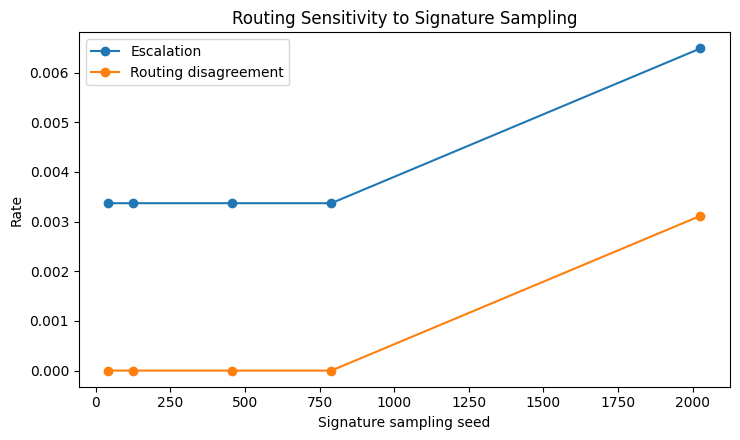

In [ ]:
# BLOCK R3C: SIGNATURE-INDUCED ROUTING STABILITY WITH FROZEN POLICY
# Reports variation in similarity, routing agreement, ANMR, FBR, escalation across signature seeds.

sig_route_records=[]
reference_actions=None
for seed in CONFIG['signature_stability_seeds']:
    bank=signature_banks[SELECTED_SIGNATURE_SAMPLE_SIZE][seed]
    Xp=transform_features(policy_dev_df)
    yp=encode_active_labels(policy_dev_df['label'],zero_day_value=None)
    res=evaluate_final_policy(lgb_model,calibrators,bank,Xp,yp,f'PolicyDev | signature-seed={seed}',return_decisions=True)
    log=res.pop('_Decision_Log')
    if reference_actions is None: reference_actions=log['Action'].to_numpy(copy=True)
    agreement=float(np.mean(log['Action'].to_numpy()==reference_actions))
    sim_mean=float(np.nanmean(log['Similarity'])) if np.any(np.isfinite(log['Similarity'])) else np.nan
    sig_route_records.append({'Signature_Seed':seed,'Mean_Verified_Similarity':sim_mean,
                              'Routing_Agreement_vs_Seed42':agreement,
                              'ANMR':res['ANMR'],'FBR':res['FBR'],'Escalation_Rate':res['Escalation_Rate'],
                              'Attribution_Fraction':res['Attribution_Fraction']})

signature_routing_stability_df=pd.DataFrame(sig_route_records)
print('\n[Reviewer 3] Routing stability across signature seeds')
print(signature_routing_stability_df.to_string(index=False))
signature_routing_stability_df.to_csv(os.path.join(REV_TABLE_DIR,'R3_signature_routing_stability.csv'),index=False)

plt.figure(figsize=(7.5,4.5))
plt.plot(signature_routing_stability_df['Signature_Seed'],signature_routing_stability_df['Escalation_Rate'],marker='o',label='Escalation')
plt.plot(signature_routing_stability_df['Signature_Seed'],1-signature_routing_stability_df['Routing_Agreement_vs_Seed42'],marker='o',label='Routing disagreement')
plt.xlabel('Signature sampling seed'); plt.ylabel('Rate'); plt.title('Routing Sensitivity to Signature Sampling')
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(REV_FIG_DIR,'R3_signature_routing_sensitivity.png'),dpi=220)
plt.show()


## Post-Freeze Signature Operational Sensitivity Diagnostic
This diagnostic is intentionally executed only after the development-selected routing policy has been frozen. It does not select the signature sample size or tune policy thresholds.



[Reviewer 3] Operational sensitivity to canonical signature sample size

[Evaluation] PolicyDev | signature-size=20
[Frozen development-selected policy]
TAU_P                                      = 0.6
TAU_S                                      = 0.01
Benign probability threshold               = 0.9
Benign similarity threshold                = 0.4
High-confidence benign probability threshold = 0.9995
High-confidence benign similarity floor      = 0.04
Benign direct probability threshold         = 0.997506002978633
Benign direct margin threshold              = 0.9965651887679206
Attack direct probability threshold         = 0.9973653080348566
Attack direct margin threshold              = 0.9964279546471227
Similarity metric                           = Euclidean

[Evaluation] PolicyDev | signature-size=40
[Frozen development-selected policy]
TAU_P                                      = 0.6
TAU_S                                      = 0.01
Benign probability threshold               = 0.9

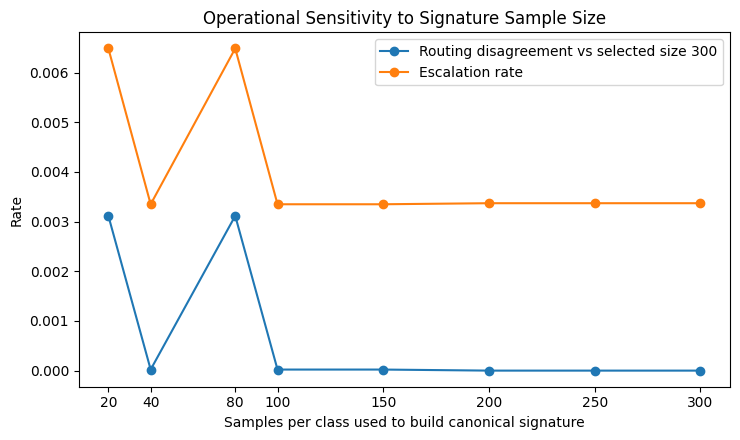


DIAGNOSTIC AUDIT
Dataset used             : policy_dev_df
Model retrained          : NO
Calibrators retrained    : NO
Thresholds retuned       : NO
Similarity reselected    : NO
Similarity metric        : Euclidean
Signature seed fixed     : 42
Signature sizes compared : [20, 40, 80, 100, 150, 200, 250, 300]


In [ ]:
# ======================================================================================
# R3B-DIAGNOSTIC: OPERATIONAL SENSITIVITY TO SIGNATURE SAMPLE SIZE
# ======================================================================================
# Purpose:
# Determine whether increasing the number of samples used to construct each
# canonical SHAP signature materially changes downstream routing behavior.
#
# IMPORTANT:
# - Development data only (policy_dev_df)
# - No threshold tuning
# - Same trained model
# - Same calibrators
# - Same frozen routing policy
# - Same similarity metric
# - Same reference signature seed
# - ONLY signature sample size changes: 20, 40, 80, 100, 150, 200, 250, 300
# ======================================================================================

print("\n" + "=" * 100)
print("[Reviewer 3] Operational sensitivity to canonical signature sample size")
print("=" * 100)

SIGNATURE_SAMPLE_SIZES_TO_COMPARE = [20, 40, 80, 100, 150, 200, 250, 300]

Xp = transform_features(policy_dev_df)
yp = encode_active_labels(
    policy_dev_df["label"],
    zero_day_value=None
)

sample_size_records = []
sample_size_decisions = {}

# Use exactly the same signature sampling seed for every sample size.
comparison_seed = int(CONFIG["signature_stability_seeds"][0])

for sample_size in SIGNATURE_SAMPLE_SIZES_TO_COMPARE:

    if sample_size not in signature_banks:
        raise KeyError(
            f"Signature bank for sample size {sample_size} was not constructed."
        )

    if comparison_seed not in signature_banks[sample_size]:
        raise KeyError(
            f"Signature bank for sample size {sample_size}, "
            f"seed {comparison_seed} was not constructed."
        )

    bank = signature_banks[sample_size][comparison_seed]

    res = evaluate_final_policy(
        lgb_model,
        calibrators,
        bank,
        Xp,
        yp,
        f"PolicyDev | signature-size={sample_size}",
        return_decisions=True
    )

    log = res.pop("_Decision_Log")

    actions = log["Action"].to_numpy(copy=True)
    sample_size_decisions[sample_size] = actions

    similarity = log["Similarity"].to_numpy(dtype=float)

    finite_similarity = np.isfinite(similarity)

    mean_similarity = (
        float(np.mean(similarity[finite_similarity]))
        if np.any(finite_similarity)
        else np.nan
    )

    sample_size_records.append({
        "Signature_Sample_Size": sample_size,
        "Signature_Seed": comparison_seed,
        "Mean_Verified_Similarity": mean_similarity,
        "ANMR": res["ANMR"],
        "FBR": res["FBR"],
        "Escalation_Rate": res["Escalation_Rate"],
        "Attribution_Fraction": res["Attribution_Fraction"]
    })


# ----------------------------------------------------------------------
# Routing agreement relative to the selected 150-sample signature
# ----------------------------------------------------------------------

reference_size = SELECTED_SIGNATURE_SAMPLE_SIZE
reference_actions = sample_size_decisions[reference_size]

for record in sample_size_records:

    sample_size = record["Signature_Sample_Size"]

    actions = sample_size_decisions[sample_size]

    agreement = float(
        np.mean(actions == reference_actions)
    )

    record["Routing_Agreement_vs_SelectedSize"] = agreement
    record["Routing_Disagreement_vs_SelectedSize"] = 1.0 - agreement


signature_sample_size_operational_df = pd.DataFrame(
    sample_size_records
)

# Reorder for readability
signature_sample_size_operational_df = (
    signature_sample_size_operational_df[
        [
            "Signature_Sample_Size",
            "Signature_Seed",
            "Mean_Verified_Similarity",
            "Routing_Agreement_vs_SelectedSize",
            "Routing_Disagreement_vs_SelectedSize",
            "ANMR",
            "FBR",
            "Escalation_Rate",
            "Attribution_Fraction"
        ]
    ]
    .sort_values("Signature_Sample_Size")
    .reset_index(drop=True)
)


print("\nOperational results:")
print(
    signature_sample_size_operational_df.to_string(
        index=False
    )
)


# ----------------------------------------------------------------------
# Pairwise routing agreement between ALL sample sizes
# ----------------------------------------------------------------------

agreement_matrix = pd.DataFrame(
    index=SIGNATURE_SAMPLE_SIZES_TO_COMPARE,
    columns=SIGNATURE_SAMPLE_SIZES_TO_COMPARE,
    dtype=float
)

for size_a in SIGNATURE_SAMPLE_SIZES_TO_COMPARE:
    for size_b in SIGNATURE_SAMPLE_SIZES_TO_COMPARE:

        agreement_matrix.loc[size_a, size_b] = float(
            np.mean(
                sample_size_decisions[size_a] == sample_size_decisions[size_b]


            )
        )

agreement_matrix.index.name = "Signature_Sample_Size"
agreement_matrix.columns.name = "Compared_With"


print("\nPairwise routing agreement:")
print(agreement_matrix.to_string())


# ----------------------------------------------------------------------
# Save
# ----------------------------------------------------------------------

signature_sample_size_operational_df.to_csv(
    os.path.join(
        REV_TABLE_DIR,
        "R3_signature_sample_size_operational_sensitivity.csv"
    ),
    index=False
)

agreement_matrix.to_csv(
    os.path.join(
        REV_TABLE_DIR,
        "R3_signature_sample_size_pairwise_routing_agreement.csv"
    )
)


# ----------------------------------------------------------------------
# Plot
# ----------------------------------------------------------------------

plt.figure(figsize=(7.5, 4.5))

plt.plot(
    signature_sample_size_operational_df["Signature_Sample_Size"],
    signature_sample_size_operational_df["Routing_Disagreement_vs_SelectedSize"],
    marker="o",
    label=f"Routing disagreement vs selected size {SELECTED_SIGNATURE_SAMPLE_SIZE}"
)

plt.plot(
    signature_sample_size_operational_df["Signature_Sample_Size"],
    signature_sample_size_operational_df["Escalation_Rate"],
    marker="o",
    label="Escalation rate"
)

plt.xlabel("Samples per class used to build canonical signature")
plt.ylabel("Rate")
plt.title("Operational Sensitivity to Signature Sample Size")
plt.xticks(SIGNATURE_SAMPLE_SIZES_TO_COMPARE)
plt.legend()
plt.tight_layout()

plt.savefig(
    os.path.join(
        REV_FIG_DIR,
        "R3_signature_sample_size_operational_sensitivity.png"
    ),
    dpi=220
)

plt.show()


# ----------------------------------------------------------------------
# Simple audit
# ----------------------------------------------------------------------

print("\n" + "=" * 100)
print("DIAGNOSTIC AUDIT")
print("=" * 100)

print("Dataset used             : policy_dev_df")
print("Model retrained          : NO")
print("Calibrators retrained    : NO")
print("Thresholds retuned       : NO")
print("Similarity reselected    : NO")
print("Similarity metric        :", SELECTED_SIMILARITY_METRIC)
print("Signature seed fixed     :", comparison_seed)
print(
    "Signature sizes compared :",
    SIGNATURE_SAMPLE_SIZES_TO_COMPARE
)
print("=" * 100)


### Signature-bank sanity checks

Signature variability and stability are audited in the preceding R3 blocks; no duplicate standalone sanity-check cell is retained.


# Stage 8 — Four-Family LOAFO Simulated Zero-Day Evaluation

Four heterogeneous BCCC attack families are evaluated by leave-one-attack-family-out retraining. Each held-out family is absent from its corresponding local training/development process.



[R6] FINAL PRIMARY LOAFO DESIGN

FINAL zero-day families — evaluation only:
   Port_Scan
   DoS_GoldenEye
   DoS_Slowhttptest
   FTP-Patator

Primary policy thresholds:
  FINAL_TAU_P                            = 0.6
  FINAL_TAU_S                            = 0.01
  FINAL_BENIGN_PROB_TAU                  = 0.9
  FINAL_BENIGN_SIM_TAU                   = 0.4
  FINAL_HIGH_CONF_BENIGN_PROB_TAU        = 0.9995
  FINAL_HIGH_CONF_BENIGN_SIM_FLOOR       = 0.04
  FINAL_BENIGN_DIRECT_PROB               = 0.997506002978633
  FINAL_BENIGN_DIRECT_MARGIN             = 0.9965651887679206
  FINAL_ATTACK_DIRECT_PROB               = 0.9973653080348566
  FINAL_ATTACK_DIRECT_MARGIN             = 0.9964279546471227

PASS: Primary thresholds remain automatically selected/frozen FINAL_* values.
PASS: No manually chosen R6 routing threshold is introduced.

[Reviewer 6] Fixed FINAL LOAFO benign safety subset
Benign evaluation rows : 60195
Selection seed         : 42
Shared by final families: YES
Excluded from 

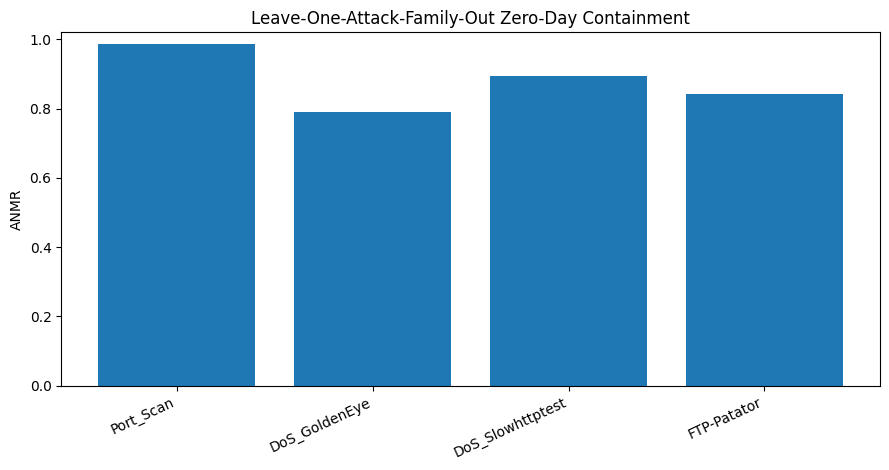


[R6] PRIMARY-ONLY LOAFO DESIGN AUDIT
PASS: Final zero-day families are exactly: Port_Scan, DoS_GoldenEye, DoS_Slowhttptest, FTP-Patator
PASS: Entire held-out attack family is excluded from local model development.
PASS: Fixed benign evaluation subset is excluded from local model development.
PASS: LOAFO preprocessing is fitted on local Train only.
PASS: LOAFO probability calibration is fitted on local Calibration only.
PASS: LOAFO SHAP signatures are rebuilt from local Train only.
PASS: SELECTED_SIGNATURE_SAMPLE_SIZE remains globally frozen.
PASS: SELECTED_SIMILARITY_METRIC remains globally frozen.
PASS: Automatically selected FINAL_* routing/selective thresholds remain globally frozen.
PASS: No LOAFO-family-specific similarity or policy threshold tuning occurs.
PASS: Final zero-day evaluation uses ALL held-out-family attack flows plus the SAME fixed benign safety subset.
PASS: Secondary resolver removed completely.
PASS: No Traffic+Confidence/OOD meta-model, pseudo-zero-day secondary

In [ ]:
# =============================================================================
# BLOCK R6: MULTI-FAMILY LOAFO ZERO-DAY EVALUATION
#
# FINAL ZERO-DAY FAMILIES (evaluated independently by LOAFO):
#   1. Port_Scan
#   2. DoS_GoldenEye
#   3. DoS_Slowhttptest
#   4. FTP-Patator
#
# PRIMARY SYSTEM ONLY:
#   - Each held-out attack family is excluded completely from its local
#     training/development data.
#   - Each LOAFO run rebuilds its local known-class LightGBM model.
#   - Probability calibration is rebuilt locally.
#   - SHAP signatures are rebuilt locally from local Train only.
#   - SELECTED_SIGNATURE_SAMPLE_SIZE remains globally frozen.
#   - SELECTED_SIMILARITY_METRIC remains globally frozen.
#   - The automatically selected GLOBAL FINAL_* routing thresholds remain
#     unchanged.
#   - No LOAFO-family-specific similarity selection or threshold tuning occurs.
#   - Final evaluation uses ALL held-out-family attack rows plus the SAME fixed
#     benign safety subset.
#
# PRIMARY ACTIONS:
#   BLOCK / ESCALATE / ALLOW
#
# FINAL REVIEW OUTPUT:
#   Holdout_Family
#   ANMR
#   FBR
#   Attack_Escalation_Rate
#   Attack_Block_Rate
#   Attack_Allow_Rate
#   Attribution_Fraction
#
# IMPORTANT:
#   There is NO secondary resolver, no Traffic+Confidence/OOD meta-model,
#   no pseudo-zero-day secondary training, and no secondary threshold search.
# =============================================================================

import os
import gc
import time
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.calibration import IsotonicRegression


# =============================================================================
# 0. FINAL ZERO-DAY DESIGN
# =============================================================================

R6_FINAL_ZERO_DAY_FAMILIES = [
    "Port_Scan",
    "DoS_GoldenEye",
    "DoS_Slowhttptest",
    "FTP-Patator",
]

# Keep CONFIG synchronized so later cells see the same final design.
CONFIG["loafo_families"] = list(R6_FINAL_ZERO_DAY_FAMILIES)

_all_attack_classes_r6 = [
    str(x)
    for x in sorted(df_clean["label"].dropna().unique())
    if str(x) != "Benign"
]

missing_final = [
    x
    for x in R6_FINAL_ZERO_DAY_FAMILIES
    if x not in set(_all_attack_classes_r6)
]

if missing_final:
    raise RuntimeError(
        f"Requested final zero-day classes are absent: {missing_final}"
    )

print("\n" + "=" * 120)
print("[R6] FINAL PRIMARY LOAFO DESIGN")
print("=" * 120)

print("\nFINAL zero-day families — evaluation only:")
for _fam in R6_FINAL_ZERO_DAY_FAMILIES:
    print("  ", _fam)

print("\nPrimary policy thresholds:")
print("  FINAL_TAU_P                            =", float(FINAL_TAU_P))
print("  FINAL_TAU_S                            =", float(FINAL_TAU_S))
print("  FINAL_BENIGN_PROB_TAU                  =", float(FINAL_BENIGN_PROB_TAU))
print("  FINAL_BENIGN_SIM_TAU                   =", float(FINAL_BENIGN_SIM_TAU))
print(
    "  FINAL_HIGH_CONF_BENIGN_PROB_TAU        =",
    float(FINAL_HIGH_CONF_BENIGN_PROB_TAU),
)
print(
    "  FINAL_HIGH_CONF_BENIGN_SIM_FLOOR       =",
    float(FINAL_HIGH_CONF_BENIGN_SIM_FLOOR),
)
print(
    "  FINAL_BENIGN_DIRECT_PROB               =",
    float(FINAL_BENIGN_DIRECT_PROB),
)
print(
    "  FINAL_BENIGN_DIRECT_MARGIN             =",
    float(FINAL_BENIGN_DIRECT_MARGIN),
)
print(
    "  FINAL_ATTACK_DIRECT_PROB               =",
    float(FINAL_ATTACK_DIRECT_PROB),
)
print(
    "  FINAL_ATTACK_DIRECT_MARGIN             =",
    float(FINAL_ATTACK_DIRECT_MARGIN),
)

print("\nPASS: Primary thresholds remain automatically selected/frozen FINAL_* values.")
print("PASS: No manually chosen R6 routing threshold is introduced.")


# =============================================================================
# 1. GENERIC LIGHTGBM PREDICTED-CLASS SHAP CONTRIBUTIONS
# =============================================================================

def generic_pred_contrib(model, X, pred_idx, class_count):
    X = np.asarray(X, dtype=np.float32)
    pred_idx = np.asarray(pred_idx, dtype=int)

    nf = X.shape[1]

    raw = np.asarray(
        model.predict(
            X,
            pred_contrib=True,
        )
    )

    if (
        raw.ndim == 2
        and raw.shape[1] == class_count * (nf + 1)
    ):
        raw = raw.reshape(
            len(X),
            class_count,
            nf + 1,
        )

    if (
        raw.ndim == 3
        and raw.shape[1] == class_count
    ):
        return raw[
            np.arange(len(X)),
            pred_idx,
            :-1,
        ]

    if (
        raw.ndim == 3
        and raw.shape[2] == class_count
    ):
        return raw[
            np.arange(len(X)),
            :-1,
            pred_idx,
        ]

    raise ValueError(
        f"Unexpected contribution shape {raw.shape}"
    )


# =============================================================================
# 2. FIXED FINAL BENIGN SAFETY SUBSET
# =============================================================================

_LOAFO_BENIGN_POOL_POS = np.flatnonzero(
    df_clean["label"].eq("Benign").to_numpy()
)

_LOAFO_BENIGN_TARGET = int(
    np.sum(
        hard_test_df["label"].to_numpy()
        == "Benign"
    )
)

_LOAFO_BENIGN_TARGET = max(
    1,
    min(
        _LOAFO_BENIGN_TARGET,
        len(_LOAFO_BENIGN_POOL_POS),
    ),
)

_LOAFO_BENIGN_RNG = np.random.default_rng(
    RANDOM_STATE
)

LOAFO_BENIGN_TEST_INDICES = np.sort(
    _LOAFO_BENIGN_RNG.choice(
        _LOAFO_BENIGN_POOL_POS,
        size=_LOAFO_BENIGN_TARGET,
        replace=False,
    )
)

print("\n[Reviewer 6] Fixed FINAL LOAFO benign safety subset")
print("Benign evaluation rows :", len(LOAFO_BENIGN_TEST_INDICES))
print("Selection seed         :", RANDOM_STATE)
print("Shared by final families: YES")
print("Excluded from final LOAFO training: YES")


# =============================================================================
# 3. LOCAL LOAFO PROBABILITY CALIBRATION
# =============================================================================

def _loafo_calibrated_probabilities(
    model,
    calibrators,
    X,
    class_count,
):
    X = np.asarray(
        X,
        dtype=np.float32,
    )

    raw = np.asarray(
        model.predict(X),
        dtype=float,
    )

    calibrated = np.zeros_like(
        raw,
        dtype=float,
    )

    for class_idx in range(class_count):
        calibrated[:, class_idx] = calibrators[
            class_idx
        ].transform(
            raw[:, class_idx]
        )

    row_sum = calibrated.sum(
        axis=1,
        keepdims=True,
    )

    row_sum[
        row_sum <= 1e-12
    ] = 1.0

    return calibrated / row_sum


# =============================================================================
# 4. LOCAL LOAFO SHAP SIMILARITY
# =============================================================================

def _loafo_similarity(
    model,
    bank,
    X,
    pred,
    pred_names,
    class_count,
):
    X = np.asarray(
        X,
        dtype=np.float32,
    )

    pred = np.asarray(
        pred,
        dtype=int,
    )

    pred_names = np.asarray(
        pred_names,
        dtype=object,
    )

    if len(X) == 0:
        return np.zeros(
            0,
            dtype=float,
        )

    attrs = generic_pred_contrib(
        model,
        X,
        pred,
        class_count,
    )

    normalized = _row_l2_normalize(
        attrs
    )

    similarities = np.zeros(
        len(X),
        dtype=float,
    )

    for class_name in np.unique(pred_names):
        mask = (
            pred_names
            == class_name
        )

        similarities[mask] = _similarity_scores_from_normalized(
            normalized[mask],
            bank[class_name],
            SELECTED_SIMILARITY_METRIC,
        )

    return similarities


# =============================================================================
# 5. PRIMARY GLOBAL-FROZEN SELECTIVE SHAP EVALUATOR
# =============================================================================

def evaluate_loafo_selective(
    artifact,
    tag=None,
    return_decisions=False,
):
    """
    Primary LOAFO evaluator.

    Uses:
      - local LOAFO model
      - local probability calibration
      - local SHAP signatures
      - GLOBAL SELECTED_SIMILARITY_METRIC
      - automatically selected GLOBAL FINAL_* policy thresholds
    """

    model = artifact["Model"]
    calibrators = artifact["Calibrators"]
    bank = artifact["Signatures"]
    names = artifact["Names"]
    benign_index = int(artifact["Benign_Index"])
    class_count = int(artifact["Class_Count"])

    X = np.asarray(
        artifact["X_Eval"],
        dtype=np.float32,
    )

    true_names = np.asarray(
        artifact["True_Names"],
        dtype=object,
    )

    tag = (
        tag
        or f"Zero-Day LOAFO: {artifact['Holdout_Family']}"
    )

    total_start = time.perf_counter()

    probability_start = time.perf_counter()

    probs = _loafo_calibrated_probabilities(
        model,
        calibrators,
        X,
        class_count,
    )

    probability_time = (
        time.perf_counter()
        - probability_start
    )

    pred = np.argmax(
        probs,
        axis=1,
    )

    pred_names = np.asarray(
        [
            names[idx]
            for idx in pred
        ],
        dtype=object,
    )

    benign_probability = probs[
        :,
        benign_index,
    ]

    attack_confidence = (
        1.0
        - benign_probability
    )

    sorted_probs = np.sort(
        probs,
        axis=1,
    )

    margin = (
        sorted_probs[:, -1]
        - sorted_probs[:, -2]
    )

    max_probability = sorted_probs[
        :,
        -1,
    ]

    direct_allow = (
        (pred_names == "Benign")
        & (
            benign_probability
            >= float(FINAL_BENIGN_DIRECT_PROB)
        )
        & (
            margin
            >= float(FINAL_BENIGN_DIRECT_MARGIN)
        )
    )

    direct_block = (
        (pred_names != "Benign")
        & (
            attack_confidence
            >= float(FINAL_TAU_P)
        )
        & (
            max_probability
            >= float(FINAL_ATTACK_DIRECT_PROB)
        )
        & (
            margin
            >= float(FINAL_ATTACK_DIRECT_MARGIN)
        )
    )

    unresolved = ~(
        direct_allow
        | direct_block
    )

    actions = np.full(
        len(X),
        "ESCALATE",
        dtype=object,
    )

    actions[direct_allow] = "ALLOW"
    actions[direct_block] = "BLOCK"

    similarities = np.full(
        len(X),
        np.nan,
        dtype=float,
    )

    attribution_time = 0.0

    if np.any(unresolved):
        attribution_start = time.perf_counter()

        unresolved_similarity = _loafo_similarity(
            model,
            bank,
            X[unresolved],
            pred[unresolved],
            pred_names[unresolved],
            class_count,
        )

        attribution_time = (
            time.perf_counter()
            - attribution_start
        )

        similarities[
            unresolved
        ] = unresolved_similarity

        routed = route_policy_batch(
            pred_names[unresolved],
            attack_confidence[unresolved],
            unresolved_similarity,
            float(FINAL_TAU_P),
            float(FINAL_TAU_S),
            float(FINAL_BENIGN_PROB_TAU),
            float(FINAL_BENIGN_SIM_TAU),
            float(FINAL_HIGH_CONF_BENIGN_PROB_TAU),
            float(FINAL_HIGH_CONF_BENIGN_SIM_FLOOR),
        )

        actions[unresolved] = np.asarray(
            routed["actions"],
            dtype=object,
        )

    total_time = (
        time.perf_counter()
        - total_start
    )

    true_benign = (
        true_names
        == "Benign"
    )

    true_malicious = ~true_benign

    attack_rows = max(
        int(np.sum(true_malicious)),
        1,
    )

    benign_rows = max(
        int(np.sum(true_benign)),
        1,
    )

    attack_block_rate = float(
        np.sum(
            true_malicious
            & (actions == "BLOCK")
        )
        / attack_rows
    )

    attack_escalation_rate = float(
        np.sum(
            true_malicious
            & (actions == "ESCALATE")
        )
        / attack_rows
    )

    attack_allow_rate = float(
        np.sum(
            true_malicious
            & (actions == "ALLOW")
        )
        / attack_rows
    )

    if not np.isclose(
        attack_block_rate
        + attack_escalation_rate
        + attack_allow_rate,
        1.0,
        atol=1e-10,
    ):
        raise RuntimeError(
            "Primary attack BLOCK/ESCALATE/ALLOW rates do not sum to 1."
        )

    result = {
        "Environment": tag,

        "ANMR": float(
            1.0
            - attack_allow_rate
        ),

        "FBR": float(
            np.sum(
                true_benign
                & (actions == "BLOCK")
            )
            / benign_rows
        ),

        "Attack_Block_Rate": attack_block_rate,
        "Attack_Escalation_Rate": attack_escalation_rate,
        "Attack_Allow_Rate": attack_allow_rate,

        "Overall_Escalation_Rate": float(
            np.mean(
                actions == "ESCALATE"
            )
        ),

        "Attribution_Fraction": float(
            np.mean(unresolved)
        ),

        "Probability_Latency_ms_per_flow": float(
            1000.0
            * probability_time
            / max(len(X), 1)
        ),

        "Attribution_Latency_ms_per_flow": float(
            1000.0
            * attribution_time
            / max(len(X), 1)
        ),

        "End_to_End_Latency_ms_per_flow": float(
            1000.0
            * total_time
            / max(len(X), 1)
        ),

        "Throughput_flows_per_sec": float(
            len(X)
            / max(total_time, 1e-12)
        ),

        "Allow_Count": int(
            np.sum(
                actions == "ALLOW"
            )
        ),

        "Block_Count": int(
            np.sum(
                actions == "BLOCK"
            )
        ),

        "Escalate_Count": int(
            np.sum(
                actions == "ESCALATE"
            )
        ),

        "Attack_Rows": int(
            np.sum(true_malicious)
        ),

        "Benign_Rows": int(
            np.sum(true_benign)
        ),

        "Evaluation_Rows": int(
            len(X)
        ),

        "Attribution_Count": int(
            np.sum(unresolved)
        ),
    }

    if return_decisions:
        result["Actions"] = actions
        result["Predicted_Names"] = pred_names
        result["Predicted_Indices"] = pred
        result["Probabilities"] = probs
        result["Similarities"] = similarities
        result["Unresolved"] = unresolved

    return result


# =============================================================================
# 6. LOCAL LOAFO ARTIFACT BUILDER
#
# Builds one local zero-day experiment.
#
# The held-out attack family and fixed benign evaluation rows are excluded
# from local model development. Optional exclusion arguments are retained
# only as generic safeguards; this final R6 block does not use a secondary
# resolver or pseudo-zero-day development stage.
# =============================================================================

def _build_local_loafo_artifact(
    full_frame,
    holdout_name,
    benign_eval_indices,
    seed=42,
    permanently_excluded_attacks=None,
    extra_excluded_row_indices=None,
):
    frame = (
        full_frame
        .copy()
        .reset_index(drop=True)
    )

    frame["_LOAFO_ROW_ID"] = np.arange(
        len(frame),
        dtype=np.int64,
    )

    permanently_excluded_attacks = set(
        permanently_excluded_attacks
        or []
    )

    # Holdout itself is evaluated, not trained.
    permanently_excluded_attacks.discard(
        holdout_name
    )

    benign_eval_indices = np.asarray(
        benign_eval_indices,
        dtype=np.int64,
    )

    if extra_excluded_row_indices is None:
        extra_excluded_row_indices = np.zeros(
            0,
            dtype=np.int64,
        )
    else:
        extra_excluded_row_indices = np.asarray(
            extra_excluded_row_indices,
            dtype=np.int64,
        )

    benign_eval = frame[
        frame["_LOAFO_ROW_ID"].isin(
            benign_eval_indices
        )
    ].copy()

    hold = frame[
        frame["label"]
        == holdout_name
    ].copy()

    excluded_training_rows = np.union1d(
        benign_eval_indices,
        extra_excluded_row_indices,
    )

    known_mask = (
        frame["label"].ne(holdout_name)
        & (
            ~frame["_LOAFO_ROW_ID"].isin(
                excluded_training_rows
            )
        )
    )

    if permanently_excluded_attacks:
        known_mask &= (
            ~frame["label"].isin(
                permanently_excluded_attacks
            )
        )

    known = (
        frame[
            known_mask
        ]
        .copy()
        .reset_index(drop=True)
    )

    if len(hold) == 0:
        raise ValueError(
            f"LOAFO holdout family is empty: {holdout_name}"
        )

    if len(benign_eval) == 0:
        raise ValueError(
            "LOAFO benign evaluation subset is empty."
        )

    forbidden = (
        set(permanently_excluded_attacks)
        | {holdout_name}
    )

    leaked = forbidden.intersection(
        set(
            known["label"].unique()
        )
    )

    if leaked:
        raise RuntimeError(
            f"LOAFO leakage into known-class development: {sorted(leaked)}"
        )

    names = [
        "Benign"
    ] + sorted(
        [
            label
            for label in known[
                "label"
            ].unique()
            if label != "Benign"
        ]
    )

    cmap = {
        name: idx
        for idx, name in enumerate(names)
    }

    benign_index = cmap["Benign"]
    class_count = len(names)

    train_local, dev_local = train_test_split(
        known,
        test_size=0.28,
        random_state=seed,
        stratify=known["label"],
    )

    early_local, remaining_dev = train_test_split(
        dev_local,
        test_size=0.75,
        random_state=seed,
        stratify=dev_local["label"],
    )

    calibration_local, _unused_local = train_test_split(
        remaining_dev,
        test_size=0.50,
        random_state=seed + 1,
        stratify=remaining_dev["label"],
    )

    for split_name, split_frame in {
        "Train": train_local,
        "EarlyStopping": early_local,
        "Calibration": calibration_local,
    }.items():
        leaked_here = forbidden.intersection(
            set(
                split_frame[
                    "label"
                ].unique()
            )
        )

        if leaked_here:
            raise RuntimeError(
                f"LOAFO leakage in {split_name}: {sorted(leaked_here)}"
            )

    local_preprocessor = fit_feature_preprocessor(
        train_local,
        expected_features,
    )

    X_train_local = transform_features(
        train_local,
        local_preprocessor,
    )

    y_train_local = (
        train_local[
            "label"
        ]
        .map(cmap)
        .astype(int)
        .to_numpy()
    )

    X_early_local = transform_features(
        early_local,
        local_preprocessor,
    )

    y_early_local = (
        early_local[
            "label"
        ]
        .map(cmap)
        .astype(int)
        .to_numpy()
    )

    train_ds = lgb.Dataset(
        X_train_local,
        label=y_train_local,
    )

    early_ds = lgb.Dataset(
        X_early_local,
        label=y_early_local,
        reference=train_ds,
    )

    local_params = {
        "objective": "multiclass",
        "num_class": class_count,
        "metric": "multi_logloss",
        "learning_rate": 0.05,
        "num_leaves": 32,
        "feature_fraction": 0.90,
        "bagging_fraction": 0.90,
        "bagging_freq": 1,
        "seed": seed,
        "bagging_seed": seed,
        "feature_fraction_seed": seed,
        "data_random_seed": seed,
        "verbose": -1,
        "num_threads": max(
            1,
            (os.cpu_count() or 2) - 1,
        ),
    }

    model = lgb.train(
        local_params,
        train_ds,
        num_boost_round=160,
        valid_sets=[early_ds],
        callbacks=[
            lgb.early_stopping(
                12,
                verbose=False,
            )
        ],
    )

    X_cal_local = transform_features(
        calibration_local,
        local_preprocessor,
    )

    y_cal_local = (
        calibration_local[
            "label"
        ]
        .map(cmap)
        .astype(int)
        .to_numpy()
    )

    raw_cal = np.asarray(
        model.predict(
            X_cal_local
        ),
        dtype=float,
    )

    calibrators = {}

    for class_idx in range(class_count):
        target = (
            y_cal_local
            == class_idx
        ).astype(int)

        iso = IsotonicRegression(
            out_of_bounds="clip"
        )

        if len(
            np.unique(target)
        ) < 2:
            iso.fit(
                np.append(
                    raw_cal[:, class_idx],
                    [0.0, 1.0],
                ),
                np.append(
                    target,
                    [0, 1],
                ),
            )
        else:
            iso.fit(
                raw_cal[:, class_idx],
                target,
            )

        calibrators[class_idx] = iso

    # -------------------------------------------------------------------------
    # Local Train-only SHAP signatures.
    # -------------------------------------------------------------------------

    bank = {}

    for class_idx, class_name in enumerate(names):
        rows = np.where(
            y_train_local
            == class_idx
        )[0]

        if len(rows) == 0:
            raise RuntimeError(
                f"No local training rows for class {class_name}."
            )

        rng = np.random.default_rng(
            seed + class_idx
        )

        take = rng.choice(
            rows,
            size=min(
                len(rows),
                int(SELECTED_SIGNATURE_SAMPLE_SIZE),
            ),
            replace=False,
        )

        attrs = generic_pred_contrib(
            model,
            X_train_local[take],
            np.full(
                len(take),
                class_idx,
                dtype=int,
            ),
            class_count,
        )

        normalized = _row_l2_normalize(
            attrs
        )

        signature = np.mean(
            normalized,
            axis=0,
        )

        signature = (
            signature
            / (
                np.linalg.norm(signature)
                + 1e-12
            )
        )

        bank[class_name] = signature.astype(
            np.float32
        )

    X_attack = transform_features(
        hold,
        local_preprocessor,
    )

    X_benign = transform_features(
        benign_eval,
        local_preprocessor,
    )

    X_eval = np.vstack(
        [
            X_attack,
            X_benign,
        ]
    ).astype(
        np.float32,
        copy=False,
    )

    true_names = np.concatenate(
        [
            np.full(
                len(X_attack),
                holdout_name,
                dtype=object,
            ),
            np.full(
                len(X_benign),
                "Benign",
                dtype=object,
            ),
        ]
    )

    # Robust known-class centers for OOD.
    local_class_med = {}
    local_class_iqr = {}

    for class_idx in range(class_count):
        class_rows = X_train_local[
            y_train_local == class_idx
        ].astype(float)

        local_class_med[
            class_idx
        ] = np.nanmedian(
            class_rows,
            axis=0,
        )

        q1 = np.nanquantile(
            class_rows,
            0.25,
            axis=0,
        )

        q3 = np.nanquantile(
            class_rows,
            0.75,
            axis=0,
        )

        local_class_iqr[
            class_idx
        ] = np.maximum(
            q3 - q1,
            1e-6,
        )

    return {
        "Holdout_Family": holdout_name,
        "Seed": int(seed),
        "Model": model,
        "Calibrators": calibrators,
        "Signatures": bank,
        "Names": names,
        "Class_Map": cmap,
        "Benign_Index": benign_index,
        "Class_Count": class_count,
        "Preprocessor": local_preprocessor,
        "Class_Median": local_class_med,
        "Class_IQR": local_class_iqr,
        "Train_Rows": int(len(train_local)),
        "EarlyStopping_Rows": int(len(early_local)),
        "Calibration_Rows": int(len(calibration_local)),
        "X_Eval": X_eval,
        "True_Names": true_names,
    }


# =============================================================================
# 7. FINAL LOAFO RUNS
# =============================================================================

def run_loafo_family(
    full_frame,
    holdout_name,
    seed=42,
    return_artifact=False,
):
    artifact = _build_local_loafo_artifact(
        full_frame=full_frame,
        holdout_name=holdout_name,
        benign_eval_indices=LOAFO_BENIGN_TEST_INDICES,
        seed=seed,
        permanently_excluded_attacks=None,
        extra_excluded_row_indices=None,
    )

    selective = evaluate_loafo_selective(
        artifact,
        tag=f"Zero-Day LOAFO: {holdout_name}",
        return_decisions=True,
    )

    joint = pd.crosstab(
        pd.Series(
            selective["Predicted_Names"],
            name="Mapped_Class",
        ),
        pd.Series(
            selective["Actions"],
            name="Action",
        ),
    )

    summary = {
        "Holdout_Family": holdout_name,
        "Attack_Rows": selective["Attack_Rows"],
        "Benign_Rows": selective["Benign_Rows"],
        "Evaluation_Rows": selective["Evaluation_Rows"],
        "Known_Classes": int(
            artifact["Class_Count"]
        ),
        "Best_Iteration": int(
            artifact["Model"].best_iteration
        ),
        "Similarity_Metric": SELECTED_SIMILARITY_METRIC,
        "ANMR": selective["ANMR"],
        "FBR": selective["FBR"],
        "Attack_Block_Rate": selective["Attack_Block_Rate"],
        "Attack_Escalation_Rate": selective["Attack_Escalation_Rate"],
        "Attack_Allow_Rate": selective["Attack_Allow_Rate"],
        "Overall_Escalation_Rate": selective["Overall_Escalation_Rate"],
        "Attribution_Fraction": selective["Attribution_Fraction"],
        "Probability_Latency_ms_per_flow": selective["Probability_Latency_ms_per_flow"],
        "Attribution_Latency_ms_per_flow": selective["Attribution_Latency_ms_per_flow"],
        "End_to_End_Latency_ms_per_flow": selective["End_to_End_Latency_ms_per_flow"],
        "Throughput_flows_per_sec": selective["Throughput_flows_per_sec"],
        "Policy": "GLOBAL Frozen Confidence-Guided Selective SHAP",
        "Joint_Table": joint,
    }

    if return_artifact:
        return summary, artifact

    return summary


loafo_results = []
LOAFO_JOINT_TABLES = {}
LOAFO_EXPERIMENTS = {}

for family in R6_FINAL_ZERO_DAY_FAMILIES:
    print("\nRunning FINAL LOAFO:", family)

    result_row, artifact = run_loafo_family(
        df_clean,
        family,
        RANDOM_STATE,
        return_artifact=True,
    )

    LOAFO_EXPERIMENTS[
        family
    ] = artifact

    LOAFO_JOINT_TABLES[
        family
    ] = result_row.pop(
        "Joint_Table"
    )

    loafo_results.append(
        result_row
    )

loafo_results_df = pd.DataFrame(
    loafo_results
)

print("\n" + "=" * 120)
print("[R6] PRIMARY LOAFO BASELINE")
print("=" * 120)

print(
    loafo_results_df[
        [
            "Holdout_Family",
            "ANMR",
            "FBR",
            "Attack_Escalation_Rate",
            "Attack_Block_Rate",
            "Attack_Allow_Rate",
            "Attribution_Fraction",
        ]
    ].to_string(
        index=False
    )
)



# =============================================================================
# 8. PRIMARY LOAFO REVIEW TABLE
# =============================================================================

R6_FINAL_PRIMARY_REVIEW_DF = (
    loafo_results_df[
        [
            "Holdout_Family",
            "ANMR",
            "FBR",
            "Attack_Escalation_Rate",
            "Attack_Block_Rate",
            "Attack_Allow_Rate",
            "Attribution_Fraction",
        ]
    ]
    .copy()
)

print("\n" + "=" * 120)
print("[R6 FINAL REVIEW] PRIMARY CONFIDENCE-GUIDED SELECTIVE SHAP ONLY")
print("=" * 120)

print(
    R6_FINAL_PRIMARY_REVIEW_DF.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}",
    )
)


# =============================================================================
# 9. SAVE PRIMARY-ONLY OUTPUTS
# =============================================================================

R6_FINAL_PRIMARY_REVIEW_DF.to_csv(
    os.path.join(
        REV_TABLE_DIR,
        "R6_primary_LOAFO_zero_day_results.csv",
    ),
    index=False,
)

loafo_results_df.to_csv(
    os.path.join(
        REV_TABLE_DIR,
        "R6_primary_LOAFO_zero_day_full_diagnostics.csv",
    ),
    index=False,
)

for family, table in LOAFO_JOINT_TABLES.items():
    table.to_csv(
        os.path.join(
            REV_TABLE_DIR,
            f"R6_primary_LOAFO_joint_mapping_routing_{family}.csv",
        )
    )


# =============================================================================
# 10. PRIMARY LOAFO ANMR PLOT
# =============================================================================

plt.figure(
    figsize=(9, 4.8)
)

plt.bar(
    R6_FINAL_PRIMARY_REVIEW_DF[
        "Holdout_Family"
    ],
    R6_FINAL_PRIMARY_REVIEW_DF[
        "ANMR"
    ],
)

plt.ylabel(
    "ANMR"
)

plt.ylim(
    0,
    1.02,
)

plt.title(
    "Leave-One-Attack-Family-Out Zero-Day Containment"
)

plt.xticks(
    rotation=25,
    ha="right",
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        REV_FIG_DIR,
        "R6_primary_LOAFO_zero_day_ANMR.png",
    ),
    dpi=220,
)

plt.show()


# =============================================================================
# 11. PRIMARY-ONLY DESIGN AUDIT
# =============================================================================

print("\n" + "=" * 120)
print("[R6] PRIMARY-ONLY LOAFO DESIGN AUDIT")
print("=" * 120)

print(
    "PASS: Final zero-day families are exactly: "
    + ", ".join(R6_FINAL_ZERO_DAY_FAMILIES)
)

print(
    "PASS: Entire held-out attack family is excluded from local model development."
)

print(
    "PASS: Fixed benign evaluation subset is excluded from local model development."
)

print(
    "PASS: LOAFO preprocessing is fitted on local Train only."
)

print(
    "PASS: LOAFO probability calibration is fitted on local Calibration only."
)

print(
    "PASS: LOAFO SHAP signatures are rebuilt from local Train only."
)

print(
    "PASS: SELECTED_SIGNATURE_SAMPLE_SIZE remains globally frozen."
)

print(
    "PASS: SELECTED_SIMILARITY_METRIC remains globally frozen."
)

print(
    "PASS: Automatically selected FINAL_* routing/selective thresholds remain globally frozen."
)

print(
    "PASS: No LOAFO-family-specific similarity or policy threshold tuning occurs."
)

print(
    "PASS: Final zero-day evaluation uses ALL held-out-family attack flows "
    "plus the SAME fixed benign safety subset."
)

print(
    "PASS: Secondary resolver removed completely."
)

print(
    "PASS: No Traffic+Confidence/OOD meta-model, pseudo-zero-day secondary "
    "training, secondary calibration, or secondary threshold search remains."
)

print(
    "PASS: Final reported zero-day metrics are primary ANMR, FBR, "
    "attack escalation, block, allow, and attribution fraction."
)

print("=" * 120)


# Stage 9 — Constrained Adversarial Robustness


## Stage 9A — Frozen Constrained Adversarial Matrix Generation

The adversarial threat model is retained from the submitted study: malicious Hard-Test flows are moved **toward the benign training median** under a per-feature **epsilon × training-IQR** budget. Protocol/flag semantics are immutable, benign rows are untouched, and candidate changes are accepted only when they introduce **no new source-relative consistency violation**. The attack recipe is fixed before test evaluation and never uses routing thresholds.


In [ ]:
# BLOCK R5A: CONSTRAINED SCORE-BASED TABULAR EVASION GENERATOR
# Reviewer 5 + submitted-experiment compatibility.
#
# IMPORTANT DESIGN RULES
# - Preserve the submitted threat model: malicious flows move TOWARD the benign
#   training median under an epsilon × training-IQR budget.
# - Protocol/flag variables are immutable.
# - Benign Time-Test rows are never modified.
# - No policy threshold is read or tuned by the attack.
# - No candidate may introduce a NEW violation of the exact R5 consistency rules.
# - epsilon=0 is an exact identity copy of Time-Test.
# - This remains constrained tabular feature-space evasion; packet-level
#   realizability is not claimed.

import numpy as np
import pandas as pd

X_time = transform_features(time_test_df)
y_time = encode_active_labels(time_test_df['label'], None)

# Training-only attack statistics, matching the submitted score-based design.
_adv_train = pd.DataFrame(
    X_train.astype(float),
    columns=expected_features,
    index=train_df.index,
)
ADV_Q1 = _adv_train.quantile(0.25).fillna(0.0).to_numpy(float)
ADV_Q3 = _adv_train.quantile(0.75).fillna(0.0).to_numpy(float)
ADV_SCALE = np.maximum(ADV_Q3 - ADV_Q1, 1e-6)
ADV_TRAIN_MEDIAN = _adv_train.median().fillna(0.0).to_numpy(float)
_adv_benign = _adv_train.loc[train_df['label'].astype(str).eq('Benign')]
ADV_BENIGN_MEDIAN = (_adv_benign.median()
                     .fillna(pd.Series(ADV_TRAIN_MEDIAN, index=expected_features))
                     .to_numpy(float))
_adv_index = {n:i for i,n in enumerate(expected_features)}

# Submitted-study immutability principle: protocol/flag semantics are never modified.
ADV_IMMUTABLE_MASK = np.array([
    ('protocol' in str(n).lower()) or ('flag' in str(n).lower())
    for n in expected_features
], dtype=bool)
ADV_MUTABLE_IDX = np.where(~ADV_IMMUTABLE_MASK)[0]

# Count-like variables remain discrete.
ADV_DISCRETE_MASK = np.array([
    any(tok in str(n).lower() for tok in ('count','packets','bytes','header','win','bulk','subflow'))
    for n in expected_features
], dtype=bool)
# Features that are nonnegative in training remain nonnegative after modification.
ADV_NONNEGATIVE_MASK = (_adv_train.min().fillna(0.0).to_numpy(float) >= 0.0)

# Exact same consistency rules used by the downstream Reviewer-5 audit.
def tabular_consistency_rule_matrix(
    X,
    feature_names
):

    X = np.asarray(
        X,
        dtype=float
    )

    idx = {
        name: i
        for i, name
        in enumerate(feature_names)
    }

    rules = {}


    # -------------------------------------------------------------------------
    # Finite-value rule
    # -------------------------------------------------------------------------

    rules["Finite"] = np.all(
        np.isfinite(X),
        axis=1
    )


    # -------------------------------------------------------------------------
    # Equality helper
    # -------------------------------------------------------------------------

    def eq(
        a,
        b,
        tol=1e-5
    ):

        return np.isclose(
            a,
            b,
            rtol=tol,
            atol=tol,
            equal_nan=False
        )


    # -------------------------------------------------------------------------
    # Packet total
    # -------------------------------------------------------------------------

    required = [
        "fwd_packets_count",
        "bwd_packets_count",
        "packets_count"
    ]

    if all(
        name in idx
        for name in required
    ):

        rules["PacketTotal"] = eq(

            X[
                :,
                idx[
                    "packets_count"
                ]
            ],

            X[
                :,
                idx[
                    "fwd_packets_count"
                ]
            ]
            +
            X[
                :,
                idx[
                    "bwd_packets_count"
                ]
            ]
        )


    # -------------------------------------------------------------------------
    # Payload-byte total
    # -------------------------------------------------------------------------

    required = [
        "fwd_total_payload_bytes",
        "bwd_total_payload_bytes",
        "total_payload_bytes"
    ]

    if all(
        name in idx
        for name in required
    ):

        rules["ByteTotal"] = eq(

            X[
                :,
                idx[
                    "total_payload_bytes"
                ]
            ],

            X[
                :,
                idx[
                    "fwd_total_payload_bytes"
                ]
            ]
            +
            X[
                :,
                idx[
                    "bwd_total_payload_bytes"
                ]
            ]
        )


    # -------------------------------------------------------------------------
    # Subflow relationships
    # -------------------------------------------------------------------------

    subflow_pairs = [

        (
            "subflow_fwd_packets",
            "fwd_packets_count"
        ),

        (
            "subflow_bwd_packets",
            "bwd_packets_count"
        ),

        (
            "subflow_fwd_bytes",
            "fwd_total_payload_bytes"
        ),

        (
            "subflow_bwd_bytes",
            "bwd_total_payload_bytes"
        )
    ]


    for derived_name, source_name in subflow_pairs:

        if (
            derived_name in idx
            and
            source_name in idx
        ):

            rules[
                f"{derived_name}={source_name}"
            ] = eq(

                X[
                    :,
                    idx[
                        derived_name
                    ]
                ],

                X[
                    :,
                    idx[
                        source_name
                    ]
                ]
            )


    # -------------------------------------------------------------------------
    # Average segment-size relationships
    # -------------------------------------------------------------------------

    avg_relations = [

        (
            "fwd_avg_segment_size",
            "fwd_total_payload_bytes",
            "fwd_packets_count"
        ),

        (
            "bwd_avg_segment_size",
            "bwd_total_payload_bytes",
            "bwd_packets_count"
        )
    ]


    for avg_name, byte_name, packet_name in avg_relations:

        if all(
            name in idx
            for name in [
                avg_name,
                byte_name,
                packet_name
            ]
        ):

            target = (

                X[
                    :,
                    idx[
                        byte_name
                    ]
                ]
                /
                np.maximum(
                    X[
                        :,
                        idx[
                            packet_name
                        ]
                    ],
                    1
                )
            )

            rules[
                avg_name
            ] = eq(

                X[
                    :,
                    idx[
                        avg_name
                    ]
                ],

                target,

                tol=1e-4
            )


    # -------------------------------------------------------------------------
    # Down/up packet ratio
    # -------------------------------------------------------------------------

    required = [
        "down_up_rate",
        "fwd_packets_count",
        "bwd_packets_count"
    ]

    if all(
        name in idx
        for name in required
    ):

        target = (

            X[
                :,
                idx[
                    "bwd_packets_count"
                ]
            ]
            /
            np.maximum(
                X[
                    :,
                    idx[
                        "fwd_packets_count"
                    ]
                ],
                1
            )
        )

        rules[
            "DownUpRatio"
        ] = eq(

            X[
                :,
                idx[
                    "down_up_rate"
                ]
            ],

            target,

            tol=1e-4
        )


    # -------------------------------------------------------------------------
    # Min <= mean <= max ordering
    # -------------------------------------------------------------------------

    prefixes = [

        "packet_iat",

        "packets_iat",

        "fwd_packets_iat",

        "bwd_packets_iat",

        "payload_bytes",

        "header_bytes"
    ]


    for prefix in prefixes:

        mn = f"{prefix}_min"
        me = f"{prefix}_mean"
        mx = f"{prefix}_max"

        if all(
            name in idx
            for name in [
                mn,
                me,
                mx
            ]
        ):

            rules[
                f"{prefix}_order"
            ] = (

                (
                    X[
                        :,
                        idx[mn]
                    ] <= X[


                        :,
                        idx[me]
                    ]
                    +
                    1e-9
                )

                &

                (
                    X[
                        :,
                        idx[me]
                    ] <= X[


                        :,
                        idx[mx]
                    ]
                    +
                    1e-9
                )
            )


    # -------------------------------------------------------------------------
    # Convert to DataFrame
    # -------------------------------------------------------------------------

    rule_df = pd.DataFrame(
        rules
    )

    assert len(rule_df) == len(X)

    return rule_df

def _no_new_violation_mask(X_source_rows, X_candidate_rows):
    src = tabular_consistency_rule_matrix(X_source_rows, expected_features).to_numpy(dtype=bool)
    adv = tabular_consistency_rule_matrix(X_candidate_rows, expected_features).to_numpy(dtype=bool)
    return ~np.any(src & (~adv), axis=1)

def _apply_budgeted_candidate(base, feature_mask, epsilon):
    """
    Move selected coordinates toward the benign median while strictly
    preserving the source-relative epsilon × training-IQR budget.

    The final budget is checked after float32 conversion. If float32
    representation causes any mutable coordinate to exceed its budget,
    that coordinate is reverted to its original source value.
    """
    base64 = np.asarray(base, dtype=np.float64)
    candidate = base64.copy()

    # Per-feature source-relative perturbation budget.
    step_cap = float(epsilon) * ADV_SCALE[None, :]

    # Move only toward the benign training median.
    delta_to_target = ADV_BENIGN_MEDIAN[None, :] - base64
    bounded_delta = (
        np.sign(delta_to_target)
        * np.minimum(np.abs(delta_to_target), step_cap)
    )

    effective = (
        np.asarray(feature_mask, dtype=bool)
        & (~ADV_IMMUTABLE_MASK[None, :])
    )
    candidate[effective] = base64[effective] + bounded_delta[effective]

    # Features that are nonnegative in training remain nonnegative.
    nonneg_effective = effective & ADV_NONNEGATIVE_MASK[None, :]
    candidate[nonneg_effective] = np.maximum(
        candidate[nonneg_effective], 0.0
    )

    # Preserve discreteness without allowing rounding to exceed the budget.
    disc_effective = effective & ADV_DISCRETE_MASK[None, :]
    if np.any(disc_effective):
        rounded = np.rint(candidate)
        rounded_delta = np.abs(rounded - base64)
        within_rounding_budget = rounded_delta <= (step_cap + 1e-9)

        use_rounded = disc_effective & within_rounding_budget
        candidate[use_rounded] = rounded[use_rounded]

        # If rounding would exceed the budget, keep the source value.
        revert_rounding = disc_effective & (~within_rounding_budget)
        candidate[revert_rounding] = base64[revert_rounding]

    # Protocol/flag variables are immutable.
    candidate[:, ADV_IMMUTABLE_MASK] = base64[:, ADV_IMMUTABLE_MASK]

    # Convert to the representation actually supplied to the model.
    base32 = np.asarray(base, dtype=np.float32)
    candidate32 = candidate.astype(np.float32)

    # Re-audit the REALIZED float32 perturbation. Float32 rounding can
    # otherwise create a tiny source-relative budget excess.
    realized_delta = np.abs(
        candidate32.astype(np.float64) - base32.astype(np.float64)
    )
    realized_budget = float(epsilon) * ADV_SCALE[None, :] + 1e-6

    budget_violation = (
        (realized_delta > realized_budget)
        & (~ADV_IMMUTABLE_MASK[None, :])
    )

    # Never relax the budget: revert offending coordinates to source.
    if np.any(budget_violation):
        candidate32[budget_violation] = base32[budget_violation]

    # Restore immutable coordinates exactly after float32 conversion.
    candidate32[:, ADV_IMMUTABLE_MASK] = base32[:, ADV_IMMUTABLE_MASK]

    # Internal hard check before returning the candidate.
    final_delta = np.abs(
        candidate32.astype(np.float64) - base32.astype(np.float64)
    )
    final_caps = float(epsilon) * ADV_SCALE[None, :] + 1e-6

    if np.any(
        final_delta[:, ADV_MUTABLE_IDX]
        > final_caps[:, ADV_MUTABLE_IDX]
    ):
        raise AssertionError(
            "Internal error: float32 adversarial candidate still exceeds "
            "epsilon × training-IQR budget."
        )

    return candidate32

def generate_constrained_adversarial_matrix(
    model, calibs, X_source, y_source, epsilon, seed, candidates=4
):
    """Constrained black-box attack matching the submitted benign-directed threat model.

    Candidate 0 modifies every mutable feature toward the benign median.
    Remaining candidates use random sparse subsets of mutable features.
    The highest-benign-probability candidate is retained only when it introduces
    no NEW R5 consistency violation relative to that source flow.
    """
    X_source = np.asarray(X_source, np.float32)
    y_source = np.asarray(y_source)
    malicious_idx = np.where(y_source != BENIGN_IDX)[0]

    if np.isclose(float(epsilon), 0.0):
        return X_source.copy(), {
            'epsilon': 0.0,
            'malicious_rows': int(len(malicious_idx)),
            'candidates_per_row': 0,
            'model_queries': 0,
            'mutable_feature_count': int(len(ADV_MUTABLE_IDX)),
            'accepted_candidate_rows': 0,
            'rejected_new_violation_rows': 0,
            'mean_changed_features_per_malicious_flow': 0.0,
            'max_changed_features_per_malicious_flow': 0
        }
    if len(malicious_idx) == 0:
        return X_source.copy(), {'epsilon':float(epsilon),'malicious_rows':0,'candidates_per_row':int(candidates),'model_queries':0}

    rng = np.random.default_rng(seed)
    base = X_source[malicious_idx].copy()
    out = X_source.copy()
    base_prob = get_calibrated_probabilities(model, calibs, base)[:, BENIGN_IDX]
    best = base.copy()
    best_prob = base_prob.copy()
    queries = int(len(base))
    accepted = 0
    rejected = 0

    for k in range(max(1, int(candidates))):
        if k == 0:
            mask = np.ones(base.shape, dtype=bool)
        else:
            mask = rng.random(base.shape) <= 0.50
        mask[:, ADV_IMMUTABLE_MASK] = False
        cand = _apply_budgeted_candidate(base, mask, float(epsilon))

        valid = _no_new_violation_mask(base, cand)
        rejected += int(np.sum(~valid))
        if not np.any(valid):
            continue

        score = get_calibrated_probabilities(model, calibs, cand)[:, BENIGN_IDX]
        queries += int(len(base))
        improve = valid & (score > best_prob)
        if np.any(improve):
            best[improve] = cand[improve]
            best_prob[improve] = score[improve]
            accepted += int(np.sum(improve))

    out[malicious_idx] = best

    # Hard source-relative epsilon audit on attacker-controlled coordinates.
    delta = np.abs(best.astype(np.float64) - base.astype(np.float64))
    caps = float(epsilon) * ADV_SCALE[None, :] + 1e-6
    if np.any(delta[:, ADV_MUTABLE_IDX] > caps[:, ADV_MUTABLE_IDX]):
        raise AssertionError('Adversarial mutable-feature delta exceeded epsilon × training-IQR budget.')

    if not np.all(_no_new_violation_mask(base, best)):
        raise AssertionError('Adversarial generator introduced a new R5 consistency violation.')

    return out, {
        'epsilon':float(epsilon), 'malicious_rows':int(len(malicious_idx)),
        'candidates_per_row':int(candidates), 'model_queries':int(queries),
        'mutable_feature_count':int(len(ADV_MUTABLE_IDX)),
        'accepted_candidate_rows':int(accepted),
        'rejected_new_violation_rows':int(rejected),
        'mean_changed_features_per_malicious_flow':float(np.mean(np.sum(delta > 0, axis=1))),
        'max_changed_features_per_malicious_flow':int(np.max(np.sum(delta > 0, axis=1)))
    }

ADVERSARIAL_CAPTURED_MATRICES = {}
_adversarial_generation_records = []
for _eps in CONFIG.get('adversarial_epsilons',[0.0,0.01,0.025,0.05,0.10]):
    _Xa, _meta = generate_constrained_adversarial_matrix(
        lgb_model, calibrators, X_time, y_time, float(_eps),
        seed=RANDOM_STATE + int(round(float(_eps)*10000)),
        candidates=CONFIG.get('adversarial_random_candidates',4)
    )
    ADVERSARIAL_CAPTURED_MATRICES[float(_eps)] = _Xa.copy()
    _adversarial_generation_records.append(_meta)

# epsilon=0 must be bit-for-bit identical to the Time-Test source.
assert np.array_equal(ADVERSARIAL_CAPTURED_MATRICES[0.0], X_time), \
    'FATAL: epsilon=0 is not an exact identity copy of Time-Test.'

adversarial_generation_audit_df = pd.DataFrame(_adversarial_generation_records)
print('\n[Reviewer 5] Constrained adversarial generation audit')
print('Threat model: score-based movement toward the Benign training median.')
print('Mutable-step budget: |delta_f| <= epsilon × training-IQR_f.')
print('Protocol/flag features immutable: YES')
print('Benign test rows modified: NO')
print('New source-relative consistency violations allowed: NO')
print('Policy thresholds used by attack generation: NO')
print('Packet-level realizability established: NO — constrained tabular feature-space evasion only.')
print(adversarial_generation_audit_df.to_string(index=False))
adversarial_generation_audit_df.to_csv(
    os.path.join(REV_TABLE_DIR,'R5_adversarial_generation_query_budget.csv'), index=False
)



[Reviewer 5] Constrained adversarial generation audit
Threat model: score-based movement toward the Benign training median.
Mutable-step budget: |delta_f| <= epsilon × training-IQR_f.
Protocol/flag features immutable: YES
Benign test rows modified: NO
New source-relative consistency violations allowed: NO
Policy thresholds used by attack generation: NO
Packet-level realizability established: NO — constrained tabular feature-space evasion only.
 epsilon  malicious_rows  candidates_per_row  model_queries  mutable_feature_count  accepted_candidate_rows  rejected_new_violation_rows  mean_changed_features_per_malicious_flow  max_changed_features_per_malicious_flow
   0.000          115072                   0              0                     90                        0                            0                                  0.000000                                        0
   0.010          115072                   4         460288                     90                     3729    

In [ ]:
# =============================================================================
# BLOCK R5:
# CONSTRAINED TABULAR ADVERSARIAL ROBUSTNESS,
# SOURCE-RELATIVE CONSISTENCY, AND FAILURE-PATH ANALYSIS
#
# Reviewer 5
#
# PURPOSE
#   1. Reuse the exact adversarial matrices generated by the constrained
#      black-box R5 attack.
#   2. Report classifier Accuracy, Macro-F1, and classifier evasion rate.
#   3. Apply ONLY the frozen development-selected operational policy.
#   4. Report ANMR, FBR, escalation, attribution fraction, and routing counts.
#   5. Separate direct-routing misses from SHAP-mediated misses.
#   6. Evaluate adversarial validity relative to each original Time-Test flow.
#   7. Distinguish pre-existing source inconsistencies from NEW inconsistencies
#      introduced by adversarial perturbation.
#   8. Preserve the claim boundary:
#         feature-space consistency != packet-level realizability.
#
# IMPORTANT
#   - No thresholds are optimized here.
#   - No adversarial/test result changes the frozen policy.
#   - No adversarial matrices are regenerated.
#   - Source-relative consistency is the PRIMARY validity measure.
#   - Absolute consistency is retained only as a diagnostic.
# =============================================================================

from sklearn.metrics import accuracy_score, f1_score
import numpy as np
import pandas as pd
import os


print("\n" + "=" * 125)
print("[Reviewer 5] Constrained adversarial robustness and source-relative validity audit")
print("=" * 125)


# =============================================================================
# 1. VERIFY REQUIRED OBJECTS
# =============================================================================

assert "ADVERSARIAL_CAPTURED_MATRICES" in globals(), (
    "ERROR: ADVERSARIAL_CAPTURED_MATRICES does not exist. "
    "Run the constrained adversarial-generation block first."
)

assert len(ADVERSARIAL_CAPTURED_MATRICES) > 0, (
    "ERROR: No adversarial matrices were captured."
)

assert "X_time" in globals(), (
    "ERROR: X_time is unavailable."
)

assert "y_time" in globals(), (
    "ERROR: y_time is unavailable."
)


X_source = np.asarray(
    X_time,
    dtype=np.float32
)

y_source = np.asarray(
    y_time
)


print(
    "\nCaptured epsilon values:",
    sorted(ADVERSARIAL_CAPTURED_MATRICES.keys())
)

print(
    "Source Time-Test shape:",
    X_source.shape
)


# =============================================================================
# 2. PRINT EXACT FROZEN DEVELOPMENT-SELECTED POLICY
# =============================================================================

r5_frozen_policy = {

    "TAU_P":
        float(FINAL_TAU_P),

    "TAU_S":
        float(FINAL_TAU_S),

    "BENIGN_PROB_TAU":
        float(FINAL_BENIGN_PROB_TAU),

    "BENIGN_SIM_TAU":
        float(FINAL_BENIGN_SIM_TAU),

    "HIGH_CONF_BENIGN_PROB_TAU":
        float(FINAL_HIGH_CONF_BENIGN_PROB_TAU),

    "HIGH_CONF_BENIGN_SIM_FLOOR":
        float(FINAL_HIGH_CONF_BENIGN_SIM_FLOOR),

    "BENIGN_DIRECT_PROB":
        float(FINAL_BENIGN_DIRECT_PROB),

    "BENIGN_DIRECT_MARGIN":
        float(FINAL_BENIGN_DIRECT_MARGIN),

    "ATTACK_DIRECT_PROB":
        float(FINAL_ATTACK_DIRECT_PROB),

    "ATTACK_DIRECT_MARGIN":
        float(FINAL_ATTACK_DIRECT_MARGIN)
}


print("\nFrozen development-selected policy used in Reviewer 5:")

for key, value in r5_frozen_policy.items():

    print(
        f"  {key:<35} = {value}"
    )

print(
    f"  {'SIMILARITY_METRIC':<35} = "
    f"{SELECTED_SIMILARITY_METRIC}"
)


# =============================================================================
# 3. RULE-LEVEL CONSISTENCY AUDIT
#
# IMPORTANT:
# The old audit collapsed all rules into one absolute PASS/FAIL.
#
# This revised function returns the Boolean result for EVERY rule and EVERY
# flow so that the adversarial flow can be compared directly with its
# original source flow.
#
# TRUE  = rule satisfied
# FALSE = rule violated
# =============================================================================

# Reuse the single consistency-rule implementation defined in BLOCK R5A.
assert "tabular_consistency_rule_matrix" in globals(), "Run BLOCK R5A before BLOCK R5."

def paired_source_relative_consistency(
    X_original,
    X_adversarial,
    feature_names
):

    X_original = np.asarray(
        X_original,
        dtype=float
    )

    X_adversarial = np.asarray(
        X_adversarial,
        dtype=float
    )


    assert (
        X_original.shape == X_adversarial.shape


    ), (
        "Source and adversarial matrices must have identical shapes."
    )


    source_rules = (
        tabular_consistency_rule_matrix(
            X_original,
            feature_names
        )
    )

    adversarial_rules = (
        tabular_consistency_rule_matrix(
            X_adversarial,
            feature_names
        )
    )


    assert (
        list(source_rules.columns) == list(adversarial_rules.columns)


    ), (
        "Source and adversarial rule sets differ."
    )


    # -------------------------------------------------------------------------
    # Absolute pass/fail
    # -------------------------------------------------------------------------

    source_absolute_pass = (
        source_rules.all(
            axis=1
        )
    )

    adversarial_absolute_pass = (
        adversarial_rules.all(
            axis=1
        )
    )


    # -------------------------------------------------------------------------
    # NEW violations
    #
    # A rule becomes invalid only if:
    #
    #     source passed AND adversarial failed.
    # -------------------------------------------------------------------------

    new_violation_matrix = (

        source_rules

        &

        (~adversarial_rules)
    )


    # -------------------------------------------------------------------------
    # Pre-existing violations
    # -------------------------------------------------------------------------

    preexisting_violation_matrix = (
        ~source_rules
    )


    # -------------------------------------------------------------------------
    # Repaired violations
    #
    # Source failed, adversarial passes.
    # -------------------------------------------------------------------------

    repaired_violation_matrix = (

        (~source_rules)

        &

        adversarial_rules
    )


    # -------------------------------------------------------------------------
    # Flow-level counts
    # -------------------------------------------------------------------------

    new_violation_count = (
        new_violation_matrix.sum(
            axis=1
        )
    )

    preexisting_violation_count = (
        preexisting_violation_matrix.sum(
            axis=1
        )
    )

    repaired_violation_count = (
        repaired_violation_matrix.sum(
            axis=1
        )
    )


    flow_has_new_violation = (
        new_violation_count > 0


    )


    no_new_violation = (
        ~flow_has_new_violation
    )


    # -------------------------------------------------------------------------
    # Summary metrics
    # -------------------------------------------------------------------------

    summary = {

        "Source_Consistency_Pass_Rate":
            float(
                source_absolute_pass.mean()
            ),

        "Adversarial_Consistency_Pass_Rate":
            float(
                adversarial_absolute_pass.mean()
            ),

        "No_New_Violation_Rate":
            float(
                no_new_violation.mean()
            ),

        "New_Violation_Flow_Rate":
            float(
                flow_has_new_violation.mean()
            ),

        "Mean_New_Violations_Per_Flow":
            float(
                new_violation_count.mean()
            ),

        "Max_New_Violations_Per_Flow":
            int(
                new_violation_count.max()
            ),

        "Mean_Preexisting_Violations_Per_Flow":
            float(
                preexisting_violation_count.mean()
            ),

        "Mean_Repaired_Violations_Per_Flow":
            float(
                repaired_violation_count.mean()
            )
    }


    # -------------------------------------------------------------------------
    # Rule-level transition summary
    # -------------------------------------------------------------------------

    rule_records = []


    for rule in source_rules.columns:

        src = source_rules[
            rule
        ].to_numpy(
            dtype=bool
        )

        adv = adversarial_rules[
            rule
        ].to_numpy(
            dtype=bool
        )


        source_pass_adv_pass = (
            src
            &
            adv
        )

        source_pass_adv_fail = (
            src
            &
            (~adv)
        )

        source_fail_adv_pass = (
            (~src)
            &
            adv
        )

        source_fail_adv_fail = (
            (~src)
            &
            (~adv)
        )


        rule_records.append(
            {
                "Rule":
                    rule,

                "Source_Pass_Rate":
                    float(
                        src.mean()
                    ),

                "Adversarial_Pass_Rate":
                    float(
                        adv.mean()
                    ),

                "Preserved_Pass_Rate":
                    float(
                        source_pass_adv_pass.mean()
                    ),

                "New_Violation_Rate":
                    float(
                        source_pass_adv_fail.mean()
                    ),

                "Repaired_Violation_Rate":
                    float(
                        source_fail_adv_pass.mean()
                    ),

                "Persistent_Preexisting_Violation_Rate":
                    float(
                        source_fail_adv_fail.mean()
                    ),

                "New_Violation_Count":
                    int(
                        source_pass_adv_fail.sum()
                    )
            }
        )


    rule_summary_df = pd.DataFrame(
        rule_records
    )


    # -------------------------------------------------------------------------
    # Flow-level audit table
    # -------------------------------------------------------------------------

    flow_audit_df = pd.DataFrame(
        {
            "Source_Absolute_Pass":
                source_absolute_pass.to_numpy(
                    dtype=bool
                ),

            "Adversarial_Absolute_Pass":
                adversarial_absolute_pass.to_numpy(
                    dtype=bool
                ),

            "Preexisting_Violation_Count":
                preexisting_violation_count.to_numpy(
                    dtype=int
                ),

            "New_Violation_Count":
                new_violation_count.to_numpy(
                    dtype=int
                ),

            "Repaired_Violation_Count":
                repaired_violation_count.to_numpy(
                    dtype=int
                ),

            "No_New_Violation":
                no_new_violation.to_numpy(
                    dtype=bool
                )
        }
    )


    return (
        summary,
        rule_summary_df,
        flow_audit_df
    )


# =============================================================================
# 5. AUDIT ORIGINAL HARD-TEST ONCE
# =============================================================================

source_rule_matrix = (
    tabular_consistency_rule_matrix(
        X_source,
        expected_features
    )
)


source_absolute_pass = (
    source_rule_matrix.all(
        axis=1
    )
)


SOURCE_CONSISTENCY_PASS_RATE = float(
    source_absolute_pass.mean()
)


print(
    "\nOriginal Time-Test absolute consistency pass rate:"
)

print(
    f"  {SOURCE_CONSISTENCY_PASS_RATE:.6f}"
)


print(
    "\nIMPORTANT:"
)

print(
    "The absolute source pass rate is retained only as a dataset diagnostic."
)

print(
    "Adversarial validity is evaluated using source-relative NEW violations."
)


# =============================================================================
# 6. STORAGE
# =============================================================================

r5_records = []

r5_rule_transition_records = []

r5_flow_audit_records = []


# =============================================================================
# 7. EVALUATE EACH EXACT ADVERSARIAL MATRIX
# =============================================================================

for eps in sorted(
    ADVERSARIAL_CAPTURED_MATRICES.keys()
):


    # R5A stores ONLY the adversarial feature matrix for each epsilon.
    # Labels are unchanged by construction, so reuse the original Time-Test labels.
    Xa = np.asarray(
        ADVERSARIAL_CAPTURED_MATRICES[
            eps
        ],
        dtype=np.float32
    )

    # Build the 129-D M4 representation from this perturbed 115-D Time-Test matrix.
    # Causal host history uses Train only, exactly as in the clean M4 Time-Test path.
    Xa_m4 = build_m4_time_matrix_from_original(
        Xa,
        tag=f"R5 Time-Test adversarial eps={eps:.3f}",
    )

    ya = y_source.copy()


    assert (
        Xa.shape == X_source.shape


    ), (
        f"ERROR at epsilon={eps}: "
        "adversarial matrix does not match source Time-Test shape."
    )


    assert np.array_equal(
        ya,
        y_source
    ), (
        f"ERROR at epsilon={eps}: "
        "labels do not match original Time-Test labels."
    )


    print(
        "\n"
        +
        "-" * 125
    )

    print(
        f"Evaluating epsilon = {eps:.3f}"
    )

    print(
        "-" * 125
    )


    # =========================================================================
    # 7A. CLASSIFIER PERFORMANCE
    # =========================================================================

    probs = get_calibrated_probabilities(
        M4_PRIMARY_MODEL,
        M4_PRIMARY_CALIBRATORS,
        Xa_m4
    )


    pred = np.argmax(
        probs,
        axis=1
    )


    accuracy = float(
        accuracy_score(
            ya,
            pred
        )
    )


    macro_f1 = float(
        f1_score(
            ya,
            pred,
            average="macro",
            zero_division=0
        )
    )


    malicious_mask = (
        ya != BENIGN_IDX


    )


    classifier_evasion_rate = float(
        np.mean(
            pred[
                malicious_mask
            ] == BENIGN_IDX


        )
    )


    # =========================================================================
    # 7B. FINAL FROZEN POLICY
    # =========================================================================

    policy_result = evaluate_final_policy(
        M4_PRIMARY_MODEL,
        M4_PRIMARY_CALIBRATORS,
        M4_PRIMARY_SIGNATURES,
        Xa_m4,
        ya,
        f"R5 eps={eps:.3f}",
        return_decisions=True
    )


    decision_log = (
        policy_result[
            "_Decision_Log"
        ].copy()
    )


    # =========================================================================
    # 7C. VERIFY EXACT FROZEN THRESHOLDS
    # =========================================================================

    evaluator_threshold_checks = {

        "Used_TAU_P":
            FINAL_TAU_P,

        "Used_TAU_S":
            FINAL_TAU_S,

        "Used_Benign_Prob_TAU":
            FINAL_BENIGN_PROB_TAU,

        "Used_Benign_Sim_TAU":
            FINAL_BENIGN_SIM_TAU,

        "Used_High_Conf_Benign_Prob_TAU":
            FINAL_HIGH_CONF_BENIGN_PROB_TAU,

        "Used_High_Conf_Benign_Sim_Floor":
            FINAL_HIGH_CONF_BENIGN_SIM_FLOOR,

        "Used_Benign_Direct_Prob":
            FINAL_BENIGN_DIRECT_PROB,

        "Used_Benign_Direct_Margin":
            FINAL_BENIGN_DIRECT_MARGIN,

        "Used_Attack_Direct_Prob":
            FINAL_ATTACK_DIRECT_PROB,

        "Used_Attack_Direct_Margin":
            FINAL_ATTACK_DIRECT_MARGIN
    }


    for result_key, expected_value in (
        evaluator_threshold_checks.items()
    ):

        assert (
            result_key
            in
            policy_result
        ), (
            f"ERROR: {result_key} is not recorded by "
            "evaluate_final_policy()."
        )


        assert np.isclose(
            float(
                policy_result[
                    result_key
                ]
            ),
            float(
                expected_value
            ),
            rtol=0.0,
            atol=1e-12
        ), (
            f"ERROR: {result_key} differs from the "
            "frozen development-selected value."
        )


    # =========================================================================
    # 7D. ROUTING COUNTS
    # =========================================================================

    actions = (
        decision_log[
            "Action"
        ].to_numpy(
            dtype=object
        )
    )


    attribution_used = (
        decision_log[
            "Attribution_Used"
        ].to_numpy(
            dtype=bool
        )
    )


    true_class = (
        decision_log[
            "True_Class"
        ].to_numpy(
            dtype=object
        )
    )


    predicted_class = (
        decision_log[
            "Predicted_Class"
        ].to_numpy(
            dtype=object
        )
    )


    allow_count = int(
        np.sum(
            actions == "ALLOW"


        )
    )


    block_count = int(
        np.sum(
            actions == "BLOCK"


        )
    )


    escalate_count = int(
        np.sum(
            actions == "ESCALATE"


        )
    )


    # =========================================================================
    # 7E. MALICIOUS FAILURE-PATH ANALYSIS
    # =========================================================================

    true_malicious = (
        true_class != "Benign"


    )


    malicious_count = int(
        np.sum(
            true_malicious
        )
    )


    malicious_allow = (
        true_malicious
        &
        (
            actions == "ALLOW"


        )
    )


    malicious_block = (
        true_malicious
        &
        (
            actions == "BLOCK"


        )
    )


    malicious_escalate = (
        true_malicious
        &
        (
            actions == "ESCALATE"


        )
    )


    direct_allow_misses = (
        malicious_allow
        &
        (
            ~attribution_used
        )
    )


    shap_allow_misses = (
        malicious_allow
        &
        attribution_used
    )


    malicious_allow_count = int(
        malicious_allow.sum()
    )


    malicious_block_count = int(
        malicious_block.sum()
    )


    malicious_escalate_count = int(
        malicious_escalate.sum()
    )


    direct_allow_miss_count = int(
        direct_allow_misses.sum()
    )


    shap_allow_miss_count = int(
        shap_allow_misses.sum()
    )


    direct_allow_miss_rate = float(
        direct_allow_miss_count
        /
        max(
            malicious_count,
            1
        )
    )


    shap_allow_miss_rate = float(
        shap_allow_miss_count
        /
        max(
            malicious_count,
            1
        )
    )


    # =========================================================================
    # 7F. MALICIOUS FLOWS PREDICTED AS BENIGN
    # =========================================================================

    malicious_predicted_benign = (
        true_malicious
        &
        (
            predicted_class == "Benign"


        )
    )


    malicious_predicted_benign_count = int(
        malicious_predicted_benign.sum()
    )


    malicious_predicted_benign_rate = float(
        malicious_predicted_benign_count
        /
        max(
            malicious_count,
            1
        )
    )


    pred_benign_direct_allow = int(
        np.sum(
            malicious_predicted_benign
            &
            (
                actions == "ALLOW"


            )
            &
            (
                ~attribution_used
            )
        )
    )


    pred_benign_shap_allow = int(
        np.sum(
            malicious_predicted_benign
            &
            (
                actions == "ALLOW"


            )
            &
            attribution_used
        )
    )


    pred_benign_block = int(
        np.sum(
            malicious_predicted_benign
            &
            (
                actions == "BLOCK"


            )
        )
    )


    pred_benign_escalate = int(
        np.sum(
            malicious_predicted_benign
            &
            (
                actions == "ESCALATE"


            )
        )
    )


    # =========================================================================
    # 7G. SOURCE-RELATIVE CONSISTENCY
    # =========================================================================

    (
        consistency_summary,
        rule_transition_df,
        flow_audit_df

    ) = paired_source_relative_consistency(

        X_source,
        Xa,
        expected_features
    )


    # Add epsilon to rule-level output.

    rule_transition_df.insert(
        0,
        "Epsilon",
        float(eps)
    )


    r5_rule_transition_records.append(
        rule_transition_df
    )


    # Add epsilon and row ID to flow-level audit.

    flow_audit_df.insert(
        0,
        "Row_Index",
        np.arange(
            len(flow_audit_df)
        )
    )

    flow_audit_df.insert(
        0,
        "Epsilon",
        float(eps)
    )


    r5_flow_audit_records.append(
        flow_audit_df
    )


    # =========================================================================
    # 7H. EPSILON=0 SANITY REQUIREMENT
    # =========================================================================

    if np.isclose(
        float(eps),
        0.0
    ):

        assert np.array_equal(
            Xa,
            X_source
        ), (
            "ERROR: epsilon=0 differs from original Time-Test."
        )


        assert np.isclose(
            consistency_summary[
                "No_New_Violation_Rate"
            ],
            1.0,
            rtol=0.0,
            atol=1e-12
        ), (
            "ERROR: epsilon=0 introduced a new consistency violation."
        )


        assert np.isclose(
            consistency_summary[
                "Mean_New_Violations_Per_Flow"
            ],
            0.0,
            rtol=0.0,
            atol=1e-12
        ), (
            "ERROR: epsilon=0 has non-zero new violations."
        )


    # =========================================================================
    # 7I. RESULT RECORD
    # =========================================================================

    r5_records.append(
        {

            "Epsilon":
                float(eps),

            "Accuracy":
                accuracy,

            "Macro_F1":
                macro_f1,

            "Classifier_Evasion_Rate":
                classifier_evasion_rate,

            "ANMR":
                float(
                    policy_result[
                        "ANMR"
                    ]
                ),

            "FBR":
                float(
                    policy_result[
                        "FBR"
                    ]
                ),

            "Escalation_Rate":
                float(
                    policy_result[
                        "Escalation_Rate"
                    ]
                ),

            "Attribution_Fraction":
                float(
                    policy_result[
                        "Attribution_Fraction"
                    ]
                ),

            "Allow_Count":
                allow_count,

            "Block_Count":
                block_count,

            "Escalate_Count":
                escalate_count,

            "Malicious_Count":
                malicious_count,

            "Malicious_Allow_Count":
                malicious_allow_count,

            "Malicious_Block_Count":
                malicious_block_count,

            "Malicious_Escalate_Count":
                malicious_escalate_count,

            "Direct_Allow_Miss_Count":
                direct_allow_miss_count,

            "Direct_Allow_Miss_Rate":
                direct_allow_miss_rate,

            "SHAP_Allow_Miss_Count":
                shap_allow_miss_count,

            "SHAP_Allow_Miss_Rate":
                shap_allow_miss_rate,

            "Malicious_Predicted_Benign_Count":
                malicious_predicted_benign_count,

            "Malicious_Predicted_Benign_Rate":
                malicious_predicted_benign_rate,

            "PredBenign_DirectAllow_Count":
                pred_benign_direct_allow,

            "PredBenign_SHAPAllow_Count":
                pred_benign_shap_allow,

            "PredBenign_Block_Count":
                pred_benign_block,

            "PredBenign_Escalate_Count":
                pred_benign_escalate,

            # -------------------------------------------------------------
            # Source-relative validity metrics
            # -------------------------------------------------------------

            "Source_Consistency_Pass_Rate":
                consistency_summary[
                    "Source_Consistency_Pass_Rate"
                ],

            "Adversarial_Consistency_Pass_Rate":
                consistency_summary[
                    "Adversarial_Consistency_Pass_Rate"
                ],

            "No_New_Violation_Rate":
                consistency_summary[
                    "No_New_Violation_Rate"
                ],

            "New_Violation_Flow_Rate":
                consistency_summary[
                    "New_Violation_Flow_Rate"
                ],

            "Mean_New_Violations_Per_Flow":
                consistency_summary[
                    "Mean_New_Violations_Per_Flow"
                ],

            "Max_New_Violations_Per_Flow":
                consistency_summary[
                    "Max_New_Violations_Per_Flow"
                ],

            "Mean_Preexisting_Violations_Per_Flow":
                consistency_summary[
                    "Mean_Preexisting_Violations_Per_Flow"
                ],

            "Mean_Repaired_Violations_Per_Flow":
                consistency_summary[
                    "Mean_Repaired_Violations_Per_Flow"
                ],

            # -------------------------------------------------------------
            # Exact policy audit
            # -------------------------------------------------------------

            "Used_TAU_P":
                float(
                    policy_result[
                        "Used_TAU_P"
                    ]
                ),

            "Used_TAU_S":
                float(
                    policy_result[
                        "Used_TAU_S"
                    ]
                ),

            "Used_Benign_Prob_TAU":
                float(
                    policy_result[
                        "Used_Benign_Prob_TAU"
                    ]
                ),

            "Used_Benign_Sim_TAU":
                float(
                    policy_result[
                        "Used_Benign_Sim_TAU"
                    ]
                ),

            "Used_High_Conf_Benign_Prob_TAU":
                float(
                    policy_result[
                        "Used_High_Conf_Benign_Prob_TAU"
                    ]
                ),

            "Used_High_Conf_Benign_Sim_Floor":
                float(
                    policy_result[
                        "Used_High_Conf_Benign_Sim_Floor"
                    ]
                ),

            "Used_Benign_Direct_Prob":
                float(
                    policy_result[
                        "Used_Benign_Direct_Prob"
                    ]
                ),

            "Used_Benign_Direct_Margin":
                float(
                    policy_result[
                        "Used_Benign_Direct_Margin"
                    ]
                ),

            "Used_Attack_Direct_Prob":
                float(
                    policy_result[
                        "Used_Attack_Direct_Prob"
                    ]
                ),

            "Used_Attack_Direct_Margin":
                float(
                    policy_result[
                        "Used_Attack_Direct_Margin"
                    ]
                ),

            "Used_Similarity_Metric":
                policy_result.get(
                    "Used_Similarity_Metric",
                    SELECTED_SIMILARITY_METRIC
                ),

            # Reviewer 5 claim boundary
            "Packet_Level_Realizability_Established":
                False
        }
    )


# =============================================================================
# 8. BUILD FINAL R5 TABLE
# =============================================================================

r5_results_df = pd.DataFrame(
    r5_records
).sort_values(
    "Epsilon"
).reset_index(
    drop=True
)


# =============================================================================
# 9. MAIN CLASSIFIER + OPERATIONAL PERFORMANCE TABLE
# =============================================================================

performance_columns = [

    "Epsilon",

    "Accuracy",

    "Macro_F1",

    "Classifier_Evasion_Rate",

    "ANMR",

    "FBR",

    "Escalation_Rate",

    "Attribution_Fraction",

    "Allow_Count",

    "Block_Count",

    "Escalate_Count"
]


print(
    "\n"
    +
    "=" * 125
)

print(
    "[R5] Classifier and operational robustness"
)

print(
    "=" * 125
)


print(
    r5_results_df[
        performance_columns
    ].to_string(
        index=False
    )
)


# =============================================================================
# 10. SOURCE-RELATIVE VALIDITY TABLE
# =============================================================================

validity_columns = [

    "Epsilon",

    "Source_Consistency_Pass_Rate",

    "Adversarial_Consistency_Pass_Rate",

    "No_New_Violation_Rate",

    "New_Violation_Flow_Rate",

    "Mean_New_Violations_Per_Flow",

    "Max_New_Violations_Per_Flow",

    "Mean_Preexisting_Violations_Per_Flow",

    "Mean_Repaired_Violations_Per_Flow"
]


print(
    "\n"
    +
    "=" * 125
)

print(
    "[R5] Source-relative tabular validity"
)

print(
    "=" * 125
)


print(
    r5_results_df[
        validity_columns
    ].to_string(
        index=False
    )
)


# =============================================================================
# 11. FAILURE-PATH TABLE
# =============================================================================

failure_columns = [

    "Epsilon",

    "Malicious_Count",

    "Malicious_Allow_Count",

    "Direct_Allow_Miss_Count",

    "Direct_Allow_Miss_Rate",

    "SHAP_Allow_Miss_Count",

    "SHAP_Allow_Miss_Rate",

    "Malicious_Predicted_Benign_Count",

    "Malicious_Predicted_Benign_Rate",

    "PredBenign_DirectAllow_Count",

    "PredBenign_SHAPAllow_Count",

    "PredBenign_Block_Count",

    "PredBenign_Escalate_Count"
]


print(
    "\n"
    +
    "=" * 125
)

print(
    "[R5] Malicious-flow failure path"
)

print(
    "=" * 125
)


print(
    r5_results_df[
        failure_columns
    ].to_string(
        index=False
    )
)


# =============================================================================
# 12. FROZEN-THRESHOLD TABLE
# =============================================================================

threshold_columns = [

    "Epsilon",

    "Used_TAU_P",

    "Used_TAU_S",

    "Used_Benign_Prob_TAU",

    "Used_Benign_Sim_TAU",

    "Used_High_Conf_Benign_Prob_TAU",

    "Used_High_Conf_Benign_Sim_Floor",

    "Used_Benign_Direct_Prob",

    "Used_Benign_Direct_Margin",

    "Used_Attack_Direct_Prob",

    "Used_Attack_Direct_Margin"
]


print(
    "\n"
    +
    "=" * 125
)

print(
    "[R5] Frozen thresholds actually used"
)

print(
    "=" * 125
)


print(
    r5_results_df[
        threshold_columns
    ].to_string(
        index=False
    )
)


# =============================================================================
# 13. VERIFY THRESHOLDS NEVER CHANGED
# =============================================================================

for col in threshold_columns[1:]:

    unique_values = np.unique(
        r5_results_df[
            col
        ].to_numpy(
            dtype=float
        )
    )

    assert (
        len(unique_values) == 1


    ), (
        f"ERROR: {col} changed across adversarial environments."
    )


print(
    "\nPASS: All adversarial conditions used exactly the same "
    "frozen development-selected policy."
)


# =============================================================================
# 14. VERIFY ANMR FROM ACTUAL MALICIOUS ALLOW COUNT
# =============================================================================

computed_anmr = (

    1.0

    -

    (
        r5_results_df[
            "Malicious_Allow_Count"
        ]

        /

        r5_results_df[
            "Malicious_Count"
        ].clip(
            lower=1
        )
    )
)


assert np.allclose(

    computed_anmr.to_numpy(
        dtype=float
    ),

    r5_results_df[
        "ANMR"
    ].to_numpy(
        dtype=float
    ),

    rtol=0.0,

    atol=1e-12

), (
    "ERROR: ANMR does not match malicious ALLOW counts."
)


print(
    "PASS: ANMR exactly matches observed malicious ALLOW counts."
)


# =============================================================================
# 15. VERIFY EVERY MALICIOUS ALLOW FAILURE IS ACCOUNTED FOR
# =============================================================================

accounted_misses = (

    r5_results_df[
        "Direct_Allow_Miss_Count"
    ]

    +

    r5_results_df[
        "SHAP_Allow_Miss_Count"
    ]
)


assert np.array_equal(

    accounted_misses.to_numpy(
        dtype=int
    ),

    r5_results_df[
        "Malicious_Allow_Count"
    ].to_numpy(
        dtype=int
    )

), (
    "ERROR: Some malicious ALLOW decisions are unaccounted for."
)


print(
    "PASS: Every malicious ALLOW decision is classified as "
    "direct-routing or SHAP-mediated."
)


# =============================================================================
# 16. EPSILON=0 BASELINE SANITY CHECK
# =============================================================================

if 0.0 in ADVERSARIAL_CAPTURED_MATRICES:

    X_eps0 = np.asarray(
        ADVERSARIAL_CAPTURED_MATRICES[
            0.0
        ],
        dtype=np.float32
    )


    absolute_difference = np.abs(
        X_eps0
        -
        X_source
    )


    eps0_max_difference = float(
        np.nanmax(
            absolute_difference
        )
    )


    eps0_mean_difference = float(
        np.nanmean(
            absolute_difference
        )
    )


    eps0_changed_elements = int(
        np.sum(
            ~np.isclose(
                X_eps0,
                X_source,
                rtol=0.0,
                atol=1e-12,
                equal_nan=True
            )
        )
    )


    eps0_row = (
        r5_results_df[
            np.isclose(
                r5_results_df[
                    "Epsilon"
                ],
                0.0
            )
        ].iloc[0]
    )


    print(
        "\n"
        +
        "=" * 125
    )

    print(
        "[R5] Epsilon=0 baseline integrity"
    )

    print(
        "=" * 125
    )


    print(
        f"Maximum absolute difference      : "
        f"{eps0_max_difference}"
    )

    print(
        f"Mean absolute difference         : "
        f"{eps0_mean_difference}"
    )

    print(
        f"Changed elements                 : "
        f"{eps0_changed_elements}"
    )

    print(
        f"Source absolute consistency      : "
        f"{eps0_row['Source_Consistency_Pass_Rate']:.6f}"
    )

    print(
        f"Epsilon=0 absolute consistency   : "
        f"{eps0_row['Adversarial_Consistency_Pass_Rate']:.6f}"
    )

    print(
        f"No-new-violation rate            : "
        f"{eps0_row['No_New_Violation_Rate']:.6f}"
    )

    print(
        f"Mean new violations per flow     : "
        f"{eps0_row['Mean_New_Violations_Per_Flow']:.6f}"
    )


    assert (
        eps0_changed_elements == 0


    )


    assert np.isclose(
        eps0_row[
            "No_New_Violation_Rate"
        ],
        1.0,
        rtol=0.0,
        atol=1e-12
    )


    assert np.isclose(
        eps0_row[
            "Mean_New_Violations_Per_Flow"
        ],
        0.0,
        rtol=0.0,
        atol=1e-12
    )


    print(
        "\nPASS: epsilon=0 is identical to Time-Test."
    )

    print(
        "PASS: epsilon=0 introduced no new cross-feature violations."
    )


# =============================================================================
# 17. RULE-LEVEL TRANSITION TABLE
# =============================================================================

r5_rule_transition_df = pd.concat(
    r5_rule_transition_records,
    ignore_index=True
)


print(
    "\n"
    +
    "=" * 125
)

print(
    "[R5] Rule-level source -> adversarial consistency transitions"
)

print(
    "=" * 125
)


print(
    r5_rule_transition_df.to_string(
        index=False
    )
)


# =============================================================================
# 18. AUTOMATIC FAILURE-PATH INTERPRETATION
# =============================================================================

print(
    "\n"
    +
    "=" * 125
)

print(
    "[R5] Automatic malicious-flow failure-path interpretation"
)

print(
    "=" * 125
)


for _, row in r5_results_df.iterrows():

    eps = float(
        row[
            "Epsilon"
        ]
    )

    total_misses = int(
        row[
            "Malicious_Allow_Count"
        ]
    )

    direct_misses = int(
        row[
            "Direct_Allow_Miss_Count"
        ]
    )

    shap_misses = int(
        row[
            "SHAP_Allow_Miss_Count"
        ]
    )


    if total_misses == 0:

        dominant_path = (
            "No malicious ALLOW failures"
        )

    elif direct_misses > shap_misses:

        dominant_path = (
            "Direct-routing bypass dominates"
        )

    elif shap_misses > direct_misses:

        dominant_path = (
            "SHAP-mediated ALLOW dominates"
        )

    else:

        dominant_path = (
            "Direct and SHAP-mediated failures are equal"
        )


    print(
        f"eps={eps:.3f} | "
        f"misses={total_misses} | "
        f"direct={direct_misses} | "
        f"SHAP={shap_misses} | "
        f"{dominant_path}"
    )


# =============================================================================
# 19. AUTOMATIC VALIDITY INTERPRETATION
# =============================================================================

print(
    "\n"
    +
    "=" * 125
)

print(
    "[R5] Source-relative adversarial validity interpretation"
)

print(
    "=" * 125
)


for _, row in r5_results_df.iterrows():

    eps = float(
        row[
            "Epsilon"
        ]
    )

    no_new = float(
        row[
            "No_New_Violation_Rate"
        ]
    )

    mean_new = float(
        row[
            "Mean_New_Violations_Per_Flow"
        ]
    )


    print(
        f"eps={eps:.3f} | "
        f"No-new-violation rate={no_new:.6f} | "
        f"Mean new violations/flow={mean_new:.6f}"
    )


# =============================================================================
# 20. SAVE ALL REVIEWER-5 RESULTS
# =============================================================================

r5_results_df.to_csv(

    os.path.join(
        REV_TABLE_DIR,
        "R5_adversarial_robustness_complete.csv"
    ),

    index=False
)


r5_rule_transition_df.to_csv(

    os.path.join(
        REV_TABLE_DIR,
        "R5_rule_level_consistency_transitions.csv"
    ),

    index=False
)


r5_flow_audit_df = pd.concat(
    r5_flow_audit_records,
    ignore_index=True
)


r5_flow_audit_df.to_csv(

    os.path.join(
        REV_TABLE_DIR,
        "R5_flow_level_source_relative_validity.csv"
    ),

    index=False
)


pd.DataFrame(
    [
        {
            "Claim":
                "Feature-space consistency",

            "Established":
                True,

            "Interpretation":
                "Evaluated relative to each original source flow using "
                "new cross-feature violations."
        },

        {
            "Claim":
                "Packet-level realizability",

            "Established":
                False,

            "Interpretation":
                "Not established because adversarial packet traces "
                "were not reconstructed and replayed."
        }
    ]
).to_csv(

    os.path.join(
        REV_TABLE_DIR,
        "R5_claim_boundary.csv"
    ),

    index=False
)


# =============================================================================
# 21. FINAL REVIEWER-5 CLAIM BOUNDARY
# =============================================================================

print(
    "\n"
    +
    "=" * 125
)

print(
    "REVIEWER 5 CLAIM BOUNDARY"
)

print(
    "=" * 125
)

print(
    "The adversarial records are evaluated as constrained "
    "tabular feature-space perturbations."
)

print(
    "Source-relative consistency measures whether perturbation "
    "introduces NEW cross-feature violations beyond those already "
    "present in the original source record."
)

print(
    "This does NOT establish packet-level realizability."
)

print(
    "Packet-level realizability would require reconstruction and/or "
    "replay of packet traces producing the perturbed feature vectors."
)

print(
    "No threshold was selected, modified, or optimized using "
    "adversarial/test results."
)

print(
    "=" * 125
)

print(
    "R5 COMPLETE"
)

print(
    "=" * 125
)



[Reviewer 5] Constrained adversarial robustness and source-relative validity audit

Captured epsilon values: [0.0, 0.01, 0.025, 0.05, 0.1]
Source Time-Test shape: (192530, 115)

Frozen development-selected policy used in Reviewer 5:
  TAU_P                               = 0.6
  TAU_S                               = 0.01
  BENIGN_PROB_TAU                     = 0.9
  BENIGN_SIM_TAU                      = 0.4
  HIGH_CONF_BENIGN_PROB_TAU           = 0.9995
  HIGH_CONF_BENIGN_SIM_FLOOR          = 0.04
  BENIGN_DIRECT_PROB                  = 0.997506002978633
  BENIGN_DIRECT_MARGIN                = 0.9965651887679206
  ATTACK_DIRECT_PROB                  = 0.9973653080348566
  ATTACK_DIRECT_MARGIN                = 0.9964279546471227
  SIMILARITY_METRIC                   = Euclidean

Original Time-Test absolute consistency pass rate:
  0.007666

IMPORTANT:
The absolute source pass rate is retained only as a dataset diagnostic.
Adversarial validity is evaluated using source-relative NEW viola

# Stage 10 — Operational Ablation: What Does Selective SHAP Add?


PASS: Stage 10 Reviewer-4 final ablation is using the exact Stage-12 reporting-seed artifacts for seed 42.

[Evaluation] PolicyDev
[Frozen development-selected policy]
TAU_P                                      = 0.6
TAU_S                                      = 0.01
Benign probability threshold               = 0.9
Benign similarity threshold                = 0.4
High-confidence benign probability threshold = 0.9995
High-confidence benign similarity floor      = 0.04
Benign direct probability threshold         = 0.997506002978633
Benign direct margin threshold              = 0.9965651887679206
Attack direct probability threshold         = 0.9973653080348566
Attack direct margin threshold              = 0.9964279546471227
Similarity metric                           = Euclidean

[Reviewer 4] Proposed development-side operational budget
PolicyDev escalation rate : 0.003370
Capacity tolerance        : 0.002000
PolicyDev attribution frac: 0.305019

[Reviewer 4] Development-side matched-const

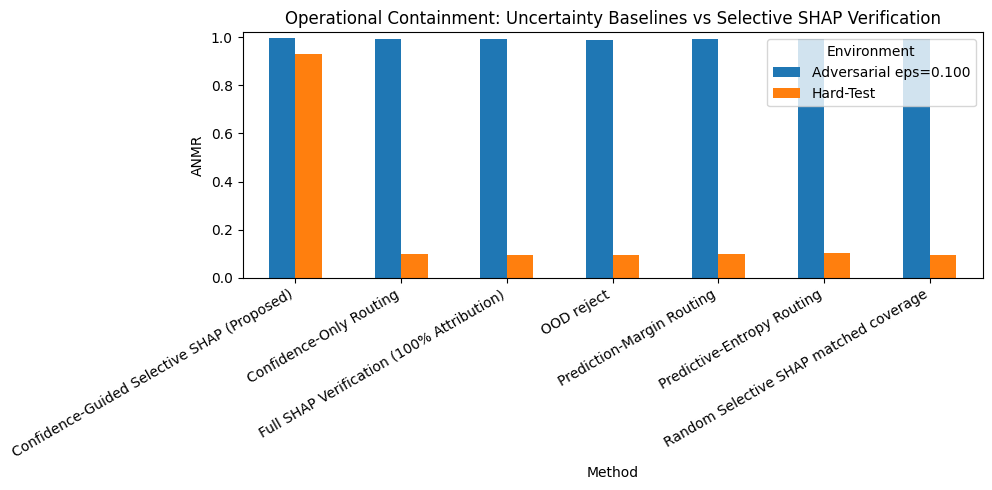


REVIEWER 4 AUDIT COMPLETE
PASS: Conventional baseline thresholds were selected on PolicyDev only.
PASS: Proposed policy remained frozen.
PASS: Random Selective SHAP used exactly the same attribution count as the proposed method in every evaluation environment.
PASS: Random matched coverage was repeated across five seeds.
PASS: All four LOAFO families were evaluated with all seven Reviewer-4 methods using their own retrained LOAFO models.
NOTE: Full SHAP Verification (100% Attribution) uses attribution on 100% of flows.
NOTE: Random Selective SHAP tests whether selective routing is better than randomly spending the same attribution budget.


In [ ]:
# =============================================================================
# BLOCK R4:
# DOES SELECTIVE SHAP VERIFICATION ADD OPERATIONAL VALUE
# BEYOND STANDARD UNCERTAINTY ROUTING?
#

#
# Baselines:
#   1. Confidence-Only Routing
#   2. Prediction-Margin Routing
#   3. Predictive-Entropy Routing
#   4. Full SHAP Verification (100% Attribution) (100% attribution)
#   5. Confidence-Guided Selective SHAP (Proposed)
#   6. Random Selective SHAP (Matched Attribution Budget)
#   7. Basic OOD-Score Routing
#
# IMPORTANT:
#   - Baseline thresholds are selected ONLY on PolicyDev.
#   - Final test environments are untouched during tuning.
#   - The proposed policy remains completely frozen.
#   - Random Selective SHAP receives the SAME attribution count as the proposed method
#     in each evaluation environment.
#   - Random selection is repeated across five seeds.
# =============================================================================


R4_RANDOM_SEEDS = [42, 123, 456, 789, 2026]


# =============================================================================
# STAGE-12 -> STAGE-10 FINAL-PROPOSED-POLICY HANDOFF
#
# Reviewer-4 must evaluate the SAME final proposed system that is reported in
# Stage 12 and Stage 13. Therefore, the 129-D M4 test environments use the
# exact Stage-12 reporting-seed model, calibrators, SHAP signatures, and the

#
# Development-side baseline threshold tuning remains unchanged and continues
# to use PolicyDev only.
# =============================================================================

REPORTING_SEED = int(
    CONFIG.get(
        "final_reporting_seed",
        RANDOM_STATE
    )
)

if "STAGE12_M4_ARTIFACTS" not in globals():
    raise RuntimeError(
        "Stage 10 final Reviewer-4 ablation must be run after the updated "
        "Stage 12 so it can use the exact reporting-seed M4 artifact. "
        "STAGE12_M4_ARTIFACTS is missing."
    )

if "STAGE12_LOAFO_ARTIFACTS" not in globals():
    raise RuntimeError(
        "Stage 10 final Reviewer-4 ablation must be run after the updated "
        "Stage 12 so it can use the exact reporting-seed LOAFO artifacts. "
        "STAGE12_LOAFO_ARTIFACTS is missing."
    )

if "_stage12_vb_evaluate" not in globals():
    raise RuntimeError(
        "Stage 10 requires _stage12_vb_evaluate from the updated Stage 12."
    )

if "STAGE12_VB_SELECTED_FAMILIARITY_THRESHOLD" not in globals():
    raise RuntimeError(
        "Stage 10 requires STAGE12_VB_SELECTED_FAMILIARITY_THRESHOLD "
        "from the updated Stage 12."
    )

if REPORTING_SEED not in STAGE12_M4_ARTIFACTS:
    raise RuntimeError(
        f"Stage 12 has no M4 artifact for reporting seed {REPORTING_SEED}."
    )

if REPORTING_SEED not in STAGE12_LOAFO_ARTIFACTS:
    raise RuntimeError(
        f"Stage 12 has no LOAFO artifact set for reporting seed "
        f"{REPORTING_SEED}."
    )

R4_M4_ARTIFACT = STAGE12_M4_ARTIFACTS[
    REPORTING_SEED
]

R4_M4_MODEL = R4_M4_ARTIFACT[
    "Model"
]

R4_M4_CALIBRATORS = R4_M4_ARTIFACT[
    "Calibrators"
]

R4_M4_SIGNATURES = R4_M4_ARTIFACT[
    "Signatures"
]

R4_LOAFO_ARTIFACTS = STAGE12_LOAFO_ARTIFACTS[
    REPORTING_SEED
]

print(
    f"PASS: Stage 10 Reviewer-4 final ablation is using the exact "
    f"Stage-12 reporting-seed artifacts for seed {REPORTING_SEED}."
)


# =============================================================================
# 1. BASIC OPERATIONAL METRICS
# =============================================================================

def basic_metrics_from_actions(
    y,
    pred,
    actions
):

    true_names = np.asarray(
        [
            resolve_active_class_name(i)
            for i in y
        ],
        dtype=object
    )

    true_benign = (
        true_names == "Benign"


    )

    true_malicious = (
        ~true_benign
    )

    return {

        "ANMR":
            float(
                1
                -
                np.sum(
                    true_malicious
                    &
                    (
                        actions == "ALLOW"


                    )
                )
                /
                max(
                    np.sum(
                        true_malicious
                    ),
                    1
                )
            ),

        "FBR":
            float(
                np.sum(
                    true_benign
                    &
                    (
                        actions == "BLOCK"


                    )
                )
                /
                max(
                    np.sum(
                        true_benign
                    ),
                    1
                )
            ),

        "Escalation_Rate":
            float(
                np.mean(
                    actions == "ESCALATE"


                )
            )
    }


# =============================================================================
# 2. POLICY-DEVELOPMENT DATA
# =============================================================================

Xp = transform_features(policy_dev_df)

yp = encode_active_labels(
    policy_dev_df[
        "label"
    ],
    None
)


# =============================================================================
# 3. PROPOSED DEVELOPMENT-SIDE ANALYST CAPACITY
#
# Used ONLY for tuning conventional rejection baselines.
# =============================================================================

proposed_dev = evaluate_final_policy(

    lgb_model,
    calibrators,
    train_signatures,
    Xp,
    yp,
    "PolicyDev"
)


ANALYST_CAPACITY = float(
    proposed_dev[
        "Escalation_Rate"
    ]
)

CAP_TOL = 0.002


print(
    "\n[Reviewer 4] Proposed development-side operational budget"
)

print(
    f"PolicyDev escalation rate : "
    f"{ANALYST_CAPACITY:.6f}"
)

print(
    f"Capacity tolerance        : "
    f"{CAP_TOL:.6f}"
)

print(
    f"PolicyDev attribution frac: "
    f"{float(proposed_dev['Attribution_Fraction']):.6f}"
)


# =============================================================================
# 4. ROBUST CLASS CENTERS FOR BASIC OOD BASELINE
# =============================================================================

train_num = transform_features(train_df)

train_y = encode_active_labels(
    train_df[
        "label"
    ],
    None
)


class_med = {}
class_iqr = {}


for ci in range(
    CLASS_COUNT
):

    z = train_num[
        train_y == ci


    ].astype(
        float
    )

    class_med[
        ci
    ] = np.nanmedian(
        z,
        axis=0
    )

    q1 = np.nanquantile(
        z,
        .25,
        axis=0
    )

    q3 = np.nanquantile(
        z,
        .75,
        axis=0
    )

    class_iqr[
        ci
    ] = np.maximum(
        q3 - q1,
        1e-6
    )


# -----------------------------------------------------------------------------
# M4-compatible OOD class centers
#
# The development-side R4 tuning remains in the original 115-feature space.
# Host/Time/Hard and Time-Test adversarial evaluation use the 129-feature
# M4_CausalHostRelative representation.
# -----------------------------------------------------------------------------

R4_M4_CLASS_MED = {}
R4_M4_CLASS_IQR = {}

for ci in range(CLASS_COUNT):

    z = np.asarray(
        CHR_X_TRAIN_M4[
            CHR_Y_TRAIN == ci
        ],
        dtype=float
    )

    if len(z) == 0:
        raise RuntimeError(
            f"R4 M4 OOD construction found no Train rows "
            f"for class index {ci}."
        )

    R4_M4_CLASS_MED[
        ci
    ] = np.nanmedian(
        z,
        axis=0
    )

    q1 = np.nanquantile(
        z,
        .25,
        axis=0
    )

    q3 = np.nanquantile(
        z,
        .75,
        axis=0
    )

    R4_M4_CLASS_IQR[
        ci
    ] = np.maximum(
        q3 - q1,
        1e-6
    )


def _r4_primary_stack_for_matrix(
    X
):
    """
    Return the classifier/calibration/signature/OOD stack that matches X.

    115 features -> original primary model
    129 features -> M4_CausalHostRelative model
    """

    X = np.asarray(
        X,
        dtype=np.float32
    )

    if X.ndim != 2:
        raise RuntimeError(
            f"R4 expected a 2-D feature matrix, got shape {X.shape}."
        )

    n_features = int(
        X.shape[1]
    )

    original_features = int(
        lgb_model.num_feature()
    )

    m4_features = int(
        R4_M4_MODEL.num_feature()
    )

    if n_features == m4_features:

        return (
            R4_M4_MODEL,
            R4_M4_CALIBRATORS,
            R4_M4_SIGNATURES,
            R4_M4_CLASS_MED,
            R4_M4_CLASS_IQR,
            "M4_CausalHostRelative"
        )

    if n_features == original_features:

        return (
            lgb_model,
            calibrators,
            train_signatures,
            class_med,
            class_iqr,
            "OriginalPrimary"
        )

    raise RuntimeError(
        "R4 feature-space mismatch: received "
        f"{n_features} features; original model expects "
        f"{original_features}, M4 expects {m4_features}."
    )


def ood_score(
    X,
    pred
):

    X = np.asarray(
        X,
        dtype=np.float32
    )

    pred = np.asarray(
        pred,
        dtype=int
    )

    (
        _model,
        _calibrators,
        _signatures,
        selected_class_med,
        selected_class_iqr,
        _stack_name
    ) = _r4_primary_stack_for_matrix(
        X
    )

    out = np.zeros(
        len(X),
        dtype=float
    )

    for ci in np.unique(
        pred
    ):

        mask = (
            pred == ci
        )

        out[
            mask
        ] = np.nanmedian(

            np.abs(
                (
                    X[
                        mask
                    ]
                    -
                    selected_class_med[
                        ci
                    ]
                )
                /
                selected_class_iqr[
                    ci
                ]
            ),

            axis=1
        )

    return out


# =============================================================================
# 5. TUNE CONVENTIONAL SCALAR BASELINES ON POLICYDEV ONLY
# =============================================================================

def tune_scalar_baseline(
    kind
):

    probs = get_calibrated_probabilities(
        lgb_model,
        calibrators,
        Xp
    )

    pred = probs.argmax(
        1
    )

    names = np.array(
        [
            resolve_active_class_name(i)
            for i in pred
        ],
        dtype=object
    )


    sorted_probs = np.sort(
        probs,
        axis=1
    )

    margin = (
        sorted_probs[
            :,
            -1
        ]
        -
        sorted_probs[
            :,
            -2
        ]
    )


    entropy = (
        -np.sum(
            probs
            *
            np.log(
                np.clip(
                    probs,
                    1e-12,
                    1
                )
            ),
            axis=1
        )
        /
        np.log(
            CLASS_COUNT
        )
    )


    ood = ood_score(
        Xp,
        pred
    )


    if kind == "confidence":

        score = np.max(
            probs,
            axis=1
        )

        grids = np.linspace(
            .50,
            .999,
            80
        )

        accept = lambda t: (
            score >= t


        )


    elif kind == "margin":

        score = margin

        grids = np.linspace(
            0,
            1,
            80
        )

        accept = lambda t: (
            score >= t


        )


    elif kind == "entropy":

        score = entropy

        grids = np.linspace(
            0,
            1,
            80
        )

        accept = lambda t: (
            score <= t


        )


    elif kind == "ood":

        score = ood

        grids = np.quantile(
            score,
            np.linspace(
                .05,
                .99,
                80
            )
        )

        accept = lambda t: (
            score <= t


        )


    else:

        raise ValueError(
            kind
        )


    best = None


    for threshold in grids:

        ok = accept(
            threshold
        )


        actions = np.where(

            ok,

            np.where(
                names == "Benign",


                "ALLOW",
                "BLOCK"
            ),

            "ESCALATE"
        )


        metrics = basic_metrics_from_actions(
            yp,
            pred,
            actions
        )


        violation = (

            max(
                0,
                metrics[
                    "FBR"
                ]
                -
                FBR_SAFETY_CEILING
            )

            +

            max(
                0,
                metrics[
                    "Escalation_Rate"
                ]
                -
                (
                    ANALYST_CAPACITY
                    +
                    CAP_TOL
                )
            )
        )


        key = (

            violation,

            -metrics[
                "ANMR"
            ],

            metrics[
                "FBR"
            ],

            abs(
                metrics[
                    "Escalation_Rate"
                ]
                -
                ANALYST_CAPACITY
            )
        )


        if (
            best is None
            or
            key < best[


                0
            ]
        ):

            best = (
                key,
                float(
                    threshold
                )
            )


    return best[
        1
    ]


BASELINE_THRESHOLDS = {

    kind:
        tune_scalar_baseline(
            kind
        )

    for kind in [

        "confidence",
        "margin",
        "entropy",
        "ood"
    ]
}


# =============================================================================
# 6. SHAP-ONLY THRESHOLDS
#
# Tuned on PolicyDev only.
# =============================================================================

pp = get_calibrated_probabilities(
    lgb_model,
    calibrators,
    Xp
)

pr = pp.argmax(
    1
)

pn = np.array(
    [
        resolve_active_class_name(i)
        for i in pr
    ],
    dtype=object
)


ss, _ = compute_similarity_metric(

    lgb_model,
    train_signatures,
    Xp,
    pr,
    pn,
    SELECTED_SIMILARITY_METRIC
)


best = None


for bsim in np.linspace(
    -.1,
    .8,
    40
):

    for asim in np.linspace(
        -.1,
        .8,
        40
    ):

        actions = np.where(

            (
                pn == "Benign"


            )
            &
            (
                ss >= bsim


            ),

            "ALLOW",

            np.where(

                (
                    pn != "Benign"


                )
                &
                (
                    ss >= asim


                ),

                "BLOCK",

                "ESCALATE"
            )
        )


        metrics = basic_metrics_from_actions(
            yp,
            pr,
            actions
        )


        violation = (

            max(
                0,
                metrics[
                    "FBR"
                ]
                -
                FBR_SAFETY_CEILING
            )

            +

            max(
                0,
                metrics[
                    "Escalation_Rate"
                ]
                -
                (
                    ANALYST_CAPACITY
                    +
                    CAP_TOL
                )
            )
        )


        key = (

            violation,

            -metrics[
                "ANMR"
            ],

            metrics[
                "FBR"
            ],

            abs(
                metrics[
                    "Escalation_Rate"
                ]
                -
                ANALYST_CAPACITY
            )
        )


        if (
            best is None
            or
            key < best[


                0
            ]
        ):

            best = (

                key,

                (
                    float(
                        bsim
                    ),

                    float(
                        asim
                    )
                )
            )


SHAP_ONLY_THRESHOLDS = best[
    1
]


# =============================================================================
# 7. STANDARD BASELINE EVALUATION
# =============================================================================

def eval_baseline(
    method,
    X,
    y
):

    X = np.asarray(
        X,
        np.float32
    )


    (
        eval_model,
        eval_calibrators,
        eval_signatures,
        _eval_class_med,
        _eval_class_iqr,
        eval_stack_name
    ) = _r4_primary_stack_for_matrix(
        X
    )

    probs = get_calibrated_probabilities(
        eval_model,
        eval_calibrators,
        X
    )

    pred = probs.argmax(
        1
    )


    names = np.array(
        [
            resolve_active_class_name(i)
            for i in pred
        ],
        dtype=object
    )


    sorted_probs = np.sort(
        probs,
        axis=1
    )


    margin = (

        sorted_probs[
            :,
            -1
        ]

        -

        sorted_probs[
            :,
            -2
        ]
    )


    entropy = (

        -np.sum(
            probs
            *
            np.log(
                np.clip(
                    probs,
                    1e-12,
                    1
                )
            ),
            axis=1
        )

        /

        np.log(
            CLASS_COUNT
        )
    )


    if method == "Confidence-Only Routing":

        ok = (
            np.max(
                probs,
                axis=1
            ) >= BASELINE_THRESHOLDS[


                "confidence"
            ]
        )


    elif method == "Prediction-Margin Routing":

        ok = (
            margin >= BASELINE_THRESHOLDS[


                "margin"
            ]
        )


    elif method == "Predictive-Entropy Routing":

        ok = (
            entropy <= BASELINE_THRESHOLDS[


                "entropy"
            ]
        )


    elif method == "OOD reject":

        ok = (

            ood_score(
                X,
                pred
            )

            <=

            BASELINE_THRESHOLDS[
                "ood"
            ]
        )


    elif method == "Full SHAP Verification (100% Attribution)":

        similarity, _ = (
            compute_similarity_metric(

                eval_model,
                eval_signatures,
                X,
                pred,
                names,
                SELECTED_SIMILARITY_METRIC
            )
        )


        benign_sim_threshold, attack_sim_threshold = (
            SHAP_ONLY_THRESHOLDS
        )


        actions = np.where(

            (
                names == "Benign"


            )
            &
            (
                similarity >= benign_sim_threshold


            ),

            "ALLOW",

            np.where(

                (
                    names != "Benign"


                )
                &
                (
                    similarity >= attack_sim_threshold


                ),

                "BLOCK",

                "ESCALATE"
            )
        )


        metrics = basic_metrics_from_actions(
            y,
            pred,
            actions
        )


        metrics[
            "Attribution_Fraction"
        ] = 1.0


        return metrics


    else:

        raise ValueError(
            method
        )


    actions = np.where(

        ok,

        np.where(
            names == "Benign",


            "ALLOW",
            "BLOCK"
        ),

        "ESCALATE"
    )


    metrics = basic_metrics_from_actions(
        y,
        pred,
        actions
    )


    metrics[
        "Attribution_Fraction"
    ] = 0.0


    return metrics


# =============================================================================
# 8. RANDOM + SHAP MATCHED-COVERAGE CONTROL
#
# This is the corrected Reviewer-4 random control.
#
# IMPORTANT:
#
# If the proposed method performs attribution on K flows,
# Random Selective SHAP also performs attribution on EXACTLY K flows.
#
# The only difference is WHICH K flows are selected.
#
# Non-selected flows:
#       classifier prediction -> direct ALLOW/BLOCK
#
# Randomly selected flows:
#       same SHAP similarity verification mechanism
#
# This tests whether intelligent selective routing adds value beyond
# merely spending the same attribution budget randomly.
# =============================================================================

def eval_random_matched_shap(
    X,
    y,
    target_attribution_count,
    seed
):

    X = np.asarray(
        X,
        np.float32
    )


    (
        eval_model,
        eval_calibrators,
        eval_signatures,
        _eval_class_med,
        _eval_class_iqr,
        eval_stack_name
    ) = _r4_primary_stack_for_matrix(
        X
    )

    probs = get_calibrated_probabilities(
        eval_model,
        eval_calibrators,
        X
    )


    pred = probs.argmax(
        1
    )


    names = np.array(
        [
            resolve_active_class_name(i)
            for i in pred
        ],
        dtype=object
    )


    n = len(
        X
    )


    k = int(
        target_attribution_count
    )


    k = max(
        0,
        min(
            k,
            n
        )
    )


    # -------------------------------------------------------------------------
    # Default direct classifier routing
    # -------------------------------------------------------------------------

    actions = np.where(

        names == "Benign",



        "ALLOW",

        "BLOCK"

    ).astype(
        object
    )


    # -------------------------------------------------------------------------
    # Select EXACTLY K random samples
    # -------------------------------------------------------------------------

    rng = np.random.default_rng(
        seed
    )


    selected_mask = np.zeros(
        n,
        dtype=bool
    )


    if k > 0:

        selected_indices = rng.choice(

            n,

            size=k,

            replace=False
        )


        selected_mask[
            selected_indices
        ] = True


        # ---------------------------------------------------------------------
        # Compute attribution only for the randomly selected samples
        # ---------------------------------------------------------------------

        selected_similarity, _ = (
            compute_similarity_metric(

                eval_model,
                eval_signatures,

                X[
                    selected_mask
                ],

                pred[
                    selected_mask
                ],

                names[
                    selected_mask
                ],

                SELECTED_SIMILARITY_METRIC
            )
        )


        benign_sim_threshold, attack_sim_threshold = (
            SHAP_ONLY_THRESHOLDS
        )


        selected_names = names[
            selected_mask
        ]


        selected_actions = np.where(

            (
                selected_names == "Benign"


            )
            &
            (
                selected_similarity >= benign_sim_threshold


            ),

            "ALLOW",

            np.where(

                (
                    selected_names != "Benign"


                )
                &
                (
                    selected_similarity >= attack_sim_threshold


                ),

                "BLOCK",

                "ESCALATE"
            )
        )


        actions[
            selected_mask
        ] = selected_actions


    # -------------------------------------------------------------------------
    # Metrics
    # -------------------------------------------------------------------------

    metrics = basic_metrics_from_actions(
        y,
        pred,
        actions
    )


    metrics[
        "Attribution_Fraction"
    ] = float(
        k
        /
        max(
            n,
            1
        )
    )


    metrics[
        "Attribution_Count"
    ] = int(
        k
    )


    return metrics


# =============================================================================
# 9. DEVELOPMENT-SIDE BASELINE FEASIBILITY
# =============================================================================

baseline_tuning_rows = []


for key, threshold in (
    BASELINE_THRESHOLDS.items()
):


    method_name = {

        "confidence":
            "Confidence-Only Routing",

        "margin":
            "Prediction-Margin Routing",

        "entropy":
            "Predictive-Entropy Routing",

        "ood":
            "OOD reject"

    }[
        key
    ]


    metrics = eval_baseline(
        method_name,
        Xp,
        yp
    )


    baseline_tuning_rows.append(
        {

            "Baseline":
                method_name,

            "Selected_Threshold":
                threshold,

            **metrics,

            "FBR_Constraint_Met":
                bool(
                    metrics[
                        "FBR"
                    ] <= FBR_SAFETY_CEILING


                    +
                    1e-12
                ),

            "Analyst_Capacity_Met":
                bool(
                    metrics[
                        "Escalation_Rate"
                    ] <= ANALYST_CAPACITY


                    +
                    CAP_TOL
                    +
                    1e-12
                )
        }
    )


metrics = eval_baseline(
    "Full SHAP Verification (100% Attribution)",
    Xp,
    yp
)


baseline_tuning_rows.append(
    {

        "Baseline":
            "Full SHAP Verification (100% Attribution)",

        "Selected_Threshold":
            str(
                SHAP_ONLY_THRESHOLDS
            ),

        **metrics,

        "FBR_Constraint_Met":
            bool(
                metrics[
                    "FBR"
                ] <= FBR_SAFETY_CEILING


                +
                1e-12
            ),

        "Analyst_Capacity_Met":
            bool(
                metrics[
                    "Escalation_Rate"
                ] <= ANALYST_CAPACITY


                +
                CAP_TOL
                +
                1e-12
            )
    }
)


baseline_tuning_df = pd.DataFrame(
    baseline_tuning_rows
)


print(
    "\n[Reviewer 4] Development-side matched-constraint tuning"
)


print(
    baseline_tuning_df.to_string(
        index=False
    )
)


baseline_tuning_df.to_csv(

    os.path.join(
        REV_TABLE_DIR,
        "R4_baseline_development_constraint_matching.csv"
    ),

    index=False
)


# =============================================================================
# 9B. AUTHORITATIVE FINAL PROPOSED-POLICY EVALUATOR
#
# This is the SAME configuration used by Stage 12 and Stage 13:
#   - Host-Test / Hard-Test:
#       Host/Hard Variant-B confidence + familiarity gate
#       -> selective SHAP for unresolved flows
#   - Time-Test / adversarial Time-Test:
#       original Confidence-Guided Selective SHAP
#
# All 129-D evaluations use the exact Stage-12 REPORTING_SEED artifact.
# =============================================================================

def _r4_evaluate_proposed_policy(
    env,
    X,
    y
):

    X = np.asarray(
        X,
        dtype=np.float32
    )

    y = np.asarray(
        y,
        dtype=np.int32
    )

    if env in {
        "Host-Test",
        "Hard-Test"
    }:

        return _stage12_vb_evaluate(
            R4_M4_MODEL,
            R4_M4_CALIBRATORS,
            R4_M4_SIGNATURES,
            X,
            y,
            STAGE12_VB_SELECTED_FAMILIARITY_THRESHOLD,
            env,
            measure_timing=False
        )

    return evaluate_final_policy(
        R4_M4_MODEL,
        R4_M4_CALIBRATORS,
        R4_M4_SIGNATURES,
        X,
        y,
        env
    )


# =============================================================================
# 10. DISTRIBUTION-SHIFT EVALUATION ENVIRONMENTS (M4; exploratory host-feature selection caveat)
# =============================================================================

comparison_envs = {
    "Host-Test": (CHR_X_HOST_M4, CHR_Y_HOST),
    "Time-Test": (CHR_X_TIME_M4, CHR_Y_TIME),
    "Hard-Test": (CHR_X_HARD_M4, CHR_Y_HARD),
    "Adversarial eps=0.100": (
        build_m4_time_matrix_from_original(
            np.asarray(ADVERSARIAL_CAPTURED_MATRICES[0.10], dtype=np.float32),
            tag="R4 Time-Test adversarial eps=0.100",
        ),
        CHR_Y_TIME,
    ),
}

# Evaluation-size registry used by the exact matched-attribution audit.
R4_EVAL_SIZES = {
    env: len(pair[0])
    for env, pair in comparison_envs.items()
}

methods = [

    "Confidence-Only Routing",

    "Prediction-Margin Routing",

    "Predictive-Entropy Routing",

    "Full SHAP Verification (100% Attribution)",

    "Confidence-Guided Selective SHAP (Proposed)",

    "Random Selective SHAP matched coverage",

    "OOD reject"
]


# =============================================================================
# 11. EVALUATE
# =============================================================================

rows = []

random_seed_rows = []


for env, (
    Xev,
    yev
) in comparison_envs.items():


    Xev = np.asarray(
        Xev,
        np.float32
    )

    yev = np.asarray(
        yev
    )


    # -------------------------------------------------------------------------
    # Run proposed policy FIRST.
    #
    # Its actual attribution count becomes the random-control budget.
    # -------------------------------------------------------------------------

    proposed_metrics = _r4_evaluate_proposed_policy(
        env,
        Xev,
        yev
    )


    proposed_fraction = float(
        proposed_metrics[
            "Attribution_Fraction"
        ]
    )


    # Convert fraction into the actual integer attribution count.
    #
    # round() is appropriate because Attribution_Fraction was generated from
    # an integer number of attributed samples.
    proposed_attribution_count = int(
        round(
            proposed_fraction
            *
            len(
                Xev
            )
        )
    )


    actual_matched_fraction = float(
        proposed_attribution_count
        /
        max(
            len(
                Xev
            ),
            1
        )
    )


    print(
        f"\n[R4 matched coverage] {env}"
    )

    print(
        f"  N samples                    : "
        f"{len(Xev)}"
    )

    print(
        f"  Proposed attribution fraction: "
        f"{proposed_fraction:.6f}"
    )

    print(
        f"  Matched attribution count    : "
        f"{proposed_attribution_count}"
    )

    print(
        f"  Matched attribution fraction : "
        f"{actual_matched_fraction:.6f}"
    )


    # -------------------------------------------------------------------------
    # Standard methods
    # -------------------------------------------------------------------------

    for method in methods:


        if (
            method == "Confidence-Guided Selective SHAP (Proposed)"


        ):

            rec = {

                "ANMR":
                    float(
                        proposed_metrics[
                            "ANMR"
                        ]
                    ),

                "FBR":
                    float(
                        proposed_metrics[
                            "FBR"
                        ]
                    ),

                "Escalation_Rate":
                    float(
                        proposed_metrics[
                            "Escalation_Rate"
                        ]
                    ),

                "Attribution_Fraction":
                    proposed_fraction,

                "Attribution_Count":
                    proposed_attribution_count,

                "ANMR_SD":
                    0.0,

                "FBR_SD":
                    0.0,

                "Escalation_Rate_SD":
                    0.0
            }


        elif (
            method == "Random Selective SHAP matched coverage"


        ):


            seed_results = []


            for seed in R4_RANDOM_SEEDS:


                seed_metrics = (
                    eval_random_matched_shap(

                        Xev,
                        yev,

                        target_attribution_count=
                            proposed_attribution_count,

                        seed=seed
                    )
                )


                seed_results.append(
                    seed_metrics
                )


                random_seed_rows.append(
                    {

                        "Environment":
                            env,

                        "Seed":
                            seed,

                        **seed_metrics
                    }
                )


            rec = {

                "ANMR":
                    float(
                        np.mean(
                            [
                                result[
                                    "ANMR"
                                ]
                                for result
                                in seed_results
                            ]
                        )
                    ),

                "FBR":
                    float(
                        np.mean(
                            [
                                result[
                                    "FBR"
                                ]
                                for result
                                in seed_results
                            ]
                        )
                    ),

                "Escalation_Rate":
                    float(
                        np.mean(
                            [
                                result[
                                    "Escalation_Rate"
                                ]
                                for result
                                in seed_results
                            ]
                        )
                    ),

                "Attribution_Fraction":
                    actual_matched_fraction,

                "Attribution_Count":
                    proposed_attribution_count,

                "ANMR_SD":
                    float(
                        np.std(
                            [
                                result[
                                    "ANMR"
                                ]
                                for result
                                in seed_results
                            ],
                            ddof=1
                        )
                    ),

                "FBR_SD":
                    float(
                        np.std(
                            [
                                result[
                                    "FBR"
                                ]
                                for result
                                in seed_results
                            ],
                            ddof=1
                        )
                    ),

                "Escalation_Rate_SD":
                    float(
                        np.std(
                            [
                                result[
                                    "Escalation_Rate"
                                ]
                                for result
                                in seed_results
                            ],
                            ddof=1
                        )
                    )
            }


        else:


            baseline_metrics = eval_baseline(
                method,
                Xev,
                yev
            )


            rec = {

                "ANMR":
                    float(
                        baseline_metrics[
                            "ANMR"
                        ]
                    ),

                "FBR":
                    float(
                        baseline_metrics[
                            "FBR"
                        ]
                    ),

                "Escalation_Rate":
                    float(
                        baseline_metrics[
                            "Escalation_Rate"
                        ]
                    ),

                "Attribution_Fraction":
                    float(
                        baseline_metrics[
                            "Attribution_Fraction"
                        ]
                    ),

                "Attribution_Count":
                    (
                        len(
                            Xev
                        )
                        if
                        method == "Full SHAP Verification (100% Attribution)"


                        else
                        0
                    ),

                "ANMR_SD":
                    0.0,

                "FBR_SD":
                    0.0,

                "Escalation_Rate_SD":
                    0.0
            }


        rows.append(
            {

                "Environment":
                    env,

                "Method":
                    method,

                **rec
            }
        )



# =============================================================================
# 11B. FOUR-FAMILY LOAFO EVALUATION USING EACH RETRAINED LOAFO MODEL
#
# The four LOAFO environments are evaluated with the SAME seven Reviewer-4
# methods. Each family uses its own model/calibration/signatures created in R6.
# The evaluation set is the held-out attack family + the fixed benign safety set.
# =============================================================================

def _r4_metrics_from_true_names(true_names, actions):
    true_names = np.asarray(true_names, dtype=object)
    actions = np.asarray(actions, dtype=object)
    true_benign = true_names == "Benign"
    true_malicious = ~true_benign
    return {
        "ANMR": float(1.0 - np.sum(true_malicious & (actions == "ALLOW")) / max(np.sum(true_malicious), 1)),
        "FBR": float(np.sum(true_benign & (actions == "BLOCK")) / max(np.sum(true_benign), 1)),
        "Escalation_Rate": float(np.mean(actions == "ESCALATE")),
    }


def _r4_loafo_ood_score(artifact, X, pred):
    X = np.asarray(X, np.float32)
    pred = np.asarray(pred, int)
    out = np.zeros(len(X), dtype=float)
    med = artifact["Class_Median"]
    iqr = artifact["Class_IQR"]
    for ci in np.unique(pred):
        mask = pred == ci
        out[mask] = np.nanmedian(
            np.abs((X[mask] - med[ci]) / iqr[ci]),
            axis=1
        )
    return out


def _r4_eval_loafo_baseline(method, artifact):
    X = np.asarray(artifact["X_Eval"], np.float32)
    true_names = np.asarray(artifact["True_Names"], dtype=object)
    model = artifact["Model"]
    cals = artifact["Calibrators"]
    names = artifact["Names"]
    C = int(artifact["Class_Count"])

    probs = _loafo_calibrated_probabilities(model, cals, X, C)
    pred = probs.argmax(1)
    pred_names = np.asarray([names[i] for i in pred], dtype=object)
    sorted_probs = np.sort(probs, axis=1)
    margin = sorted_probs[:, -1] - sorted_probs[:, -2]
    entropy = -np.sum(probs * np.log(np.clip(probs, 1e-12, 1)), axis=1) / np.log(C)

    if method == "Confidence-Only Routing":
        ok = np.max(probs, axis=1) >= BASELINE_THRESHOLDS["confidence"]
    elif method == "Prediction-Margin Routing":
        ok = margin >= BASELINE_THRESHOLDS["margin"]
    elif method == "Predictive-Entropy Routing":
        ok = entropy <= BASELINE_THRESHOLDS["entropy"]
    elif method == "OOD reject":
        ok = _r4_loafo_ood_score(artifact, X, pred) <= BASELINE_THRESHOLDS["ood"]
    elif method == "Full SHAP Verification (100% Attribution)":
        similarity = _loafo_similarity(
            model,
            artifact["Signatures"],
            X,
            pred,
            pred_names,
            C
        )
        benign_sim_threshold, attack_sim_threshold = SHAP_ONLY_THRESHOLDS
        actions = np.where(
            (pred_names == "Benign") & (similarity >= benign_sim_threshold),
            "ALLOW",
            np.where(
                (pred_names != "Benign") & (similarity >= attack_sim_threshold),
                "BLOCK",
                "ESCALATE"
            )
        )
        metrics = _r4_metrics_from_true_names(true_names, actions)
        metrics["Attribution_Fraction"] = 1.0
        return metrics
    else:
        raise ValueError(method)

    actions = np.where(ok, np.where(pred_names == "Benign", "ALLOW", "BLOCK"), "ESCALATE")
    metrics = _r4_metrics_from_true_names(true_names, actions)
    metrics["Attribution_Fraction"] = 0.0
    return metrics


def _r4_eval_loafo_random_matched(artifact, target_attribution_count, seed):
    X = np.asarray(artifact["X_Eval"], np.float32)
    true_names = np.asarray(artifact["True_Names"], dtype=object)
    model = artifact["Model"]
    cals = artifact["Calibrators"]
    names = artifact["Names"]
    C = int(artifact["Class_Count"])

    probs = _loafo_calibrated_probabilities(model, cals, X, C)
    pred = probs.argmax(1)
    pred_names = np.asarray([names[i] for i in pred], dtype=object)
    n = len(X)
    k = max(0, min(int(target_attribution_count), n))

    actions = np.where(pred_names == "Benign", "ALLOW", "BLOCK").astype(object)
    selected_mask = np.zeros(n, dtype=bool)
    if k > 0:
        rng = np.random.default_rng(seed)
        selected_idx = rng.choice(n, size=k, replace=False)
        selected_mask[selected_idx] = True
        sel_pred = pred[selected_mask]
        sel_names = pred_names[selected_mask]
        sel_sim = _loafo_similarity(
            model,
            artifact["Signatures"],
            X[selected_mask],
            sel_pred,
            sel_names,
            C
        )
        benign_sim_threshold, attack_sim_threshold = SHAP_ONLY_THRESHOLDS
        actions[selected_mask] = np.where(
            (sel_names == "Benign") & (sel_sim >= benign_sim_threshold),
            "ALLOW",
            np.where(
                (sel_names != "Benign") & (sel_sim >= attack_sim_threshold),
                "BLOCK",
                "ESCALATE"
            )
        )

    metrics = _r4_metrics_from_true_names(true_names, actions)
    metrics["Attribution_Fraction"] = float(k / max(n, 1))
    metrics["Attribution_Count"] = int(k)
    return metrics


for fam in CONFIG["loafo_families"]:
    if fam not in R4_LOAFO_ARTIFACTS:
        raise RuntimeError(
            f"Missing Stage-12 reporting-seed LOAFO artifact for "
            f"Reviewer-4 evaluation: {fam}"
        )

    artifact = R4_LOAFO_ARTIFACTS[fam]
    env = f"Zero-Day LOAFO: {fam}"
    Xev = np.asarray(artifact["X_Eval"], np.float32)
    R4_EVAL_SIZES[env] = len(Xev)

    # Proposed policy uses the exact LOAFO selective execution path from R6.
    proposed_metrics = evaluate_loafo_selective(
        artifact,
        tag=env,
        return_decisions=False
    )
    proposed_fraction = float(proposed_metrics["Attribution_Fraction"])
    proposed_attribution_count = int(proposed_metrics["Attribution_Count"])
    actual_matched_fraction = float(proposed_attribution_count / max(len(Xev), 1))

    print(f"\n[R4 matched coverage] {env}")
    print(f"  N samples                    : {len(Xev)}")
    print(f"  Proposed attribution fraction: {proposed_fraction:.6f}")
    print(f"  Matched attribution count    : {proposed_attribution_count}")
    print(f"  Matched attribution fraction : {actual_matched_fraction:.6f}")

    for method in methods:
        if method == "Confidence-Guided Selective SHAP (Proposed)":
            rec = {
                "ANMR": float(proposed_metrics["ANMR"]),
                "FBR": float(proposed_metrics["FBR"]),
                "Escalation_Rate": float(proposed_metrics["Overall_Escalation_Rate"]),
                "Attribution_Fraction": proposed_fraction,
                "Attribution_Count": proposed_attribution_count,
                "ANMR_SD": 0.0,
                "FBR_SD": 0.0,
                "Escalation_Rate_SD": 0.0,
            }
        elif method == "Random Selective SHAP matched coverage":
            seed_results = []
            for seed in R4_RANDOM_SEEDS:
                seed_metrics = _r4_eval_loafo_random_matched(
                    artifact,
                    target_attribution_count=proposed_attribution_count,
                    seed=seed
                )
                seed_results.append(seed_metrics)
                random_seed_rows.append({"Environment": env, "Seed": seed, **seed_metrics})

            rec = {
                "ANMR": float(np.mean([r["ANMR"] for r in seed_results])),
                "FBR": float(np.mean([r["FBR"] for r in seed_results])),
                "Escalation_Rate": float(np.mean([r["Escalation_Rate"] for r in seed_results])),
                "Attribution_Fraction": actual_matched_fraction,
                "Attribution_Count": proposed_attribution_count,
                "ANMR_SD": float(np.std([r["ANMR"] for r in seed_results], ddof=1)),
                "FBR_SD": float(np.std([r["FBR"] for r in seed_results], ddof=1)),
                "Escalation_Rate_SD": float(np.std([r["Escalation_Rate"] for r in seed_results], ddof=1)),
            }
        else:
            baseline_metrics = _r4_eval_loafo_baseline(method, artifact)
            rec = {
                "ANMR": float(baseline_metrics["ANMR"]),
                "FBR": float(baseline_metrics["FBR"]),
                "Escalation_Rate": float(baseline_metrics["Escalation_Rate"]),
                "Attribution_Fraction": float(baseline_metrics["Attribution_Fraction"]),
                "Attribution_Count": len(Xev) if method == "Full SHAP Verification (100% Attribution)" else 0,
                "ANMR_SD": 0.0,
                "FBR_SD": 0.0,
                "Escalation_Rate_SD": 0.0,
            }

        rows.append({"Environment": env, "Method": method, **rec})


# =============================================================================
# 12. FINAL R4 TABLE
# =============================================================================

shap_value_ablation_df = pd.DataFrame(
    rows
)


print(
    "\n"
    +
    "=" * 125
)

print(
    "[Reviewer 4] Operational value-added ablation"
)

print(
    "=" * 125
)


print(
    shap_value_ablation_df.to_string(
        index=False
    )
)


# =============================================================================
# 13. RANDOM MATCHING AUDIT
# =============================================================================

print(
    "\n"
    +
    "=" * 125
)

print(
    "[Reviewer 4] Exact attribution-budget matching audit"
)

print(
    "=" * 125
)


for env in R4_EVAL_SIZES.keys():


    proposed_row = (
        shap_value_ablation_df[
            (
                shap_value_ablation_df[
                    "Environment"
                ] == env


            )
            &
            (
                shap_value_ablation_df[
                    "Method"
                ] == "Confidence-Guided Selective SHAP (Proposed)"


            )
        ]
        .iloc[
            0
        ]
    )


    random_row = (
        shap_value_ablation_df[
            (
                shap_value_ablation_df[
                    "Environment"
                ] == env


            )
            &
            (
                shap_value_ablation_df[
                    "Method"
                ] == "Random Selective SHAP matched coverage"


            )
        ]
        .iloc[
            0
        ]
    )


    assert (
        int(
            proposed_row[
                "Attribution_Count"
            ]
        ) == int(


            random_row[
                "Attribution_Count"
            ]
        )
    ), (
        f"ERROR: attribution counts do not match for {env}."
    )


    assert np.isclose(

        float(
            proposed_row[
                "Attribution_Fraction"
            ]
        ),

        float(
            random_row[
                "Attribution_Fraction"
            ]
        ),

        atol=
            1.0
            /
            max(
                R4_EVAL_SIZES[
                    env
                ],
                1
            ),

        rtol=0.0

    ), (
        f"ERROR: attribution fractions do not match for {env}."
    )


    print(
        f"PASS: {env:<30} | "
        f"Proposed={int(proposed_row['Attribution_Count'])} | "
        f"Random={int(random_row['Attribution_Count'])} | "
        f"Fraction={float(random_row['Attribution_Fraction']):.6f}"
    )


# =============================================================================
# 14. SAVE RESULTS
# =============================================================================

shap_value_ablation_df.to_csv(

    os.path.join(
        REV_TABLE_DIR,
        "R4_SHAP_value_added_ablation.csv"
    ),

    index=False
)


random_seed_df = pd.DataFrame(
    random_seed_rows
)


random_seed_df.to_csv(

    os.path.join(
        REV_TABLE_DIR,
        "R4_random_SHAP_matched_coverage_multiseed.csv"
    ),

    index=False
)


# =============================================================================
# 15. GRAPH
# =============================================================================

hard_plot = (

    shap_value_ablation_df[

        shap_value_ablation_df[
            "Environment"
        ].isin(
            [
                "Hard-Test",
                "Adversarial eps=0.100"
            ]
        )
    ]
)


pivot = hard_plot.pivot(

    index="Method",

    columns="Environment",

    values="ANMR"
)


pivot.plot(
    kind="bar",
    figsize=(
        10,
        5
    )
)


plt.ylabel(
    "ANMR"
)

plt.ylim(
    0,
    1.02
)

plt.title(
    "Operational Containment: "
    "Uncertainty Baselines vs Selective SHAP Verification"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()


plt.savefig(

    os.path.join(
        REV_FIG_DIR,
        "R4_SHAP_value_added_hard_conditions.png"
    ),

    dpi=220
)


plt.show()


# =============================================================================
# 16. FINAL AUDIT MESSAGE
# =============================================================================

print(
    "\n"
    +
    "=" * 125
)

print(
    "REVIEWER 4 AUDIT COMPLETE"
)

print(
    "=" * 125
)

print(
    "PASS: Conventional baseline thresholds were selected on PolicyDev only."
)

print(
    "PASS: Proposed policy remained frozen."
)

print(
    "PASS: Random Selective SHAP used exactly the same attribution count "
    "as the proposed method in every evaluation environment."
)

print(
    "PASS: Random matched coverage was repeated across five seeds."
)

print(
    "PASS: All four LOAFO families were evaluated with all seven Reviewer-4 methods using their own retrained LOAFO models."
)

print(
    "NOTE: Full SHAP Verification (100% Attribution) uses attribution on 100% of flows."
)

print(
    "NOTE: Random Selective SHAP tests whether selective routing is better than "
    "randomly spending the same attribution budget."
)

print(
    "=" * 125
)


# Stage 11 — Explainability and Technical Consistency Diagnostics


In [ ]:
# BLOCK R7A: TECHNICAL CONSISTENCY AUDIT — L2 SIGNATURES AND VARIANCE
# Reviewer comment 7.

signature_audit=[]
for name,v in train_signatures.items():
    v=np.asarray(v,float)
    signature_audit.append({'Class':name,'L2_Norm':float(np.linalg.norm(v)),'Max_Abs_Component':float(np.max(np.abs(v))),
                            'Components_Above_1':int(np.sum(np.abs(v)>1+1e-9))})
signature_normalization_audit_df=pd.DataFrame(signature_audit)
print('\n[Reviewer 7] Canonical L2 signature audit')
print(signature_normalization_audit_df.to_string(index=False))
assert (signature_normalization_audit_df['Components_Above_1']==0).all(), 'Normalized signature component > 1 detected.'
signature_normalization_audit_df.to_csv(os.path.join(REV_TABLE_DIR,'R7_L2_signature_normalization_audit.csv'),index=False)

# Correct terminology: variance = mean squared deviation; standard deviation = sqrt(variance).
_, signature_variance_bank = build_signature_bank(lgb_model,train_df,SELECTED_SIGNATURE_SAMPLE_SIZE,PRIMARY_SIGNATURE_SEED)
variance_summary=[]
for name,var in signature_variance_bank.items():
    var=np.asarray(var,float); std=np.sqrt(np.maximum(var,0))
    variance_summary.append({'Class':name,'Mean_Feature_Variance':float(np.mean(var)),'Mean_Feature_StdDev':float(np.mean(std)),
                             'Max_Feature_Variance':float(np.max(var))})
signature_variance_audit_df=pd.DataFrame(variance_summary)
print('\nVariance/std-dev audit (manuscript Eq. 7 must use the correct term/formula)')
print(signature_variance_audit_df.to_string(index=False))
signature_variance_audit_df.to_csv(os.path.join(REV_TABLE_DIR,'R7_variance_vs_stddev_audit.csv'),index=False)


# Rebuild Table-6-style class profiles with unambiguous quantities.
# Raw mean absolute SHAP may exceed 1; normalized canonical-signature components cannot.
profile_rows=[]
Xtr=transform_features(train_df); ytr=encode_active_labels(train_df['label'],None)
for ci in range(CLASS_COUNT):
    rows=np.where(ytr==ci)[0]; rng=np.random.default_rng(9000+ci); take=rng.choice(rows,min(len(rows),SELECTED_SIGNATURE_SAMPLE_SIZE),replace=False)
    A=fast_predicted_class_attributions(lgb_model,Xtr[take],np.full(len(take),ci,dtype=int),batch_size=CONFIG.get('attribution_batch_size',8192))
    raw_mean_abs=np.mean(np.abs(A),axis=0); sig=np.asarray(train_signatures[resolve_active_class_name(ci)],float)
    top=np.argsort(raw_mean_abs)[-15:][::-1]
    for rank,j in enumerate(top,1):
        profile_rows.append({'Class':resolve_active_class_name(ci),'Rank':rank,'Feature':expected_features[j],
                             'Raw_MeanAbs_SHAP':float(raw_mean_abs[j]),'Normalized_Signature_Component':float(sig[j])})
classwise_shap_profile_df=pd.DataFrame(profile_rows)
classwise_shap_profile_df.to_csv(os.path.join(REV_TABLE_DIR,'R7_classwise_SHAP_profile_raw_vs_normalized.csv'),index=False)
print('\nReviewer-safe Table 6 profile columns: Raw_MeanAbs_SHAP and Normalized_Signature_Component')
print(classwise_shap_profile_df.to_string(index=False))
print('\nComplete class-wise SHAP profile printed for all active classes (Top-15 features per class).')

print('\nTable 6 reporting rule: if values > 1 are shown, label them as raw/mean absolute local SHAP contributions; '
      'do not label those values as components of the L2-normalized canonical signature.')



[Reviewer 7] Canonical L2 signature audit
           Class  L2_Norm  Max_Abs_Component  Components_Above_1
          Benign      1.0           0.721348                   0
     Botnet_ARES      1.0           0.753726                   0
       DDoS_LOIT      1.0           0.967613                   0
   DoS_GoldenEye      1.0           0.722892                   0
        DoS_Hulk      1.0           0.840879                   0
DoS_Slowhttptest      1.0           0.448119                   0
   DoS_Slowloris      1.0           0.715309                   0
     FTP-Patator      1.0           0.597351                   0
       Port_Scan      1.0           0.969974                   0
     SSH-Patator      1.0           0.951505                   0
 Web_Brute_Force      1.0           0.728185                   0
         Web_XSS      1.0           0.650857                   0

Variance/std-dev audit (manuscript Eq. 7 must use the correct term/formula)
           Class  Mean_Feature_Vari

[Reviewer 7] SHAP-LIME diagnostic N=120, mean=0.1332, approximate 95% CI=(0.1142,0.1522)


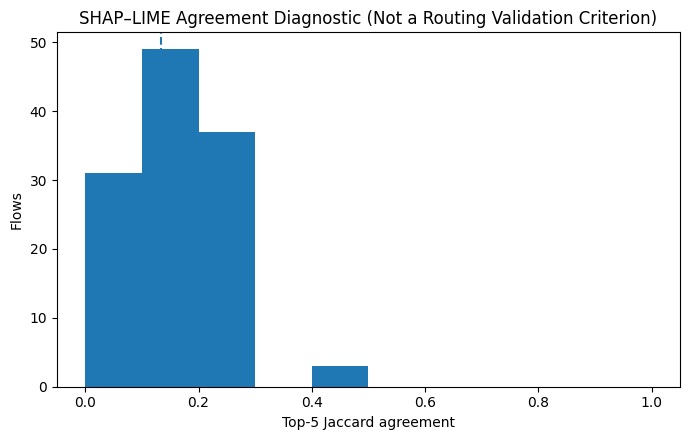

In [ ]:
# BLOCK R7B: SHAP–LIME AGREEMENT DIAGNOSTIC
# Increase the sample count and report distribution/CI. This output is not used by the routing policy.

N_LIME=min(CONFIG['lime_diagnostic_rows'],len(similarity_dev_df))
idx=np.random.default_rng(42).choice(len(similarity_dev_df),N_LIME,replace=False)
X_lime=transform_features(similarity_dev_df)[idx]
explainer_lime=LimeTabularExplainer(transform_features(train_df),feature_names=expected_features,
                                    class_names=ACTIVE_CLASS_NAMES,mode='classification',discretize_continuous=True,random_state=42)
shap_pred=get_calibrated_probabilities(lgb_model,calibrators,X_lime).argmax(1)
A=fast_predicted_class_attributions(lgb_model,X_lime,shap_pred,batch_size=CONFIG.get('attribution_batch_size',8192))
agreements=[]
for i in range(N_LIME):
    shap_top=set(np.argsort(np.abs(A[i]))[-5:])
    exp=explainer_lime.explain_instance(X_lime[i],lambda z:get_calibrated_probabilities(lgb_model,calibrators,z),num_features=5,labels=[int(shap_pred[i])])
    lime_map=exp.as_map().get(int(shap_pred[i]),[]); lime_top=set([j for j,_ in lime_map[:5]])
    union=len(shap_top|lime_top); agreements.append(len(shap_top&lime_top)/union if union else 0.0)
ag=np.asarray(agreements,float); mean=float(np.mean(ag)); se=float(np.std(ag,ddof=1)/np.sqrt(len(ag))) if len(ag)>1 else 0
lime_diagnostic_df=pd.DataFrame({'Jaccard_Top5':ag})
print(f'[Reviewer 7] SHAP-LIME diagnostic N={len(ag)}, mean={mean:.4f}, approximate 95% CI=({mean-1.96*se:.4f},{mean+1.96*se:.4f})')
lime_diagnostic_df.to_csv(os.path.join(REV_TABLE_DIR,'R7_SHAP_LIME_diagnostic_distribution.csv'),index=False)
plt.figure(figsize=(7,4.5)); plt.hist(ag,bins=np.linspace(0,1,11)); plt.axvline(mean,linestyle='--'); plt.xlabel('Top-5 Jaccard agreement'); plt.ylabel('Flows');
plt.title('SHAP–LIME Agreement Diagnostic (Not a Routing Validation Criterion)'); plt.tight_layout(); plt.savefig(os.path.join(REV_FIG_DIR,'R7_SHAP_LIME_diagnostic_histogram.png'),dpi=220); plt.show()


# Stage 12 — Five-Seed Robustness


In [ ]:
# =============================================================================
# STAGE 12 — COMPLETE FIVE-SEED ROBUSTNESS OF THE PROPOSED SYSTEM

# FIVE SEEDS x EIGHT ENVIRONMENTS = 40 FINAL ROBUSTNESS EVALUATIONS
#
# Environments:
#   1. Host-Test
#   2. Time-Test
#   3. Hard-Test
#   4. Zero-Day LOAFO: Port_Scan
#   5. Zero-Day LOAFO: DoS_GoldenEye
#   6. Zero-Day LOAFO: DoS_Slowhttptest
#   7. Zero-Day LOAFO: FTP-Patator
#   8. Adversarial Time-Test eps=0.100
#


import copy
import time
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.calibration import IsotonicRegression
from sklearn.metrics import f1_score

print("\n" + "=" * 125)
print("STAGE 12 — COMPLETE FIVE-SEED ROBUSTNESS")
print("=" * 125)

STAGE12_SEEDS = [
    int(s)
    for s in CONFIG["multi_seed_values"]
]

STAGE12_REPORTING_SEED = int(
    CONFIG.get(
        "final_reporting_seed",
        RANDOM_STATE
    )
)

if STAGE12_REPORTING_SEED not in STAGE12_SEEDS:
    raise RuntimeError(
        "final_reporting_seed must be one of CONFIG['multi_seed_values']. "
        f"Reporting seed={STAGE12_REPORTING_SEED}, seeds={STAGE12_SEEDS}"
    )

STAGE12_ADV_EPS = 0.10

if "ADVERSARIAL_CAPTURED_MATRICES" not in globals():
    raise RuntimeError(
        "Stage 12 requires ADVERSARIAL_CAPTURED_MATRICES from Stage R5A/R5."
    )

if STAGE12_ADV_EPS not in ADVERSARIAL_CAPTURED_MATRICES:
    raise RuntimeError(
        f"Stage 12 requires adversarial epsilon={STAGE12_ADV_EPS:.2f}."
    )

if "run_loafo_family" not in globals():
    raise RuntimeError(
        "Stage 12 requires run_loafo_family() from the R6 LOAFO block."
    )

if "LOAFO_BENIGN_TEST_INDICES" not in globals():
    raise RuntimeError(
        "Stage 12 requires the fixed R6 LOAFO benign safety subset."
    )

# Build the epsilon=0.100 M4 adversarial matrix ONCE.
# The representation itself is deterministic and independent of model seed.
STAGE12_X_ADV_010_M4 = build_m4_time_matrix_from_original(
    np.asarray(
        ADVERSARIAL_CAPTURED_MATRICES[
            STAGE12_ADV_EPS
        ],
        dtype=np.float32
    ),
    tag="Stage12 multi-seed Time-Test adversarial eps=0.100"
)

STAGE12_Y_ADV_010 = np.asarray(
    CHR_Y_TIME,
    dtype=np.int32
)

# -------------------------------------------------------------------------
# Persistent Stage-12 caches.
#
# Stage 13 will consume the artifact corresponding to REPORTING_SEED.
# This guarantees that the single-seed report and the same seed in the
# multi-seed table are literally based on the same trained objects.
# -------------------------------------------------------------------------
STAGE12_M4_ARTIFACTS = {}
STAGE12_LOAFO_ARTIFACTS = {}
STAGE12_SEED_RECORDS = []


def _stage12_fit_m4_seed(
    seed
):
    """
    Train, calibrate, and build the SHAP signature bank for one M4 seed.
    No policy threshold is changed.
    """

    seed = int(seed)

    params = copy.deepcopy(
        MAIN_PARAMS
    )

    params.update({
        "seed": seed,
        "bagging_seed": seed,
        "feature_fraction_seed": seed,
        "data_random_seed": seed,
        "verbose": -1,
    })

    train_ds = lgb.Dataset(
        CHR_X_TRAIN_M4,
        label=CHR_Y_TRAIN,
        feature_name=CHR_M4_FEATURE_NAMES,
        free_raw_data=True,
    )

    early_ds = lgb.Dataset(
        CHR_X_EARLY_M4,
        label=CHR_Y_EARLY,
        feature_name=CHR_M4_FEATURE_NAMES,
        reference=train_ds,
        free_raw_data=True,
    )

    model = lgb.train(
        params,
        train_ds,
        num_boost_round=200,
        valid_sets=[early_ds],
        valid_names=["EarlyStopping"],
        callbacks=[
            lgb.early_stopping(
                15,
                verbose=False
            )
        ],
    )

    raw_cal = np.asarray(
        model.predict(
            CHR_X_CALIB_M4
        ),
        dtype=float
    )

    if (
        raw_cal.ndim != 2
        or
        raw_cal.shape[1] != CLASS_COUNT
    ):
        raise RuntimeError(
            f"Seed {seed}: unexpected M4 calibration shape "
            f"{raw_cal.shape}."
        )

    local_calibrators = {}

    for class_idx in range(
        CLASS_COUNT
    ):
        target = (
            CHR_Y_CALIB == class_idx
        ).astype(int)

        if len(
            np.unique(
                target
            )
        ) < 2:
            raise RuntimeError(
                f"Seed {seed}: calibration subset lacks both outcomes "
                f"for class index {class_idx}."
            )

        iso = IsotonicRegression(
            out_of_bounds="clip"
        )

        iso.fit(
            raw_cal[
                :,
                class_idx
            ],
            target
        )

        local_calibrators[
            class_idx
        ] = iso

    local_signatures = chr_build_signature_bank(
        model,
        CHR_X_TRAIN_M4,
        CHR_Y_TRAIN,
        SELECTED_SIGNATURE_SAMPLE_SIZE,
        seed
    )

    return {
        "Seed": seed,
        "Model": model,
        "Calibrators": local_calibrators,
        "Signatures": local_signatures,
        "Best_Iteration": int(
            model.best_iteration
        ),
    }


# =============================================================================
# STAGE 12 — HOST/HARD-ONLY VARIANT B INTEGRATION
# =============================================================================
for _vb_seed in STAGE12_SEEDS:
    if int(_vb_seed) not in STAGE12_M4_ARTIFACTS:
        STAGE12_M4_ARTIFACTS[int(_vb_seed)] = _stage12_fit_m4_seed(int(_vb_seed))

STAGE12_VB_X_POLICY_ORIG = np.asarray(transform_features(policy_dev_df, PRIMARY_PREPROCESSOR), dtype=np.float32)
STAGE12_VB_Y_POLICY = np.asarray(encode_active_labels(policy_dev_df["label"], zero_day_value=None), dtype=np.int32)
STAGE12_VB_REL_POLICY, STAGE12_VB_POLICY_CAUSAL_AUDIT = chr_build_causal_host_relative(
    policy_dev_df, STAGE12_VB_X_POLICY_ORIG,
    history_frame=train_df, history_X=CHR_X_TRAIN_ORIG,
    tag="Stage12 Variant-B PolicyOptimization",
)
STAGE12_VB_X_POLICY_M4 = chr_append_relative(STAGE12_VB_X_POLICY_ORIG, STAGE12_VB_REL_POLICY)
if STAGE12_VB_X_POLICY_M4.shape[1] != 129:
    raise RuntimeError(f"Stage12 Variant-B expected 129-D PolicyOptimization matrix; got {STAGE12_VB_X_POLICY_M4.shape}.")

STAGE12_VB_FAMILIARITY_Z_CLIP = 20.0
STAGE12_VB_FAMILIARITY_EPS = 1e-6
_stage12_vb_policy_benign_mask = STAGE12_VB_Y_POLICY == int(BENIGN_IDX)
_stage12_vb_policy_benign_X = np.asarray(STAGE12_VB_X_POLICY_M4[_stage12_vb_policy_benign_mask], dtype=np.float64)
STAGE12_VB_BENIGN_MEDIAN = np.nanmedian(_stage12_vb_policy_benign_X, axis=0)
_stage12_vb_q1 = np.nanquantile(_stage12_vb_policy_benign_X, 0.25, axis=0)
_stage12_vb_q3 = np.nanquantile(_stage12_vb_policy_benign_X, 0.75, axis=0)
STAGE12_VB_BENIGN_IQR = _stage12_vb_q3 - _stage12_vb_q1
STAGE12_VB_BENIGN_IQR = np.where(np.isfinite(STAGE12_VB_BENIGN_IQR) & (np.abs(STAGE12_VB_BENIGN_IQR) > STAGE12_VB_FAMILIARITY_EPS), STAGE12_VB_BENIGN_IQR, 1.0)

def _stage12_vb_familiarity_score(X):
    X = np.asarray(X, dtype=np.float64)
    z = np.abs(X - STAGE12_VB_BENIGN_MEDIAN) / STAGE12_VB_BENIGN_IQR
    z = np.nan_to_num(z, nan=STAGE12_VB_FAMILIARITY_Z_CLIP, posinf=STAGE12_VB_FAMILIARITY_Z_CLIP, neginf=STAGE12_VB_FAMILIARITY_Z_CLIP)
    return np.median(np.clip(z, 0.0, STAGE12_VB_FAMILIARITY_Z_CLIP), axis=1).astype(np.float64)

STAGE12_VB_POLICY_FAMILIARITY = _stage12_vb_familiarity_score(STAGE12_VB_X_POLICY_M4)

def _stage12_vb_original_direct_allow_mask(model, calibs, X):
    probs = np.asarray(get_calibrated_probabilities(model, calibs, X), dtype=float)
    pred = np.argmax(probs, axis=1)
    pred_names = np.asarray([resolve_active_class_name(i) for i in pred], dtype=object)
    sorted_probs = np.sort(probs, axis=1)
    margin = sorted_probs[:, -1] - sorted_probs[:, -2]
    return ((pred_names == "Benign") & (probs[:, int(BENIGN_IDX)] >= float(FINAL_BENIGN_DIRECT_PROB)) & (margin >= float(FINAL_BENIGN_DIRECT_MARGIN)))

def _stage12_vb_evaluate(model, calibs, signatures, X, y, familiarity_threshold, tag, measure_timing=False, timing_repeats=3):
    X = np.asarray(X, dtype=np.float32); y = np.asarray(y, dtype=np.int32)
    def _once():
        t0 = time.perf_counter(); tp = time.perf_counter()
        probs = np.asarray(get_calibrated_probabilities(model, calibs, X), dtype=float)
        prob_elapsed = time.perf_counter() - tp
        pred = np.argmax(probs, axis=1)
        pred_names = np.asarray([resolve_active_class_name(i) for i in pred], dtype=object)
        benign_prob = probs[:, int(BENIGN_IDX)]; attack_conf = 1.0 - benign_prob
        sorted_probs = np.sort(probs, axis=1); max_prob = sorted_probs[:, -1]; margin = sorted_probs[:, -1] - sorted_probs[:, -2]
        familiarity = _stage12_vb_familiarity_score(X)
        direct_allow = ((pred_names == "Benign") & (benign_prob >= float(FINAL_BENIGN_DIRECT_PROB)) & (margin >= float(FINAL_BENIGN_DIRECT_MARGIN)) & (familiarity <= float(familiarity_threshold)))
        direct_block = ((pred_names != "Benign") & (attack_conf >= float(FINAL_TAU_P)) & (max_prob >= float(FINAL_ATTACK_DIRECT_PROB)) & (margin >= float(FINAL_ATTACK_DIRECT_MARGIN)))
        unresolved = ~(direct_allow | direct_block)
        actions = np.full(len(X), "ESCALATE", dtype=object); actions[direct_allow] = "ALLOW"; actions[direct_block] = "BLOCK"
        attr_elapsed = 0.0
        if np.any(unresolved):
            ta = time.perf_counter()
            sim, _ = compute_similarity_metric(model, signatures, X[unresolved], pred[unresolved], pred_names[unresolved], SELECTED_SIMILARITY_METRIC)
            routed = route_policy_batch(pred_names[unresolved], attack_conf[unresolved], sim, float(FINAL_TAU_P), float(FINAL_TAU_S), float(FINAL_BENIGN_PROB_TAU), float(FINAL_BENIGN_SIM_TAU), float(FINAL_HIGH_CONF_BENIGN_PROB_TAU), float(FINAL_HIGH_CONF_BENIGN_SIM_FLOOR))
            actions[unresolved] = np.asarray(routed["actions"], dtype=object)
            attr_elapsed = time.perf_counter() - ta
        elapsed = time.perf_counter() - t0
        true_attack = y != int(BENIGN_IDX); true_benign = ~true_attack
        allow = actions == "ALLOW"; block = actions == "BLOCK"; esc = actions == "ESCALATE"
        an = max(int(np.sum(true_attack)),1); bn = max(int(np.sum(true_benign)),1); n=max(len(X),1)
        return {"Environment":tag,"Rows":int(len(X)),"Global_Accuracy":float(np.mean(pred==y)),"Macro_F1":float(f1_score(y,pred,average="macro",zero_division=0)),"ANMR":float(1-np.sum(true_attack&allow)/an),"FBR":float(np.sum(true_benign&block)/bn),"Attack_Block_Rate":float(np.sum(true_attack&block)/an),"Attack_Escalation_Rate":float(np.sum(true_attack&esc)/an),"Attack_Allow_Rate":float(np.sum(true_attack&allow)/an),"Escalation_Rate":float(np.mean(esc)),"Attribution_Fraction":float(np.mean(unresolved)),"Attack_Direct_ALLOW_Rate":float(np.sum(true_attack&direct_allow)/an),"Attack_Sent_to_SHAP_Rate":float(np.sum(true_attack&unresolved)/an),"Probability_Latency_ms_per_flow":float(1000*prob_elapsed/n),"Attribution_Latency_ms_per_flow":float(1000*attr_elapsed/n),"End_to_End_Latency_ms_per_flow":float(1000*elapsed/n),"Throughput_flows_per_sec":float(n/max(elapsed,1e-12))}
    if not measure_timing: return _once()
    _=_once(); runs=[_once() for _ in range(int(timing_repeats))]; out=dict(runs[-1])
    for k in ["Probability_Latency_ms_per_flow","Attribution_Latency_ms_per_flow","End_to_End_Latency_ms_per_flow","Throughput_flows_per_sec"]: out[k]=float(np.median([r[k] for r in runs]))
    return out

STAGE12_VB_CANDIDATE_QUANTILES=[0.50,0.60,0.70,0.80,0.85,0.90,0.925,0.95,0.975,0.99,0.995]
STAGE12_VB_MIN_BENIGN_DIRECT_ALLOW_RETENTION=0.25
_stage12_vb_policy_benign_fam=STAGE12_VB_POLICY_FAMILIARITY[STAGE12_VB_Y_POLICY==int(BENIGN_IDX)]
STAGE12_VB_CANDIDATE_THRESHOLDS={q:float(np.quantile(_stage12_vb_policy_benign_fam,q)) for q in STAGE12_VB_CANDIDATE_QUANTILES}
_stage12_vb_dev_rows=[]
for _q,_thr in STAGE12_VB_CANDIDATE_THRESHOLDS.items():
    _rows=[]
    for _seed in STAGE12_SEEDS:
        _a=STAGE12_M4_ARTIFACTS[int(_seed)]; _m=_a["Model"]; _c=_a["Calibrators"]; _s=_a["Signatures"]
        _r=_stage12_vb_evaluate(_m,_c,_s,STAGE12_VB_X_POLICY_M4,STAGE12_VB_Y_POLICY,_thr,f"PolicyOptimization | Variant-B q={_q:.3f} | seed={_seed}")
        _orig=_stage12_vb_original_direct_allow_mask(_m,_c,STAGE12_VB_X_POLICY_M4); _tb=STAGE12_VB_Y_POLICY==int(BENIGN_IDX); _orig_n=int(np.sum(_orig&_tb))
        _p=np.asarray(get_calibrated_probabilities(_m,_c,STAGE12_VB_X_POLICY_M4),dtype=float); _pr=np.argmax(_p,axis=1); _pn=np.asarray([resolve_active_class_name(i) for i in _pr],dtype=object); _sp=np.sort(_p,axis=1); _mg=_sp[:,-1]-_sp[:,-2]
        _new=((_pn=="Benign")&(_p[:,int(BENIGN_IDX)]>=float(FINAL_BENIGN_DIRECT_PROB))&(_mg>=float(FINAL_BENIGN_DIRECT_MARGIN))&(STAGE12_VB_POLICY_FAMILIARITY<=float(_thr)))
        _ret=float(np.sum(_new&_tb)/_orig_n) if _orig_n>0 else np.nan
        _rows.append({"Attack_Direct_ALLOW_Rate":_r["Attack_Direct_ALLOW_Rate"],"Attack_Allow_Rate":_r["Attack_Allow_Rate"],"Attribution_Fraction":_r["Attribution_Fraction"],"Benign_Direct_ALLOW_Retention":_ret,"FBR":_r["FBR"],"ANMR":_r["ANMR"]})
    _df=pd.DataFrame(_rows)
    _stage12_vb_dev_rows.append({"Quantile":float(_q),"Familiarity_Threshold":float(_thr),"Worst_Seed_Dev_Attack_Direct_ALLOW_Rate":float(_df["Attack_Direct_ALLOW_Rate"].max()),"Mean_Dev_Attack_Direct_ALLOW_Rate":float(_df["Attack_Direct_ALLOW_Rate"].mean()),"Worst_Seed_Dev_Attack_Allow_Rate":float(_df["Attack_Allow_Rate"].max()),"Mean_Dev_ANMR":float(_df["ANMR"].mean()),"Mean_Dev_Attribution_Fraction":float(_df["Attribution_Fraction"].mean()),"Mean_Benign_Direct_ALLOW_Retention":float(_df["Benign_Direct_ALLOW_Retention"].mean()),"Min_Benign_Direct_ALLOW_Retention":float(_df["Benign_Direct_ALLOW_Retention"].min()),"Mean_Dev_FBR":float(_df["FBR"].mean())})
STAGE12_VB_DEV_SELECTION_DF=pd.DataFrame(_stage12_vb_dev_rows)
_stage12_vb_feasible=STAGE12_VB_DEV_SELECTION_DF[STAGE12_VB_DEV_SELECTION_DF["Mean_Benign_Direct_ALLOW_Retention"]>=float(STAGE12_VB_MIN_BENIGN_DIRECT_ALLOW_RETENTION)].copy()
if len(_stage12_vb_feasible)==0: raise RuntimeError("No Stage12 Variant-B development candidate satisfied benign-direct-ALLOW retention constraint.")
_stage12_vb_feasible=_stage12_vb_feasible.sort_values(by=["Worst_Seed_Dev_Attack_Direct_ALLOW_Rate","Worst_Seed_Dev_Attack_Allow_Rate","Mean_Dev_Attribution_Fraction","Mean_Benign_Direct_ALLOW_Retention"],ascending=[True,True,True,False],kind="mergesort").reset_index(drop=True)
STAGE12_VB_SELECTED_QUANTILE=float(_stage12_vb_feasible.iloc[0]["Quantile"])
STAGE12_VB_SELECTED_FAMILIARITY_THRESHOLD=float(_stage12_vb_feasible.iloc[0]["Familiarity_Threshold"])
print("\n"+"="*125); print("STAGE 12 — HOST/HARD VARIANT-B DEVELOPMENT SELECTION"); print("="*125); print(STAGE12_VB_DEV_SELECTION_DF.to_string(index=False)); print("Selected quantile:",STAGE12_VB_SELECTED_QUANTILE); print("Frozen Host/Hard familiarity threshold:",STAGE12_VB_SELECTED_FAMILIARITY_THRESHOLD)

def _stage12_primary_record(
    seed,
    environment,
    model,
    calibrators_local,
    signatures_local,
    X,
    y
):
    """
    Evaluate the complete proposed M4 + selective-SHAP system.
    """

    if environment in {"Host-Test", "Hard-Test"}:
        result = _stage12_vb_evaluate(
            model, calibrators_local, signatures_local,
            np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.int32),
            STAGE12_VB_SELECTED_FAMILIARITY_THRESHOLD,
            f"{environment} | M4+VariantB+SelectiveSHAP | seed={seed}",
            measure_timing=True, timing_repeats=3,
        )
        architecture = (
            "M4_CausalHostRelative + Benign Familiarity Gate + "
            "Confidence-Guided Selective SHAP"
        )
    else:
        result = evaluate_final_policy(
            model, calibrators_local, signatures_local,
            np.asarray(X, dtype=np.float32), np.asarray(y),
            f"{environment} | M4+SelectiveSHAP | seed={seed}"
        )
        architecture = "M4_CausalHostRelative + Confidence-Guided Selective SHAP"

    return {
        "Seed": int(seed),
        "Environment": environment,
        "Architecture": architecture,
        "Global_Accuracy":
            float(result["Global_Accuracy"]),
        "Macro_F1":
            float(result["Macro_F1"]),
        "ANMR":
            float(result["ANMR"]),
        "FBR":
            float(result["FBR"]),
        "Overall_Escalation_Rate":
            float(result["Escalation_Rate"]),
        "Attack_Block_Rate":
            float(result["Attack_Block_Rate"]),
        "Attack_Escalation_Rate":
            float(result["Attack_Escalation_Rate"]),
        "Attack_Allow_Rate":
            float(result["Attack_Allow_Rate"]),
        "Attribution_Fraction":
            float(result["Attribution_Fraction"]),
        "Probability_Latency_ms_per_flow":
            float(result["Probability_Latency_ms_per_flow"]),
        "Attribution_Latency_ms_per_flow":
            float(result["Attribution_Latency_ms_per_flow"]),
        "End_to_End_Latency_ms_per_flow":
            float(result["End_to_End_Latency_ms_per_flow"]),
        "Throughput_flows_per_sec":
            float(result["Throughput_flows_per_sec"]),
        "Best_Iteration":
            int(model.best_iteration),
    }


def _stage12_loafo_record(
    seed,
    family,
    summary
):
    """
    Convert the existing R6 LOAFO selective-SHAP output into the common
    Stage-12 schema. Accuracy/Macro-F1 are intentionally N/A because the
    held-out attack family is not an output class of its local model.
    """

    return {
        "Seed": int(seed),
        "Environment":
            f"Zero-Day LOAFO: {family}",
        "Architecture":
            "LOAFO + Confidence-Guided Selective SHAP",
        "Global_Accuracy":
            np.nan,
        "Macro_F1":
            np.nan,
        "ANMR":
            float(summary["ANMR"]),
        "FBR":
            float(summary["FBR"]),
        "Overall_Escalation_Rate":
            float(summary["Overall_Escalation_Rate"]),
        "Attack_Block_Rate":
            float(summary["Attack_Block_Rate"]),
        "Attack_Escalation_Rate":
            float(summary["Attack_Escalation_Rate"]),
        "Attack_Allow_Rate":
            float(summary["Attack_Allow_Rate"]),
        "Attribution_Fraction":
            float(summary["Attribution_Fraction"]),
        "Probability_Latency_ms_per_flow":
            float(summary["Probability_Latency_ms_per_flow"]),
        "Attribution_Latency_ms_per_flow":
            float(summary["Attribution_Latency_ms_per_flow"]),
        "End_to_End_Latency_ms_per_flow":
            float(summary["End_to_End_Latency_ms_per_flow"]),
        "Throughput_flows_per_sec":
            float(summary["Throughput_flows_per_sec"]),
        "Best_Iteration":
            int(summary["Best_Iteration"]),
    }


# =============================================================================
# 1. FIVE-SEED MAIN M4 + SELECTIVE-SHAP EVALUATION
# =============================================================================

for seed in STAGE12_SEEDS:

    print("\n" + "-" * 125)
    print(
        f"[Stage 12] M4 + Confidence-Guided Selective SHAP | seed={seed}"
    )
    print("-" * 125)

    m4_artifact = STAGE12_M4_ARTIFACTS[int(seed)]

    model = m4_artifact[
        "Model"
    ]

    local_calibrators = m4_artifact[
        "Calibrators"
    ]

    local_signatures = m4_artifact[
        "Signatures"
    ]

    # Clean distribution-shift environments.
    for environment, X_eval, y_eval in [
        (
            "Host-Test",
            CHR_X_HOST_M4,
            CHR_Y_HOST
        ),
        (
            "Time-Test",
            CHR_X_TIME_M4,
            CHR_Y_TIME
        ),
        (
            "Hard-Test",
            CHR_X_HARD_M4,
            CHR_Y_HARD
        ),
    ]:

        record = _stage12_primary_record(
            seed,
            environment,
            model,
            local_calibrators,
            local_signatures,
            X_eval,
            y_eval
        )

        STAGE12_SEED_RECORDS.append(
            record
        )

        print(
            f"{environment:<34} "
            f"MacroF1={record['Macro_F1']:.6f} | "
            f"ANMR={record['ANMR']:.6f} | "
            f"FBR={record['FBR']:.6f} | "
            f"OverallEsc={record['Overall_Escalation_Rate']:.6f} | "
            f"Attr={record['Attribution_Fraction']:.6f} | "
            f"Throughput={record['Throughput_flows_per_sec']:.2f} flows/s"
        )

    # Adversarial Time-Test epsilon=0.100.
    adversarial_record = _stage12_primary_record(
        seed,
        "Adversarial Time-Test eps=0.100",
        model,
        local_calibrators,
        local_signatures,
        STAGE12_X_ADV_010_M4,
        STAGE12_Y_ADV_010
    )

    STAGE12_SEED_RECORDS.append(
        adversarial_record
    )

    print(
        f"{'Adversarial Time-Test eps=0.100':<34} "
        f"MacroF1={adversarial_record['Macro_F1']:.6f} | "
        f"ANMR={adversarial_record['ANMR']:.6f} | "
        f"FBR={adversarial_record['FBR']:.6f} | "
        f"OverallEsc={adversarial_record['Overall_Escalation_Rate']:.6f} | "
        f"Attr={adversarial_record['Attribution_Fraction']:.6f}"
    )


# =============================================================================
# 2. FIVE-SEED FOUR-FAMILY LOAFO + SELECTIVE-SHAP EVALUATION
# =============================================================================

for seed in STAGE12_SEEDS:

    print("\n" + "-" * 125)
    print(
        f"[Stage 12] Four-family LOAFO + Confidence-Guided Selective SHAP "
        f"| seed={seed}"
    )
    print("-" * 125)

    STAGE12_LOAFO_ARTIFACTS[
        seed
    ] = {}

    for family in CONFIG[
        "loafo_families"
    ]:

        print(
            f"Running LOAFO seed={seed} | family={family}"
        )

        summary, artifact = run_loafo_family(
            df_clean,
            family,
            seed=seed,
            return_artifact=True
        )

        STAGE12_LOAFO_ARTIFACTS[
            seed
        ][
            family
        ] = artifact

        record = _stage12_loafo_record(
            seed,
            family,
            summary
        )

        STAGE12_SEED_RECORDS.append(
            record
        )

        print(
            f"{family:<20} "
            f"ANMR={record['ANMR']:.6f} | "
            f"FBR={record['FBR']:.6f} | "
            f"AttackBlock={record['Attack_Block_Rate']:.6f} | "
            f"AttackEsc={record['Attack_Escalation_Rate']:.6f} | "
            f"AttackAllow={record['Attack_Allow_Rate']:.6f} | "
            f"Attr={record['Attribution_Fraction']:.6f}"
        )


# =============================================================================
# 3. COMPLETE PER-SEED TABLE
# =============================================================================

stage12_multi_seed_results_df = pd.DataFrame(
    STAGE12_SEED_RECORDS
)

STAGE12_EXPECTED_ENVIRONMENTS = [
    "Host-Test",
    "Time-Test",
    "Hard-Test",
    "Zero-Day LOAFO: Port_Scan",
    "Zero-Day LOAFO: DoS_GoldenEye",
    "Zero-Day LOAFO: DoS_Slowhttptest",
    "Zero-Day LOAFO: FTP-Patator",
    "Adversarial Time-Test eps=0.100",
]

expected_rows = (
    len(STAGE12_SEEDS)
    *
    len(STAGE12_EXPECTED_ENVIRONMENTS)
)

if len(
    stage12_multi_seed_results_df
) != expected_rows:
    raise RuntimeError(
        "Stage 12 did not produce the expected number of evaluations: "
        f"expected={expected_rows}, "
        f"actual={len(stage12_multi_seed_results_df)}."
    )

for seed in STAGE12_SEEDS:

    seed_envs = set(
        stage12_multi_seed_results_df.loc[
            stage12_multi_seed_results_df[
                "Seed"
            ] == seed,
            "Environment"
        ].tolist()
    )

    missing = (
        set(
            STAGE12_EXPECTED_ENVIRONMENTS
        )
        -
        seed_envs
    )

    extra = (
        seed_envs
        -
        set(
            STAGE12_EXPECTED_ENVIRONMENTS
        )
    )

    if missing or extra:
        raise RuntimeError(
            f"Stage 12 environment mismatch for seed {seed}. "
            f"Missing={sorted(missing)}, Extra={sorted(extra)}"
        )

print("\n" + "=" * 125)
print("STAGE 12 — PER-SEED RESULTS")
print("=" * 125)

print(
    stage12_multi_seed_results_df.to_string(
        index=False
    )
)

stage12_multi_seed_results_df.to_csv(
    os.path.join(
        REV_TABLE_DIR,
        "R7_complete_five_seed_all_experiments_results.csv"
    ),
    index=False
)


# =============================================================================
# 4. MEAN ± STANDARD DEVIATION ACROSS FIVE SEEDS
# =============================================================================

STAGE12_SUMMARY_METRICS = [
    "Global_Accuracy",
    "Macro_F1",
    "ANMR",
    "FBR",
    "Overall_Escalation_Rate",
    "Attack_Block_Rate",
    "Attack_Escalation_Rate",
    "Attack_Allow_Rate",
    "Attribution_Fraction",
    "Probability_Latency_ms_per_flow",
    "Attribution_Latency_ms_per_flow",
    "End_to_End_Latency_ms_per_flow",
    "Throughput_flows_per_sec",
]

stage12_multi_seed_summary_df = (
    stage12_multi_seed_results_df
    .groupby(
        "Environment",
        sort=False
    )[
        STAGE12_SUMMARY_METRICS
    ]
    .agg(
        [
            "mean",
            "std"
        ]
    )
    .reset_index()
)

# Preserve the intended experimental order.
stage12_multi_seed_summary_df[
    "Environment"
] = pd.Categorical(
    stage12_multi_seed_summary_df[
        "Environment"
    ],
    categories=STAGE12_EXPECTED_ENVIRONMENTS,
    ordered=True
)

stage12_multi_seed_summary_df = (
    stage12_multi_seed_summary_df
    .sort_values(
        "Environment"
    )
    .reset_index(
        drop=True
    )
)

print("\n" + "=" * 125)
print("STAGE 12 — FIVE-SEED MEAN ± SD")
print("=" * 125)

print(
    stage12_multi_seed_summary_df.to_string(
        index=False
    )
)

stage12_multi_seed_summary_df.to_csv(
    os.path.join(
        REV_TABLE_DIR,
        "R7_complete_five_seed_all_experiments_summary.csv"
    ),
    index=False
)


# =============================================================================
# 5. REPORTING-SEED HARMONY AUDIT AGAINST EXISTING SINGLE-SEED OBJECTS
#
# This audit compares deterministic performance/routing metrics only.
# Timing and throughput are intentionally excluded because repeated timing
# measurements naturally vary even when predictions/actions are identical.
#
# IMPORTANT:
# The Stage-12 reporting-seed row must be audited using the exact Stage-12
# artifact corresponding to STAGE12_REPORTING_SEED. This preserves the
# existing Stage-12 training/evaluation logic and avoids comparing freshly
# retrained reporting-seed objects against an earlier M4_PRIMARY_* object.
# =============================================================================

STAGE12_HARMONY_METRICS = [
    "Global_Accuracy",
    "Macro_F1",
    "ANMR",
    "FBR",
    "Overall_Escalation_Rate",
    "Attack_Block_Rate",
    "Attack_Escalation_Rate",
    "Attack_Allow_Rate",
    "Attribution_Fraction",
]

_harmony_reference = []

# Exact Stage-12 reporting-seed M4 artifact.
_report_art = STAGE12_M4_ARTIFACTS[
    STAGE12_REPORTING_SEED
]

# Existing canonical M4 single-seed objects.
for environment, X_eval, y_eval in [
    (
        "Host-Test",
        CHR_X_HOST_M4,
        CHR_Y_HOST
    ),
    (
        "Time-Test",
        CHR_X_TIME_M4,
        CHR_Y_TIME
    ),
    (
        "Hard-Test",
        CHR_X_HARD_M4,
        CHR_Y_HARD
    ),
]:

    if environment in {"Host-Test", "Hard-Test"}:
        r = _stage12_vb_evaluate(
            _report_art["Model"], _report_art["Calibrators"], _report_art["Signatures"],
            X_eval, y_eval, STAGE12_VB_SELECTED_FAMILIARITY_THRESHOLD,
            f"Stage12 harmony reference | {environment} | Variant-B",
            measure_timing=False,
        )
    else:
        r = evaluate_final_policy(
            _report_art["Model"], _report_art["Calibrators"], _report_art["Signatures"],
            X_eval, y_eval, f"Stage12 harmony reference | {environment}"
        )

    _harmony_reference.append({
        "Environment": environment,
        "Global_Accuracy": r["Global_Accuracy"],
        "Macro_F1": r["Macro_F1"],
        "ANMR": r["ANMR"],
        "FBR": r["FBR"],
        "Overall_Escalation_Rate": r["Escalation_Rate"],
        "Attack_Block_Rate": r["Attack_Block_Rate"],
        "Attack_Escalation_Rate": r["Attack_Escalation_Rate"],
        "Attack_Allow_Rate": r["Attack_Allow_Rate"],
        "Attribution_Fraction": r["Attribution_Fraction"],
    })

# Existing canonical four-family LOAFO single-seed results.
for family in CONFIG[
    "loafo_families"
]:

    row = loafo_results_df.loc[
        loafo_results_df[
            "Holdout_Family"
        ] == family
    ]

    if len(
        row
    ) != 1:
        raise RuntimeError(
            f"Stage 12 harmony audit expected exactly one canonical "
            f"LOAFO row for {family}; found {len(row)}."
        )

    r = row.iloc[
        0
    ]

    _harmony_reference.append({
        "Environment":
            f"Zero-Day LOAFO: {family}",
        "Global_Accuracy":
            np.nan,
        "Macro_F1":
            np.nan,
        "ANMR":
            float(r["ANMR"]),
        "FBR":
            float(r["FBR"]),
        "Overall_Escalation_Rate":
            float(r["Overall_Escalation_Rate"]),
        "Attack_Block_Rate":
            float(r["Attack_Block_Rate"]),
        "Attack_Escalation_Rate":
            float(r["Attack_Escalation_Rate"]),
        "Attack_Allow_Rate":
            float(r["Attack_Allow_Rate"]),
        "Attribution_Fraction":
            float(r["Attribution_Fraction"]),
    })

# Existing canonical M4 adversarial epsilon=0.100.
_r = evaluate_final_policy(
    _report_art["Model"],
    _report_art["Calibrators"],
    _report_art["Signatures"],
    STAGE12_X_ADV_010_M4,
    STAGE12_Y_ADV_010,
    "Stage12 harmony reference | Adversarial Time-Test eps=0.100"
)

_harmony_reference.append({
    "Environment":
        "Adversarial Time-Test eps=0.100",
    "Global_Accuracy":
        _r["Global_Accuracy"],
    "Macro_F1":
        _r["Macro_F1"],
    "ANMR":
        _r["ANMR"],
    "FBR":
        _r["FBR"],
    "Overall_Escalation_Rate":
        _r["Escalation_Rate"],
    "Attack_Block_Rate":
        _r["Attack_Block_Rate"],
    "Attack_Escalation_Rate":
        _r["Attack_Escalation_Rate"],
    "Attack_Allow_Rate":
        _r["Attack_Allow_Rate"],
    "Attribution_Fraction":
        _r["Attribution_Fraction"],
})

_stage12_reference_df = pd.DataFrame(
    _harmony_reference
)

_stage12_reporting_df = (
    stage12_multi_seed_results_df.loc[
        stage12_multi_seed_results_df[
            "Seed"
        ] == STAGE12_REPORTING_SEED
    ]
    .copy()
)

stage12_harmony_rows = []

for environment in STAGE12_EXPECTED_ENVIRONMENTS:

    observed = _stage12_reporting_df.loc[
        _stage12_reporting_df[
            "Environment"
        ] == environment
    ]

    reference = _stage12_reference_df.loc[
        _stage12_reference_df[
            "Environment"
        ] == environment
    ]

    if (
        len(observed) != 1
        or
        len(reference) != 1
    ):
        raise RuntimeError(
            f"Stage 12 harmony audit row mismatch for {environment}."
        )

    observed = observed.iloc[
        0
    ]

    reference = reference.iloc[
        0
    ]

    for metric in STAGE12_HARMONY_METRICS:

        a = observed[
            metric
        ]

        b = reference[
            metric
        ]

        if (
            pd.isna(a)
            and
            pd.isna(b)
        ):
            difference = 0.0
            passed = True

        else:
            difference = float(
                abs(
                    float(a)
                    -
                    float(b)
                )
            )

            passed = bool(
                np.isclose(
                    float(a),
                    float(b),
                    atol=1e-12,
                    rtol=0.0
                )
            )

        stage12_harmony_rows.append({
            "Reporting_Seed":
                STAGE12_REPORTING_SEED,
            "Environment":
                environment,
            "Metric":
                metric,
            "Stage12_Value":
                a,
            "Canonical_Single_Seed_Value":
                b,
            "Absolute_Difference":
                difference,
            "PASS":
                passed,
        })

stage12_reporting_seed_harmony_df = pd.DataFrame(
    stage12_harmony_rows
)

if not bool(
    stage12_reporting_seed_harmony_df[
        "PASS"
    ].all()
):
    failed = stage12_reporting_seed_harmony_df.loc[
        ~stage12_reporting_seed_harmony_df[
            "PASS"
        ]
    ]

    print(
        failed.to_string(
            index=False
        )
    )

    raise RuntimeError(
        "Stage 12 reporting-seed results are not in harmony with "
        "the canonical single-seed pipeline objects."
    )

print("\n" + "=" * 125)
print(
    f"PASS: Stage-12 reporting seed {STAGE12_REPORTING_SEED} "
    "matches the canonical single-seed results for all deterministic "
    "performance/routing metrics."
)
print("=" * 125)

stage12_reporting_seed_harmony_df.to_csv(
    os.path.join(
        REV_TABLE_DIR,
        "R7_reporting_seed_harmony_audit.csv"
    ),
    index=False
)


# =============================================================================
# 6. FINAL STAGE-12 AUDIT
# =============================================================================

print("\n" + "=" * 125)
print("STAGE 12 AUDIT COMPLETE")
print("=" * 125)

print(
    f"PASS: Seeds evaluated: {STAGE12_SEEDS}"
)

print(
    "PASS: 8 environments per seed."
)

print(
    f"PASS: Total robustness evaluations: "
    f"{len(stage12_multi_seed_results_df)}."
)

print(
    "PASS: Host-Test, Time-Test, Hard-Test, and adversarial eps=0.100 "
    "used M4_CausalHostRelative + Confidence-Guided Selective SHAP."
)

print(
    "PASS: All four zero-day families were independently retrained "
    "for every seed using the existing LOAFO methodology."
)

print(
    "PASS: The globally frozen Confidence-Guided Selective SHAP "
    "thresholds were not retuned by seed."
)

print(
    "PASS: The fixed LOAFO benign safety subset remained unchanged "
    "across all seeds."
)

print(
    "PASS: Stage-12 artifacts were cached so Stage 13 can use the "
    "exact REPORTING_SEED trained objects."
)

print("PASS: Variant B is integrated ONLY into Host-Test and Hard-Test in Stage 12.")
print("PASS: Time-Test, adversarial Time-Test, and LOAFO remain on the original policy.")
print("PASS: Host/Hard throughput is measured end-to-end with median of 3 timed runs after warm-up.")
print("=" * 125)



STAGE 12 — COMPLETE FIVE-SEED ROBUSTNESS

STAGE 12 — HOST/HARD VARIANT-B DEVELOPMENT SELECTION
 Quantile  Familiarity_Threshold  Worst_Seed_Dev_Attack_Direct_ALLOW_Rate  Mean_Dev_Attack_Direct_ALLOW_Rate  Worst_Seed_Dev_Attack_Allow_Rate  Mean_Dev_ANMR  Mean_Dev_Attribution_Fraction  Mean_Benign_Direct_ALLOW_Retention  Min_Benign_Direct_ALLOW_Retention  Mean_Dev_FBR
    0.500           1.563183e-13                                 0.000000                           0.000000                           0.00219       0.998554                       0.469740                            0.551862                           0.514265      0.001585
    0.600           5.036321e-04                                 0.000487                           0.000271                           0.00219       0.998554                       0.438712                            0.642927                           0.614706      0.001585
    0.700           1.993669e-02                                 0.000487         

### Five-seed reporting

Seed-specific results are saved by Stage 12; no single-environment debug print cell is retained.


# Stage 13 — Final Reporting Tables


In [ ]:
# BLOCK FINAL: SINGLE-SEED FINAL RESULTS, FULL-vs-SELECTIVE THROUGHPUT, AND REVIEWER CHECKLIST
# Reporting seed is fixed in CONFIG and is not selected from test performance.

REPORTING_SEED = int(CONFIG.get('final_reporting_seed', 42))
print(f"\nFINAL SINGLE-SEED REPORTING SEED: {REPORTING_SEED}")

# -----------------------------------------------------------------------------
# STAGE-12 -> STAGE-13 ARTIFACT HANDOFF
#
# Stage 13 MUST use the exact trained objects that produced the same reporting
# seed in Stage 12. This prevents a nominal "seed 42" report from silently using
# a different model/calibration/signature state.
# -----------------------------------------------------------------------------
if "STAGE12_M4_ARTIFACTS" not in globals():
    raise RuntimeError(
        "Run the updated Stage 12 before Stage 13. "
        "STAGE12_M4_ARTIFACTS is missing."
    )

if "STAGE12_LOAFO_ARTIFACTS" not in globals():
    raise RuntimeError(
        "Run the updated Stage 12 before Stage 13. "
        "STAGE12_LOAFO_ARTIFACTS is missing."
    )

if "stage12_multi_seed_results_df" not in globals():
    raise RuntimeError(
        "Run the updated Stage 12 before Stage 13. "
        "stage12_multi_seed_results_df is missing."
    )

if REPORTING_SEED not in STAGE12_M4_ARTIFACTS:
    raise RuntimeError(
        f"Stage 12 has no M4 artifact for reporting seed {REPORTING_SEED}."
    )

if REPORTING_SEED not in STAGE12_LOAFO_ARTIFACTS:
    raise RuntimeError(
        f"Stage 12 has no LOAFO artifact set for reporting seed {REPORTING_SEED}."
    )

if "_stage12_vb_evaluate" not in globals():
    raise RuntimeError(
        "Run the updated Stage 12 before Stage 13. "
        "_stage12_vb_evaluate is missing."
    )

if "STAGE12_VB_SELECTED_FAMILIARITY_THRESHOLD" not in globals():
    raise RuntimeError(
        "Run the updated Stage 12 before Stage 13. "
        "STAGE12_VB_SELECTED_FAMILIARITY_THRESHOLD is missing."
    )

FINAL_M4_ARTIFACT = STAGE12_M4_ARTIFACTS[REPORTING_SEED]
FINAL_M4_MODEL = FINAL_M4_ARTIFACT["Model"]
FINAL_M4_CALIBRATORS = FINAL_M4_ARTIFACT["Calibrators"]
FINAL_M4_SIGNATURES = FINAL_M4_ARTIFACT["Signatures"]

FINAL_LOAFO_ARTIFACTS = STAGE12_LOAFO_ARTIFACTS[REPORTING_SEED]

print(
    "PASS: Stage 13 is using the exact Stage-12 artifacts for "
    f"reporting seed {REPORTING_SEED}."
)

# -----------------------------------------------------------------------------
# A. Performance, operational robustness, and computational efficiency
# -----------------------------------------------------------------------------
final_records=[]
for env,X,y in [('Host-Test',CHR_X_HOST_M4,CHR_Y_HOST),('Time-Test',CHR_X_TIME_M4,CHR_Y_TIME),('Hard-Test',CHR_X_HARD_M4,CHR_Y_HARD)]:

    # Preserve the exact Stage-12 / Stage-10 routing logic:
    # Host-Test and Hard-Test use the Host/Hard selective-SHAP Variant-B path.
    # Time-Test remains on the original Confidence-Guided Selective SHAP path.
    if env in {'Host-Test','Hard-Test'}:
        _std_final = _stage12_vb_evaluate(
            FINAL_M4_MODEL,
            FINAL_M4_CALIBRATORS,
            FINAL_M4_SIGNATURES,
            np.asarray(X,dtype=np.float32),
            np.asarray(y,dtype=np.int32),
            STAGE12_VB_SELECTED_FAMILIARITY_THRESHOLD,
            env,
            measure_timing=True,
            timing_repeats=3
        )
    else:
        _std_final = evaluate_final_policy(
            FINAL_M4_MODEL,
            FINAL_M4_CALIBRATORS,
            FINAL_M4_SIGNATURES,
            X,
            y,
            env
        )

    _std_final['Environment'] = str(env)
    _std_final['Base_Environment'] = str(env)
    final_records.append(_std_final)

# Four zero-day LOAFO families.
# Use the EXACT family-specific artifacts produced in Stage 12 for REPORTING_SEED.
# Accuracy/Macro-F1 remain N/A because the held-out attack family has no output
# class in its corresponding local model.
for fam in CONFIG['loafo_families']:
    if fam not in FINAL_LOAFO_ARTIFACTS:
        raise RuntimeError(
            f"Stage 13 missing Stage-12 LOAFO artifact for {fam}, "
            f"seed={REPORTING_SEED}."
        )

    artifact = FINAL_LOAFO_ARTIFACTS[fam]

    sel = evaluate_loafo_selective(
        artifact,
        tag=f"Zero-Day LOAFO: {fam} | Stage13 seed={REPORTING_SEED}"
    )

    final_records.append({
        'Environment': f'Zero-Day LOAFO: {fam}',
        'Global_Accuracy': np.nan,
        'Macro_F1': np.nan,
        'ANMR': float(sel['ANMR']),
        'FBR': float(sel['FBR']),
        'Escalation_Rate': float(sel['Overall_Escalation_Rate']),
        'Attribution_Fraction': float(sel['Attribution_Fraction']),
        'Probability_Latency_ms_per_flow':
            float(sel['Probability_Latency_ms_per_flow']),
        'Attribution_Latency_ms_per_flow':
            float(sel['Attribution_Latency_ms_per_flow']),
        'End_to_End_Latency_ms_per_flow':
            float(sel['End_to_End_Latency_ms_per_flow']),
        'Throughput_flows_per_sec':
            float(sel['Throughput_flows_per_sec']),
        'RAM_Delta_MB': np.nan
    })

# Constrained adversarial perturbations reuse the captured matrices; policy remains frozen.
if 'ADVERSARIAL_CAPTURED_MATRICES' in globals():
    for eps in sorted(ADVERSARIAL_CAPTURED_MATRICES):
        Xa=build_m4_time_matrix_from_original(np.asarray(ADVERSARIAL_CAPTURED_MATRICES[eps],np.float32),tag=f'FINAL Time-Test adversarial eps={eps:.3f}'); ya=np.asarray(CHR_Y_TIME)
        final_records.append(evaluate_final_policy(FINAL_M4_MODEL,FINAL_M4_CALIBRATORS,FINAL_M4_SIGNATURES,Xa,ya,f'Adversarial Time-Test eps={eps:.3f}'))

_final_raw=pd.DataFrame(final_records)

# -----------------------------------------------------------------------------
# Canonicalize Stage-13 environment identifiers before the harmony audit.
# This affects labels only; no predictions, routing decisions, or metrics change.
# -----------------------------------------------------------------------------
def _stage13_canonical_environment(value):
    s = str(value).strip()

    if s.startswith("Host-Test"):
        return "Host-Test"

    if s.startswith("Time-Test") and not s.startswith("Adversarial"):
        return "Time-Test"

    if s.startswith("Hard-Test"):
        return "Hard-Test"

    if s.startswith("Zero-Day LOAFO:"):
        # Remove any Stage13/reporting-seed suffix while preserving the family.
        return s.split(" | ", 1)[0].strip()

    if s.startswith("Adversarial Time-Test eps="):
        # Keep only the canonical epsilon label.
        return s.split(" | ", 1)[0].strip()

    return s

if "Environment" not in _final_raw.columns:
    raise RuntimeError(
        "Stage 13 final_records did not produce an Environment column."
    )

_final_raw["Environment"] = (
    _final_raw["Environment"]
    .map(_stage13_canonical_environment)
)

# Defensive audit: each required Stage-12 environment must occur exactly once.
_stage13_env_counts = (
    _final_raw["Environment"]
    .value_counts(dropna=False)
    .to_dict()
)

for _env in STAGE12_EXPECTED_ENVIRONMENTS:
    _count = int(_stage13_env_counts.get(_env, 0))
    if _count != 1:
        print("\nStage-13 canonical environment counts:")
        print(
            _final_raw[["Environment"]]
            .value_counts()
            .to_string()
        )
        raise RuntimeError(
            f"Stage 13 expected exactly one canonical row for {_env!r}; "
            f"found {_count}."
        )

# -----------------------------------------------------------------------------
# A1. STRICT STAGE-12 / STAGE-13 REPORTING-SEED HARMONY AUDIT
#
# Compare deterministic metrics only. Timing/throughput are excluded because
# repeated wall-clock measurements naturally vary.
# -----------------------------------------------------------------------------
_stage13_harmony_metrics = [
    ("Global_Accuracy", "Global_Accuracy"),
    ("Macro_F1", "Macro_F1"),
    ("ANMR", "ANMR"),
    ("FBR", "FBR"),
    ("Escalation_Rate", "Overall_Escalation_Rate"),
    ("Attribution_Fraction", "Attribution_Fraction"),
]

_stage12_reporting_rows = stage12_multi_seed_results_df.loc[
    stage12_multi_seed_results_df["Seed"] == REPORTING_SEED
].copy()

_stage12_reporting_rows["Environment"] = (
    _stage12_reporting_rows["Environment"]
    .map(_stage13_canonical_environment)
)

_stage13_harmony_rows = []

for env in STAGE12_EXPECTED_ENVIRONMENTS:

    s12 = _stage12_reporting_rows.loc[
        _stage12_reporting_rows["Environment"] == env
    ]

    s13 = _final_raw.loc[
        _final_raw["Environment"] == env
    ]

    if len(s12) != 1 or len(s13) != 1:
        raise RuntimeError(
            f"Stage12/Stage13 harmony row mismatch for {env}: "
            f"Stage12={len(s12)}, Stage13={len(s13)}."
        )

    s12 = s12.iloc[0]
    s13 = s13.iloc[0]

    for stage13_metric, stage12_metric in _stage13_harmony_metrics:

        a = s13[stage13_metric]
        b = s12[stage12_metric]

        if pd.isna(a) and pd.isna(b):
            passed = True
            difference = 0.0
        else:
            difference = float(abs(float(a) - float(b)))
            passed = bool(
                np.isclose(
                    float(a),
                    float(b),
                    atol=1e-12,
                    rtol=0.0
                )
            )

        _stage13_harmony_rows.append({
            "Reporting_Seed": REPORTING_SEED,
            "Environment": env,
            "Metric": stage13_metric,
            "Stage13_Value": a,
            "Stage12_Value": b,
            "Absolute_Difference": difference,
            "PASS": passed,
        })

stage13_stage12_harmony_df = pd.DataFrame(
    _stage13_harmony_rows
)

if not bool(stage13_stage12_harmony_df["PASS"].all()):
    print(
        stage13_stage12_harmony_df.loc[
            ~stage13_stage12_harmony_df["PASS"]
        ].to_string(index=False)
    )
    raise RuntimeError(
        "Stage 13 is not in harmony with the same reporting seed in Stage 12."
    )

print(
    f"\nPASS: Stage 13 reporting seed {REPORTING_SEED} exactly matches "
    "Stage 12 for all deterministic metrics across the eight required "
    "multi-seed environments."
)

stage13_stage12_harmony_df.to_csv(
    os.path.join(
        REV_TABLE_DIR,
        "FINAL_stage12_stage13_reporting_seed_harmony.csv"
    ),
    index=False
)
final_single_seed_table=pd.DataFrame({
    'Environment':_final_raw['Environment'],
    'Accuracy':_final_raw['Global_Accuracy'],
    'Macro_F1':_final_raw['Macro_F1'],
    'ANMR':_final_raw['ANMR'],
    'FBR':_final_raw['FBR'],
    'Escalation':_final_raw['Escalation_Rate'],
    'Lprob_ms_per_flow':_final_raw['Probability_Latency_ms_per_flow'],
    'Lattr_ms_per_flow':_final_raw['Attribution_Latency_ms_per_flow'],
    'Le2e_ms_per_flow':_final_raw['End_to_End_Latency_ms_per_flow'],
    'Throughput_flows_per_sec':_final_raw['Throughput_flows_per_sec'],
    'RAM_Delta_MB':_final_raw['RAM_Delta_MB']
})
print('\n'+'='*120)
print('Performance, Operational Robustness, and Computational Efficiency Across Experimental Environments')
print('='*120)
print(final_single_seed_table.to_string(index=False))
final_single_seed_table.to_csv(os.path.join(REV_TABLE_DIR,'FINAL_single_seed_performance_operational_efficiency.csv'),index=False)

# -----------------------------------------------------------------------------
# B. Full SHAP vs confidence-guided selective SHAP
# -----------------------------------------------------------------------------
def evaluate_full_shap_policy(model,calibs,signatures,X,y,tag):
    X=np.asarray(X,np.float32); y=np.asarray(y)
    t0=time.perf_counter()
    probs=get_calibrated_probabilities(model,calibs,X); pred=probs.argmax(1)
    pred_names=np.asarray([resolve_active_class_name(i) for i in pred],object)
    true_names=np.asarray([resolve_active_class_name(i) for i in y],object)
    benign_prob=probs[:,BENIGN_IDX]; attack_conf=1-benign_prob
    sims,_=compute_similarity_metric(model,signatures,X,pred,pred_names,SELECTED_SIMILARITY_METRIC)
    route=route_policy_batch(pred_names,attack_conf,sims,FINAL_TAU_P,FINAL_TAU_S,
        FINAL_BENIGN_PROB_TAU,FINAL_BENIGN_SIM_TAU,FINAL_HIGH_CONF_BENIGN_PROB_TAU,FINAL_HIGH_CONF_BENIGN_SIM_FLOOR)
    actions=np.asarray(route['actions'],object); elapsed=time.perf_counter()-t0
    true_benign=true_names=='Benign'; true_mal=~true_benign
    missed=np.sum(true_mal&(actions=='ALLOW')); false_blocks=np.sum(true_benign&(actions=='BLOCK'))
    return {'Environment':tag,'Policy':'Full SHAP Verification (100% Attribution)',
        'ANMR':float(1-missed/max(np.sum(true_mal),1)),'FBR':float(false_blocks/max(np.sum(true_benign),1)),
        'Attribution_Fraction':1.0,'Throughput_flows_per_sec':float(len(X)/max(elapsed,1e-12))}

def evaluate_loafo_full_shap(artifact, tag):
    """100%-attribution comparator using the exact local LOAFO model state."""
    X = np.asarray(artifact["X_Eval"], dtype=np.float32)
    true_names = np.asarray(artifact["True_Names"], dtype=object)
    model = artifact["Model"]
    calibrators_local = artifact["Calibrators"]
    names = artifact["Names"]
    benign_index = int(artifact["Benign_Index"])
    class_count = int(artifact["Class_Count"])

    t0 = time.perf_counter()
    probs = _loafo_calibrated_probabilities(model, calibrators_local, X, class_count)
    pred = np.argmax(probs, axis=1)
    pred_names = np.asarray([names[i] for i in pred], dtype=object)
    benign_probability = probs[:, benign_index]
    attack_confidence = 1.0 - benign_probability

    similarities = _loafo_similarity(
        model, artifact["Signatures"], X, pred, pred_names, class_count
    )
    routed = route_policy_batch(
        pred_names,
        attack_confidence,
        similarities,
        float(FINAL_TAU_P),
        float(FINAL_TAU_S),
        float(FINAL_BENIGN_PROB_TAU),
        float(FINAL_BENIGN_SIM_TAU),
        float(FINAL_HIGH_CONF_BENIGN_PROB_TAU),
        float(FINAL_HIGH_CONF_BENIGN_SIM_FLOOR),
    )
    actions = np.asarray(routed["actions"], dtype=object)
    elapsed = time.perf_counter() - t0

    true_benign = true_names == "Benign"
    true_malicious = ~true_benign
    attack_n = max(int(np.sum(true_malicious)), 1)
    benign_n = max(int(np.sum(true_benign)), 1)
    attack_allow_rate = float(np.sum(true_malicious & (actions == "ALLOW")) / attack_n)
    fbr = float(np.sum(true_benign & (actions == "BLOCK")) / benign_n)

    return {
        "Environment": tag,
        "Policy": "Full SHAP Verification (100% Attribution)",
        "ANMR": float(1.0 - attack_allow_rate),
        "FBR": fbr,
        "Attribution_Fraction": 1.0,
        "Throughput_flows_per_sec": float(len(X) / max(elapsed, 1e-12)),
    }


throughput_rows=[]
for env,X,y in [('Host-Test',CHR_X_HOST_M4,CHR_Y_HOST),('Time-Test',CHR_X_TIME_M4,CHR_Y_TIME),('Hard-Test',CHR_X_HARD_M4,CHR_Y_HARD)]:
    throughput_rows.append(
        evaluate_full_shap_policy(
            FINAL_M4_MODEL,
            FINAL_M4_CALIBRATORS,
            FINAL_M4_SIGNATURES,
            X,
            y,
            env
        )
    )

    if env in {'Host-Test','Hard-Test'}:
        sel = _stage12_vb_evaluate(
            FINAL_M4_MODEL,
            FINAL_M4_CALIBRATORS,
            FINAL_M4_SIGNATURES,
            np.asarray(X,dtype=np.float32),
            np.asarray(y,dtype=np.int32),
            STAGE12_VB_SELECTED_FAMILIARITY_THRESHOLD,
            env + ' | selective-throughput',
            measure_timing=True,
            timing_repeats=3
        )
    else:
        sel = evaluate_final_policy(
            FINAL_M4_MODEL,
            FINAL_M4_CALIBRATORS,
            FINAL_M4_SIGNATURES,
            X,
            y,
            env + ' | selective-throughput'
        )

    throughput_rows.append({
        'Environment': env,
        'Policy': 'Confidence-Guided Selective SHAP (Proposed)',
        'ANMR': sel['ANMR'],
        'FBR': sel['FBR'],
        'Attribution_Fraction': sel['Attribution_Fraction'],
        'Throughput_flows_per_sec': sel['Throughput_flows_per_sec']
    })

# Four LOAFO zero-day families: compare Full SHAP against the exact proposed selective
# policy using each family-specific retrained model and the same mixed attack+benign
# evaluation set. No standalone Web_Brute_Force zero-day row is retained.
for fam in CONFIG['loafo_families']:
    if fam not in FINAL_LOAFO_ARTIFACTS:
        print(f'[FINAL LOAFO warning] {fam} artifact missing; skipped.')
        continue
    artifact=FINAL_LOAFO_ARTIFACTS[fam]
    env=f'Zero-Day LOAFO: {fam}'
    throughput_rows.append(evaluate_loafo_full_shap(artifact,env))
    sel=evaluate_loafo_selective(artifact,env+' | selective-throughput')
    throughput_rows.append({'Environment':env,'Policy':'Confidence-Guided Selective SHAP (Proposed)',
        'ANMR':sel['ANMR'],'FBR':sel['FBR'],'Attribution_Fraction':sel['Attribution_Fraction'],
        'Throughput_flows_per_sec':sel['Throughput_flows_per_sec']})

if 'ADVERSARIAL_CAPTURED_MATRICES' in globals() and 0.10 in ADVERSARIAL_CAPTURED_MATRICES:
    Xa=build_m4_time_matrix_from_original(np.asarray(ADVERSARIAL_CAPTURED_MATRICES[0.10],np.float32),tag='FINAL throughput Time-Test adversarial eps=0.100'); ya=np.asarray(CHR_Y_TIME)
    throughput_rows.append(evaluate_full_shap_policy(FINAL_M4_MODEL,FINAL_M4_CALIBRATORS,FINAL_M4_SIGNATURES,Xa,ya,'Adversarial Time-Test eps=0.100'))
    sel=evaluate_final_policy(FINAL_M4_MODEL,FINAL_M4_CALIBRATORS,FINAL_M4_SIGNATURES,Xa,ya,'Adversarial Time-Test eps=0.100 | selective-throughput')
    throughput_rows.append({'Environment':'Adversarial Time-Test eps=0.100','Policy':'Confidence-Guided Selective SHAP (Proposed)',
        'ANMR':sel['ANMR'],'FBR':sel['FBR'],'Attribution_Fraction':sel['Attribution_Fraction'],
        'Throughput_flows_per_sec':sel['Throughput_flows_per_sec']})

throughput_safety_ablation_df=pd.DataFrame(throughput_rows)
print('\nThroughput and Safety Ablation of Full and Selective Attribution')
print(throughput_safety_ablation_df.to_string(index=False))
throughput_safety_ablation_df.to_csv(os.path.join(REV_TABLE_DIR,'FINAL_full_vs_selective_attribution_throughput_safety.csv'),index=False)


# -----------------------------------------------------------------------------
# C. Per-class Host/Hard tables for Macro-F1 interpretation (M4)
# -----------------------------------------------------------------------------
if REPORTING_SEED != int(CHR_SEED):
    raise RuntimeError(
        "The existing CHR_PER_CLASS_DF was generated at CHR_SEED="
        f"{CHR_SEED}, but Stage 13 reporting seed is {REPORTING_SEED}. "
        "Regenerate the per-class table before changing final_reporting_seed."
    )

final_per_class_host_hard_df = CHR_PER_CLASS_DF[
    (CHR_PER_CLASS_DF['Model'] == 'M4_CausalHostRelative') &
    (CHR_PER_CLASS_DF['Environment'].isin(['Host-Test','Hard-Test']))
].copy()
print('\nM4 PER-CLASS HOST/HARD RESULTS — use with Macro-F1 interpretation')
print(final_per_class_host_hard_df.to_string(index=False))
final_per_class_host_hard_df.to_csv(
    os.path.join(REV_TABLE_DIR,'FINAL_M4_per_class_Host_Hard_for_MacroF1.csv'),
    index=False
)

# -----------------------------------------------------------------------------
# D. Reviewer checklist
# -----------------------------------------------------------------------------
reviewer_checklist_df=pd.DataFrame([
 {'Comment':1,'Requirement':'Similarity selected on development only; tests untouched','Output':'R1_similarity_selection_development_only.csv','Status':'ADDRESSED'},
 {'Comment':2,'Requirement':'Disjoint early-stop/calibration/similarity/policy subsets + threshold stability','Output':'R2_complete_threshold_stability.csv','Status':'ADDRESSED'},
 {'Comment':3,'Requirement':'Signature size/seed stability, routing stability, multimodality','Output':'R3_signature_stability_summary.csv','Status':'ADDRESSED'},
 {'Comment':4,'Requirement':'Confidence/margin/entropy/full-SHAP/random/OOD baselines','Output':'R4_SHAP_value_added_ablation.csv','Status':'ADDRESSED'},
 {'Comment':5,'Requirement':'Mutable set, query budget, constraints, cross-feature consistency, realizability claim','Output':'R5_adversarial_robustness_complete.csv','Status':'ADDRESSED WITH CLAIM LIMIT'},
 {'Comment':6,'Requirement':'Four heterogeneous LOAFO holdouts + fixed benign safety set + proposed selective policy','Output':'R6_primary_LOAFO_zero_day_results.csv','Status':'ADDRESSED'},
 {'Comment':7,'Requirement':'Normalization, variance terminology, multi-seed, SHAP-LIME diagnostic','Output':'R7_*','Status':'ADDRESSED'}
])
print('\nREVIEWER CHECKLIST')
print(reviewer_checklist_df.to_string(index=False))
reviewer_checklist_df.to_csv(os.path.join(REV_TABLE_DIR,'reviewer_comment_checklist.csv'),index=False)



FINAL SINGLE-SEED REPORTING SEED: 42
PASS: Stage 13 is using the exact Stage-12 artifacts for reporting seed 42.

[Evaluation] Time-Test
[Frozen development-selected policy]
TAU_P                                      = 0.6
TAU_S                                      = 0.01
Benign probability threshold               = 0.9
Benign similarity threshold                = 0.4
High-confidence benign probability threshold = 0.9995
High-confidence benign similarity floor      = 0.04
Benign direct probability threshold         = 0.997506002978633
Benign direct margin threshold              = 0.9965651887679206
Attack direct probability threshold         = 0.9973653080348566
Attack direct margin threshold              = 0.9964279546471227
Similarity metric                           = Euclidean

[Evaluation] Adversarial Time-Test eps=0.000
[Frozen development-selected policy]
TAU_P                                      = 0.6
TAU_S                                      = 0.01
Benign probability thresh